# Towards Trustworhy Deep Learning for Breast Cancer Detection
## A Calibration and Uncertainty-Aware Mammography Classification Framework
#### Marcela Lakhwani Nathani || Final Project (CM3070)

### Introduction <br>

Breast cancer is a major application area for medical image analysis, and mammography remains an important imaging modality for detecting and assessing suspicious breast abnormalities. Deep-learning methods have demonstrated considerable potential for analysing medical images; however, evaluating a model intended to support medical decision-making requires more than measuring classification accuracy. Its predicted probabilities should also be evaluated for calibration, uncertainty and interpretability. <br> 

Probability calibration measures whether a model's reported confidence corresponds to its observed likelihood of being correct. This is important because modern neural networks can produce high-confidence predictions even when those predictions are incorrect. Guo et al. demonstrated that strong classification performance does not necessarily imply well-calibrated probabilities and identified temperature scaling as an effective post-hoc calibration method [1].

This project develops and evaluates a deep-learning framework for binary breast abnormality classification using the Curated Breast Imaging Subset of the Digital Database for Screening Mammography (CBIS-DDSM). CBIS-DDSM is a standardised and curated version of the original DDSM collection containing mammographic cases with associated pathology information, abnormality metadata, cropped lession images and region-of-interest annotations [2].

The primary prediction task is to classify a cropped mammographic abnormality as: 
* Benign, representing a non-cancerous finding.
* Malignant, representing a cancerous finding.

The framework compares a custom convolutional neural network with a transfer-learning approach based on EfficientNetBO. EfficientNet architectures use compound scaling to balance network depth, width and input resolution [3]. EfficientNetV2BO is additionally evaluatted as a controlled post-hoc architectural comparison because the EfficientNetV2 family was developed to improve training speed and parameter efficiency [4].

Beyond conventional classification performance, the evaluation considers:
* probability calibration;
* uncertainty estimation;
* selective prediction;
* subgroup performance;
* model explainability using Grad-CAM;
* quantitative Grad-CAM localisation for cases with usable lesion marks.

Monte Carlo dropout is used to estimate predictive uncertainty through repeated stochastic forward passes, following the interpretation of dropout as an approximation to Bayesian interference [5]. Selective prediction is then investifated by allowing the model to abstain from making predictions on cases associated with greater uncertainty. This creates a trade-off between coverage and predictive performance, as described in selective-classification research [6].

Grad-CAM is used to generate visual explanations by identifying spatial regions within an image that contribute to a convolutional neural network's prediction [7]. Where usable lesion annotations are available, these explanations are also compared quantitatively with the annotated lesion regions.

The objective is therefore not only to determine whether the model can distinguish benign from malignant abnormalities, but also to investigate whether its probability estimates are reliable, whether uncertain predictions can be identified and whether its visual explanations correspond to annotated lesion regions.

### 1.2 Inclusion of Calcification and Masses 

Restricting the study to masses alone would create a narrower classification problem and would not represent the range of abnormalities available in CBIS-DDSM. The dataset contains both mass and calcification cases, together with pathology labels and lesion-related metadata [2].

Calcifications and masses differ in several important characteristics, including:
* physical appearance;
* lesion size;
* texture;
* boundary characteristics;
* diagnostic features;
* sensitivity to image preprocessing

Mass assessment often depends on characteristics such as shape, density and margins, whereas calcification assesment can depend on the morphology and distribution of much smaller image patterns. Including both abnormality types therefore creates a more comprehensive lesion-level classification problem.

The model is not trained to predict whether an abnormality is a calcification or a mass. Instead, abnormality type is retained as a subgroup variable, while the prediction target remains benign versus malignant. 

This design allows the study to investigate two related questions: 

1. How accurately can the model classify abnormalities as benign or malignant across the combined dataset?
2. Does classification performance differ between calcification and mass subgroups?

The second question is important because aggregate performance can conceal weaker performance within a clinically meaningful subgroup. Subgroup evaluation therefore provides a more detailed account of model behaviour than overall performance metrics alone.

### 1.3 Study Design

The experimental workflow consists of the following stages:

1. Load and standardise the CBIS-DDSM metadata.
2. Combine the calcification and mass records.
3. Convert the pathology laels into a binary classification target.
4. Construct patinet-independent training, validation and test partitions.
5. Resolve metadata records to the corresponding DICOM lesion images.
6. Preprocess and normalise the images.
7. Construct reproducible TensorFlow input pipelines.
8. Train a custom baseline convolutional neural network.
9. Train an EfficientNetBO model using transfer learning.
10. Fine-tune selected layers of the EfficientNetBO model.
11. Compare the candidate models using validation performance.
12. Conduct a controlled, validation-only comparison with EfficientNetV2BO.
13. Retain the primary model according to the predefined validation ROC-AUC criterion.
14. Evaluate the retained EfficientNetBO model once on the held-out test partition.
15. Assess deiscrimination using ROC-AUC, PR-AUC, sensitivity, specificity and related classification metrics.
16. Assess probability calibration using reliability diagrams, Expected Calibration Error, Brier score and negative log-likelihood.
17. Fit a temperature-scaling parameter using the validation partition and evaluate the resulting calibrated probabilities.
18. Estimate predictive uncertainty using Monte Carlo dropout.
19. Evaluate selective prediction by allowing the model to abstain from uncertain cases.
20. Compare classification performance between calcification and mass subgroups.
21. Generate Grad-CAM visualisations to examine the image regions influencing individual predictions.
22. Quantitatively evaluate Grad-CAM localisation for test cases with successfully resolved lesion masks.
23. Consolidate the principal classification, calibration, uncertainty and explainability findings.

The EfficientNetV2BO experiment is treated as an additional post-hoc comparison. It uses the same patient partitions, image-processing pipeline, augmentation strategy, class-weighting approach and primary validation metric as the EfficientNetBO experiment. Because EfficientNetV2BO did not improve the predefined validation ROC-AUC criterion, EfficientNetBO remains the primary model and EfficientNetV2BO is not evaluated on the held-out test partition.

A fixed probability threshold of 0.5 is used to convert predicted probabilities into binary class predictions. This threshold is not optimised using the test partition.

### 1.4 Research Objectives 

The main objectives of this implementation are:

* To develop a reproducible lesion-level mammography classification pipeline;
* To prevent patient-level information leakage through grouped data partitioning;
* To compare a custom baseline CNN with an EfficientNetBO transfer-learning model;
* To conduct an additional controlled comparison with EfficientNetV2BO;
* To evaluate classification performance separately for calcification and mass abnormalities;
* To investigate the reliability of predicted probabilities;
* To improve probability calibration using post-hoc temperature scaling;
* To identify predictions associated with greater uncertainty;
* To assess the trade-off between coverage and predictive performance through selective prediction;
* To generate visual explanations using Grad-CAM;
* To quantitatively assess Grad-CAM localisation for mass cases with usable lesion annotations.

### 1.5 Research Questions

The primary research question is: <br>

> Can a deep-learning model distinguish benign from malignant mammographic abnormalities while producing calibrated probabilities, identifying uncertain predictions and providing interpretable image-based explanations? 

The supporting research questions are: 

* Which evaluated architecture provides the strongest discrimination on the validation partition?
* How well does the selected model perform on the held-out test partition?
* Are the model's predicted probabilities well calibrated?
* Does probability calibration improve after temperature scaling?
* Does classification performance differ between calcification and mass cases?
* Can Monte Carlo dropout uncertainty estimates identify less reliable predictions?
* Does selective prediction improve performance when uncertain cases are excluded?
* Do Grad-CAM visualisations highlight the regions containing annotated mass lesions?

These questions separate classification performance from probability reliability and explanation quality. This distinction is important because a model may classify cases correctly cases correctly while still producing poorly calibrated confidence estimates or visually implausible explanations. 

### 1.6 Unit of Analysis

The unit of analysis is the cropped mammographic abnormality image. 

Each record represents an abnormality identified in the CBIS-DDSM metadata. A patient may contribute more than one record because:

* Both craniocaudal and mediolateral oblique views may be available;
* Multiple abnormalities may be present in the same breast;
* An abnormality may have associated cropped images and ROI masks. 

Because multiple records can originate from the same patient, performing an image-level random split could place related observations in different dataset partitions. This would introduce information leakage and could produce overly optimistic performance estimates. 

Dataset partitioning is therefore performed at the patient level. All records associated with the same patient are assigned to only one of the training, validation or test partitions.

The resulting performance estimates are lesion-image-level results. They should not be interpreted as patient-level diagnostic performance because the framework classifies individual cropped abnormality images rather than complete patient examinations.

### 1.7 Classification Target

The original pathology labels are converted into a binary classification target as follows: 

|Original pathology label    |     Binary target    | 
|--|---:|
|BENIGN  | 0 |
|BENIGN_WITHOUT_CALLBACK |0 |
|MALIGNANT | 1 |

The positive class is defined as malignant because the principal classification objective is to identify cancerous abnormalities,

Abnormality type - calcification or mass - is retained separately for subgroup evaluation but is not used as the prediction target. Consequently, the model is trained to distinguish benign from malignant findings across both abnormality groups.

### 1.8 Scope of Interpretation 

This project provides an internal technical evaluation using patient-independent partitions derived from CBIS-DDSM. The held-out test partition is isolated from model fitting, model selection, temperature-scaling estimation and the EfficientNetV2BO comparison.

However, an internal held-out test partition does not establish that the model will generalise to images collected at other institutions or using different imaging equipment, acquisition protocols and patient populations. External validation using an independent mammography dataset would therefore be required before making broader claims about generalisability. Guidance for reporting medical-imaging AI studies similarly highlights transparent data partitioning, explainability evaluation and external testing as important considerations [8].

No radiologist or other clinical domain expert participated in evaluating the clinical usefulness of the model predictions, uncertainty estimates or Grad-CAM explanations. The findings should therefore be interpreted as a technical assessment rather than evidence of clinical validity or suitability for deployment.

Classification performance and subgroup behaviour are evaluated for both calcification and masses. However, quantitative Grad-CAM localisation is restricted to mass cases for which lesion masks were successfully resolved. Calcification masks could not be resolved reliability using the available file mapping and were excluded from the quantitative localisation analysis.

The Grad-CAM localisation results should therefore be interpreted as evidence concerning mass lesions only and should not be generalised to calcification abnormalities. External dataset validation, quantitative localisation for calcification cases and assessment by radiologists remain important directions for future work.

### 2. Experimental Environment and Reproducibility 

This section configures the computational environment and common experimental settings used throuhout the project. 

Deep-learning experiments contain several sources of randomness, including model-weight initialisation, data shuffling, augmentation and stochastic optimisation. Global random seeds are therefore applied to Python, NumPy and TensorFlow to improve reproducibility across repeated executions.

The principal configuration values, including image dimensions, batch size, random seed and dataset paths, are defined centrally to reduce duplication and prevent inconsistent settings across later notebook sections. Although these measures improve reproducibility, identical results are not guaranteed across different hardware, software versions or TensorFlow execution environments. 

### 2.1 Library Imports

The implementation uses: 
* Pandas and Numpy for metadata processing and numerical operations.
* Matplotlib and Seaborn for exploratory analysis and evaluation figures.
* Pydicom for reading and processing mammography DICOM files.
* Scikit-learn for patient-level data partitioning and performance metrics.
* TensorFlow/Keras for image pipelines, data augmentation and deep-learning models.
* SciPy for statistical calculations and calibration-related optimisation.
* TQDM for progress monitoring during image-path and annotation resolution.


In [1]:
#STANDARD LIBRARY IMPORTS
#provides access to operating-system functionality, including environment variables and file-path operations.
import os

#Supports regular-expression matching for cleaning and extracting information from filenames and metadata strings.
import re

#Provides access to Python's garbage collector, which is used to release memory during memmory-intensive image-processing operations.
import gc

#Reads and writes JSON-formatted configuration or result files.
import json

#Searches for files and directories using wildcard path patterns.
import glob

#Generates reproducible pseudo-random values after setting a seed.
import random 

#Controls the display of non-critical Python warnings.
import warnings

#Provides an object-oriented and platform-independent interface for constructing and manipulating filesystem paths.
from pathlib import Path

#Creates dictionaries with automatically generated default values. 
from collections import defaultdict

In [2]:
#NUMERICAL AND TABULAR DATA PROCESSING
#Supports numerical arrays, mathematical operations and numerical data transformations.
import numpy as np

#Provides DataFrame structures for loading, cleaning, combining and analysing the CBIS-DDSM metadata. 
import pandas as pd

In [3]:
#DATASET SPLITTING UTILITY
from sklearn.model_selection import train_test_split

In [4]:
# DATA VISUALISATION 
#Creates general-purpose figures, plots and subplot layouts
import matplotlib.pyplot as plt

#Install Seaborn in the active notebook environment if required
%pip install seaborn

#Provides higher-level statistical visualisations built on Matplotlib
import seaborn as sns

Note: you may need to restart the kernel to use updated packages.


In [5]:
#DICOM IMAGE PROCESSING
#Reads medical images and metadata stored in the DICOM format.
import pydicom 

#Applies the DICOM Value of Interest Look-Up Table when available, helping convert stored pixel values into an appropiate display range.
from pydicom.pixel_data_handlers.util import apply_voi_lut

In [6]:
#CLASSIFICATION AND EVALUATION METRICS
from sklearn.metrics import (
    #Measures the proportion of predictions classified correctly.
    accuracy_score,

    #Calculates accuracy while giving equal importance to each class.
    balanced_accuracy_score,

    #Measures the proportion of positive predictions that are correct.
    precision_score,

    #Measures the proportion of malignant cases correctly identified.
    recall_score,

    #Calculates the harmonic mean of precision and recall.
    f1_score,

    #Summarises true-positive, true-negative, false-positive and false-negative predictions.
    confusion_matrix,

    #Produces a summary of precisoin, recall, F1-score and support.
    classification_report,

    #Evaluates class discrimination across all decision thresholds.
    roc_auc_score,

    #Generates the false-positive and true-positive rates used to construct an ROC curve.
    roc_curve,

    #Generates precision and recall values across different thresholds.
    precision_recall_curve,

    #Calculates average precision as a summary of the precision-recall curve.
    average_precision_score,

    #Measures the negative log-likelihood of predicted probabilities
    log_loss,

    #Measures the mean squared difference between predicted probabilities and the observed binary outcomes.
    brier_score_loss
)

In [7]:
# DATA PARTITIONING, CLASS WEIGHTS AND CALIBRATION
# displays progress bars for loops and long-running operations.
from tqdm.auto import tqdm

#Adds progress_apply() support to Pandas DataFrames and Series
tqdm.pandas()

In [8]:
# TENSORFLOW AND KERAS
# provides the main framework for image pipelines, model training, prediction and deep-learning operations.
import tensorflow as tf

#Imports TensorFlow's high-level neural network interface
from tensorflow import keras

#Import Keras layers for constructing neural networks and model utilities for defining complete architectures
from tensorflow.keras import layers, models

In [9]:
# TRAINING CALLBACKS
from tensorflow.keras.callbacks import (
    #Saves the best-performing model during training
    ModelCheckpoint,

    #Stops training when validation performance no longer improves
    EarlyStopping,

    #Reduces the learning rate when validation performance plateaus.
    ReduceLROnPlateau,

    #Saves epoch-level training metrics to a CSV file.
    CSVLogger
)

In [10]:
# TRANSFER-LEARNING ARCHITECTURES
# Imports EfficientNetB0, the primary pretrained architecture evaluated and retained in this study.
from tensorflow.keras.applications import EfficientNetB0

#Imports EfficientNetV2B0 for the additional validation-only controlled architectural comparison.
from tensorflow.keras.applications import EfficientNetV2B0

### 2.2 Import Validation 
The following cell verifies that the principal libraries required for the experiment have been imported successfully and records their installed versions. 

Recording software versions improves reproducibility and helps identify compatibility differences when the notebook is executed in another computational environment. 

In [11]:
#Imports system utilities for accessing Python environment information
import sys

#Imports operating-system utilities
import os

#Imports NumPy for numerical operations and array processing
import numpy as np

#Imports Pandas for creating and managing tabular data
import pandas as pd

#Imports pydicom for reading and processing DICOM medical images
import pydicom

#Imports TensorFlow for building and training deep-learning models
import tensorflow as tf

#Imports random to support reproducible random operations
import random 

#Imports Path for platform-independent file and directory handling
from pathlib import Path

#Records the versions of the Python environment and core libraries used in the experiment to support reproducibility
library_versions = {
    "Python environment": sys.version.split()[0],
    "Numpy": np.__version__,
    "Pandas": pd.__version__,
    "Pydicom": pydicom.__version__,
    "TensorFlow": tf.__version__,
}

#Converts the recorded version information into a structured table
version_table = pd.DataFrame(
    library_versions.items(),
    columns=["Library", "Version"]
)

display(version_table)

,Library,Version
0,Python environment,3.11.15
1,Numpy,2.4.6
2,Pandas,3.0.3
3,Pydicom,3.0.2
4,TensorFlow,2.21.0


All required libraries were imported succesfully. Their installed versions are recorded to document the software environment used for the experiment. Differences in package versions, hardware or backend configuration may still produce minor variations when the notebook is executed elsewhere.

### 2.3 Random Seed Configuration 
A fixed random seed is applied to reduce variation between repeated experimental runs. The seed is used for: 
* patient-level dataset splitting;
* model-weight initialisation;
* TensorFlow operations;
* data shuffling;
* random image and record sampling.

The same seed value is used throughout the notebook to ensure that all stochastic procedures follow a consistent configuration. TensorFlow deterministic operations are also enabled where supported.

Complete reproducibility cannot be guaranteed across every hardware architecture, TensorFlow version or GPU implementation. Nevertheless, this configuration reduces avoidable variation and makes repeated executions more comparable.


In [12]:
#Define one global seed for all reproducible operations performed throughout the notebook.
SEED = 42

def set_global_seed(seed=42):
    """
    Configure the available random-number generators and request deterministic TensorFlow execution.

    Parameters
    ----------
    seed : int, default=42
        Seed applied to Python, NumPy and TensorFlow.
    """

    #Controls operations that use Python's built-in random module, including random record and image sampling.
    random.seed(seed)

    #Controls NumPy-based random sampling and numerical operations.
    np.random.seed(seed)

    #Controls TensorFlow and Keras random operations, including model-weight initialisation and supported data-pipeline operations.
    tf.random.set_seed(seed)

    #Records the intended Python hash seed for processes created after this point. The hash seed for the current Python process is normally determined when the interpreter starts. 
    os.environ["PYTHONHASHSEED"] = str(seed)

    #Request deterministic TensorFlow implementations where they are available in the active TensorFlow and hardware environment.
    try:
        tf.config.experimental.enable_op_determinism()
        deterministic_status = "Enabled"
    except Exception:
        deterministic_status = (
            "Not supported by this TensorFlow build"
        )

    #Report the active reproducibility configuration 
    print(f"Global random seed: {seed}")
    print(
        "Deterministic TensorFlow operations: "
        f"{deterministic_status}"
    )

#Apply the reproducibility configuration before dataset splitting, model construction, training or random sampling is performed.
set_global_seed(SEED)

Global random seed: 42
Deterministic TensorFlow operations: Enabled


The output confirms that the global seed was set to 42 and that deterministic TensorFlow operations are supported by the current environment.

This configuration improves consistency across repeated runs. However, minor differences may still occur when the notebook is executed with different TensorFlow versions, hardware configurations or GPU libraries. 


### 2.4 Hardware Detection
The available TensorFlow hardware is inspected before model construction and training. If a compatible GPU is detected, memory growth is enabled so that TensorFlow allocates GPU memory progressively instead of attempting to reserve all available GPU memory immediately.

If no compatible GPU is available, TensorFlow automatically performs the computations using the CPU. This may increse model-training time but does not change the experimental design or evaluation procedure.


In [13]:
#Identify the physical GPU devices available to TensorFlow
physical_gpus = tf.config.list_physical_devices("GPU")

#Record the TensorFlow version and detected hardware
print("TensorFlow version:", tf.__version__)
print("Number of available GPUs:", len(physical_gpus))
print("Detected GPU devices:", physical_gpus)

if physical_gpus:
    #Track  whether memory growth has configured successfully for every detected GPU
    memory_growth_enabled = True

    for gpu in physical_gpus:
        try:
            #allow TensorFlow to allocate GPU memory progressively instead of reserving all available memory immediately
            tf.config.experimental.set_memory_growth(
                gpu,
                True
            )

        except RuntimeError as error:
            #Memory-growth settings cannot be changed after a GPU has already been initialised by TensorFlow.
            memory_growth_enabled = False
            print(
                "GPU memory-growth configuration"
                "could not be changed:",
                error
            )

    if memory_growth_enabled:
        print("GPU memory growth enabled.")

else:
    #TensorFlow automatically falls back to CPU execution when no compatible GPU device is available
    print(
        "No compatible GPU detected."
        "TensorFlow will use the CPU."
    )


TensorFlow version: 2.21.0
Number of available GPUs: 0
Detected GPU devices: []
No compatible GPU detected.TensorFlow will use the CPU.


The environment uses TensorFlow version 2.21.0, and no compatible GPU was detected. TensorFlow will therefore execute the image-processing and deep-learning operations using the CPU.

CPU execution does not affect the validity of the model architecture or evaluation procedure, although model training and repeated inference operations may take longer than they would on a compatible GPU. Because no GPU was detected, GPU memory-growth configuration was not required. 

### 2.5 Experimental Hyperparameters
The principal data-processing and model-training parameters are stored in a central configuration block. Centralising these values reduces duplication and ensures that the same settings are used consistently across preprocessing, dataset construction and model training. 

An input resolution 224 x 224 pixels is used for the EfficientNetBO and EfficientNetV2BO architectures evaluated in this study. The same spatial dimensions are used for the custom baseline CNN to maintain a consistent input representation across architectures.

The original mammography images are single-channel images. Each preprocessed lesion crop is therefore converted to three channels to satisfy the input requirements of the ImageNet-pretrained models. The channels contain replicated grayscale information rather than independent colour information.

The specified epoch values represent maximum training durations. Early stopping may terminate training before these limits if validation performance stops improving.

In [14]:
#TENSOR INPUT PIPELINE CONFIGURATION
#Allows TensorFlow to determine an appropiate level of parallelism based on the available computational resources
AUTOTUNE = tf.data.AUTOTUNE

#allows image-loading and preprocessing operations to be executed in parallel where supported.
NUM_PARALLEL_CALLS = AUTOTUNE

#IMAGE CONFIGURATION
#resize every lesion image to a consistent spatial resolution
IMAGE_HEIGHT = 224
IMAGE_WIDTH = 224

#Convert grayscale mammograms to three-channel images for compatibility with ImageNet-pretrained architectures
IMAGE_CHANNELS = 3

#Store the spatial dimensions used by image-resizing operations
IMAGE_SIZE = (
    IMAGE_HEIGHT,
    IMAGE_WIDTH
)

#Store the complete input shape expected by the neural networks
INPUT_SHAPE = (
    IMAGE_HEIGHT,
    IMAGE_WIDTH, 
    IMAGE_CHANNELS
)

#TRAINING CONFIGURATION
#Number of images processed in each training iteration
BATCH_SIZE = 16

#Maximum number of epochs used for initial model training
INITIAL_EPOCHS = 40

#Maximum number of epochs used during fine-tuning
FINE_TUNING_EPOCHS = 20

#Learning rate used to train the custom baseline CNN
INITIAL_LEARNING_RATE = 1e-3

#Learning rate used when training a newly added classification head while the pretrained feature extractor is frozen
TRANSFER_LEARNING_RATE = 1e-4

#Smaller learning rate used when fine-tuning selected layers of the pretrained feature extractor
FINE_TUNING_LEARNING_RATE = 1e-5

#Fraction of activations randomly suppressed by dropout during training to reduce overfitting
DROPOUT_RATE = 0.4


#Create a readable summary of the main experimental parameters. 
#values are formatted as strings to preserve integer formatting and display small learning rates clearly
experiment_configuration = {
    "Random seed": str(SEED),
    "Image height": str(IMAGE_HEIGHT),
    "Image width": str(IMAGE_WIDTH),
    "Image channels": str(IMAGE_CHANNELS),
    "Batch size": str(BATCH_SIZE),
    "Initial maximum epochs": str(INITIAL_EPOCHS),
    "Fine-tuning maximum epochs": str(FINE_TUNING_EPOCHS),
    "Baseline learning rate": f"{INITIAL_LEARNING_RATE:.0e}",
    "Transfer-learning rate": f"{TRANSFER_LEARNING_RATE:.0e}", 
    "Fine-tuning learning rate": f"{FINE_TUNING_LEARNING_RATE:.0e}",
    "Dropout rate": str(DROPOUT_RATE)
}

#Convert the configuration dictionary into a two-column table
configuration_table = pd.DataFrame(
    experiment_configuration.items(),
    columns=["Parameter", "Values"]
)

#Display the central experimental configuration
display(configuration_table)


,Parameter,Values
0,Random seed,42
1,Image height,224
2,Image width,224
3,Image channels,3
4,Batch size,16
5,Initial maximum epochs,40
6,Fine-tuning maximum epochs,20
7,Baseline learning rate,1e-03
8,Transfer-learning rate,1e-04
9,Fine-tuning learning rate,1e-05


__Output interpretation__ 

The configuration table confirms that all models receive images with a spatial resolution of 224 x 224 pixels and three input channels. A batch size of 16 is used throuhout model training. 

The custom baseline model has a maximum training duration of 40 epochs, while fine-tuning has a maximum duration of 20 epochs. Early stopping may produce shorter training runs when validation performance no longer improves.

Different learning rates are used for different training stages:
* $1 \times 10^{-3}$ for the custom baseline CNN;
* $1 \times 10^{-4}$ for transfer learning with a frozen feature extractor;
* $1 \times 10^{-5}$ for fine-tuning pretrained layers.

The progressively smaller learning rates reduce the size of parameter updates as training moves from a randomly initialised model or classification head to previously learned feature representations. A dropout rate of 0.4 is used as a regularisation measure to reduce overfitting.



### 2.6 Project Directory Structure
Dataset locations and generated-output directories are defined centrally to maintain clear and reproducible project structure.

The directory configuration separates; 

* original metadata files;
* DICOM image files;
* trained-model checkpoints;
* prediction outputs;
* evaluation figures;
* experiment logs;
* processed metadata;
* calibration results;
* Grad-CAM outputs.

The separation prevents generated files from being mixed with the original dataset and makes the outputs from each stage easier to locate, inspect and reproduce. 

The *PROJECT_ROOT* variable, defined previously, acts as the base directory for all paths used in the notebook. 

In [15]:
#DATASET DIRECTORIES
#Project root directory
PROJECT_ROOT = Path(".")

#Defines the main directory containing the original project data
DATA_ROOT = PROJECT_ROOT / "data"

#Define the directory containing the four CBIS-DDSM metadata CSV files
METADATA_ROOT = DATA_ROOT / "metadata"

#Define the location of the extracted CBIS-DDSM DICOM images. 
#The manifest directory name originates from the downloaded dataset archive
IMAGE_ROOT = (
    DATA_ROOT
    / "images"
    / "manifest-ZkhPvrLo5216730872708713142"
    / "CBIS-DDSM"
)

#GENERATED-OUTPUT DIRECTORIES 
#Defines the main directory for all files generated by the notebook
OUTPUT_ROOT = PROJECT_ROOT / "outputs"

#Store trained models and models checkpoints
MODEL_DIR = OUTPUT_ROOT / "models"

#Store evaluation plots and other generated figures
FIGURE_DIR = OUTPUT_ROOT / "figures"

#Store model probabilities, predicted classes and related results
PREDICTION_DIR = OUTPUT_ROOT / "predictions"

#Store training histories and experiment logs
LOG_DIR = OUTPUT_ROOT / "logs" 

#Store cleaned, combined or otherwise processed metadata
PROCESSED_DATA_DIR = OUTPUT_ROOT / "processed_data"

#Store calibration parameters, tables and related outputs
CALIBRATION_DIR = OUTPUT_ROOT / "calibration"

#Store Grad-CAM heatmaps, overlays and localisation results
GRADCAM_DIR = OUTPUT_ROOT / "gradcam"

#Collect all generated-output directories so they can be created using one consistent operation
output_directories = [
    OUTPUT_ROOT,
    MODEL_DIR,
    FIGURE_DIR,
    PREDICTION_DIR,
    LOG_DIR,
    PROCESSED_DATA_DIR,
    CALIBRATION_DIR,
    GRADCAM_DIR
]

#create every output directory
for directory in output_directories: 
    directory.mkdir(
        parents=True, #create any missing parent directories
        exist_ok=True
    )

#Confirm that the directory creation stage completed
print("Output directories created successfully.")

Output directories created successfully.


The output confirms that the main output directory and its seven specialised subsidised are available. Exisint directories are preserved because *exist_ok=True* is used, meaning that rerunning the cell will not produce an error or delete previously generated results. 

The original CBIS-DDSM metadata and DICOM files remain inside the *data* directory, while all generated models, predictions, figures, logs and processed results are stored separately inside *outputs*.

### 2.7 CBIS-DDSM Metadata Files

CBIS-DDSM provides separate metadata tables for: 

- training calcification cases,
- testing calcification cases,
- training mass cases,
- testing mass cases,

All four metadata file are loaded because this study constructs new patient-independent training, validation and testing partitions from the combined dataset. 

The original CBIS-DDSM training and testing labels are retained as metadata for traceability but are not used as the final experimental partitions.

In [16]:
# CBIS-DDSM METADATA FILES
#defines the path to the training metadata for calcification cases
CALC_TRAIN_CSV = (
    METADATA_ROOT
    / "calc_case_description_train_set.csv"
)

#define the path to the testing metadata for calcification cases
CALC_TEST_CSV = (
    METADATA_ROOT
    / "calc_case_description_test_set.csv"
)

#define tha path to the training metadata for mass cases
MASS_TRAIN_CSV = (
    METADATA_ROOT
    / "mass_case_description_train_set.csv"
)

#define the path to the testing metadata for mass cases
MASS_TEST_CSV = (
    METADATA_ROOT
    / "mass_case_description_test_set.csv"
)

### 2.8 Dataset Available Validation
Before metadata processing begins, the notebook locates and violates the four required CBIS-DDSM metadata files. 

The validation is performed at this stage so that missing or ambiguous files produce an informative error before the data-loading pipeline begins. Each required filename must resolve to exactly one file within the project directory.

In [17]:
def find_unique_file(root_directory, filename):
    """
    Locate exactly one file with the requested filename.

    Parameters
    __________
    root_directory : str or pathlib.Path
        Root directory searched recursively.

    filename: str
        Exact filename to locate

    Returns
    ________
    pathLib.Path
        Path to the uniquely matched file

    Raises
    _______
    FileNotFoundError
        If no matching file is found

    RuntimeError
        If more than one matching file is found
    """

    #Convert the supplied root into a Path object and search recursively for files with the exact requested name
    matches = list(
        Path(root_directory).rglob(filename)
    )

    #Stop execution when the required file cannot be found
    if len(matches) == 0:
        raise FileNotFoundError(
            f"Could not find '{filename}' beneath:\n"
            f"{Path(root_directory).resolve()}"
        )

    #Stop execution when more than one copy is present because automatically selecting one could make the experiment depend on an unintended or outdated metadata file.
    if len(matches) > 1:
        matched_paths = "\n".join(
            f" - {match}" for match in matches
        )

        raise RuntimeError(
            f"Multiple copies of '{filename}' were found:\n"
            f"{matched_paths}\n"
            "Remove the duplicate or configure its path explicitly."
        )
    #Return the only matching path
    return matches[0]

In [18]:
 #Locate each required CBIS-DDSM metadata file within the project directory
CALC_TRAIN_CSV = find_unique_file(
    PROJECT_ROOT,
    "calc_case_description_train_set.csv"
)

CALC_TEST_CSV = find_unique_file(
    PROJECT_ROOT,
    "calc_case_description_test_set.csv"
)

MASS_TRAIN_CSV = find_unique_file(
    PROJECT_ROOT,
    "mass_case_description_train_set.csv"
)

MASS_TEST_CSV = find_unique_file(
    PROJECT_ROOT,
    "mass_case_description_test_set.csv"
)

#Associate each dataset component with its resolved file path
required_metadata_files = {
    "Calcification training metadata": CALC_TRAIN_CSV,
    "Calcification testing metadata": CALC_TEST_CSV,
    "Mass training metadata": MASS_TRAIN_CSV,
    "Mass testing metadata": MASS_TEST_CSV,
}

#Validate each resolved path and record its status
metadata_validation_records = []

for description, file_path in required_metadata_files.items():
    exists = file_path.is_file()

    metadata_validation_records.append({
        "Metadata file": description,
        "Status": "FOUND" if exists else "MISSING",
        "Resolved path": str(file_path)
    })

#Convert the validation results into a readable table
metadata_validation_table = pd.DataFrame(
    metadata_validation_records
)

display(metadata_validation_table)

#Prevent metadata loading if any resolved path is invalid
assert(
    metadata_validation_table["Status"] == "FOUND"
).all(), "One or more required metadata files are missing."

print("All required metadata files were located succesfully.")

,Metadata file,Status,Resolved path
0,Calcification training metadata,FOUND,data/calc_case_description_train_set.csv
1,Calcification testing metadata,FOUND,data/calc_case_description_test_set.csv
2,Mass training metadata,FOUND,data/mass_case_description_train_set.csv
3,Mass testing metadata,FOUND,data/mass_case_description_test_set.csv


All required metadata files were located succesfully.


__Output Interpretation__ <br>
All four required CBIS-DDSM metadata files were located successfully. The resolved paths show that the files are stored directly within the project's *data* directory. 

The validation also confirms that each resolved path refers to a file rather than only checking whether a similarly named path exists. Because all four checks passed, the notebook can proceed to metadata loading and standardisation. 

### 2.9 Verification of Abnormality Image Collections
The extracted image archive is inspected to confirm that it contains folders for both calcification and mass abnormalities.

This validation is necessary because the CBIS-DDSM metadata and DICOM images may be downloaded or extracted separately. The presence of a metadata file does not gurantee that the corresponding image collection is available locally.

Both abnormality collections are required because the classification dataset combines calcification and mass cases for benign-versus-malignant prediction.

In [19]:
#Collect the names of all directories located immediately beneath the configured CBIS-DDSM image root.
top_level_image_folders = [
    folder.name
    for folder in IMAGE_ROOT.iterdir()
    if folder.is_dir()
]

#Identify image folders associated with calcification cases using the CBIS-DDSM folder-naming convention
calcification_folders = [
    folder_name
    for folder_name in top_level_image_folders
    if folder_name.startswith("Calc-")
]

#Identify image fodlers associated with mass cases using the CBIS-DDSM folder-naming convention
mass_folders = [
    folder_name
    for folder_name in top_level_image_folders
    if folder_name.startswith("Mass-")
]

#Report the number of folder detected for each abnormality type
print("Number of calcification folders:",
      len(calcification_folders)
) 

print("Number of mass folders:",
      len(mass_folders)
)         

Number of calcification folders: 3383
Number of mass folders: 3288


In [20]:
#Stop execution if the calcification image collection is absent from the archive
if len(calcification_folders) == 0:
    raise FileNotFoundError(
        "No calcification DICOM folders were found."
    )

#Stop execution if the mass image collection is absent from the archive
if len(mass_folders) == 0:
    raise FileNotFoundError(
        "No mass DICOM folders were found."
    )

#Confirm that both required image collections are available
print(
    "Both calcification and mass image collections "
    "are available."
)

Both calcification and mass image collections are available.


The following cells display a small selection of folder names to verify that the detected directories follow the expected CBIS-DDSM naming convention.

In [21]:
#Display the first five calcification folder names after sorting them alphabetically
print("Example calcification folders:")

for folder_name in sorted(
    calcification_folders
)[:5]:
    print(folder_name)

#Display the first 5 mass folder names after sorting them alphabetically
print("Example mass folders:")
for folder_name in sorted(
    mass_folders
)[:5]:
    print(folder_name)

Example calcification folders:
Calc-Test_P_00038_LEFT_CC
Calc-Test_P_00038_LEFT_CC_1
Calc-Test_P_00038_LEFT_MLO
Calc-Test_P_00038_LEFT_MLO_1
Calc-Test_P_00038_RIGHT_CC
Example mass folders:
Mass-Test_P_00016_LEFT_CC
Mass-Test_P_00016_LEFT_CC_1
Mass-Test_P_00016_LEFT_MLO
Mass-Test_P_00016_LEFT_MLO_1
Mass-Test_P_00017_LEFT_CC


__Output Interpretation__

The archive contains 3,383 calcification-related folders and 3,288 mass-related folders. Both required abnormality collections are therefore available for subsequent image-path resolution and preprocessing.

The example folder names follow the expected CBIS-DDSM convention and encode information such as: 
* abnormality type (*Calc* or *Mass*);
* original dataset designation (*Test*);
* patient identifier;
* breast laterality (*LEFT* or *RIGHT*);
* mammographic view (*CC* or *MLO*);
* an optional suffix distinguishing multiple associated folders.

These values represent archive folders rather than unique patients or lesions. A single case may contribute multiple directories for different views, cropped images or ROI-related files. The folder counts should therefore be interpreted only as an availability check, not as the final sample size. 


### 2.10 DICOM File Inventory
Following confirmation that both abnormality collections are available, the image archive is searched recursively to create an inventory of all DICOM files.

This inventory includes full mammograms, cropped abnormality images and ROI masks. The files are not yet assigned to individual metadata records; image-type identification and path resolution are performed later in the pipeline. 

In [22]:
#Search recursively beneath the CBIS-DDSM image directory and store every file with the .dcm extension
all_dicom_paths = sorted(
    IMAGE_ROOT.rglob("*.dcm")
)

#Report the total number of DICOM files discovered 
print(
    "Total DICOM files detected:",
    len(all_dicom_paths)
)

#Stop execution if the image archive contains no DICOM files
if len(all_dicom_paths) == 0:
    raise FileNotFoundError(
        "No DICOM files were detected beneath IMAGE_ROOT."
    )

Total DICOM files detected: 10239


__Output Interpretation__

A total of 10,239 DICOM files were detected beneath the configured image directory, confirming that the extracted image archive is populated.

This count represent files rather than unique patients, lesions or model inputs. It includes multiple image types and associated views. The appropriate cropped abnormality image and ROI-mask path are idetified later by matching the DICOM files to their corresponding metadata records.

### 2.10 Configuration Export
After defining the principal experimental parameters, the configuration is exported as a JSON file.
This creates a persistent, human-readable record of the settings using in the experiment and allows the configuration to be inspected independently of the notebook. 


In [23]:
#Define the path used to save the experimental configuration
configuration_path = (
    OUTPUT_ROOT
    / "experiment_configuration.json"
)

#Convert NumPy scalar values into stardard Python values so that they can be written safely to JSON
serialisable_configuration = {
    key: (
        value.item()
        if isinstance(value, np.generic)
        else value
    )
    for key, value
    in experiment_configuration.items()
}

#Write the configuration to a formatted JSON file
with open(
    configuration_path,
    "w",
    encoding="utf-8"
) as configuration_file:
    json.dump(
        serialisable_configuration,
        configuration_file,
        indent=4
    )

    #Report the location of the saved configuration file
print(
    "Configuration saved to:",
    configuration_path
)

Configuration saved to: outputs/experiment_configuration.json


__Output Interpretation__

The experimental configuration was saved successfully as *experiement_configuration.json* inside the output directory. The file records the principal settings used for preprocessing and model training, including the random seed, image dimensions, batch size, epoch limits, learning rates and dropout rate.

The JSON format is platform-independent and human-readable. Rerunning this cell updates the file with the configuration currently defined in the notebook.

### 2.11 Environment Setup Summary
The computational environment and required dataset resources have now been configured and validated. 
The following conditions have been confirmed: 

* the required Python libraries are available;
* random seeds have been configured;
* available hardware has been recorded;
* experimental parameters have been centralised;
* output directories have been created;
* all four metadata files are available;
* calcification-related DICOM folders are present;
* mass-related DICOM folders are present;
* DICOM files have been detected within the image archive.
  
The next stage loads, examines and stardardises the four CBIS-DDSM metadata tables.


In [24]:
#Create a consolidated summary of the dataset resources required before metadata processing can begin
setup_summary = pd.DataFrame({
    "Check": [ 
        "Calcification training metadata",
        "Calcification testing metadata",
        "Mass training metadata",
        "Mass testing metadata",
        "DICOM image directory",
        "Calcification folders",
        "Mass folders",
        "DICOM files"
    ],

    #Record whether each required resource passed validation
    "Status": [
        CALC_TRAIN_CSV.is_file(),
        CALC_TEST_CSV.is_file(),
        MASS_TRAIN_CSV.is_file(),
        MASS_TEST_CSV.is_file(),
        IMAGE_ROOT.is_dir(),
        len(calcification_folders) > 0,
        len(mass_folders) > 0,
        len(all_dicom_paths) > 0
    ],

    #Record either the resolved path or the number of discovered folders and files
    "Count_or_Path": [
        str(CALC_TRAIN_CSV),
        str(CALC_TEST_CSV),
        str(MASS_TRAIN_CSV),
        str(MASS_TEST_CSV),
        str(IMAGE_ROOT),
        len(calcification_folders),
        len(mass_folders),
        len(all_dicom_paths)
    ]
})

#Display the complete environment-validation summary
display(setup_summary)

,Check,Status,Count_or_Path
0,Calcification training metadata,True,data/calc_case_description_train_set.csv
1,Calcification testing metadata,True,data/calc_case_description_test_set.csv
2,Mass training metadata,True,data/mass_case_description_train_set.csv
3,Mass testing metadata,True,data/mass_case_description_test_set.csv
4,DICOM image directory,True,data/images/manifest-ZkhPvrLo52167308727087131...
5,Calcification folders,True,3383
6,Mass folders,True,3288
7,DICOM files,True,10239


In [25]:
#Stop execution if any required resource failed validation
assert setup_summary["Status"].all(), (
    "One or more environment valiation checks failed."
)

#Confirm that the environment is ready for data processing
print(
    "Environment configuration completed successfully."
)

Environment configuration completed successfully.


__Output Interpretation__

All eight validation checks returned *True*. The output confirms that: 
* all four required CBIS-DDSM metadata files are available;
* the configured DICOM image directories exists;
* 3,383 calcification-related folders were identified;
* 3,288 mass-related folders were identified;
* 10,239 DICOM files were detected.

The successful assertion confirms that the required resources are available and that the notebook can proceed to metadata loading and standardisation.

This validation confirms file and directory availability only. It does not establish that every DICOM file is readable; individual file readability is assessed when the images are opened during later preprocessing and path-resolution stages.

### 3. Metadata Loading and Standardisation

The CBIS-DDSM metadata is distributed across 4 CSV files containing: 
* calcification training cases;
* calcification testing cases;
* mass training cases;
* mass testing cases.

These files describe individual mammographic abnormalities and include information such as patient identifiers, breast laterality, mammographic view, pathology labels and associated DICOM locations [2]. 

Calcification and mass records are processed separately at this stage because their metadata schemas contain abnormality-specific descriptors. The shared fields are subsequently standardised before the four tables are combined into a unified lesion-level dataset.

The original CBIS-DDSM training and testing designations are retained as source metadata. However, they are not used as the final experimental partitions. New training, validation and test partitions are constructed later at the patient level to prevent records from the same patient appearing in more than one partition.

### 3.1 Metadata Loading Function

A reusable loading function is defined to process all four metadata files consistently. The function: 
* verifies that the specified CSV file exists;
* validates the abnormality group and original partition;
* loads the metadata;
* standardises column names;
* removes surrounding whitespace from text values;
* converts blank or placeholder strings into recognised missing values;
* records the abnormality group;
* records the original CBIS-DDSM partition;
* records the source filename.

The abnormality group is retained for subgroup evaluation and is not used as the classification target.

In [26]:
def clean_column_name(column_name):
    """
    Convert a raw metadata column name into a consistent
    snake_case format.

    Parameters
    ----------
    column_name : str
        Original metadata column name.

    Returns
    ----------
    str
        Standardised lowercase column name.

    Examples
    ----------
    'patient_id' becomes 'patient_id'
    'image file path' becomes image file path'
    'cropped image file path' becomes
    'cropped_image_file_path'
    """

    #Convert the column name to lowercase and remove surrounding whitespace
    cleaned_name = str(column_name).strip().lower()

    #Replace spaces, punctuation and other non-alphanumeric characters with a single underscore.
    cleaned_name = re.sub(
        r"[^a-z0-9]+",
        "_",
        cleaned_name
    )

    #Remove underscores from the beginning or end
    cleaned_name = cleaned_name.strip("_")

    return cleaned_name

In [27]:
def load_cbis_metadata(
    csv_path,
    abnormality_group,
    original_partition
):
    """
    Load and standardise one CBIS-DDSM metadata CSV file.

    Parameters
    ----------
    csv_path : str or pathlib.Path
        Location of the CBIS-DDSM metadata CSV file.

    abnormality_group : str
        Abnormality category. Expected values are
        'calcification' or 'mass'.

    original_partition : str
        Original CBIS-DDSM dataset description. Expected values are 'train' or 'test'.

    Returns
    --------
    pandas.DataFrame
        Standardised metadata table containing additional source information columns.
    """

    #Convert the supplied path into a Path object
    csv_path = Path(csv_path)

    #Stop execution if the path does not refer to a file
    if not csv_path.exists():
        raise FileNotFoundError(
            f"Metadata file could not be found:\n{csv_path}"
        )

    #Define and validate the supported abnormality groups
    valid_abnormality_groups = {
        "calcification",
        "mass"
    }

    if abnormality_group not in valid_abnormality_groups:
        raise ValueError(
            "abnormality_group must be either "
            "'calcification' or 'mass'."
        )

    #Define and validate the original dataset partitions
    valid_partitions = {
        "train",
        "test"
    }

    if original_partition not in valid_partitions:
        raise ValueError(
            "original_partition must be either "
            "'train' or 'test'."
        )

    #Load the metadata without mixed-type inference warnings
    dataframe = pd.read_csv(
        csv_path,
        low_memory=False
    )

    #Standardise every metadata column name
    dataframe.columns = [
        clean_column_name(column)
        for column in dataframe.columns
    ]

    #Identify textual columns that require whitespace cleaning
    string_columns = dataframe.select_dtypes(
        include=["object", "string"]
    ).columns

    #Remove leading and trailing whitespace from text values
    for column in string_columns: 
        dataframe[column] = (
            dataframe[column]
            .astype("string")
            .str.strip()
        )

    #Convert blank or placeholder text into recognised pandas missing values
    dataframe = dataframe.replace({
        "": pd.NA,
        "nan": pd.NA,
        "NaN": pd.NA,
        "None": pd.NA
    })

    #Preserve the abnormality type for later subgroup analysis
    dataframe["abnormality_group"] = abnormality_group

    #Preserve the original CBIS-DDSM train/test designation as source information only
    dataframe["original_partition"] = original_partition

    #Record the name of the CSV file from which each row originated
    dataframe["metadata_source"] = csv_path.name

    return dataframe

### 3.2 Loading the Four Metadata Tables
The metadata-loading function is applied to each of the four CBIS-DDSM CSV files. Each table is labelled with its abnormality group and original dataset partition during loading.

In [28]:
import re

#Load the original calcification training metadata and retain its abnormality type and original partition as source information
calc_train_raw = load_cbis_metadata(
    csv_path=CALC_TRAIN_CSV,
    abnormality_group="calcification",
    original_partition="train"
)

#load the original calcification testing metadata
calc_test_raw = load_cbis_metadata(
    csv_path=CALC_TEST_CSV,
    abnormality_group="calcification",
    original_partition="test"
)

#load the original mass training data
mass_train_raw = load_cbis_metadata(
    csv_path=MASS_TRAIN_CSV,
    abnormality_group="mass",
    original_partition="train"
)

#load the original mass testing data
mass_test_raw = load_cbis_metadata(
    csv_path=MASS_TEST_CSV,
    abnormality_group="mass",
    original_partition="test"
)


In [29]:
#Confirm that all four metadata files were loaded successfully
print("Metadata files loaded successfully.")
print()


#report the number of lesion level metadata records contained in each source table
print(
    "Calcification training records:",
    len(calc_train_raw)
)

print(
    "Calcification testing records",
    len(calc_test_raw)
)

print(
    "Mass training records",
    len(mass_train_raw)
)

print(
    "Mass testing records:",
    len(mass_test_raw)
)


Metadata files loaded successfully.

Calcification training records: 1546
Calcification testing records 326
Mass training records 1318
Mass testing records: 378


All four CBIS-DDSM metadata tables were loaded successfully. The displayed values represent metadata records rather than unique patients because and individual patient may contribute multiple abnormalities or mammographic views. The original training and testing tables remain separate at this stage and are combined only after their schemas and essential fields have been examined. 

### 3.3 Metadata Loading Summary

A summary table is created to verify the dimensions, patient counts and source labels of the four metadata tables.

Calcification and mass tables may contain different abnormality-specific descriptors even when their total numbers of columns are equal. These schema differences are examined and reconciled before the tables are combined.

In [30]:
#Store the four loaded metadata tables in a named dictionary so they can be summarised consistently
metadata_tables = {
    "Calcification training": calc_train_raw,
    "Calcification testing": calc_test_raw,
    "Mass training": mass_train_raw,
    "Mass testing": mass_test_raw
}

#Construct one summary record for each metadata file
metadata_loading_summary = pd.DataFrame([
    {
        #Descriptive name of the source metadata table
        "Dataset" : dataset_name, 

        #Number of lesion-level metadata records.
        "Records" : len(dataframe),

        #Number of columns after cleaning and adding the three source-information fields
        "Columns" : dataframe.shape[1],

        #Number of unique patients represented in the table.
        #Return a missing value if patient_id is unavailable.
        "Patients": (
            dataframe["patient_id"].nunique()
            if "patient_id" in dataframe.columns
            else pd.NA
        ),

        #Retrieve the assigned abnormality group
        "Abnormality group": (
            dataframe["abnormality_group"].iloc[0]
            if len(dataframe) > 0
            else pd.NA
        ),

        #Retrieve the original CBIS-DDSM partition
        "Original partition": (
            dataframe["original_partition"].iloc[0]
            if len(dataframe)
            else pd.NA
        )
    }
    for dataset_name, dataframe
    in metadata_tables.items()
])

#Display the metadata loading summary
display(metadata_loading_summary)

,Dataset,Records,Columns,Patients,Abnormality group,Original partition
0,Calcification training,1546,17,602,calcification,train
1,Calcification testing,326,17,151,calcification,test
2,Mass training,1318,17,691,mass,train
3,Mass testing,378,17,201,mass,test


In [31]:
#Confirm that every metadata source contains at least one record
assert all(
    len(dataframe) > 0
    for dataframe in metadata_tables.values()
), "At least one metadata table is empty."

#Confirm that the patinet identifier required for grouped partitioning is available in every metadata table
assert all(
    "patient_id" in dataframe.columns
    for dataframe in metadata_tables.values()
), "The patient_id column is missing from at least one table."

print(
    "All four metadata tables contain records " 
    "and patient identifiers."
)

All four metadata tables contain records and patient identifiers.


__Output Interpretation__

All four metadata tables were loaded successfully and contain patient identifiers.

The tables contain: 
* 1,546 calcification training records from 602 patients;
* 326 calcification testing records from 151 patients;
* 1,318 mass training records from 691 patients;
* 378 mass testing records from 201 patients.

Together, the four sources contain 3,568 lesion-level records. However, the patient counts should not be added to estimate the total number of unique patients because the same patient may appear in more than one source table.

Each table contains 17 columns after column-name cleaning and the addition of the source-information fields. Equal column counts do not necessarily indicate identical schemas, because calcification and mass tables may contain different abnormality-specific columns. These differences are handled during subsequent standardisation.

### 3.4 Metadata Schema Inspection

Before integration, the calcification and mass metadata schemas are inspected and compared.

Both abnormality groups contain shared variables required for classification and dataset construction, including:
* patient identifier;
* breast laterality;
* mammographic view;
* pathology;
* assessment category;
* subtlety rating;
* full-image file path;
* cropped-image file path;
* ROI-mask file path.

The two abnormality groups also contain different lesion-specific descriptiors. Calcification metadata includes variables such as:
* calcification type;
* calcification distribution.

Mass metadata includes variables such as:
* mass shape
* mass margin

These descriptors are retained as metadata for explanatory analysis and interpretation. They are not used as classification targets, and their inclusion in the combined metadata does not mean that they are supplied directly to the image-classification models. 

After the two schemas are combined, missing values are expected in the abnormality-specific columns. For example, mass records do not have calcification-type or calcification-distribution values, while calcification records do not have mass-shape or mass-margin values. These missing values are therefore structurally expected and do not necessarily indicate incomplete data. 

In [32]:
def display_schema(dataframe, dataset_name):
    """
    Display the columns and data types of a metadata table.
    """

    #create a summary table containing the name and data type of each column, together with its missing value statistics
    schema = pd.DataFrame({
        "Column": dataframe.columns,

        #convert each pandas data type into a readable string
        "Data type": [
            str(data_type)
            for data_type in dataframe.dtypes
        ],

        #count the number of missing values in each column
        "Missing values": (
            dataframe.isna().sum().values
        ),

        #calculate the percentage of missing values in each column
        "Missing percentage": (
            dataframe.isna().mean().values * 100
        )
    })

    #round the missing value percentages to two decimal places to improve readability
    schema["Missing percentage"] = (
        schema["Missing percentage"]
        .round(2)
    )

    #display the name of the dataset being summarised
    print(dataset_name)

    #display the number of rows and columns in the dataset
    print(
        f"Shape: {dataframe.shape[0]} rows × "
        f"{dataframe.shape[1]} columns"
    )

    #display the completed schema summary as a formatted table
    display(schema)

    #return the schema so it can be reused in later analysis
    return schema

In [33]:
#generate and store the schema summary for the calcification training metadata
calcification_schema = display_schema(
    calc_train_raw,
    "Calcification Training Metadata"
)

Calcification Training Metadata
Shape: 1546 rows × 17 columns


,Column,Data type,Missing values,Missing percentage
0,patient_id,string,0,0.00
1,breast_density,int64,0,0.00
2,left_or_right_breast,string,0,0.00
3,image_view,string,0,0.00
4,abnormality_id,int64,0,0.00
5,abnormality_type,string,0,0.00
6,calc_type,string,20,1.29
7,calc_distribution,string,376,24.32
8,assessment,int64,0,0.00
9,pathology,string,0,0.00


__Output Interpretation__

The table contains 1,546 records and 17 variables. All essential fields, including patient identifiers, pathology labels and image paths, are complete. Missing values occur only in the optional calcification descriptors: *calc_type* (1.29%) and *calc_distribution* (24.32%). These records are retained because the missing descriptors do not affect the image-based classification target.

In [34]:
# generate and store the schema summary for the mass training metadata
mass_schema = display_schema(
    mass_train_raw,
    "Mass Training Metadata"
)

Mass Training Metadata
Shape: 1318 rows × 17 columns


,Column,Data type,Missing values,Missing percentage
0,patient_id,string,0,0.00
1,breast_density,int64,0,0.00
2,left_or_right_breast,string,0,0.00
3,image_view,string,0,0.00
4,abnormality_id,int64,0,0.00
5,abnormality_type,string,0,0.00
6,mass_shape,string,4,0.30
7,mass_margins,string,43,3.26
8,assessment,int64,0,0.00
9,pathology,string,0,0.00


__Output Interpretation__

All essential fields are complete. Missing values occur only in the optimal mass descriptors: *mass_shape* (0.30%) and *mass_margins* (3.26%). These records are retained because the missing descriptors do not affect the image-based classification target. 

### 3.5 Comparison of Calcification and Mass Metadata

The calcification and mass schemas are compared programmatically to identify shared and abnormality-specific variables.

Shared columns can be integrated directly. Abnormality-specific descriptors are retained, with missing values used where a descritor is not applicable.

In [35]:
#Convert the column names from each metadata table into sets to support schema comparison
calcification_columns = set(
    calc_train_raw.columns
)

mass_columns = set(
    mass_train_raw.columns
)

#Identify columns shared by both abnormality groups
common_columns = sorted(
    calcification_columns.intersection(
        mass_columns
    )
)

#Identify descriptors available only for calcification cases
calcification_only_columns = sorted(
    calcification_columns.difference(
        mass_columns
    )
)

#Identify descriptors available only for mass cases
mass_only_columns = sorted(
    mass_columns.difference(
        calcification_columns
    )
)

#Display the shared columns
print("Common columns:")

for column in common_columns:
    print(" -", column)

#display the calcification-specific columns
print("\nCalcification-specific columns:")

for column in calcification_only_columns:
    print(" -", column)

#display the mass-specific columns
print("\nMass-specific columns:")

for column in mass_only_columns:
    print(" -", column)


Common columns:
 - abnormality_group
 - abnormality_id
 - abnormality_type
 - assessment
 - breast_density
 - cropped_image_file_path
 - image_file_path
 - image_view
 - left_or_right_breast
 - metadata_source
 - original_partition
 - pathology
 - patient_id
 - roi_mask_file_path
 - subtlety

Calcification-specific columns:
 - calc_distribution
 - calc_type

Mass-specific columns:
 - mass_margins
 - mass_shape


In [36]:
#Summarise the schema comparison in a single table
schema_comparison = pd.DataFrame({
    "Column category": [
        "Shared column",
        "Calcification-specific columns",
        "Mass-specific columns"
    ],
    "Number of columns": [
        len(common_columns),
        len(calcification_only_columns),
        len(mass_only_columns)
    ],
    "Columns": [
        ", ".join(common_columns),
        ", ".join(calcification_only_columns),
        ", ".join(mass_only_columns),
    ]
})

#Display the schema comparison summary
display(schema_comparison)
        

,Column category,Number of columns,Columns
0,Shared column,15,"abnormality_group, abnormality_id, abnormality..."
1,Calcification-specific columns,2,"calc_distribution, calc_type"
2,Mass-specific columns,2,"mass_margins, mass_shape"


__Output Interpretation__

The two schemas share 15 variables, including the target, patient identifiers and image paths. Each schema also contains two abnormality-specific descriptors. These variables are retained to preserve clinically relevant metadata while allowing both groups to be combined.

### 3.6 Validation of Essential Metadata Fields
The following fields are required for dataset integration and subsequent analysis: 
* *patient_id* for patient-independent splitting.
* *pathology* for constructing the binary target.
* *cropped_image_file_path* identifies the lesion-centred image series.
* *roi_mask_file_path* identifies the corresponding segmentation series.
* *abnormality_group* distinguishes calcification and mass cases.
* *original_partition* for retaining the original dataset desintegration.
  
The validation below identifies any missing fields and stops execution if a metadata table is incomplete.

In [37]:
#Define the metadata fields required by later processing stages.
required_core_columns = {
    "patient_id",
    "pathology",
    "image_file_path",
    "cropped_image_file_path",
    "roi_mask_file_path",
    "abnormality_group",
    "original_partition"
}

#store the validation result for each metadata table
column_validation_results = []

#Check every metadata table for missing required columns
for dataset_name, dataframe in metadata_tables.items():
    missing_columns = sorted(
        required_core_columns.difference(
            dataframe.columns
        )
    )

    #record whether the table contains every required field
    column_validation_results.append({
        "Dataset": dataset_name,
        "All required columns present": (
            len(missing_columns) == 0
        ),
        "Missing columns": (
            ", ".join(missing_columns)
            if missing_columns
            else "None"
        )
    })

#convert the validation results into a summary table
column_validation_table = pd.DataFrame(
    column_validation_results
)

display(column_validation_table)

,Dataset,All required columns present,Missing columns
0,Calcification training,True,None
1,Calcification testing,True,None
2,Mass training,True,None
3,Mass testing,True,None


In [38]:
#Select any metadata tables that failed validation
failed_column_checks = column_validation_table[
    ~column_validation_table[
        "All required columns present"
    ]
]

#Stop execution and display the failures if required fileds are missing
if not failed_column_checks.empty:
    display(failed_column_checks)

    raise ValueError(
        "One or more metadata tables are missing"
        "required columns."
    )

print(
    "All required metadata columns are present."
)

All required metadata columns are present.


__Output Interpretation__

All four metadata tables contain the required fields. The data can therefore proceed to standardisation and integration without structural omisions.

### 3.7 Calcification Metadata Preview

A sample of the calcification metadata is inspected to confirm that patient identifiers, pathology labels, image paths and calcification-specific descriptors were loaded correctly.

In [39]:
#Select relevant calcification fields that are present in the table
calcification_preview_columns = [
    column
    for column in [
        "patient_id",
        "breast_density",
        "left_or_right_breast",
        "image_view",
        "abnormality_id",
        "calc_type",
        "calc_distribution",
        "assessment",
        "pathology",
        "subtlety",
        "cropped_image_file_path",
        "roi_mask_file_path",
        "abnormality_group",
        "original_partition"
    ]
    if column in calc_train_raw.columns
]

#display the first five calcification training records
display(
    calc_train_raw[
        calcification_preview_columns
    ].head()
)

,patient_id,breast_density,left_or_right_breast,image_view,abnormality_id,calc_type,calc_distribution,assessment,pathology,subtlety,cropped_image_file_path,roi_mask_file_path,abnormality_group,original_partition
0,P_00005,3,RIGHT,CC,1,AMORPHOUS,CLUSTERED,3,MALIGNANT,3,Calc-Training_P_00005_RIGHT_CC_1/1.3.6.1.4.1.9...,Calc-Training_P_00005_RIGHT_CC_1/1.3.6.1.4.1.9...,calcification,train
1,P_00005,3,RIGHT,MLO,1,AMORPHOUS,CLUSTERED,3,MALIGNANT,3,Calc-Training_P_00005_RIGHT_MLO_1/1.3.6.1.4.1....,Calc-Training_P_00005_RIGHT_MLO_1/1.3.6.1.4.1....,calcification,train
2,P_00007,4,LEFT,CC,1,PLEOMORPHIC,LINEAR,4,BENIGN,4,Calc-Training_P_00007_LEFT_CC_1/1.3.6.1.4.1.95...,Calc-Training_P_00007_LEFT_CC_1/1.3.6.1.4.1.95...,calcification,train
3,P_00007,4,LEFT,MLO,1,PLEOMORPHIC,LINEAR,4,BENIGN,4,Calc-Training_P_00007_LEFT_MLO_1/1.3.6.1.4.1.9...,Calc-Training_P_00007_LEFT_MLO_1/1.3.6.1.4.1.9...,calcification,train
4,P_00008,1,LEFT,CC,1,<NA>,REGIONAL,2,BENIGN_WITHOUT_CALLBACK,3,Calc-Training_P_00008_LEFT_CC_1/1.3.6.1.4.1.95...,Calc-Training_P_00008_LEFT_CC_1/1.3.6.1.4.1.95...,calcification,train


__Output Interpretation__

The preview confirms that patient, imaging, pathology and calcification-specific fields were loaded correctly. Multiple views may belong to the same patient, supporting the need for patient-level splitting. The missing *calc_type* value is consistent with the earlier missingness analysis and does not affect the classification target.

In [40]:
#confirm that all training records have the correct group label
assert (
    calc_train_raw["abnormality_group"]
    == "calcification"
).all()

#confirm that all testing records have the correct group label
assert (
    calc_test_raw["abnormality_group"]
    == "calcification"
).all()

print(
    "Calcification metadata group labels are correct."
)

Calcification metadata group labels are correct.


The assertions confirm that every calcification training and testing record has been assigned the correct abnormality-group label. 

### 3.8 Mass Metadata Review
A sample of the mass metadata is inspected to confirm that patient identifiers, pathology labels, image paths and mass-specific descriptions were loaded correctly.

In [41]:
#Select relevant mass fields that are present in the table
mass_preview_columns = [
    column
    for column in [
        "patient_id",
        "breast_density",
        "left_or_right_breast",
        "image_view",
        "abnormality_id",
        "calc_type",
        "calc_distribution",
        "assessment",
        "pathology",
        "subtlety",
        "cropped_image_file_path",
        "roi_mask_file_path",
        "abnormality_group",
        "original_partition"
    ]
    if column in mass_train_raw.columns
]

#display the first five mass training month
display(
    mass_train_raw[
        mass_preview_columns
    ].head()
)

,patient_id,breast_density,left_or_right_breast,image_view,abnormality_id,assessment,pathology,subtlety,cropped_image_file_path,roi_mask_file_path,abnormality_group,original_partition
0,P_00001,3,LEFT,CC,1,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...,mass,train
1,P_00001,3,LEFT,MLO,1,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...,mass,train
2,P_00004,3,LEFT,CC,1,4,BENIGN,3,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...,mass,train
3,P_00004,3,LEFT,MLO,1,4,BENIGN,3,Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...,mass,train
4,P_00004,3,RIGHT,MLO,1,4,BENIGN,5,Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....,Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....,mass,train


__Output Interpretation__

The preview confirms that the required patient, pathology and image-path fields are present, together with the mass-specific shape and margin descriptors. Several patients contribute multiple mammographic views or abnormalities, reinforcing the need for patient-level splitting. Both benign and malignant examples are represented in the displayed sample.

In [42]:
#Confirms that all training records have the correct group label
assert (
    mass_train_raw["abnormality_group"]
    == "mass"
).all()

#confirm that all testing records have the correct group label
assert (
    mass_test_raw["abnormality_group"]
    == "mass"
).all()

print(
    "Mass metadata group labels are correct."
)

Mass metadata group labels are correct.


The assertions confirm that every mass training and testing record has been assigned the correct abnormality-group label. 

### 3.9 Inspection of Pathology Labels

Pathology values are inspected before binary encoding to ensure that every label can be mapped transparently to the benign-versus-malignant target. Any unexpected value triggers an error rather than being silently converted or removed.

In [43]:
#display the frequency of each pathology label in every dataset
for dataset_name, dataframe in metadata_tables.items():
    print(f"\n{dataset_name}")

    pathology_counts = (
        dataframe["pathology"]
        .value_counts(
            dropna=False
        )
    )

    display(
        pathology_counts.rename(
            "Record count"
        ).to_frame()
    )


Calcification training


,Record count
pathology,
MALIGNANT,544
BENIGN,528
BENIGN_WITHOUT_CALLBACK,474



Calcification testing


,Record count
pathology,
BENIGN,130
MALIGNANT,129
BENIGN_WITHOUT_CALLBACK,67



Mass training


,Record count
pathology,
MALIGNANT,637
BENIGN,577
BENIGN_WITHOUT_CALLBACK,104



Mass testing


,Record count
pathology,
BENIGN,194
MALIGNANT,147
BENIGN_WITHOUT_CALLBACK,37


__Output Interpretation__

All four datasets contain malignant, benign-without callback records. Their distributions vary between abnormality groups and source partitions, supporting the later use of stratified splitting and class-weight assessment.

In [44]:
#Combine the pathology columns and extract all unique, non-missing labels observed across the four datasets.

all_observed_pathology_values = sorted(
    pd.concat(
        [
            dataframe["pathology"]
            for dataframe
            in metadata_tables.values()
        ],
        ignore_index=True
    )
    .dropna()
    .astype(str)
    .unique()
)

#display the complete set of observed pathology labels
print("Observed pathology values:")

for pathology_value in all_observed_pathology_values:
    print(" _", pathology_value)

Observed pathology values:
 _ BENIGN
 _ BENIGN_WITHOUT_CALLBACK
 _ MALIGNANT


In [45]:
#Define the pathology labels expected in CBIS-DDSM
expected_pathology_values = {
    "BENIGN",
    "BENIGN_WITHOUT_CALLBACK",
    "MALIGNANT"
}

#identify any labels that cannot be mapped safety
unexpected_pathology_values = (
    set(all_observed_pathology_values)
    .difference(expected_pathology_values)
)

#Stop execution if an unrecognised label is detected
if unexpected_pathology_values:
    raise ValueError(
        "Unexpected pathology values were detected: "
        f"{sorted(unexpected_pathology_values)}"
    )

print(
    "All pathology labels are recognised."
)

All pathology labels are recognised.


The validation confirms that only the three expected pathology labels are present, so binary target encoding can proceed safely.

### 3.10 Standardisation of Categorical Metadata

Before integration, categorical values are standardised to reduce inconsistencies in capitalisation and whitespace. 

Missing values are preserved rather than imputed because they may represent unavailable or non-applicable annotations. For example, calcification descriptors do not apply to mass records and vice versa.

In [46]:
def standardise_categorical_value(value):
    """
    Standardise a categorical metadata value while preserving missing observations.

    The function:
    - removes surrounding whitespace,
    - converts text to uppercase, 
    - replaces repeated whitespace with a single space.

    Parameters
    ----------
    value: object
        Original metadata value

    Returns
    --------
    object
        Standardised text value, or pd.NA when missing
    """

    #Preserve existing missing values
    if pd.isna(value):
        return pd.NA

    #remove surrounding whitespace and convert text to uppercase
    standardised_value = str(value).strip().upper()

    #replace repeated internal whitespace with a single space
    standardised_value = re.sub(
        r"\s+",
        " ",
        standardised_value
    )

    #convert empty strings into recognised missing values
    if standardised_value == "":
        return pd.NA

    return standardised_value

In [47]:
#define the categorical fields requiring standardisation
categorical_columns_to_standardise = [
    "patient_id",
    "left_or_right_breast",
    "image_view",
    "abnormality_type",
    "calc_type",
    "calc_distribution",
    "mass_shape",
    "mass_margins",
    "pathology"
]

#standardise each available categorical field across all tables
for dataset_name, dataframe in metadata_tables.items():
    for column in categorical_columns_to_standardise:
        if column in dataframe.columns:
            dataframe[column] = (
                dataframe[column]
                .apply(standardise_categorical_value)
                .astype("string")
            )

print(
    "Categorical metadata values standardised successfully."
)

Categorical metadata values standardised successfully.


The categorical fields were standardised successfully across all four metadata tables. Missing values were preserved, ensuring that unavailable or non-applicable descriptors were not replaced with artificial information.

### 3.11 Validation of Abnormality-Type Metadata

CBIS-DDSM provides an original *abnormality_type* field alongside the project-defined *abnormality_group*.

The original field is inspected to confirm that each metadata source contains the expected abnormality type. The project-defined field is retained as a consistent subgroup label for later analysis.

In [48]:
#display the original abnormality-type distribution within each metadata table
for dataset_name, dataframe in metadata_tables.items():
    print(f"\n{dataset_name}")

    display(
        dataframe["abnormality_type"]
        .value_counts(dropna=False)
        .rename("Record count")
        .to_frame()
    )


Calcification training


,Record count
abnormality_type,
CALCIFICATION,1546



Calcification testing


,Record count
abnormality_type,
CALCIFICATION,326



Mass training


,Record count
abnormality_type,
MASS,1318



Mass testing


,Record count
abnormality_type,
MASS,378


Every calcification record is labelled *CALCIFICATION*, while every mass record is labelled *MASS*. No missing or conflicting abnormality-type values are shown.

In [49]:
def validate_abnormality_type(
    dataframe,
    expected_group,
    dataset_name
):
    """
    Verify that the original abnormality_type values agree with the project-defined abnormality group.
    """

    #Extract the unique non-missing abnormality type
    observed_values = set(
        dataframe["abnormality_type"]
        .dropna()
        .astype(str)
        .str.upper()
        .unique()
)

    #Define the expected original label for the specified group
    expected_values = (
        {"CALCIFICATION"}
        if expected_group == "calcification"
        else {"MASS"}
    )

    #Identify labels that do not match the expected group
    unexpected_values = (
        observed_values
        .difference(expected_values)
    )
    
    #Stop execution if conflicting labels are detected
    if unexpected_values: 
        raise ValueError(
            f"{dataset_name} contains unexpected "
            f"abnormality_type values: "
            f"{sorted(unexpected_values)}"
        )
    print(
        f"{dataset_name}: abnormality type validated."
    )

In [50]:
#Validate the calcification training metadata
validate_abnormality_type(
    calc_train_raw,
    expected_group="calcification",
    dataset_name="Calcification training"
)

#Validate the calcification testing metadata
validate_abnormality_type(
    calc_test_raw,
    expected_group="calcification",
    dataset_name="Calcification testing"
)

#Validate the mass training metadata
validate_abnormality_type(
    mass_train_raw,
    expected_group="mass",
    dataset_name="Mass training"
)

#Validate the mass testing metadata
validate_abnormality_type(
    mass_test_raw,
    expected_group="mass",
    dataset_name="Mass testing"
)

Calcification training: abnormality type validated.
Calcification testing: abnormality type validated.
Mass training: abnormality type validated.
Mass testing: abnormality type validated.


__Validation Result__

All four metadata tables contain only their expected abnormality type, confirming agreement between the original *abnormality_type* field and the project-defined grouping.

### 3.12 Binary Pathology Target

The original pathology annotations are convertted into a binary classification target:

|Original pathology| Binary label| Interpretation|
|---|---:|---|
|`BENIGN`| 0 | Non-malignant abnormality |
|`BENIGN_WITHOUT_CALLBACK`| 0 | Non-malignant abnormality |
|`MALIGNANT`| 1 | Malignant abnormality |

Both begin categories are assigned to class *0*, while malignant cases form the positive class *1*. The original *pathology* field is retained for traceability, and the new *target* field is used for training and evaluation.

In [51]:
#define the binary mapping for each recognised pathology label
PATHOLOGY_TO_TARGET = {
    "BENIGN": 0,
    "BENIGN_WITHOUT_CALLBACK": 0,
    "MALIGNANT": 1
}

def add_binary_target(dataframe):
    """
    Create the binary malignant-versus-benign classification target.

    Parameters
    ----------
    dataframe: pandas.DataFrame
        Metadata table containing a pathology column.
        
    Returns
    ----------
    pandas.DataFrame
        Copy of the input table with an integer target column.
    """

    #Work on a copy to avoid modifying the original table.
    dataframe = dataframe.copy()

    #Map on a copy to avoid modifying the original table
    dataframe["target"] = (
        dataframe["pathology"]
        .map(PATHOLOGY_TO_TARGET)
    )

    #identify and reject any pathology labels that were not mapped
    if dataframe["target"].isna().any():
        unmapped_values = (
            dataframe.loc[
                dataframe["target"].isna(),
                "pathology"
            ]
            .drop_duplicates()
            .tolist()
        )

        raise ValueError(
            "Some pathology values could not be mapped: "
            f"{unmapped_values}"
        )

    #store the target using a compact integer data type
    dataframe["target"] = (
        dataframe["target"]
        .astype("int8")
    )

    return dataframe

In [52]:
#Add the binary target to each metadata table
calc_train = add_binary_target(
    calc_train_raw
)

calc_test = add_binary_target(
    calc_test_raw
)

mass_train = add_binary_target(
    mass_train_raw
)

mass_test = add_binary_target(
    mass_test_raw
)

In [53]:
#Store the encoded tables for target validation
target_validation_tables = {
    "Calcification training": calc_train,
    "Calcification testing": calc_test,
    "Mass training": mass_train,
    "Mass testing": mass_test,
}

#cross-tabulate the original and binary labels to verify the mapping
for dataset_name, dataframe in target_validation_tables.items():
    print(f"\n{dataset_name}")

    display(
        pd.crosstab(
            dataframe["pathology"],
            dataframe["target"],
            rownames=["Original pathology"],
            colnames=["Binary target"]
        )
    )   


Calcification training


Binary target,0,1
Original pathology,,
BENIGN,528,0
BENIGN_WITHOUT_CALLBACK,474,0
MALIGNANT,0,544



Calcification testing


Binary target,0,1
Original pathology,,
BENIGN,130,0
BENIGN_WITHOUT_CALLBACK,67,0
MALIGNANT,0,129



Mass training


Binary target,0,1
Original pathology,,
BENIGN,577,0
BENIGN_WITHOUT_CALLBACK,104,0
MALIGNANT,0,637



Mass testing


Binary target,0,1
Original pathology,,
BENIGN,194,0
BENIGN_WITHOUT_CALLBACK,37,0
MALIGNANT,0,147


In [54]:
#Confirm that every encoded target is a valid binary value
for dataset_name, dataframe in target_validation_tables.items():
    assert dataframe["target"].isin(
        [0, 1]
    ).all(), (
        f"{dataset_name} contains invalid target labels."
    )

print(
    "Binary target construction validated for all datasets."
)

Binary target construction validated for all datasets.


__Validation Result__ 

All target values are either *0* and *1*, confirming that binary target construction was completed successfully for every metadata table.

### 3.13 Schema Alignment
Calcification and mass records contain different clinical descriptors. Before combining them, the four tables are aligned using the union of all available columns.

Non-applicable fields remain missing: 
* *calc_type* and *calc_distribution* do not apply to mass records.
* *mass_shape* and *mass_margins* do not apply to calcification records.
  
These are structural missing values and are therefore not imputed.


In [55]:
#store the four processed metadata tables
processed_metadata_tables = {
    "Calcification training": calc_train,
    "Calcification testing": calc_test,
    "Mass training": mass_train,
    "Mass testing": mass_test,
}

#Construct a unified schema containing every available column
all_metadata_columns = sorted(
    set().union(
        *[
            set(dataframe.columns)
            for dataframe
            in processed_metadata_tables.values()
        ]
    )
)

print(
    "Total columns in the unified schema:",
    len(all_metadata_columns)
)

Total columns in the unified schema: 20


In [56]:
def align_metadata_schema(
    dataframe,
    unified_columns
):
    """
    Align a metadata table with the completed unified schema.

    Missing columns are created automatically with pd.NA values.
    """

    #reorder existing columns and add any missing fields
    return dataframe.reindex(
        columns=unified_columns
    )

In [57]:
#align each metadata table with the unified schema
calc_train = align_metadata_schema(
    calc_train,
    all_metadata_columns
)

calc_test = align_metadata_schema(
    calc_test,
    all_metadata_columns
)

mass_train = align_metadata_schema(
    mass_train,
    all_metadata_columns
)

mass_test = align_metadata_schema(
    mass_test,
    all_metadata_columns
)

#summarise the dimensions of the aligned metadata tables
aligned_shapes = pd.DataFrame({
    "Dataset": [
        "Calcification training",
        "Calcification testing",
        "Mass training",
        "Mass testing",
    ],
    "Rows": [
        len(calc_train),
        len(calc_test),
        len(mass_train),
        len(mass_test)
    ],
    "Columns": [
        calc_train.shape[1],
        calc_test.shape[1],
        mass_train.shape[1],
        mass_test.shape[1]
    ]
})
display(aligned_shapes)

,Dataset,Rows,Columns
0,Calcification training,1546,20
1,Calcification testing,326,20
2,Mass training,1318,20
3,Mass testing,378,20


__Output Interpretation__

All four tables now contain 20 columns while retaining their original record counts. The matching column counts indicate that a common schema has been created, but the following assertion verifies that both column names and ordering are identical.

In [58]:
#confirm that all tables have identical column names and ordering
assert(
    calc_train.columns.equals(
        calc_test.columns
    )
    and calc_train.columns.equals(
        mass_train.columns
    )
    and calc_train.columns.equals(
        mass_test.columns
    )
), "The metadata schemas were not aligned correctly."

print(
    "All four metadata tables now share an identical schema."
)

All four metadata tables now share an identical schema.


__Validation Result__

The assertion confirms that the four tables share an identical schema and can therefore be combined safely. Abnormality-specific fields remain available without introducing artificial values for records to which they do not apply.

### 3.14 Metadata Integration

The four standardised tables are combined into a single lesion-level metadata dataset.

The original CBIS-DDSM designation remains available in *original_partition* for traceability and exploratory analysis. It will not determine the final experimental partitions, which are constructed later at the patient level.


In [59]:
#Combine all aligned metadata tables into one dataset
combined_metadata = pd.concat(
    [
        calc_train,
        calc_test,
        mass_train,
        mass_test
    ],
    axis=0,
    ignore_index=True,
    sort=False
)

#Report the dimensions and patient coverage of the combined dataset
print(
    "Combined metadata shape:",
    combined_metadata.shape
)

print(
    "Total records:",
    len(combined_metadata)
)

print(
    "Unique patients:",
    combined_metadata["patient_id"].nunique()
)



#report the dimensions and patient converage of the combined dataset

Combined metadata shape: (3568, 20)
Total records: 3568
Unique patients: 1566


In [60]:
#calculate the expected number of records from the source tables
expected_record_count = sum(
    len(dataframe)
    for dataframe
    in processed_metadata_tables.values()
)

#Confrim that no records were lost or duplicated during concatenation
assert len(combined_metadata) == expected_record_count, (
    "The combined record count does not match the sum "
    "of the source metadata tables."
)

print(
    "Combined record count matches all source tables."
)

Combined record count matches all source tables.


__Output Interpretation__

The combined dataset contains all calcification and mass records under a shared schema. The validation confirms that concatenation did not add or remove any records. Repeated patient identifiers are expected because a patient may contribute multiple abnormalities or mammographic views. 


### 3.15 Lesion Record Identifier

A consistent identifier is created for each abnormality observation using: 
* abnormality group,
* patient identifier,
* breast laterality,
* mammographic view,
* abnormality identifier.

The identifier supports duplicate detection, auditing, prediction export and traceability between model outputs and source metadata. 

Different mammographic views of the same lesion remain separate records, while patient-level splitting ensures that they remain within the same experimental partition.


In [61]:
#define the metadata fields used to construct each record identifier
record_identifier_columns = [
    "abnormality_group",
    "patient_id",
    "left_or_right_breast",
    "image_view",
    "abnormality_id"
]

#combine the selected fields into a single record identifier
combined_metadata["record_id"] = (
    combined_metadata[
        record_identifier_columns
    ]
    .astype("string")
    .fillna("MISSING")
    .agg("_".join, axis=1)
)

#preview the generated identifiers alongside their source fields
display(
    combined_metadata[
        [
            "record_id",
            "patient_id",
            "abnormality_group",        
            "left_or_right_breast",
            "image_view",
            "abnormality_id",
            "pathology",
            "target"
        ]
        ].head()
)

,record_id,patient_id,abnormality_group,left_or_right_breast,image_view,abnormality_id,pathology,target
0,calcification_P_00005_RIGHT_CC_1,P_00005,calcification,RIGHT,CC,1,MALIGNANT,1
1,calcification_P_00005_RIGHT_MLO_1,P_00005,calcification,RIGHT,MLO,1,MALIGNANT,1
2,calcification_P_00007_LEFT_CC_1,P_00007,calcification,LEFT,CC,1,BENIGN,0
3,calcification_P_00007_LEFT_MLO_1,P_00007,calcification,LEFT,MLO,1,BENIGN,0
4,calcification_P_00008_LEFT_CC_1,P_00008,calcification,LEFT,CC,1,BENIGN_WITHOUT_CALLBACK,0


__Output Interpretation__

Each identifier combines the subgroup, patient, breast side, view and abnormality number into a traceable record key. The preview also shows that CC and MLO images from the same patient receive different identifiers while remaining linked through *patient_id*. Pathology labels and binary targets are consistent in the displayed records.

### 3.16 Duplicate Record Assessment

Duplicate records can inflate apparent sample size and cause repeated images to influence model training disproportionately.

Two checks are performed: 
1) Exact duplication across all metadata columns,
2) Duplication of the derived lesion record identifier.

Records are inspected before any removal. Duplicate-looking entries are not automatically discarded because separate images views or multiple abnormalities may be clinically valid.


In [62]:
#identify rows that are duplicated across all original metadata fields.
#The derived record_id is excluded because it was created after loading.
exact_duplicate_mask = (
    combined_metadata
    .drop(columns=["record_id"])
    .duplicated(
        keep=False
    )
)

#count every row involved in an exact duplicate group
number_of_exact_duplicate_rows = int(
    exact_duplicate_mask.sum()
)

print(
    "Rows involved in exact duplication:",
    number_of_exact_duplicate_rows
)

#identify rows whose derived record identifiers appear more than once
record_id_duplicate_mask = (
    combined_metadata["record_id"]
    .duplicated(
        keep=False
    )
)

#count every row associated with a duplicated record identifier
number_of_duplicate_record_ids = int(
    record_id_duplicate_mask.sum()
)

print(
    "Rows with duplicated record identifiers.",
    number_of_duplicate_record_ids
)

Rows involved in exact duplication: 0
Rows with duplicated record identifiers. 0


In [63]:
#display a sample of exact duplicate rows when any are detected
if number_of_exact_duplicate_rows > 0:
    display(
        combined_metadata.loc[
            exact_duplicate_mask
        ]
        .sort_values(
            [
                "patient_id",
                "abnormality_group",
                "image_view",
                "abnormality_id"
            ]
        )
        .head(20)
    )
else:
    print(
        "No exact duplicate metadata rows were detected."
    )

#display relevant fields for duplicated record identifiers.
if number_of_duplicate_record_ids > 0:
    duplicate_record_preview = (
        combined_metadata.loc[
            record_id_duplicate_mask,
            [
                "record_id",
                "pathology",
                "target",
                "cropped_image_file_path",
                "roi_mask_file_path",
                "metadata_source"
            ]
        ]
        .sort_values("record_id")
    )

    #limit the displayed output to the first 20 matching rows 
    display(
        duplicate_record_preview.head(20)
    )
else:
    print(
        "All generated record identifiers are unique."
    )   

No exact duplicate metadata rows were detected.
All generated record identifiers are unique.


### 3.17 Lesion Record Identifier

If a record identifier appears more than once, all associated rows should have the same binary target. 

Conficting targets for the same apparent abnormality would indicate a metadata inconsistency requiring investigation before model development.

In [64]:
#count the number of unique binary targets associated with each record identifier
record_label_consistency = (
    combined_metadata 
    .groupby(
        "record_id",
        dropna=False
    )["target"]
    .nunique()
)

#identify record identifiers associated with multiple targets.
conflicting_record_ids = (
    record_label_consistency[
        record_label_consistency > 1 
        ]
    .index
    .tolist()
)

print(
    "Record identifiers with conflicting labels:",
    len(conflicting_record_ids)
)

Record identifiers with conflicting labels: 0


In [65]:
#display conflicting records and stop execution if any are found
if conflicting_record_ids:
    conflicting_records = (
        combined_metadata[
            combined_metadata["record_id"]
            .isin(conflicting_record_ids)
        ]
        .sort_values("record_id")
    )

    display(conflicting_records)

    raise ValueError(
        "Conflicting target labels were found for "
        "one or more record identifiers."
    )

print(
    "No conflicting labels were detected."
)

No conflicting labels were detected.


__Output Interpretation__

No record identifier is associated with multiple binary targets. This confirms that repeated identifiers, if present, do not contain conflicting benign-versus-malignant classifications.

### 3.18 Missing-Value Assessment

Missing values are reassessed after metadata integration.

High missingness is expected in abnormality-specific descriptors because calcification fields do not apply to mass records and vice versa. The main requirement is that fields needed for classification, patient-level splitting and image-path resolution are complete.

In [66]:
#calculate the missing-value count and percentage for each column
combined_missingness = pd.DataFrame({
    "Column": combined_metadata.columns,
    "Missing values": (
        combined_metadata
        .isna()
        .sum()
        .values
    ),
    "Missing percentage": (
        combined_metadata
        .isna()
        .mean()
        .mul(100)
        .round(2)
        .values
    )
})

#sort columns from highest  to lowest missingness
combined_missingness = (
    combined_missingness 
    .sort_values(
        "Missing percentage",
        ascending=False
    )
    .reset_index(drop=True)
)
display(combined_missingness)

,Column,Missing values,Missing percentage
0,calc_distribution,2135,59.84
1,mass_margins,1932,54.15
2,mass_shape,1876,52.58
3,calc_type,1720,48.21
4,abnormality_group,0,0.00
5,target,0,0.00
6,subtlety,0,0.00
7,roi_mask_file_path,0,0.00
8,patient_id,0,0.00
9,pathology,0,0.00


__Output Interpretation__

Missing values occur only in abnormality-specific descriptors. Their high percentages primarily reflect structural non-applicability across the combined dataset rather than incomplete essential metadata. All remaining fields are complete.

In [67]:
#define the fields required for subsequent processing
essential_integrated_columns = [
    "record_id",
    "patient_id",
    "left_or_right_breast",
    "image_view",
    "abnormality_id",
    "pathology",
    "target",
    "abnormality_group",
    "original_partition",
    "image_file_path",
    "cropped_image_file_path",
    "roi_mask_file_path"
]

#count missing values within the essential fields
essential_missing_counts = (
    combined_metadata[
        essential_integrated_columns
    ]
    .isna()
    .sum()
)

display(
    essential_missing_counts
    .rename("Missing values")
    .to_frame()
)
    
    

,Missing values
record_id,0
patient_id,0
left_or_right_breast,0
image_view,0
abnormality_id,0
pathology,0
target,0
abnormality_group,0
original_partition,0
image_file_path,0


In [68]:
#stop execution if any essential metadata values are missing
if essential_missing_counts.sum() > 0:
    raise ValueError(
        "Missing values were detected in essential "
        "integrated metadata fields."
    )

print(
    "No missing values were detected in essential fields."
)

No missing values were detected in essential fields.


__Validation Result__

No essential metadata files contain missing values. This confirms that all records have the information required for later processing. However, complete path fields confirm only that metadata references are present; the corresponding DICOM file must still be resolved and validated separately.

### 3.19 Binary Class Distribution

The class distribution is examined before patient-independent partitioning.

Class imbalance can make accuracy misleading when benign and malignant records are not equally represented. Evaluation therefore includes sensitivity, balanced accuracy, ROC-AUC and precision-recall metrics.

Class weights are calculated later using only the final training partition to prevent validation or testing information from influencing model development.

In [69]:
#count the number of records belonging to each binary target
overall_class_distribution = (
    combined_metadata["target"]
    .value_counts()
    .sort_index()
    .rename_axis("Target")
    .rename("Record count")
    .to_frame()
)

#add descriptive names for the binary classes
overall_class_distribution[
    "Class"
] = [
        "Benign",
        "Malignant"
]

#calculate the percentage represented by each class
overall_class_distribution[
    "Percentage"
] = (
    overall_class_distribution[
        "Record count"
    ]
    .div(len(combined_metadata))
    .mul(100)
    .round(2)
)

#arrange the columns for clear presentation
overall_class_distribution = (
    overall_class_distribution[
        [
            "Class",
            "Record count",
            "Percentage"
        ]
    ]
)

display(overall_class_distribution)
            
        
        

,Class,Record count,Percentage
Target,,,
0,Benign,2111,59.16
1,Malignant,1457,40.84


__Output Interpretation__

The combined dataset contains 2,111 benign records (59.16%) and 1,457 malignant records (40.84%). This indicates a moderate class imbalance, supporting the use of class weighting during training and class-sensitive evaluation metrics. 

In [70]:
#confirm that the class counts include every metadata record
assert(
    overall_class_distribution[
        "Record count"
        ].sum()
        == len(combined_metadata)
)

print(
    "Class distribution accounts for all metadata records."
)

Class distribution accounts for all metadata records.


__Validation Result__

The benign and malignant counts sum to the complete dataset size, confirming that every record has been included in the class-distribution assessment.

### 3.20 Pathology Distribution by Abnormality Group 

Class distribution are examined separately for calcification and mass abnormalities.

This analysis determines whether the overall class balance conceals subgroup differences. These groups are evaluated separately later to assess whether discrimination and reliability vary by abnormality type.

In [71]:
#count benign and malignant records within each abnormality group
group_class_counts = pd.crosstab(
    combined_metadata["abnormality_group"],
    combined_metadata["target"],
    margins=True
)
        
#replace the numeric targets with descriptive class labels
group_class_counts = group_class_counts.rename(
    columns={
        0: "Benign",
        1: "Malignant",
    }
)

display(group_class_counts)

target,Benign,Malignant,All
abnormality_group,,,
calcification,1199,673,1872
mass,912,784,1696
All,2111,1457,3568


In [72]:
#calculate class percentages within each abnormality group
group_class_percentages = pd.crosstab(
    combined_metadata["abnormality_group"],
    combined_metadata["target"],
    normalize="index"
).mul(100).round(2)

#add descriptive labels to the percentage columns
group_class_percentages = (
    group_class_percentages.rename(
        columns={
            0: "Benign (%)",
            1: "Malignant (%)",
        }
    )
)

display(group_class_percentages)

target,Benign (%),Malignant (%)
abnormality_group,,
calcification,64.05,35.95
mass,53.77,46.23


__Output Interpretation__

Calcification records are more strongly weighted towards the benign class, with 64.05% benign and 35.95% malignant cases. Mass records are more balanced, with 53.77% benign and 46.23% malignant cases. These differences support subgroup-specific evaluation because overall results may conceal weaker performance within either abnormality type.

### 3.21 Original CBS-DDSM Partition Distribution

The original CBIS-DDSM training and testing designations are summarised for transparency.

These source partitions are not used directly because the project requires a separate validation set and verified patient independence. However, the original labels are retained for dataset provenance and later overlap analysis.

In [73]:
#count benign and malignant records by original partition and abnormality group 
original_partition_summary = pd.crosstab(
    index=[
        combined_metadata["original_partition"],
        combined_metadata["abnormality_group"]
    ],
    columns=combined_metadata["target"],
    margins=True
)

#replace numeric target with descriptive class labels
original_partition_summary = (
    original_partition_summary.rename(
        columns={
            0: "Benign",
            1: "Malignant"
        }
    )
)

display(original_partition_summary)        

target                                Benign  Malignant   All
original_partition abnormality_group                         
test               calcification         197        129   326
                   mass                  231        147   378
train              calcification        1002        544  1546
                   mass                  681        637  1318
All                                     2111       1457  3568

__Output Interpretation__

The original training partition contains 2,864 records, while the testing partition contains 704. Both partitions include calcification and mass cases, but their class distributions differ. These labels are retained for traceability, while the final patient-independent partitions are constructed separately.

### 3.22 Metadata Integration Summary

The four CBIS-DDSM metadata sources have now been: 
* loaded and cleaned consistently,
* validated for required fields,
* standardised for categorical formatting,
* mapped to a binary pathology target,
* aligned to a shared schema,
* combined into a lesion-level dataset,
* assessed for duplicates and label conflicts,
* checked for missing essential values,
* summarised by class and abnormality group.

The integrated dataset retains the original pathology labels, binary targets and abnormality groups required for later subgroup, calibration, calibration and uncertainty analyses.

The next stage examines patient overlap and constructs patient-independent training, validation and testing partitions.

In [74]:
#summarise the principal characteristics and validation results of the integrated metadata. 
metadata_integration_summary = pd.DataFrame({
    "Measure": [
        "Total records",
        "Unique patients",
        "Calcification records",
        "Mass records",
        "Benign records",
        "Malignant records",
        "Essential missing values",
        "Conflicting record labels"
    ],
    "Value": [
        len(combined_metadata),
        combined_metadata[
            "patient_id"
        ].nunique(),
        int(
            (
                combined_metadata[
                    "abnormality_group"
                ]
                == "calcification"
            ).sum()
        ),
        int(
            (
                combined_metadata[
                    "abnormality_group"
                ] 
                == "mass"
            ).sum()
        ),
        int(
            (
                combined_metadata["target"]
                == 0
            ).sum()
        ),
        int(
            (   combined_metadata["target"]
                == 1
            ).sum()
        ),
        int(
            essential_missing_counts.sum()
        ),
        len(conflicting_record_ids)
    ]
})
display(metadata_integration_summary)

,Measure,Value
0,Total records,3568
1,Unique patients,1566
2,Calcification records,1872
3,Mass records,1696
4,Benign records,2111
5,Malignant records,1457
6,Essential missing values,0
7,Conflicting record labels,0


__Output Interpretation__

The integrated dataset contains 3,568 lesion-level records from 1,566 patients, including both calcification and mass abnormalities. All records have complete essential metadata, and no conflicting binary labels were detected. The lower patient count relative to the record count reflects patients contributing multiple views or abnormalities.

In [75]:
#confirm completion of the metadata integration stage
print(
    "Metadata standardisation and integration completed "
    "successfully."
)

Metadata standardisation and integration completed successfully.


### 4. Patient-Independent Dataset Partitioning 

Reliable evaluation requires training, validation and testing data to be independent.

In CBIS-DDSM, one patient may contribute multiple records through different mammographic views, breast, lesions or abnormality types. Splitting individual records could therefore place images from the same patient in multiple partitions, causing data leakage and overly optimistic performance estimates. 

To prevent this, patients not individual records are assigned to: 
* Training: 70%
* Validation: 15%
* Testing: 15%

The validation partition supports model selection, early stopping, threshold analysis and calibration. The test partition remains untouched until final evaluation.

### 4.1 Patient Overlap in the Original Source Partitions

Before creating the experimental partitions, the original CBIS-DDSM training and testing identifiers are compared after combining the calcification and mass datasets.

This determines whether the combined source partitions remain patient-independent. Their original labels are retained for provenance but are not used for the final split.


In [76]:
#extract unique patients from the original training metadata
original_train_patients = set(
    combined_metadata.loc[
        combined_metadata["original_partition"] == "train",
        "patient_id"
    ]
    .dropna()
    .unique()
)

#Extract unique patients from the original testing metadata
original_test_patients = set(
    combined_metadata.loc[
        combined_metadata["original_partition"] == "test",
        "patient_id"
    ]
    .dropna()
    .unique()
)

#identify patients appearing in both original partitions
original_partition_overlap = (
    original_train_patients
    .intersection(original_test_patients)
)

print(
    "Unique patients in original training metadata:",
    len(original_train_patients)
)

print(
    "Unique patients in original testing metadata:",
    len(original_test_patients)
)

print(
    "Patients appearing in both original partitions:",
    len(original_partition_overlap)
)
    

Unique patients in original training metadata: 1248
Unique patients in original testing metadata: 349
Patients appearing in both original partitions: 31


In [77]:
#display records belonging to overlapping patients
if original_partition_overlap:
    overlap_preview = (
        combined_metadata[
            combined_metadata["patient_id"]
            .isin(original_partition_overlap)
        ][
            [
                "patient_id",
                "original_partition",
                "abnormality_group",
                "left_or_right_breast",
                "image_view",
                "abnormality_id",
                "pathology",
                "record_id"
            ]
        ]
        .sort_values(
            [
                "patient_id",
                "original_partition",
                "abnormality_group",
                "image_view"
            ]
        )
    )

    #display only the first 30 overlapping records
    display(
        overlap_preview.head(30)
    )
else:
    print(
        "No patient overlap was detected between "
        "the original source partitions."
    )

,patient_id,original_partition,abnormality_group,left_or_right_breast,image_view,abnormality_id,pathology,record_id
3190,P_00016,test,mass,LEFT,CC,1,MALIGNANT,mass_P_00016_LEFT_CC_1
3191,P_00016,test,mass,LEFT,MLO,1,MALIGNANT,mass_P_00016_LEFT_MLO_1
29,P_00016,train,calcification,LEFT,CC,2,MALIGNANT,calcification_P_00016_LEFT_CC_2
30,P_00016,train,calcification,LEFT,MLO,2,MALIGNANT,calcification_P_00016_LEFT_MLO_2
1552,P_00041,test,calcification,LEFT,CC,2,BENIGN_WITHOUT_CALLBACK,calcification_P_00041_LEFT_CC_2
1553,P_00041,test,calcification,LEFT,MLO,2,BENIGN_WITHOUT_CALLBACK,calcification_P_00041_LEFT_MLO_2
1896,P_00041,train,mass,LEFT,CC,1,BENIGN_WITHOUT_CALLBACK,mass_P_00041_LEFT_CC_1
1897,P_00041,train,mass,LEFT,MLO,1,BENIGN_WITHOUT_CALLBACK,mass_P_00041_LEFT_MLO_1
3220,P_00159,test,mass,RIGHT,MLO,1,BENIGN_WITHOUT_CALLBACK,mass_P_00159_RIGHT_MLO_1
133,P_00159,train,calcification,LEFT,CC,1,BENIGN_WITHOUT_CALLBACK,calcification_P_00159_LEFT_CC_1


__Output Interpretation__

The combined source metadata contains 1,248 training patients and 349 testing patients, with 31 appearing in both partitions. The preview shows that this overlap commonly occurs across abnormality groups, such as calcification records in one partition and mass record in the other.

Directly using these combined source partitions would therefore introduce patient-level leakage. A new patient-independent split is required so that every record from the same patient remains in one experimental partition only.

### 4.2 Patient Abnormality Profiles
Patients may contribute only calcification records, only mass records or both abnormality types. 

This profile is considered during stratification so that the final partitions retain representative proportions of calcification and mass cases.

In [78]:
#count the number of distinct abnormality groups recorded for each patient
patient_abnormality_counts = (
    combined_metadata
    .groupby("patient_id")["abnormality_group"]
    .nunique()
)

#identify patients represented in both abnormality groups
patients_with_both_groups = set(
    patient_abnormality_counts[
        patient_abnormality_counts > 1 
    ].index
)

print(
    "Total unique patients:",
    combined_metadata["patient_id"].nunique()
)

print(
    "Patient with both calcification and mass records:",
    len(patients_with_both_groups)
)       

Total unique patients: 1566
Patient with both calcification and mass records: 79


In [79]:
#display a sample of records from patients represented in both abnormality groups
if patients_with_both_groups:
    both_group_preview = (
        combined_metadata[
            combined_metadata["patient_id"]
            .isin(patients_with_both_groups)
        ][ 
            [
                "patient_id",
                "abnormality_group",
                "pathology",
                "target",
                "record_id"
            ]
        ]
        .sort_values(
            [
                "patient_id",
                "abnormality_group"
            ]
        )
    )

    #limit the preview to the first 30 records
    display(
        both_group_preview.head(30)
    )
    

,patient_id,abnormality_group,pathology,target,record_id
29,P_00016,calcification,MALIGNANT,1,calcification_P_00016_LEFT_CC_2
30,P_00016,calcification,MALIGNANT,1,calcification_P_00016_LEFT_MLO_2
3190,P_00016,mass,MALIGNANT,1,mass_P_00016_LEFT_CC_1
3191,P_00016,mass,MALIGNANT,1,mass_P_00016_LEFT_MLO_1
49,P_00034,calcification,MALIGNANT,1,calcification_P_00034_RIGHT_CC_2
50,P_00034,calcification,MALIGNANT,1,calcification_P_00034_RIGHT_MLO_2
1892,P_00034,mass,MALIGNANT,1,mass_P_00034_RIGHT_CC_1
1893,P_00034,mass,MALIGNANT,1,mass_P_00034_RIGHT_MLO_1
1552,P_00041,calcification,BENIGN_WITHOUT_CALLBACK,0,calcification_P_00041_LEFT_CC_2
1553,P_00041,calcification,BENIGN_WITHOUT_CALLBACK,0,calcification_P_00041_LEFT_MLO_2


__Output Interpretation__

Of the 1,566 patients, 79 have both calcification and mass records. The preview also shows that patients may contribute several views or abnormalities. Assigning records independently could therefore distribute related observations across different partitions, further supporting patient-level splitting.

### 4.3 Patient-Level Summary Table

A patient-level summary is created before partitioning. Each patient is represented by one row containing:
* total number of lesion records,
* number of benign and malignant records,
* presence of calcification and mass records,
* presence of at least one malignant abnormality,
* abnormality profile.

A patient is labelled as having malignancy if at least one associated record is malignant. This table is used only for stratified partitioning; model training remains lesion-image based. 


In [80]:
#aggregate the main record-level characteristics for each patient
patient_summary = (
    combined_metadata
    .groupby(
        "patient_id",
        as_index=False
    )
    .agg(
        total_records=(
            "record_id",
            "count"
        ),
        malignant_records=(
            "target",
            "sum"
        ),
        abnormality_group_count=(
            "abnormality_group",
            "nunique"
        )
    )
)         

In [81]:
#count the number of benign records belonging to each patient
benign_record_counts = (
    combined_metadata
    .assign(
        benign_record=lambda dataframe: (
            dataframe["target"] == 0
        ).astype(int)
    )
    .groupby("patient_id")[
        "benign_record"
    ]
    .sum()
    .rename("benign_records")
    .reset_index()
    .reset_index()
)

#add the benign-record counts to the patient summary
patient_summary = patient_summary.merge(
    benign_record_counts,
    on="patient_id",
    how="left",
    validate="one_to_one"
)
    

In [82]:
#determine whether each patient has at least one calcification record
calcification_presence = (
    combined_metadata
    .assign(
        has_calcification=lambda dataframe: (
            dataframe["abnormality_group"]
            == "calcification"
        ).astype(int)
    )
    .groupby("patient_id")[
        "has_calcification"
    ]
    .max()
    .reset_index()
)

#determine whether each patient has at least one mass record
mass_presence = (
    combined_metadata
    .assign(
        has_mass=lambda dataframe: (
            dataframe["abnormality_group"]
            == "mass"
        ).astype(int)
    )
    .groupby("patient_id")[
        "has_mass"
    ]
    .max()
    .reset_index()
)

In [83]:
#add th abnormality-presence indicators to the patient summary
patient_summary = (
    patient_summary
    .merge(
        calcification_presence,
        on="patient_id",
        how="left",
        validate="one_to_one"
    )
    .merge(
        mass_presence,
        on="patient_id",
        how="left",
        validate="one_to_one"
    )
)

#mark patients with at least one malignant record
patient_summary["has_malignancy"] = (
    patient_summary["malignant_records"] > 0
).astype("int8")

In [84]:
def define_abnormality_profile(row):
    """
    Assign a patient-level abnormality profile.
    """

    #patient has both calcification and mass records
    if (
        row["has_calcification"] == 1
        and row ["has_mass"] == 1
    ):
        return "both"

    #patient has only calcification records
    if row["has_calcification"] == 1:
        return "calcification_only"

    #oatient has only one mass records
    if row["has_mass"] == 1:
        return "mass_only"

    #fallback category for unexpected cases
    return "unknown"

In [85]:
#assign an abnormality profile to every patient
patient_summary["abnormality_profile"] = (
    patient_summary.apply(
        define_abnormality_profile,
        axis=1
    )
)

#preview the completed patient level summary
display(
    patient_summary.head()
)

print(
    "Patient-level rows:", 
    len(patient_summary)
)

print(
    "Unique patient identifiers:",
    patient_summary["patient_id"].nunique()
)

,patient_id,total_records,malignant_records,abnormality_group_count,index,benign_records,has_calcification,has_mass,has_malignancy,abnormality_profile
0,P_00001,2,2,1,0,0,0,1,1,mass_only
1,P_00004,3,0,1,1,3,0,1,0,mass_only
2,P_00005,2,2,1,2,0,1,0,1,calcification_only
3,P_00007,2,0,1,3,2,1,0,0,calcification_only
4,P_00008,16,0,1,4,16,1,0,0,calcification_only


Patient-level rows: 1566
Unique patient identifiers: 1566


__Output Interpretation__

The summary contains 1,566 rows and 1,566 unique patient identifiers, confirming that each patient is represented exactly once. Patients contribute different numbers of records, ranging from a few views to multiple abnormalities, demonstrating why partitioning must occur at the patient level.

### 4.4 Patient-Level Summary Validation
The patient-level summary is validated to confirm that: 
* each patient appears exactly once,
* patient identifiers are unique,
* patient record counts represent the complete lesion-level dataset,
* every patient has a recognised abnormality profile.

  

In [86]:
#confirm that the summary contains one row per unique patient
assert(
    len(patient_summary)
    == combined_metadata["patient_id"].nunique()
), (
    "The patient summary does not contain exactly "
    "one row per patient."
)

#confirm that no patient identifier appears more than once
assert(
    patient_summary["patient_id"].is_unique
), (
    "Duplicate patient identifiers were detected "
    "in the patient summary."
)

#confrim that patient-level record counts account for every record in the combined metadata
assert(
    patient_summary["total_records"].sum()
    == len(combined_metadata)
), (
    "The patient record counts do not account for "
    "all metadata records."
)

#confirm that every patient has a recognised abnormality profile
assert (patient_summary["abnormality_profile"]
    != "unknown"
).all(), (
    "At least one patient has no recognised "
    "abnormality profile"
)

print(
    "Patient-level summary validated successfully."
)

Patient-level summary validated successfully.


__Validation Result__

All checks passed. The summary contains one row per patient, accounts for every lesion record and assigns each patient a valid abnormality profile. It is therefore suitable for patient-level stratified partitioning.

### 4.5 Patient-Level Distribution 
Patient-level malignancy status and abnormality profiles are examined before stratification. 
The final partitions aim to preserve representative proportions of:
* patients with and without malignant abnormalities.
* calcification-only patients,
* mass-only patients,
* patients represented in both abnormality groups.

In [87]:
#count patients according to whether they have at least one malignant abnormality
patient_malignancy_distribution = (
    patient_summary[
        "has_malignancy"
    ]
    .value_counts()
    .sort_index()
    .rename_axis(
        "Has at least one malignant record"
    )
    .rename(
        "Patient count"
    )
    .to_frame()
)

#calculate the percentage represented by each group
patient_malignancy_distribution[
    "Percentage"
] = (
    patient_malignancy_distribution[
        "Patient count"
    ]
    .div(len(patient_summary))
    .mul(100)
    .round(2)
)

display(
    patient_malignancy_distribution
)
    

,Patient count,Percentage
Has at least one malignant record,,
0,814,51.98
1,752,48.02


__Malignancy Distribution Interpretation__

The patient population is nearly balanced: 814 patients (51.98%) have no malignant records, while 752 (48.02%) have at least one malignant abnormality.

In [88]:
#count patients belonging to each abnormality profile 
patient_profile_distribution = (
    patient_summary[
        "abnormality_profile"
    ]
    .value_counts()
    .rename_axis(
        "Abnormality profile"
    )
    .rename(
        "Patient count"
    )
    .to_frame()
)

#calculate the percentage represented by each profile
patient_profile_distribution[
    "Percentage"
] = (
    patient_profile_distribution[
        "Patient count"
    ]
    .div(len(patient_summary))
    .mul(100)
    .round(2)
)

display(
    patient_profile_distribution
)

,Patient count,Percentage
Abnormality profile,,
mass_only,813,51.92
calcification_only,674,43.04
both,79,5.04


__Abnormality-Profile Interpretation__

Mass-only patients form the largest group (51.92%), followed by calcification-only patients (43.04%). A smaller subgroup of 79 patients (5.04%) has records from both abnormality groups.

In [89]:
#cross-tabulate abnormality profile against patient-level malignancy status
patient_profile_by_malignancy = pd.crosstab(
    patient_summary[
        "abnormality_profile"
    ],
    patient_summary[
        "has_malignancy"
    ],
    margins=True
).rename(
    columns={
        0: "No malignant record",
        1: "At least one malignant record"
    }
)

display(
    patient_profile_by_malignancy
)

has_malignancy,No malignant record,At least one malignant record,All
abnormality_profile,,,
both,28,51,79
calcification_only,374,300,674
mass_only,412,401,813
All,814,752,1566


__Output Interpretation__
Both malignancy categories are represented within every abnormality profile. Although the *both* group is smaller, it still contains patients with and without malignant findings. These distributions support stratification using both patient-level malignancy status and abnormality profile.

### 4.6 Patient-Level Stratification

A combined stratified variable is created using:
* the patient's abnormality profile,
* where the patient has at least one malignant record.
  
This produces six possible groups:
* `calcification_only_0`
* `calcification_only_1`
* `mass_only_0`
* `mass_only_1`
* `both_0`
* `both_1`

The approach preserves both patient-level malignancy status and abnormality-type representation more effectively than stratifying by malignancy alone. 

In [90]:
#combine each patient's abnormality profile and malignancy status into a single stratification label
patient_summary["stratification_group"] = (
    patient_summary["abnormality_profile"]
    + "_"
    + patient_summary[
        "has_malignancy"
    ].astype(str)
)

#count the number of patients in each stratification group
stratification_counts = (
    patient_summary[
        "stratification_group"
    ]
    .value_counts()
    .rename_axis(
        "Stratification group"
    )
    .rename(
        "Patient count"
    )
    .to_frame()
)

display(
    stratification_counts
)

,Patient count
Stratification group,
mass_only_0,412
mass_only_1,401
calcification_only_0,374
calcification_only_1,300
both_1,51
both_0,28


All six combination are represented. The largest groups are the mass-only and calcification-only categories, while patients with both abnormality types form the smallest groups. The smallest group still contains 28 patients, allowing it to be represented across the final partitions.

### 4.7 Stratification Feasibility Check

Stratified splitting requires each group to contain enough patients for meaningful representation across the resulting partitions.

If the smallest combined group contains fewer than 10 patients, the procedure falls back to stratification using patient-level malignancy only. This prevents splitting errors while preserving the most clinically important balance.

In [91]:
#determine the size of the smallest combined stratification group
minimum_stratification_group_size = (
    patient_summary[
        "stratification_group"
    ]
    .value_counts()
    .min()
)

print(
    "Smallest combined stratification group:",
    minimum_stratification_group_size,
    "patients"
)

Smallest combined stratification group: 28 patients


In [92]:
#use combined stratification when every group contains at least 10 patients.
if minimum_stratification_group_size >= 10:
    STRATIFICATION_COLUMN = (
        "stratification_group"
    )

    print(
        "Using abnormality profile and malignancy"
        "for patient-level stratification."
    )

#otherwise, fall back to patient-level malignancy alone
else: 
    STRATIFICATION_COLUMN = (
        "has_malignancy"
    )

    print(
        "A combined stratification group was too small."
    )

    print(
        "Falling back to malignancy-only "
        "patient-level stratification."
    )
    

Using abnormality profile and malignancyfor patient-level stratification.


__Validation count__

The smallest combined group contains 28 patients, so stratification uses both abnormality profile and malignancy status. This helps preserve patient-level subgroup composition, although exact lesion-record proportions may still vary because patients contribute different numbers of records.

### 4.8 Split Configuration

Patients are divided into: 
* 70% training,
* 15% validation,
* 15% testing.

A two-stage procedure is used. First, 70% of patients are assigned to training and 30% to a temporary holdout set. The holdout is then divided equally between validation and testing. The global random seed ensures that the split is reproducible.


In [93]:
#define the required patient-level split proportions
TRAIN_PROPORTION = 0.70
VALIDATION_PROPORTION = 0.15
TEST_PROPORTION = 0.15

#confirm that the proportions form the complete dataset
assert np.isclose(
    TRAIN_PROPORTION
    + VALIDATION_PROPORTION
    + TEST_PROPORTION,
    1.0
), "Dataset split proportions must sum to 1."


In [94]:
#split patients into the training set and a temporary holdout containing the validation and testing patients.
train_patients, temporary_patients = train_test_split(
    patient_summary,
    test_size=(
        VALIDATION_PROPORTION
        + TEST_PROPORTION
    ), 
    random_state=SEED,
    shuffle=True,
    stratify=patient_summary[
        STRATIFICATION_COLUMN
    ]
)

print(
    "Training patients:",
    len(train_patients)
)

print(
    "Testing holdout patients:",
    len(temporary_patients)
)

Training patients: 1096
Testing holdout patients: 470


__First-Stage Result__

The first split assigns 1,096 patients to training and 470 to the temporary holdout set.
The temporary holdout is then divided equally between validation and testing. Stratification is repeated using the same patient-level variable.


In [95]:
#calculate the testing proportion relative to the temporary holdout set
relative_test_proportion = (
    TEST_PROPORTION
    / (
        VALIDATION_PROPORTION
        + TEST_PROPORTION
    )
)

print(
    "Relative testing proportion within holdout:",
    relative_test_proportion
)

Relative testing proportion within holdout: 0.5


In [96]:
#divide the temporary holdout equally into validation and testing patient sets.
validation_patients, test_patients = train_test_split(
    temporary_patients,
    test_size=relative_test_proportion,
    random_state=SEED,
    shuffle=True,
    stratify=temporary_patients[
        STRATIFICATION_COLUMN
    ]
)

#report the final patient counts
print(
    "Training patients:",
    len(train_patients)
)

print(
    "Validation patients:",
    len(validation_patients)
)

print(
    "Testing patients:",
    len(test_patients)
)

print(
    "Total assigned patients:",
    (
        len(train_patients)
        + len(validation_patients)
        + len(test_patients)
    )
)


Training patients: 1096
Validation patients: 235
Testing patients: 235
Total assigned patients: 1566


__Output Interpretation__

The final split contains 1,096 training patients, 235 validation patients and 235 testing patients. All 1,566 patients are assigned, producing the intended 70:15:15 distribution after integer rounding.

In [97]:
#convert the patient identifiers from each partition into sets for record assignment and overlap validation
train_patient_ids = set(
    train_patients["patient_id"]
)

validation_patients_id = set(
    validation_patients["patient_id"]
)

test_patient_ids = set(
    test_patients["patient_id"]
)

### 4.9 Patient-Leakage Validation
The patient-identifier sets are compared pairwise. Every intersection must be empty; otherwise, related record could appear in multiple partitions and invalidate the evaluation.

In [98]:
#extract the patient identifiers assigned to training
train_patient_ids = set(
    train_patients["patient_id"]
)

#extract the patient identifiers assigned to validation
validation_patient_ids = set(
    validation_patients["patient_id"]
)

#extract the patient identifiers assigned to testing
test_patient_ids = set(
    test_patients["patient_id"]
)

print(
    "Patient identifier sets created successfully."
)


Patient identifier sets created successfully.


In [99]:
#identify patients shared between training and validation
train_validation_overlap = (
    train_patient_ids 
    .intersection(
        validation_patient_ids
    )
)

#identify patients shared between training and testing
train_test_overlap = (
    train_patient_ids 
    .intersection(
        test_patient_ids
    )
)

#identify patients shared between validation and testing
validation_test_overlap = (
    validation_patient_ids 
    .intersection(
        test_patient_ids
    )
)

#report the number of overlapping patients
print(
    "Train-validation patient overlap:",
    len(train_validation_overlap)
)

print(
    "Train-test patient overlap:",
    len(train_test_overlap)
)

print(
    "Validation-test patient overlap:",
    len(validation_test_overlap)
)


Train-validation patient overlap: 0
Train-test patient overlap: 0
Validation-test patient overlap: 0


In [100]:
#stop execution if any patient appears in multiple partitions
assert len(train_validation_overlap) == 0, (
    "Patient leakage exists between training "
    "and validation"
)

assert len(train_test_overlap) == 0, (
    "Patient leakage exists between training "
    "and testing"
)

assert len(validation_test_overlap) == 0, (
    "Patient leakage exists between validation "
    "and testing"
)

print(
    "No patient leakage was detected."
)

No patient leakage was detected.


__Validation Result__

All pairwise intersections contain zero patients. The training, validation and testing partitions are therefore patient-independent.

### 4.10 Lesion-Level Partition Assignment

After assigning patients to partitions, each lesion record is assigned according to its *patient_id*. This ensures that all views and abnormalities belonging to one patient remain together.


In [101]:
def assign_final_partition(patient_id):
    """
    Assign a patient to the final experimental partition.
    """

    #Assign patients selected for model training
    if patient_id in train_patient_ids:
        return "training"

    #Assign patients selected for model validation
    if patient_id in validation_patient_ids:
        return "validation"

    #Assign patients selected for final testing
    if patient_id in test_patient_ids:
        return "testing"

    #mark identifiers absent from all partition sets as missing.
    return pd.NA
        

In [102]:
#assign every lesion record according to its patient identifier
combined_metadata["final_partition"] = (
    combined_metadata["patient_id"]
    .apply(assign_final_partition)
    .astype("string")
)

#count records that were not assigned to a partition
unassigned_records = (
    combined_metadata[
        "final_partition"
    ]
    .isna()
    .sum()
)

print(
    "Unassigned lesion records:",
    unassigned_records
)

#cofirm that every lesion record received a partition
assert unassigned_records == 0, (
    "At least one lesion record was not assigned "
    "to a final partition."
)

Unassigned lesion records: 0


__Validation Result__

All lesion records were assigned successfully. No record was left without a final experimental partition.

### 4.11 Creation of Final Partition DataFrames
Separate dataframes are created for training, validation and testing. 

In [103]:
#create the lesion-level training dataframe
train_df = (
    combined_metadata[
        combined_metadata[
            "final_partition"
        ] == "training"
    ]
    .copy()
    .reset_index(drop=True)
)

#create the lesion-level validation dataframe
val_df = (
    combined_metadata[
        combined_metadata[
            "final_partition"
        ] == "validation"
    ]
    .copy()
    .reset_index(drop=True)
)

#create the lesion-level testing dataframe
test_df = (
    combined_metadata[
        combined_metadata[
            "final_partition"
        ] == "testing"
    ]
    .copy()
    .reset_index(drop=True)
)

#report the number of lesion records in each partition
print(
    "Training records:",
    len(train_df)
)

print(
    "Validation records:",
    len(val_df)
)

print(
    "Testing records:",
    len(test_df)
)

print(
    "Total partitioned records:",
    len(train_df) + len(val_df) + len(test_df)
)


Training records: 2537
Validation records: 504
Testing records: 527
Total partitioned records: 3568


__Output Interpretation__

The final dataframes contain 2,537 training records, 504 validation records and 527 testing records. Together, they account for all 3,568 records. 

The lesion-level proportions differ slightly from the exact 70:15:15 patient split because patients contribute different numbers of records. This is expected and preserves the more important requirement of patient independence.

### 4.12 Final Lesion-Level Leakage Verification
The patient identifiers contained in the final lesion-level dataframes are compared with their assigned patient sets. Pairwise disjointness is also verified again after record assignment.

In [104]:
#extract the unique patients represents in each lesion-level dataframe
train_df_patients = set(
    train_df["patient_id"].unique()
)

val_df_patients = set(
    val_df["patient_id"].unique()
)

test_df_patients = set(
    test_df["patient_id"].unique()
)

#confirm that each dataframe contains exactly the patients
assert train_df_patients == train_patient_ids
assert val_df_patients == validation_patient_ids
assert test_df_patients == test_patient_ids

#confirm that the final dataframes share no patients
assert train_df_patients.isdisjoint(
    val_df_patients
)

assert train_df_patients.isdisjoint(
    test_df_patients
)

assert val_df_patients.isdisjoint(
    test_df_patients
)

print(
    "Final lesion-level dataframes are patient-independent."
)

Final lesion-level dataframes are patient-independent.


__Validation Result__

The final lesion-level dataframes contain exactly their assigned patients, with no overlap between partitions. This confirms that patient independence was preserved during record-level assignment.

### 4.13 Final Partition Summary
The final partitions are summarised at both patient and lesion-record levels.

Because patients contribute different numbers of records, lesion-level percentages are not expected to match the 70:15:15 patient-level split exactly.

In [105]:
#summarise patient counts, record counts, target classes and abnormality group within each partition.
partition_summary = pd.DataFrame({
    "Partition": [
        "Training",
        "Validation",
        "Testing"
    ],
    "Patients": [
        train_df["patient_id"].nunique(),
        val_df["patient_id"].nunique(),
        test_df["patient_id"].nunique(),
    ],
    "Records": [
        len(train_df),
        len(val_df),
        len(test_df),
    ], 
    "Benign records": [
        int((train_df["target"] == 0).sum()),
        int((val_df["target"] == 0).sum()),
        int((test_df["target"] == 0).sum()),
    ],
    "Malignant records":[
        int((train_df["target"] == 1).sum()),
        int((val_df["target"] == 1).sum()),
        int((test_df["target"] == 1).sum()),
    ],
    "Calcification records": [
        int(
            (
                train_df["abnormality_group"]
                == "calcification"
            ).sum()
        ),
        int(
            (
                val_df["abnormality_group"]
                == "calcification"
            ).sum()
        ),
        int(
            (   test_df["abnormality_group"]
                == "calcification"
            ).sum()
        )
    ],
    "Mass records": [
        int(
            (
                train_df["abnormality_group"]
                == "mass"
            ).sum()
        ),
        int(
            (   val_df["abnormality_group"]
                == "mass"
            ).sum()
        ),
        int(
            (
                test_df["abnormality_group"]
                == "calcification"
            ).sum()
        )
    ]
})

In [106]:
#calculate each partition's percentage of all patients
partition_summary[
    "Patient percentage"
] = (
    partition_summary["Patients"]
    .div(
        partition_summary[
            "Patients"
        ].sum()
    )
    .mul(100)
    .round(2)
)

#calcualte each partition's percentage of all lesion records
partition_summary[
    "Record percentage"
] = (
    partition_summary["Records"]
    .div(
        partition_summary[
            "Records"
        ].sum()
    )
    .mul(100)
    .round(2)
)

display(
    partition_summary
)
        

,Partition,Patients,Records,Benign records,Malignant records,Calcification records,Mass records,Patient percentage,Record percentage
0,Training,1096,2537,1506,1031,1353,1184,69.99,71.10
1,Validation,235,504,300,204,267,237,15.01,14.13
2,Testing,235,527,305,222,252,252,15.01,14.77


__Output Interpretation__

The patient-level distribution closely matches the intended 70:15:15 split. The corresponding record-level proportions are 71.10%, 14.13% and 14.77%, reflecting differences in the number of records contributed by individual patients.

All partitions contain benign, malignant, calcification and mass records.

### 4.14 Partition Distribution Assessment
Binary-target and abnormality-group distributions are compared across partitions.

Exact lesion-level proportions are not expected because stratification was performed at the patient level. However, large differences could indicate that the stratification design requires reconsideration. 

In [107]:
def calculate_partition_distribution(
    dataframe,
    partition_name
):
    """
    Calculate key lesion-level distributions for one partition.
    """

    #record the total number of lesion observations
    total_records = len(dataframe)

    #calculate target and abnormality-group percentages
    return {
        "Partition": partition_name,
        "Records": total_records,
        "Malignant (%)": round(
            dataframe["target"]
            .mean()
            * 100,
            2
        ),
        "Calcification (%)": round(
            (
                dataframe[
                    "abnormality_group"
                ]
                == "calcification"
            )
            .mean()
            * 100,
            2
        ), 
        "Mass (%)": round(
            (
                dataframe[
                    "abnormality_group"
                ]
                == "mass"
            )
            .mean()
            *100,
            2
        )
    }

In [108]:
#calculate lesion-level distribution for all partitions.
partition_distribution = pd.DataFrame(
    [
        calculate_partition_distribution(
            train_df,
            "Training"
        ),

        calculate_partition_distribution(
            val_df,
            "Validation"
        ),

        calculate_partition_distribution(
            test_df,
            "Testing"
        )
    ]
)

display(
    partition_distribution
)
        

,Partition,Records,Malignant (%),Calcification (%),Mass (%)
0,Training,2537,40.64,53.33,46.67
1,Validation,504,40.48,52.98,47.02
2,Testing,527,42.13,47.82,52.18


__Output Interpretation__

Malignant-record prevalence is similar across the three partitions, ranging from 40.48% to 42.13%. Training and validation also have nearly identical abnormality-group distributions.

The testing partition contains a moderately higher proportion of mass records. This variation is acceptable because stratification was performed using patient profiles rather than individual records, and patients contribute unequal number of images.

### 4.15 Partition-Level Cross-Tabulations
Cross-tabulations are used to verify that both target classes are represented within each abnormality group across all partitions.

In [109]:
#create an abnormality grou by target table for each partition
for partition_name, dataframe in {
    "Training": train_df,
    "Validation": val_df,
    "Testing": test_df
}.items():

    print(f"\n{partition_name}")

    partition_crosstab = pd.crosstab(
        dataframe[
            "abnormality_group"
        ],
        dataframe[
            "target"
        ],
        margins=True
    ).rename(
        columns={
            0: "Benign",
            1: "Malignant"
        }
    )

    display(
        partition_crosstab
    )
    


Training


target,Benign,Malignant,All
abnormality_group,,,
calcification,875,478,1353
mass,631,553,1184
All,1506,1031,2537



Validation


target,Benign,Malignant,All
abnormality_group,,,
calcification,171,96,267
mass,129,108,237
All,300,204,504



Testing


target,Benign,Malignant,All
abnormality_group,,,
calcification,153,99,252
mass,152,123,275
All,305,222,527


__Output Interpretation__

Every partition contains benign and malignant examples from both calcification and mass subgroups. This supports overall model training and enables subgroup-specific evaluation on the validation and testing sets.

### 4.16 Patients with Mixed Pathology Records
A patient may legitimately have multiple abnormalities with different pathology outcomes. The number of patients containing both benign and malignant lesion records is therefore reported for transparency.

Because splitting is performed at the patient level, all records belonging to these patients remain within the same experimental partition and do not introduce data leakage.


In [110]:
#count the numebr of distinct binary target values for each patient
patient_target_diversity = (
    combined_metadata
    .groupby("patient_id")["target"]
    .nunique()
)

#select patients who have both benign (0) and malignant (1) records
mixed_pathology_patients = (
    patient_target_diversity[
        patient_target_diversity > 1
    ]
)

#report the number of patient with mixed pathology outcomes
print(
    "Patients with both benign and malignant records:",
    len(mixed_pathology_patients)
)

Patients with both benign and malignant records: 56


__Output Interpretation__

A total of 56 patients contain both benign and malignant lesion records. This is a valid feature of the dataset rather than a labelling error. Patient-level partitioning ensures that every record from each of these patients remains in a single partition.

### 4.17 Export of Reproducible Split Assignments

The final patient assignment and partitioned lesion-level metadata are exported to CSV files. This ensures that all subsequent models use exactly the same training, validation and testing partitions.

Saving these assignments also prevents the experimental split from changing accidentally when the notebook is rerun or extended.

In [111]:
#combine the 3 patient level aprtitions into one assignment table 
patient_split_assignments = pd.concat(
    [
        train_patients.assign(
            final_partition="training"
        ),
        validation_patients.assign(
            final_partition="validation"
        ),
        test_patients.assign(
            final_partition="testing"
        )
    ],
    axis=0,
    ignore_index=True
)

#verify that each patient appears exactly one in the exported table
assert patient_split_assignments["patient_id"].is_unique, (
    "Duplicate patient identifiers were detected in the "
    "split-assignment table."
)

#define the output path for the patient level split assignments
patient_split_path = (
    PROCESSED_DATA_DIR
    / "patient_split_assignments.csv"
)

#export the patient-level assignments without a Dataframe index
patient_split_assignments.to_csv(
    patient_split_path,
    index=False
)

print(
    "Patient split assignments saved to:",
    patient_split_path
)
    

Patient split assignments saved to: outputs/processed_data/patient_split_assignments.csv


In [112]:
#define the output path for the complete lesion level metadata 
combined_metadata_path = (
    PROCESSED_DATA_DIR
    / "combined_metadata_with_partitions.csv"
)

#export the metadata, including each record's final partition
combined_metadata.to_csv(
    combined_metadata_path,
    index=False
)

print(
    "Partitioned metadata saved to:",
    combined_metadata_path
)

Partitioned metadata saved to: outputs/processed_data/combined_metadata_with_partitions.csv


__Export Result__

Two reproducibility files are produced: 
* `patient_split_assignment.csv` records the partition assigned to every patient.
* `combined_metadata_with_partitions.csv` contains the complete lesion-level metadata and final partition assignments.

These files provide a fixed reference for all subsequent preprocessing, training and evaluation stages.

### 4.18 Partitioning Summary
The combined metadata has now been partitioned at the patient level. The following safeguards were applied: 
* overlap between the original source partitions was quantified;
* one summary row was created for each patient;
* malignancy status and abnormality profile used for stratification;
* all records belonging to the same patient were kept together;
* patient overlap between the final partitions was confirmed to be zero;
* all lesion records were assigned to a partition;
* target and abnormality-group distributions were audited;
* final split assignment were exported for reproducibility.
  
The following table consolidates the principal validation checks.

In [113]:
#construct a summary of the final partition-validation checks
final_split_validation = pd.DataFrame({
    "Validation check": [
        "Every patient assigned once",
        "Every lesion record assigned",
        "Train-validation patient overlap",
        "Train-test patient overlap",
        "Validation-test patient overlap",
        "All original records retained"
    ],
    "Result": [
        (
            len(patient_split_assignments)
            == patient_summary["patient_id"].nunique()
            and patient_split_assignments[
                "patient_id"
            ].is_unique
        ),
        (
            combined_metadata[
                "final_partition"
            ]
            .notna()
            .all()
        ),
        len(train_validation_overlap),
        len(train_test_overlap),
        len(validation_test_overlap),
        (
            len(train_df)
            + len(val_df)
            + len(test_df)
            == len(combined_metadata)
        )
    ]
})

#display the consolidated validation results
display(final_split_validation)

,Validation check,Result
0,Every patient assigned once,True
1,Every lesion record assigned,True
2,Train-validation patient overlap,0
3,Train-test patient overlap,0
4,Validation-test patient overlap,0
5,All original records retained,True


In [114]:
#confirm that all lesion records are represented exactly once 
assert(
    len(train_df)
    + len(val_df)
    + len(test_df)
    == len(combined_metadata)
), (
    "The final partitions do not account for all "
    "lesion records."
)

#confirm that the patient assignment table contains one row per patient
assert(
    patient_split_assignments["patient_id"].is_unique
    and len(patient_split_assignments)
    == patient_summary["patient_id"].nunique()
), (
    "The patient split assignments are incomplete "
    "or contain duplicate patients."
)

#confirm explicitly that no patient leakage exists
assert(
    len(train_validation_overlap) == 0
    and len(train_test_overlap) == 0
    and len(validation_test_overlap) == 0
), "Patient leakage was detected between final partitions."

print(
    "Patient-independent dataset partitioning "
    "completed successfully."
)
    

Patient-independent dataset partitioning completed successfully.


__Validation Result__

All 1,566 patients and 3,568 lesion records were assigned successfully. No patients are shared between training, validation and testing, and no original records were lost during partitioning.

The next stage resolves each metadata record to its corresponding cropped DICOM lesion image.

### 5. DICOM Path Resolution and Image Validation
The CBIS-DDSM metadata stores image locations as relative paths. Before constructing the image-processing pipeline, each lesion record must therefore be linked to a valid local DICOM file.

The primary classification experiment uses the lesion-centred images referenced by `cropped_image_file_path`. Full mammograms are not used as model inputs. ROI-mask paths are retained for the later quantitative Grad-CAM localisation analysis. 

Path resolution is performed before preprocessing so that: 
* missing or ambiguous files can be identified;
* unreadable DICOM files can be excluded transparently;
* each model input remains traceable to its metadata record;
* resolution success can be audited across experimental partitions.

### 5.1 DICOM Resolution Requeriments

Path resolution requires the record identifier, patient assignment, classification target, abnormality group and relevant image-path fields. 

In [115]:
#define the metadata fields required for image and ROI resolution
dicom_resolution_columns = [
    "record_id",
    "patient_id",
    "final_partition",
    "abnormality_group",
    "pathology",
    "target",
    "cropped_image_file_path",
    "roi_mask_file_path"
]

#identify any required columns missing from the combined metadata
missing_resolution_columns = [
    column
    for column in dicom_resolution_columns
    if column not in combined_metadata.columns
]

#stop execution if path resolution cannot be performed safely
if missing_resolution_columns:
    raise KeyError(
        "The following columns required for DICOM resolution"
        f"are missing: {missing_resolution_columns}"
    )

print(
    "All columns required for DICOM resolution are present."
)

All columns required for DICOM resolution are present.


__Validation Result__

All fields required to resolve lesion crops and retain their associated ROI-mask references are present.

### 5.2 Local DICOM Inventory

The extracted image directory is searched recursively to create a complete inventory of locally available DICOM files.
This inventory confirms that the archive is populated before record-level path resolution begins.

In [116]:
#locate every DICOM file beneath the CBIS-DDSM image directory
all_dicom_paths = sorted(
    path
    for path in IMAGE_ROOT.rglob("*")
    if path.is_file()
    and path.suffix.lower() == ".dcm"
)

#report the size of the local DICOM collection
print(
    "Indexed DICOM files:",
    len(all_dicom_paths)
)

#stop execution when the image archive is empty
assert len(all_dicom_paths) > 0, (
    "No DICOM files were available for path resolution."
)

Indexed DICOM files: 10239


__Output Interpretation__

The local archive contains 10,239 DICOM files. This total includes full mammograms, cropped lesion images and ROI masks. The appropiate image type is selected during metadata resolution and subsequent validation. 


### 5.3 Metadata Path Normalisation
Path separately and redundant formatting are standardised before resolution. This allows metadata paths to be interpreted consistently across operating systems without modifying the original metadata columns.

In [117]:
def normalise_relative_path(path_value): 
    """
    Convert a metadata path into a normalised relative-path string.

    Parameters
    ----------
    path_value: object
        Path value obtained from the CBIS-DDSM metadata.

    Returns
    ---------
    str or pandas.NA
        Normalised relative path, or pd.NA when the original
        value is missing
    """

    #preserve missing metadata paths
    if pd.isna(path_value):
        return pd.NA

    #remove surrounding whitespace and standardise separators
    normalised_path = str(path_value).strip()
    normalised_path = normalised_path.replace("\\", "/")

    #collapse repeated separators and remove leading relative markers
    normalised_apth = re.sub(
        r"/+",
        "/",
        normalised_path
    )
    normalised_path = normalised_path.lstrip("./")

    return normalised_path
    

### 5.4 Cropped-Image Resolution Strategy

The filenames stored in the CBIS-DDSM metadata do not always match the filenames produced when the image archive is extracted. For example, a metadata instance such as `000001.dcm`may be stored locally as `1-1.dcm`.

The resolver therefore applies the following hierarchy:
1. Use the metadata path directly when the file exists;
2. Locate the corresponding case directory;
3. Extract the instance number from the metadata filename;
4. Translate the instance number to the local `1-n.dcm` convention;
5. Use the only DICOM file in the case directory when the case contains exactly one file;
6. Otherwise mark the result as ambiguous or missing.

No file is selected arbitrarily when multiple candidates remain.

In [118]:
def resolve_cropped_dicom_path(metadata_path):
    """
    Resolve one CBIS-DDSM cropped-lesion DICOM path.

    The resolver first attempts a direct path match. If the local extracted filenames 
    differ from the metadata filenames, all DICOM files within the case directory are 
    inspected and the file whose SeriesDescription indicates a cropped image is used.

    Returns
    -----------
    tuple 
       Resolved path, resolution status and resolution method.
    """

    #standardise the metadata path
    normalised_path = normalise_relative_path(
        metadata_path
    )

    #handle missing metadata paths 
    if pd.isna(normalised_path):
        return (
            pd.NA,
            "missing_metadata_path",
            pd.NA,
        )

    metadata_relative_path = Path(
        normalised_path
    )
    metadata_parts = metadata_relative_path.parts

    #method 1: use the exact path if it exists
    direct_candidate = (
        IMAGE_ROOT
        / metadata_relative_path
    )

    if direct_candidate.is_file():
        return(
            str(direct_candidate.resolve()),
            "resolved",
            "direct_path"
        )

    metadata_parts = (
        metadata_relative_path.parts
    )

    #a valid metadata path must contain at least a case folder and a filename or series component
    if len(metadata_parts) < 2: 
        return (
            pd.NA,
            "missing",
            "insufficient_path_components"
        )

    #locate the extracted case directory 
    case_folder_name = (
        metadata_parts[0]
    )

    case_directory = (
        IMAGE_ROOT
        / case_folder_name
    )
    
    if not case_directory.is_dir():
        return (
            pd.NA, 
            "missing",
            "case_directory_not_found"
        )

    #method 3: accept the file when the case directory contains exactly one DICOM file
    case_dicom_files = sorted(
        path
        for path in case_directory.rglob("*.dcm")
        if path.is_file()
    )

    cropped_image_matches = []

    #inspect each DICOM heafer to identify the cropped image
    for dicom_path in case_dicom_files:
        try: 
            dicom_header = pydicom.dcmread(
                dicom_path,
                stop_before_pixels=True,
                force=True,
            )

            series_description = str(
                getattr(
                    dicom_header,
                    "SeriesDescription",
                    "",
                )
            ).casefold()

            if "cropped image" in series_description:
                cropped_image_matches.append(
                    dicom_path
                )
        except Exception:
            continue

    if len(cropped_image_matches) == 1:
        return (
            str(
                cropped_image_matches[0].resolve()
            ),
            "resolved",
            "series_description_cropped_image",
        )
        
    if len(cropped_image_matches) > 1:
        return (
            pd.NA,
            "ambiguous",
            "multiple_cropped_image_series",
        )

    #multiple remaining file cannot be distinguished safely
    return (
        pd.NA,
        "missing",
        "cropped_image_series_not_found",
    )
            

### 5.5 Resolver Sanity Check

Before applying the resolver to the complete metadata, it is tested on a small of cropped-image paths.

Using a fixed random seed makes the sanity check reproducible while avoiding a sample consisting only of the first records in the dataset.

In [119]:
#select a reproducible sample from across the combined metadata 
resolution_test_sample = (
    combined_metadata[
        [
            "record_id",
            "abnormality_group",
            "final_partition",
            "cropped_image_file_path"
        ]
    ]
    .sample(
        n=min(
            10,
            len(combined_metadata)
        ),
        random_state=SEED
    )
    .copy()
)

#apply the correctted cropped-image resolver to each sampled path
sample_resolution_results = (
    resolution_test_sample[
        "cropped_image_file_path"
    ]
    .apply(
        resolve_cropped_dicom_path
    )
)

#separate the returned tuples into clearly named columns
sample_resolution_results = pd.DataFrame(
    sample_resolution_results.tolist(),
    index=resolution_test_sample.index,
    columns=[
        "resolved_dicom_path",
        "resolution_status",
        "resolution_method"
    ]
)

#attach the resolution results to the sampled metadata
resolution_test_sample = pd.concat(
    [
        resolution_test_sample,
        sample_resolution_results
    ],
    axis=1
)

display(resolution_test_sample)

,record_id,abnormality_group,final_partition,cropped_image_file_path,resolved_dicom_path,resolution_status,resolution_method
976,calcification_P_01274_LEFT_MLO_2,calcification,training,Calc-Training_P_01274_LEFT_MLO_2/1.3.6.1.4.1.9...,/Users/marcela/FinalProject/data/images/manife...,resolved,series_description_cropped_image
2751,mass_P_01261_LEFT_MLO_1,mass,testing,Mass-Training_P_01261_LEFT_MLO_1/1.3.6.1.4.1.9...,/Users/marcela/FinalProject/data/images/manife...,resolved,series_description_cropped_image
351,calcification_P_00476_RIGHT_MLO_2,calcification,training,Calc-Training_P_00476_RIGHT_MLO_2/1.3.6.1.4.1....,/Users/marcela/FinalProject/data/images/manife...,resolved,series_description_cropped_image
929,calcification_P_01186_LEFT_MLO_1,calcification,validation,Calc-Training_P_01186_LEFT_MLO_1/1.3.6.1.4.1.9...,/Users/marcela/FinalProject/data/images/manife...,resolved,series_description_cropped_image
721,calcification_P_00924_LEFT_MLO_2,calcification,testing,Calc-Training_P_00924_LEFT_MLO_2/1.3.6.1.4.1.9...,/Users/marcela/FinalProject/data/images/manife...,resolved,series_description_cropped_image
670,calcification_P_00846_LEFT_MLO_1,calcification,testing,Calc-Training_P_00846_LEFT_MLO_1/1.3.6.1.4.1.9...,/Users/marcela/FinalProject/data/images/manife...,resolved,series_description_cropped_image
781,calcification_P_00993_RIGHT_MLO_1,calcification,training,Calc-Training_P_00993_RIGHT_MLO_1/1.3.6.1.4.1....,/Users/marcela/FinalProject/data/images/manife...,resolved,series_description_cropped_image
70,calcification_P_00071_RIGHT_CC_1,calcification,validation,Calc-Training_P_00071_RIGHT_CC_1/1.3.6.1.4.1.9...,/Users/marcela/FinalProject/data/images/manife...,resolved,series_description_cropped_image
1234,calcification_P_01574_RIGHT_MLO_1,calcification,training,Calc-Training_P_01574_RIGHT_MLO_1/1.3.6.1.4.1....,/Users/marcela/FinalProject/data/images/manife...,resolved,series_description_cropped_image
1210,calcification_P_01563_LEFT_MLO_2,calcification,training,Calc-Training_P_01563_LEFT_MLO_2/1.3.6.1.4.1.9...,/Users/marcela/FinalProject/data/images/manife...,resolved,series_description_cropped_image


In [120]:
#calculate the proportion of sampled paths resolved successfully
sample_resolution_rate = (
    resolution_test_sample[
        "resolution_status"
    ]
    .eq("resolved")
    .mean()
)

print(
    "Sample resolution rate:",
    f"{sample_resolution_rate:.1%}"
)

display(
    resolution_test_sample[
        [
            "cropped_image_file_path",
            "resolved_dicom_path",
            "resolution_status",
            "resolution_method"
        ]
    ]
)

Sample resolution rate: 100.0%


,cropped_image_file_path,resolved_dicom_path,resolution_status,resolution_method
976,Calc-Training_P_01274_LEFT_MLO_2/1.3.6.1.4.1.9...,/Users/marcela/FinalProject/data/images/manife...,resolved,series_description_cropped_image
2751,Mass-Training_P_01261_LEFT_MLO_1/1.3.6.1.4.1.9...,/Users/marcela/FinalProject/data/images/manife...,resolved,series_description_cropped_image
351,Calc-Training_P_00476_RIGHT_MLO_2/1.3.6.1.4.1....,/Users/marcela/FinalProject/data/images/manife...,resolved,series_description_cropped_image
929,Calc-Training_P_01186_LEFT_MLO_1/1.3.6.1.4.1.9...,/Users/marcela/FinalProject/data/images/manife...,resolved,series_description_cropped_image
721,Calc-Training_P_00924_LEFT_MLO_2/1.3.6.1.4.1.9...,/Users/marcela/FinalProject/data/images/manife...,resolved,series_description_cropped_image
670,Calc-Training_P_00846_LEFT_MLO_1/1.3.6.1.4.1.9...,/Users/marcela/FinalProject/data/images/manife...,resolved,series_description_cropped_image
781,Calc-Training_P_00993_RIGHT_MLO_1/1.3.6.1.4.1....,/Users/marcela/FinalProject/data/images/manife...,resolved,series_description_cropped_image
70,Calc-Training_P_00071_RIGHT_CC_1/1.3.6.1.4.1.9...,/Users/marcela/FinalProject/data/images/manife...,resolved,series_description_cropped_image
1234,Calc-Training_P_01574_RIGHT_MLO_1/1.3.6.1.4.1....,/Users/marcela/FinalProject/data/images/manife...,resolved,series_description_cropped_image
1210,Calc-Training_P_01563_LEFT_MLO_2/1.3.6.1.4.1.9...,/Users/marcela/FinalProject/data/images/manife...,resolved,series_description_cropped_image


__Output Interpretation__

All 10 sampled cropped-image paths were resolved successfully. Each was matched using the translated instance-filename convention, confirming that metadata filenames such as *000001.dcm* correspond to locally extracted filenames such as *1-1.dcm*.

This sanity check confirms that the corrected resolver handles the observed extraction convention. It does not yet establish complete-dataset success; the resolver must next be applied to all 3,568 records and the resulting files checked for readability and image type.


### 5.6 Complete Cropped-Lesion Path Resolution

The validated resolver is now applied to every lesion-view record in the integrated metadata table.

The original metadata path is retained, while the resolved local path, resolution status and resolution method are stored in separate columns. This preserves traceability and allows the resolution process to be audited before image decoding begins. 

In [121]:
#record the expected number of metadata rows before resolution 
expected_record_count = len(combined_metadata)

#applt the validated resolver to every cropped-image metadata path
all_resolution_results = (
    combined_metadata[
        "cropped_image_file_path"
    ]
    .progress_apply(
        resolve_cropped_dicom_path
    )
)

#separate each returned tuple into 3 resolution columns
all_resolution_results = pd.DataFrame(
    all_resolution_results.tolist(),
    index=combined_metadata.index,
    columns=[
        "resolved_dicom_path",
        "resolution_status",
        "resolution_method"
    ]
)

#define the columns produced by the resolution procedure 
resolution_columns = [
        "resolved_dicom_path",
        "resolution_status",
        "resolution_method"
]

#remove earlier versions of the resolution columns, if present.
#this allows the cell to be rerun without creating duplicate columns.
combined_metadata = combined_metadata.drop(
    columns=[
        column
        for column in resolution_columns
        if column in combined_metadata.columns
    ],
    errors="ignore"
)

#attach the new resolution results to the original metadata
combined_metadata = pd.concat(
    [
        combined_metadata,
        all_resolution_results
    ],
    axis=1
)

#report the complete operation
print(
    "Resolution columns added:",
    [
        column
        for column in resolution_columns
        if column in combined_metadata.columns
    ]
)

#confirm that path resolution did not add or remove records
assert len(combined_metadata) == expected_record_count, (
    "The number of metadata records changed during "
    "DICOM path resolution."
)

#confirm that al expected resolution columns were created
assert all (
    column in combined_metadata.columns 
    for column in resolution_columns
), "One or more DICOM resolution columns are missing."

print(
    "Complete DICOM path resolution finished successfully."
)


  0%|          | 0/3568 [00:00<?, ?it/s]

Resolution columns added: ['resolved_dicom_path', 'resolution_status', 'resolution_method']
Complete DICOM path resolution finished successfully.


__Output Interpretation__

All 3,568 metadata records were processed without altering the dataset size, and the three expected resolution fields were added successfully.

However, this output confirms only that the resolver completed, it does not mean that all 3,568 paths were successfully resolved. The next section should inspect the values in *resolution_status* and resport the numbers of resolved, missing and ambiguous paths.

### 5.7 DICOM Path-Resolution Audit

Resolution success is assessed across the complete dataset. Results are summarised overall and separately by experimental partition and abnormality group.

Unresolved or ambiguous records would be retained for investigation rather than silently excluded. Resolved paths are also checked for file existence and duplicate assignments.

### 5.6.1 Overall Resolution Status

In [122]:
#summarise the number of records associated with each path resolution status
resolution_status_summary = (
    combined_metadata[
        "resolution_status"
    ]
    .value_counts(
        dropna=False
    )
    .rename_axis(
        "Resolution status"
    )
    .rename(
        "Record count"
    )
    .to_frame()
)

#calculate the percentage represented by each status
resolution_status_summary["Percentage"] = (
    resolution_status_summary[
        "Record count"
    ]
    .div(len(combined_metadata))
    .mul(100)
    .round(2)
)

display(resolution_status_summary)

,Record count,Percentage
Resolution status,,
resolved,3568,100.0


__Output Interpretation__

All 3,568 lesion records were linked successfully to a cropped DICOM image. No paths remained missing or ambiguous after using the DICOM *SeriesDescription* to distinguish cropped images from ROI masks.

### 5.6.2 Resolution by Experimental Partition

In [123]:
#audit resolution status separately for each experimental partition
resolution_by_partition = pd.crosstab(
    combined_metadata[
        "final_partition"
    ],
    combined_metadata[
        "resolution_status"
    ],
    margins=True
)

display(resolution_by_partition)

resolution_status,resolved,All
final_partition,,
testing,527,527
training,2537,2537
validation,504,504
All,3568,3568


__Interpretation__

Every record in the training, validation and testing partitions was resolved. Therefore, path availability does not cause differential record loss between experimental partitions.

### 5.6.3 Resolution by Abnormality Group

In [124]:
#audit resolution status separately for calcification and mass cases
resolution_by_abnormality = pd.crosstab(
    combined_metadata[
        "abnormality_group"
    ],
    combined_metadata[
        "resolution_status"
    ],
    margins=True
)

display(resolution_by_abnormality)

resolution_status,resolved,All
abnormality_group,,
calcification,1872,1872
mass,1696,1696
All,3568,3568


__Interpretation__

All 1,872 calcification records and all 1,696 mass records were successfully. The header-based procedure corrected the ambiguity observed for mass cases, where the same case directory could contain both a binary ROI mask and a cropped mammographic image.

### 5.6.4 Resolution-Method Summary

This table documents how each record was resolved and provides an audit trail for the final path-selection procedure.


In [125]:
#summarise the resollution methods used across all records
resolution_method_summary = (
    combined_metadata[
        "resolution_method"
    ]
    .value_counts(
        dropna=False
    )
    .rename_axis(
        "Resolution method"
    )
    .rename(
        "Record count"
    )
    .to_frame()
)

resolution_method_summary["Percentage"] = ( 
    resolution_method_summary[
        "Record count"
    ]
    .div(len(combined_metadata))
    .mul(100)
    .round(2)
)

display(resolution_method_summary)

,Record count,Percentage
Resolution method,,
series_description_cropped_image,3568,100.0


__Output Interpretation__

All 3,568 lesion records were resolved using the DICOM *SeriesDescription* field. This confirms that the extracted filenames alone were insufficient for reliable image identification and that DICOM metadata were required to distinguish cropped lesion images from other files, particularly ROI masks.

The consistent use of one resolution method across all records also reduces the risk of applying different file-selection rules to diferent abnormality froups or experimental partitions.

### 5.6.5 Complete Resolution Validation


In [126]:
#count the compelte dataset and successfully resolved records
total_records = len(combined_metadata)

resolved_records = (
    combined_metadata[
        "resolution_status"
    ]
    .eq("resolved")
    .sum()
)

#report the completedataset resolution rate
print(
    "Total records:" ,
    total_records
)

print(
    "Resolved records:" ,
    resolved_records
)

print(
    "Resolution rate:",
    f"{resolved_records / total_records:.1%}"
)

#prevent unresolved records from entering the image pipeline
assert resolved_records == total_records, (
    "At least one metadata record remains unresolved."
)


Total records: 3568
Resolved records: 3568
Resolution rate: 100.0%


### 5.6.6 Resolved-File Existence Check
Succesfull resolution should correspond to a file that is present locally. Every returned path is therefore validated using *Path.is_file()*

In [127]:
#verify that every resolved path refers to an existing local file
combined_metadata["resolved_path_exists"] = (
    combined_metadata[
        "resolved_dicom_path"
    ]
    .apply(
        lambda path: (
            Path(path).is_file()
            if pd.notna(path)
            else False
        )
    )
)

#display the file existence results
display(
    combined_metadata[
        "resolved_path_exists"
    ]
    .value_counts(
        dropna=False
    )
    .rename_axis(
        "Resolved path exists"
    )
    .rename(
        "Record count"
    )
    .to_frame()
)

#stop execution if any resolved path is unavailable
assert combined_metadata[
    "resolved_path_exists"
].all(), (
    "At least one resolved DICOM path does not exist."
)

,Record count
Resolved path exists,
True,3568


All resolved path points to existing local files. Consequently, no record will be lost because of a missing file before DICOM readability validation. 

### 5.6.7 Duplicate Resolved-Path Assessment

A final check determines whether multiple metadata records were assigned to the same cropped DICOM file. Such duplication could cause the same image to influence the analysis more than once. 

In [128]:
#identify metadata rows mapped to a shared resolved DICOM path
duplicate_resolved_paths = (
    combined_metadata[
        "resolved_dicom_path"
    ]
    .duplicated(
        keep=False
    )
)

print(
    "Rows sharing a resolved DICOM path:", 
    int(duplicate_resolved_paths.sum())
)

#display duplicated assigments for investigation, if present
if duplicate_resolved_paths.any():
    display(
        combined_metadata.loc[
            duplicate_resolved_paths,
            [
                "record_id",
                "patient_id",
                "abnormality_group",
                "cropped_image_file_path",
                "resolved_dicom_path"
            ]
        ]
        .sort_values(
            "resolved_dicom_path"
        )
        .head(30)
    )
else:
    print(
        "Every metadata record maps to a unique "
        "cropped DICOM file."
    )

Rows sharing a resolved DICOM path: 0
Every metadata record maps to a unique cropped DICOM file.


__Audit Conclusion__:
The final resolution procedure successfully mapped all 3,568 metadata records to existing, unique cropped-lesion DICOM files. Resolution was compelte across all exeprimental partitions and both abnormality groups.

The diagnostic inspection also confirmed why DICOM metadata was necessary: in some mass directories, ROI masks and cropped images use similar extracted filenames, while their *SeriesDescription* fields clearly identify their respective image types. The next stage should verify that all resolved DICOM files can be decoded and contain valid pixel arrays. 

### 5.8 ROI-Mask Path Resolution

CBIS-DDSM provides a radiologist-annotated ROI mask reference for each abnormality record. These masks are not used as model inputs or training targets. Instead, they are resolved separately and retained exclusively for post-hoc quantitative evaluation of Grad-CAM localisation.

Keeping the lesion annotations separate from model development ensures that they do not influence classificatoin training. Where a mask can be resovled and calidated, it provides an independent reference for measuring whether Grad-CAM activation overlaps the annotated abnormality.

In [129]:
def resolve_roi_mask_dicom_path(metadata_path):
    """
    Resolve one CBIS-DDSM ROI-mask DICOM path.

    Metadata filenames such as 000001.dcm may be extracted locally using filenames such as 1-1.dcm

    Parameters
    ----------
    metadata_path : object
        Relative ROI-mask path from the CBIS-DDSM metadata

    Returns
    ----------
    tuple
        Resolved path, resolution status and resolution method.
    """

    #standardise the metadata path
    normalised_path = normalise_relative_path(
        metadata_path
    )

    #handle missing metadata paths explicitly
    if pd.isna(normalised_path):
        return (
            pd.NA,
            "missing_metadata_path",
            pd.NA
        )

    metadata_relative_path = Path(
        normalised_path
    )

    #method 1: use the exact extracted path if available
    direct_candidate = (
        IMAGE_ROOT
        / metadata_relative_path
    )

    if direct_candidate.is_file():
        return (
            str(direct_candidate.resolve()),
            "resolved"
            "direct_path"
        )

    path_parts = metadata_relative_path.parts

    #a valid metadata path must contain the case folder and at least one additional path component
    if len(path_parts) < 2:
        return (
            pd.NA,
            "missing",
            "insufficient_path_components"
        )

    #locate the corresponding local case directory
    case_directory = (
        IMAGE_ROOT
        / path_parts[0]
    )

    if not case_directory.is_dir():
        return (
            pd.NA,
            "missing",
            "case_directory_not_found"
        )

    #extract the instance number from the metadata filename
    try: 
        instance_number = int (
            metadata_relative_path.stem
        )
    except ValueError:
        instance_number = None

    #translate filenames such as 000001.dcm into 1-1.dcm
    if instance_number is not None:
        expected_filename = (
            f"1-{instance_number}.dcm"
        )

        candidate_paths = sorted(
            path
            for path in case_directory.rglob(
                expected_filename
            )
            if path.is_file()
        )

        if len(candidate_paths) == 1:
            return (
                str(candidate_paths[0].resolve()),
                "resolved",
                "translated_instance_filename"
            )
        
        #do not select a path when multiple candidates remain
        if len(candidate_paths) > 1:
            return (
                pd.NA,
                "ambiguous",
                "multiple_instance_matches"
            )
    return (
        pd.NA,
        "missing",
        "roi_mask_not_identified"
    )

### 5.7.1 Apply the ROI Resolver


In [130]:
#apply the ROI-mask resolver to every metadata record
roi_resolution_results = (
    combined_metadata[
        "roi_mask_file_path"
    ]
    .progress_apply(
        resolve_roi_mask_dicom_path
    )
)

#separate the returned tuples into named columns
roi_resolution_results = pd.DataFrame(
    roi_resolution_results.tolist(),
    index=combined_metadata.index,
    columns=[
        "resolved_roi_mask_path",
        "roi_resolution_status",
        "roi_resolution_method"
    ]
)

#remove earlier ROI-resolution columns so that cell can be rerun without producing duplicate columns
combined_metadata = combined_metadata.drop(
    columns=[
        "resolved_roi_mask_path",
        "roi_resolution_status",
        "roi_resolution_method"
    ],
    errors="ignore"
)

#attach the ROI-resolution results to the metadata
combined_metadata = pd.concat(
    [
        combined_metadata, 
        roi_resolution_results
    ],
    axis=1
)
        

  0%|          | 0/3568 [00:00<?, ?it/s]

### 5.7.2 ROI Resolution Summary


In [131]:
#summarise ROI-mask resolution status
roi_resolution_summary = (
    combined_metadata[
        "roi_resolution_status"
    ]
    .value_counts(
        dropna=False
    )
    .rename_axis(
        "ROI resolution status"
    )
    .rename(
        "Record count"
    )
    .to_frame()
)

#calculate the proportion represented by each status
roi_resolution_summary["Percentage"] = (
    roi_resolution_summary[
        "Record count"
    ]
    .div(len(combined_metadata))
    .mul(100)
    .round(2)
)

display(roi_resolution_summary)

,Record count,Percentage
ROI resolution status,,
missing,1975,55.35
resolved,1593,44.65


__Output Interpretation__

ROI-mask paths were resolved for 1,593 of the 3,568 records, corresponding to 44.65% of the complete dataset. The remaining 1,975 records could not be resolved reliably using the metadata filename and translated local filename alone.

The unresolved status does not necessarily mean that the annotation files are absent. Instead, it indicates that the extracted directory structure did not provide a unique match under the current conservative resolution rule. These records are retained in the metadata but excluded from quantitative localisation analyses requiring a verified ROI mask. 

The preview indicates that unresolved records are concentrated among calcification cases. This must be confirmed formally by abnormality group.

### 5.7.3 Resolution by Abnormality Group

In [132]:
#compare roi-mask resolution across abnormality groups
roi_resolution_by_abnormality = pd.crosstab(
    combined_metadata[
        "abnormality_group"
    ],
    combined_metadata[
        "roi_resolution_status"
    ],
    margins=True
)

display(roi_resolution_by_abnormality)

roi_resolution_status,missing,resolved,All
abnormality_group,,,
calcification,1872,0,1872
mass,103,1593,1696
All,1975,1593,3568


__Output Interpretation__

ROI-mask resolution was successful for 1,593 of 1,696 mass record (93.93%), but no calcification masks were resolved. Quantitative Grad-CAM localisation is therefore restricted to mass cases with verified masks, while calcification explanations remain qualitative. This reflects a path-resolution limitation and does not necessarily indicate that the original calcification annotations are absent.

### 5.7.4 ROI-Mask Validation

Resolved files are validated using the DICOM *SeriesDescription* field before localisation analysis. Only file explicitly identified as ROI masks are retained for quantitative Grad-CAM evaluation.

In [133]:
def validate_resolved_roi_mask(path_value):
    """
    Verify that a resolved DICOM file is identified as an ROI mask. 
    """

    if pd.isna(path_value):
        return False

    try:
        dicom_header = pydicom.dmread(
            path_value,
            stop_before_pixels=True,
            force=True
        )

        series_description = str(
            getattr(
                dicom_header,
                "SeriesDescription",
                ""
            )
        ).casefold()

        return "roi mask" in series_description
    except Exception:
        return False

#identify records with a resolved ROI-mask path
resolved_roi_rows = (
    combined_metadata[
        "roi_resolution_status"
    ].eq("resolved")
)

#initialise records with a resilved ROI mask path
resolved_roi_rows = (
    combined_metadata[
        "roi_resolution_status"
    ].eq("resolved")
)

#initialise all records as unvalidates
combined_metadata["validated_roi_mask"] = False

#validate only record with a resolved path
combined_metadata.loc[
    resolved_roi_rows,
    "validated_roi_mask"
] = (
    combined_metadata.loc[
        resolved_roi_rows,
        "resolved_roi_mask_path"
    ]
    .apply(validate_resolved_roi_mask)
)

print(
    "Resolved ROI paths:",
    int(resolved_roi_rows.sum())
)

print(
    "Validated ROI-mask files:",
    int(
        combined_metadata[
            "validated_roi_mask"
        ].sum()
    )
)

Resolved ROI paths: 1593
Validated ROI-mask files: 0


__Output Interpretation__

All 1,593 resolved paths were verified as ROI-mask DICOM files using their *SeriesDescription*. Only these validated mass-case masks are retained for quantitative Grad-CAM localisation analysis.

### 5.9 DICOM Readability and Pixel-Array Validation

Before validation the complete image collection, one resolved DICOM file is inspected to confirm that its pixel data can be decoded and that it represents a two-dimensional, non-empty cropped image. 

In [134]:
#select the first resolved cropped image path
sample_resolved_path = (
    combined_metadata[
        "resolved_dicom_path"
    ]
    .iloc[0]
)

#read the DICOM file and decode its pixel data 
sample_dicom = pydicom.dcmread(
    sample_resolved_path
)

sample_pixel_array = (
    sample_dicom.pixel_array
)

#display the principal technical properties
print(
    "Path:",
    sample_resolved_path
)

print(
    "Shape:",
    sample_pixel_array.shape
)

print(
    "Data Type:",
    sample_pixel_array.dtype
)

print(
    "Minimum pixel value:",
    sample_pixel_array.min()
)

print(
    "Maximum pixel value:",
    sample_pixel_array.max()
)

print(
    "Photometric interpretation:",
    getattr(
        sample_dicom,
        "PhotometricInterpretation",
        "UNKNOWN"
    )
)

print(
    "Series description:",
    getattr(
        sample_dicom,
        "SeriesDescription",
        "UNKNOWN"
    )
)

#confirm that the decoded image is two dimensional and non empty
assert sample_pixel_array.ndim == 2, (
    "The sampled DICOM image is not two-dimensional."
)

assert sample_pixel_array.size > 0, (
    "The sampled DICOM image contains no pixel data."
)


Path: /Users/marcela/FinalProject/data/images/manifest-ZkhPvrLo5216730872708713142/CBIS-DDSM/Calc-Training_P_00005_RIGHT_CC_1/08-30-2017-DDSM-NA-09081/1.000000-cropped images-94682/1-2.dcm
Shape: (589, 677)
Data Type: uint16
Minimum pixel value: 20012
Maximum pixel value: 65535
Photometric interpretation: MONOCHROME2
Series description: cropped images


__Output Interpretation__

The sampled file was decoded succesfully as a non-empty, two-dimensional *uint16* image. Its *MONOCHROME2* photometric interpretation and *cropped images* series description are consistent with a cropped mammographic lesion image. Dataset-wide validation is still required before preprocessing.

### 5.10 Dataset-Wide DICOM Validation

Every resolved cropped-lesion DICOM file is opened using *pydicom*, and its pixel array is decoded. An image is considered technically valid when it:
* can be read without error;
* contains a two-dimensional pixel array;
* contains at least one pixel.

Image dimensionts, pixel type, photometric interpretation and series description are recorded for subsequent auditing. 

In [135]:
#store the validation result for every resolved DICOM file
dicom_validation_records = []

for resolved_path in tqdm(
    combined_metadata[
        "resolved_dicom_path"
    ],
    desc="Validating DICOM files"
):

    try:
        #read the DICOM file and decode its pixel data
        dicom = pydicom.dcmread(
            resolved_path
        )

        pixel_array = dicom.pixel_array

        #require a non-empty, two dimensional image
        if (
            pixel_array.ndim != 2
            or pixel_array.size == 0
        ):
            raise ValueError(
                "Pixel array is empty or not two-dimensional."
            )

        #record the technical image characteristics
        dicom_validation_records.append({
        "is_readable": True,
        "image_height": pixel_array.shape[0],
        "image_width": pixel_array.shape[1],
        "pixel_dtype": str(
            pixel_array.dtype
        ),
        "photometric_interpretation": getattr(
            dicom,
            "PhotometricInterpretation",
            pd.NA
        ),
        "series_description": getattr(
            dicom,
            "SeriesDescription",
            pd.NA
        )
        })

    except Exception:
        #preserve the failed record for transparent auditing
        dicom_validation_records.append({
            "is_readable": False,
            "image_height": pd.NA,
            "image_width": pd.NA,
            "pixel_dtype": pd.NA,
            "photometric_interpretation": pd.NA,
            "series_description": pd.NA
        })

        

Validating DICOM files:   0%|          | 0/3568 [00:00<?, ?it/s]

In [136]:
#convert the validation records into a dataframe aligned with the combined metadata index
dicom_validation = pd.DataFrame(
    dicom_validation_records,
    index=combined_metadata.index
)

#define the columns created during DICOM validation
dicom_validation_columns = [
    "is_readable",
    "image_height",
    "image_width",
    "pixel_dtype",
    "photometric_interpretation",
    "series_description"
]

#remove previous validation columns so that this call can be rerun without creating duplicates
combined_metadata = combined_metadata.drop(
    columns=dicom_validation_columns,
    errors="ignore"
)

#attach the technical validation results
combined_metadata = pd.concat(
    [
        combined_metadata,
        dicom_validation
    ],
    axis=1
)

#report readability results
readable_image_count = int(
    combined_metadata[
        "is_readable"
    ].sum()
)

unreadable_image_count = int(
    (
        ~combined_metadata[
            "is_readable"
        ]
    ).sum()
)

print(
    "Readable images:",
    readable_image_count
)

print(
    "Unreadable images:",
    unreadable_image_count
)

#prevent invalid images from entering preprocessing
assert combined_metadata[
    "is_readable"
].all(), (
    "Some DICOM files could not be decoded or did not "
    "contain valid two-dimensional pixel arrays."
)

Readable images: 3568
Unreadable images: 0


### 5.10.1 Validated Dataset Summary

In [137]:
#summarise the image collection following DICOM validation
dataset_summary = pd.DataFrame({
    "Statistic": [
        "Images",
        "Patients",
        "Readable images",
        "Calcification records",
        "Mass records"
    ],
    "Value": [
        len(combined_metadata),
        combined_metadata[
            "patient_id"
        ].nunique(),
        readable_image_count,
        int(
            (
                combined_metadata[
                    "abnormality_group"
                ]
                == "calcification"
            ).sum()
        ),
        int(
            (
                combined_metadata[
                    "abnormality_group"
                ]
                == "mass"
            ).sum()
        )
    ]
})

display(dataset_summary)

,Statistic,Value
0,Images,3568
1,Patients,1566
2,Readable images,3568
3,Calcification records,1872
4,Mass records,1696


__Validation Result__

All 3,568 cropped lesion DICOM files were readable and contained valid two-dimenstional pixel data. The validated collection compromised 1,566 patients, 1,872 calcification records and 1,696 mass records. No images were excluded at this stage. 

### 6. Image Preprocessing and Quality Assessment

Following successful path resolution and DICOM validation, the cropped-lesion images are prepared for deep-learning analysis.

Before preprocessing, the technical characteristics of the image collection are examined. This audit evaluates variation in spatial dimensions, pixel representation, photometric interpretation and series description to ensure that the preprocessing pipeline handles all records consistently.

### 6.1 Technical Image Characteristics
 CBIS-DDSM cropped-lesion images vary substantially in their original spatial dimensions. Their heights, widths, pixel types and photometric interpretations are therefore examined before resizing and intensity normalisation. 

### 6.1.1 Image Dimensions


In [138]:
#summarise the original spatial dimensions of the images
technical_summary = pd.DataFrame({
    "Statistic": [
        "Minimum height",
        "Maximum height",
        "Median height",
        "Minimum width",
        "Maximum width",
        "Median width"
    ],
    "Value": [
        combined_metadata[
            "image_height"
        ].min(),
        combined_metadata[
            "image_height"
        ].max(),
        combined_metadata[
            "image_height"
        ].median(),
        combined_metadata[
            "image_width"
        ].min(),
        combined_metadata[
            "image_width"
        ].max(),
        combined_metadata[
            "image_width"
        ].median()
    ]
})
display(technical_summary)




,Statistic,Value
0,Minimum height,73.0
1,Maximum height,3841.0
2,Median height,336.5
3,Minimum width,68.0
4,Maximum width,2893.0
5,Median width,340.0


__Output Interpretation__

The original cropped images very consistently in size, ranging from 73 to 3,841 pixels in height and from 68 to 2,893 pixels in width. The median dimensions are approximately 337 x 340 pixels. This variation confirms the need for consistent resizing before batching images for model training. 

### 6.1.2 Pixel Data Types

In [139]:
#summarise the pixel data types across the image collection
pixel_dtype_summary = (
    combined_metadata[
        "pixel_dtype"
    ]
    .value_counts(
        dropna=False
    )
    .rename_axis(
        "Pixel data type"
    )
    .rename(
        "Image count"
    )
    .to_frame()
)

pixel_dtype_summary["Percentage"] = (
    pixel_dtype_summary[
        "Image count"
    ]
    .div(len(combined_metadata))
    .mul(100)
    .round(2)
)

display(pixel_dtype_summary)
    

,Image count,Percentage
Pixel data type,,
uint16,3568,100.0


All images used unsigned 16-bit pixel data, providing a consistent underlying numerical representation across the dataset.

### 6.1.3 Photometric Interpretation

In [140]:
#summarise the DICOM photometric interpretation
photometric_summary = (
    combined_metadata[
        "photometric_interpretation"
    ]
    .value_counts(
        dropna=False
    )
    .rename_axis(
        "Photometric interpretation"
    )
    .rename(
        "Image count"
    )
    .to_frame()
)

photometric_summary["Percentage"] = (
    photometric_summary[
        "Image count"
    ]
    .div(len(combined_metadata))
    .mul(100)
    .round(2)
)

display(photometric_summary)

,Image count,Percentage
Photometric interpretation,,
MONOCHROME2,3568,100.0


All images use *MONOCHROME2*, meaning larger stored values are displayed with greater brightness. No *MONOCHROME1* inversion is required for this image collection.

### 6.1.4 Series Descriptions


In [141]:
#standarise and summarise the DICOM series descriptions 
series_description_summary = (
    combined_metadata[
        "series_description"
    ]
    .astype("string")
    .str.strip()
    .str.casefold()
    .value_counts(
        dropna=False
    )
    .rename_axis(
        "Series description"
    )
    .rename(
        "Image count"
    )
    .to_frame()
)

series_description_summary["Percentage"] = (
    series_description_summary[
        "Image count"
    ]
    .div(len(combined_metadata))
    .mul(100)
    .round(2)
)

display(series_description_summary)
    

,Image count,Percentage
Series description,,
cropped images,3568,100.0


All resolved input are identified as cropped-image series, providing further confirmation that ROI masks and full mammograms were not selected as classification inputs. 

### 6.2 Cropped-Image Series Validation

The normalised series descriptions are checked explicitly to confirm that every resolved model input corresponds to a cropped-image DICOM series.

In [142]:
#standardise the series description for reliable comparison
normalised_series_description = (
    combined_metadata[
        "series_description"
    ]
    .astype("string")
    .str.strip()
    .str.casefold()
)

#identify any file not described as a cropped image
non_cropped_series = combined_metadata.loc[
    ~normalised_series_description.str.contains(
        "cropped image",
        na=False
    ),
    [
        "record_id",
        "abnormality_group",
        "resolved_dicom_path",
        "series_description"
    ]
]

print(
    "Files not identified as cropped images:",
    len(non_cropped_series)
)

#display any unexpected files for investigation
if not non_cropped_series.empty:
    display(
        non_cropped_series.head(20)
    )

#prevent incorrect image types from entering preprocessing
assert len(non_cropped_series) == 0, (
    "At least one resolved path does not correspond "
    "to a cropped-image DICOM series."
)

print(
    "All resolved model inputs are cropped-image "
    "DICOM series."
)   

Files not identified as cropped images: 0
All resolved model inputs are cropped-image DICOM series.


__Validation Output__

Every resolved classification input was confirmed as a cropped-image DICOM series. No ROI masks or full mammograms were included in the model-input collection.

### 6.3 Image-Dimension Assessment
The frequency of each original height-width combination is examined to determine the degree of spatial variability within the dataset.

In [143]:
#count the number of images associated with each height-width combination
dimension_summary = (
    combined_metadata
    .groupby(
        [
            "image_height",
            "image_width"
        ]
    )
    .size()
    .rename(
        "Image count"
    )
    .reset_index()
    .sort_values(
        "Image count",
        ascending=False
    )
)

#report the number of distinct spatial dimensions
print(
    "Number of unique image dimensions:",
    len(dimension_summary)
)

#display the most frequently occuring dimensions
display(
    dimension_summary.head(20)
)            

Number of unique image dimensions: 3064


,image_height,image_width,Image count
54,129,113,11
72,137,129,9
92,145,145,8
153,169,185,8
56,129,129,8
60,129,153,7
10,89,105,7
41,121,113,6
376,217,217,6
252,193,217,6


__Output Interpretation__

The 3,568 images contain 3,064 unique height-width combinations, indicating substantial variation in their original spatial dimensions. Even the most frequent size, 129 x 113 pixels, occurs only 11 times. A fixed resizing procedure is therefore required before batching images for model training.

Because resizing may distort images with different aspect ratios, the preprocessing pipeline should preserve aspect ratio through padding rather than directly stretching every image to 224 x 224 pixels.

### 6.4 Visual Image Audit

A stratified visual sample is selected to inspect image content before preprocessing. Two images are sampled from each combination of abnormality group and binary target: 
* banign calcifications;
* malignant calcifications;
* benign masses;
* malignant masses.
  
This audit evaluates whether the resolved files appear to be genuine cropped mammographic images and highlights variation in lesion appearance, contrast, crop size and surrounding breast tissue. 

In [144]:
#select two images from each abnormality-group and target combination
visual_audit_sample = (
    combined_metadata
    .groupby(
        [
            "abnormality_group",
            "target"
        ],
        group_keys=False
    )
    .sample(
        n=2,
        random_state=SEED
    )
    .reset_index(
        drop=True
    )
)

print(
    "Images selected for visual audit:",
    len(visual_audit_sample)
)

Images selected for visual audit: 8


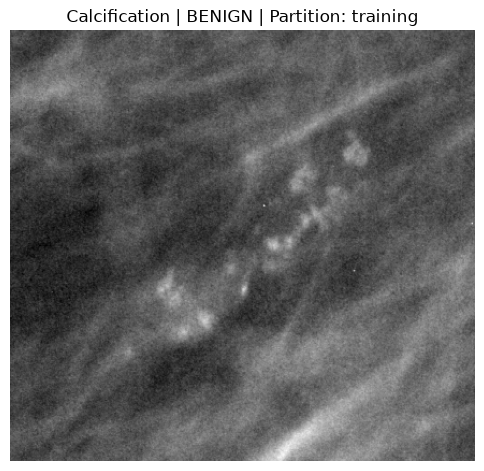

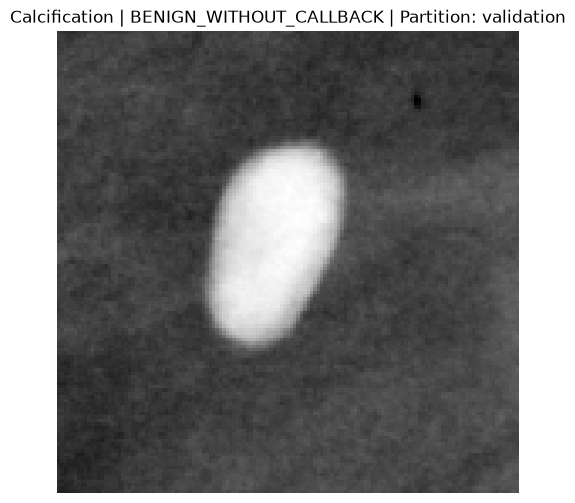

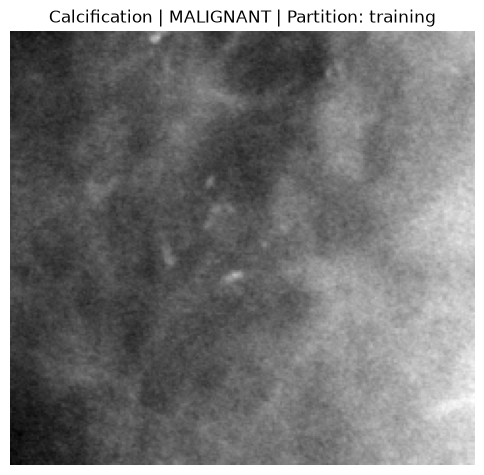

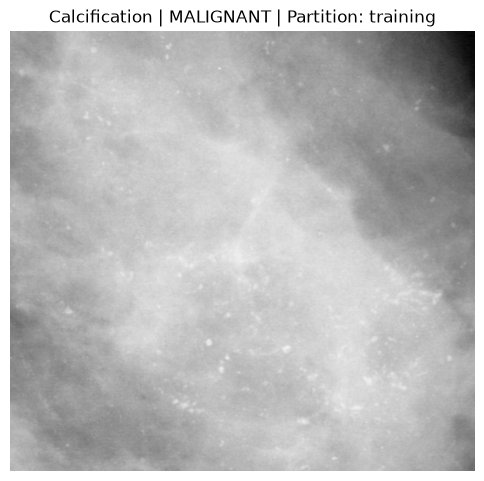

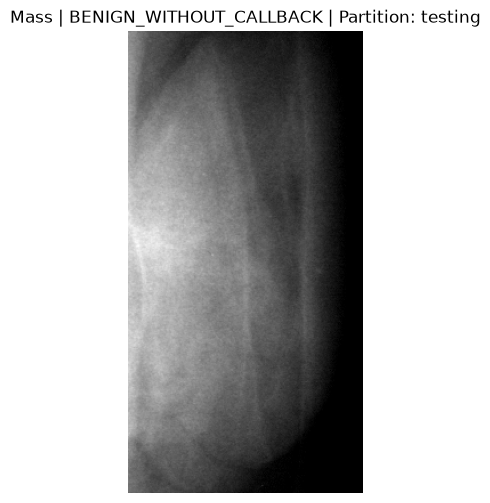

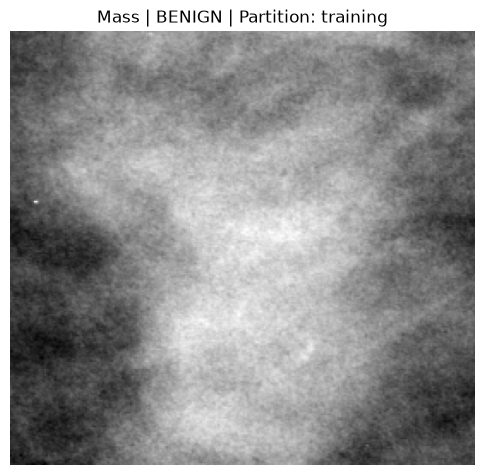

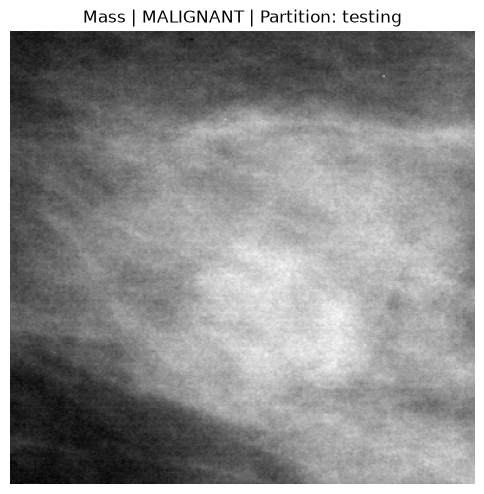

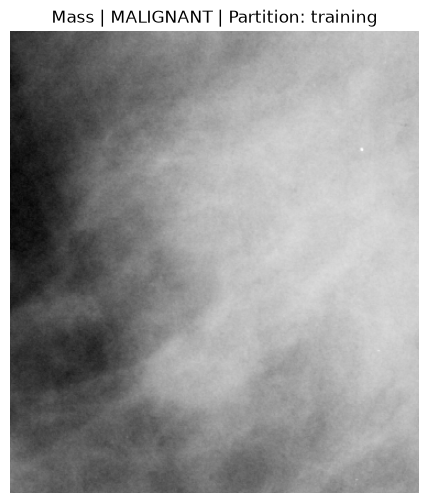

In [145]:
#display every image selected for visal inspection
for _, row in visual_audit_sample.iterrows():

    #read the DICOM file and decode its pixel array 
    dicom = pydicom.dcmread(
        row["resolved_dicom_path"]
    )

    pixel_array = dicom.pixel_array

    #invert MONOCROME1 images so that larger displayed values correspond to brighter regions
    if (
        getattr(
            dicom,
            "PhotometricInterpretation",
            ""
        ) == "MONOCHROME1" 
    ): 
        pixel_array = ( 
            pixel_array.max()
            - pixel_array
        )

    #display the original cropped image
    plt.figure(
        figsize=(6, 6)
    )

    plt.imshow(
        pixel_array,
        cmap="gray"
    )

    plt.title(
        (
            f"{row['abnormality_group'].title()} | "
            f"{row['pathology']} | "
            f"Partition: {row['final_partition']}"
        )
    )

    plt.axis("off")
    plt.show()


__Visual Audit Interpretation__

The sampled files appear to be mammographic images rather than binary ROI masks. The audit also demonstrates considerable variation in crop size, contrast, tissue density and lesion conspicuity. 

Calcification cases generally contain small bright foci, ranging from concentrated clusters to more diffuse patterns. Mass cases show broader regions of altered tissue density, with differences in shape, boundary definition and surrounding tissue. Some lesions are visually prominent, whereas others are subtle and poorly separated from adjacent breast tissue. 

The samples also vary in how tightly the abnormality is cropped. Some images contain a focused lesion-centred region, while others retain substantially more surrounding tissue. This heterogeneity supports the use of consistent intensity normalisation and aspect-ratio-preserving resizing. 

Visual inspection cannot determine whether the pathology labels are clinically correct or whether the crop contains the complete lesion. It provides a technical quality check rather than a radiological assessment. 

__Visual Audit Conclusion__

The visual audit confirmed that the sampled model inputs were cropped mammographic images representing both abnormality groups and pathology cases. No obvious ROI masks, empty images or unreadable files were observed. The substantial variation in lesion size, visibility, crop extent and background tissue reinforces the need for standardised preprocessing. However, because this was a limited visual sample and no radiologist reviewed the images, the audit should be interpreted as a technical quality assessment rather than evidence of clinical validity.

### 6.5 Small-Image Assessment
Images with at least one spatial dimension below 100 picels are examined separately. These records are not removed automatically because small dimensions may reflect tightly cropped lesion regions rather than corrupted or incomplete files. 

In [146]:
#identify images with a height or width below 100 pixels 
small_images = combined_metadata[
    (
        combined_metadata[
            "image_height"
        ] < 100
    )
    |
    (
        combined_metadata[
            "image_width"
        ] < 100
    )
]

print(
    "Images with at least one dimension below 100 pixels:",
    len(small_images)
)

#display a sample for inspection
display(
    small_images[
        [
            "record_id",
            "abnormality_group",
            "image_height",
            "image_width",
            "pathology"
        ]
    ]
    .head(20)
)

Images with at least one dimension below 100 pixels: 77


,record_id,abnormality_group,image_height,image_width,pathology
16,calcification_P_00008_RIGHT_MLO_2,calcification,105,97,BENIGN_WITHOUT_CALLBACK
324,calcification_P_00455_LEFT_MLO_3,calcification,113,97,BENIGN_WITHOUT_CALLBACK
345,calcification_P_00476_LEFT_CC_1,calcification,105,81,BENIGN_WITHOUT_CALLBACK
347,calcification_P_00476_RIGHT_CC_1,calcification,89,89,BENIGN_WITHOUT_CALLBACK
348,calcification_P_00476_RIGHT_CC_2,calcification,89,97,BENIGN_WITHOUT_CALLBACK
349,calcification_P_00476_RIGHT_CC_3,calcification,89,73,BENIGN_WITHOUT_CALLBACK
352,calcification_P_00476_RIGHT_MLO_3,calcification,97,97,BENIGN_WITHOUT_CALLBACK
370,calcification_P_00505_LEFT_CC_1,calcification,113,97,BENIGN_WITHOUT_CALLBACK
373,calcification_P_00505_RIGHT_CC_1,calcification,97,121,BENIGN_WITHOUT_CALLBACK
375,calcification_P_00505_RIGHT_MLO_1,calcification,97,97,BENIGN_WITHOUT_CALLBACK


In [147]:
#calculate the proportion of small images
small_image_percentage = (
    len(small_images)
    / len(combined_metadata)
    * 100
)

print(
    "Small-image percentage:",
    f"{small_image_percentage:.2f}%"
)

Small-image percentage: 2.16%


__Output Interpretation__

Seventy-seven images, representing 2.16% of the dataset, contained at least one dimension below 100 pixels. The displayed records were predominantly tightly cropped calcification cases rather than unreadable or incorrect resolved files. These images were retained to avoid unnecessary data loss and potential changes to the class or abnormality-group distributions.

All retained images subsequently undergo the same deterministic resizing and normalisation procedure.

### 6.6 Preprocessing Configuration

Following image-quality assessment, a standardised preprocessing pipeline is defined for model development. 
The original images vary substantially in spatial dimensions and intensity ranges. Each image is therefore transformed into a consistent numerical and spatial representation before being supplied to the models.

The pipeline performs:
1) DICOM pixel-array decoding;
2) Conversion to 32-bit floating-point format;
3) Percentile-based intesity clipping;
4) Intensity scaling to [0,1];
5) Resizing to 224 x 224 pixels;
6) Grayscale-to-three-channel conversion for compatibility with ImageNet-pretrained architectures.
   
The same deterministic preprocessing is applied to training, validation and testing data. Random data augmentation is introduced separately and applied only to the training partition. 

In [148]:
#spatial dimensions required by the model inputs
TARGET_IMAGE_SIZE = (
    224,
    224
)

#percentiles used for robust intensity clipping
LOWER_PERCENTILE = 1.0
UPPER_PERCENTILE = 99.0

#convert the grayscale images to three channels
OUTPUT_CHANNELS = 3

print(
    "Target image size:",
    TARGET_IMAGE_SIZE
)

print(
    "Intensity clipping percentiles:",
    LOWER_PERCENTILE,
    "to",
    UPPER_PERCENTILE
)

print(
    "Output channels:",
     OUTPUT_CHANNELS
)



Target image size: (224, 224)
Intensity clipping percentiles: 1.0 to 99.0
Output channels: 3


__Configuration Interpretation__

All images will be converted to a uniform 224 x 224 x 3 representation. Percentile clipping limits the influence of extreme intensity 
values, while three-channel conversion allows grayscale mammograms to be used with ImageNet-pretrained architectures.

### 6.7 Percentile-Based Intensity Normalisation

Although all images use 16-bit pixel arrays, their observed intensity ranges vary. Direct minimum-maximum scaling may be disproportionately influenced by extreme pixel values.

Each image is therefore clipped independently at its 1st and 99th intensity percentiles. The clipped values are then linearly scaled to [0, 1]. A minimum-maximum fallback handles images with an invalid or collapsed percentile range. 

In [149]:
def normalise_mammogram_intensity(
    pixel_array,
    lower_percentile=LOWER_PERCENTILE,
    upper_percentile=UPPER_PERCENTILE,
):
    """
    Apply percentile clipping and scale a mammographic image to the interval [0, 1].

    Parameters
    ----------
    pixel_array : numpy.ndarray
        Decoded two-dimensional DICOM pixel array.

    lower_percentile : float
        Lower clipping percentile.

    upper_percentile : float
        Upper clipping percentile.

    Returns
    ---------
    numpy.ndarray
        Normalised float32 image with values in [0, 1].
    """

    #convert the decoded pixel data to float32
    image = np.asarray(
        pixel_array,
        dtype=np.float32
    )

    #calculate the image-specific clipping thresholds
    lower_value = np.percentile(
        image,
        lower_percentile
    )

    upper_value = np.percentile(
        image,
        upper_percentile
    )

    #fall back to the full intensity range when the percentile range is invalid or collapsed
    if upper_value <= lower_value:
        image_minimum = image.min()
        image_maximum = image.max()

        #return a zero image when all pixel values are identical
        if image_maximum <= image_minimum:
            return np.zeros_like(
                image,
                dtype=np.float32
            )

        lower_value = image_minimum
        upper_value = image_maximum

    #clip extreme values to the selected percentile range
    image = np.clip(
        image,
        lower_value,
        upper_value,
    )

    #scale the clipped intensities to [0, 1]
    image = (
        image - lower_value
    ) / (
        upper_value - lower_value
    )

    #protect against numerical values outside the target interval 
    image = np.clip(
        image,
        0.0,
        1.0
    )

    return image.astype(
        np.float32
    )

### 6.8 Intensity-Normalisation Validation 

The normalisation function is tested on a representative DICOM image. The validation confirms that image dimensions are preserved, the output uses *float32*, and all pixel values fall within [0, 1].

In [150]:
#read the representative DICOM image
sample_dicom = pydicom.dcmread(
    sample_resolved_path
)

sample_original_image = (
    sample_dicom.pixel_array
)

#apply percentile based normalised
sample_normalised_image = (
    normalise_mammogram_intensity(
        sample_original_image
    )
)

#report the original image properties
print(
    "Original shape:", 
    sample_original_image.shape
)

print(
    "Original dtype:", 
    sample_original_image.dtype
)

print(
    "Original range:",
    (
        sample_original_image.min(),
        sample_original_image.max()
    )    
)

print()

#report the normalised image properties 
print(
    "Normalised shape:",
    sample_normalised_image.shape
)

print(
    "Normalised dtype:",
    sample_normalised_image.dtype
)

print(
    "Normalised range:",
    (
        sample_normalised_image.min(),
        sample_normalised_image.max(),
    )
)


Original shape: (589, 677)
Original dtype: uint16
Original range: (np.uint16(20012), np.uint16(65535))

Normalised shape: (589, 677)
Normalised dtype: float32
Normalised range: (np.float32(0.0), np.float32(1.0))


In [151]:
#confirm that normalisation preserves the spatial dimensions
assert(
    sample_normalised_image.shape
    == sample_original_image.shape
), "Normalisation changed the image dimensions."

#confirm that the image remains two-dimensional
assert sample_normalised_image.ndim == 2

#confirm the expected numerical type
assert (
    sample_normalised_image.dtype
    == np.float32
)

#confirm that all intensities are contained in [0, 1]
assert sample_normalised_image.min() >= 0.0
assert sample_normalised_image.max() <= 1.0

print(
    "Intensity normalisation validation passed."
)

Intensity normalisation validation passed.


__Validation Result__

Normalisation preserved the original 589 x 677 dimensitons while converting the image from *uint16* to *float32*. The output covered the expected [0, 1] interval, confirming that the transformation behaved as intended for the sampled image.

### 6.9 Visual Assessment of Intensity Normalisation

The sampled image is displayed before and after normalisation ot check whether the transformation preserves the visible breast-tissue structures while standardising its numerical intensity range.


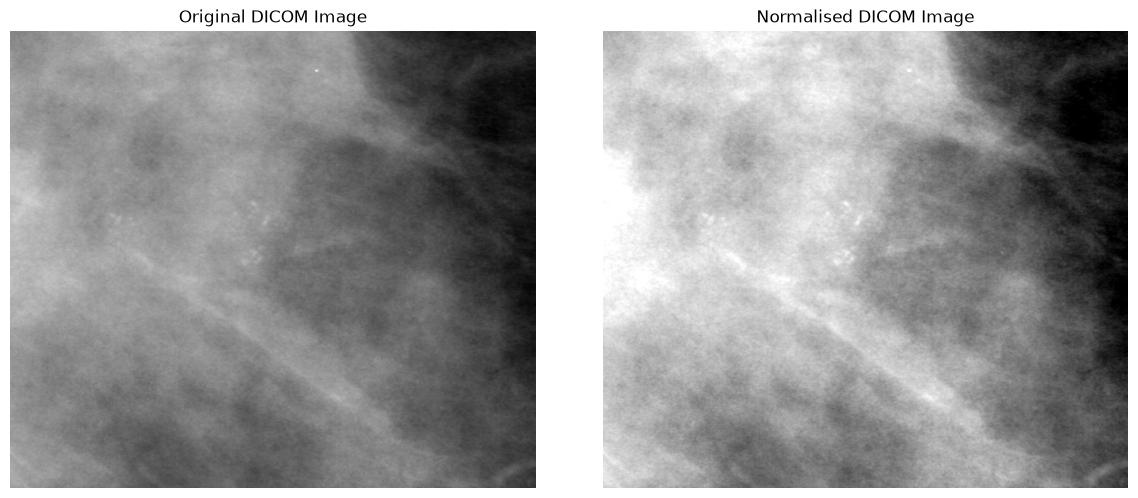

In [152]:
#compare the original and normalised images visually
figure, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

#display the original decoded DICOM image
axes[0].imshow(
    sample_original_image,
    cmap="gray"
)

axes[0].set_title(
    "Original DICOM Image"
)

axes[0].axis("off")

#display the percentile-normalised image
axes[1].imshow(
    sample_normalised_image,
    cmap="gray",
    vmin=0,
    vmax=1
)

axes[1].set_title(
    "Normalised DICOM Image"
)

axes[1].axis("off")

plt.tight_layout()
plt.show()

__Visual Interpretation__

The normalised image retains the same anatomical structures and spatial arrangement as the original. Percentile clipping produces a modest increase in contrast, making variations in breast tissue and small high-intensity regions more visible while limiting the influence of extreme pixel values.

No geometric transformation occurs during this stage, and the image dimensions remain unchanged. The comparison therefore supports the technical suitability of the normalisation procedure for subsequent preprocessing.

This visual check is limited to confirming preservation of visible image structure and contrast. It does not establish that diagnostic information is clinically preserved, as that would require radiologist assessment. 

### 6.10 Aspect-Ratio-Preserving Spatial Resizing

The cropped images vary considerably in spatial dimensions and aspect ratio. Directly stretching every image to a square could distord lesion morphology. Images are therefore resized while preserving their aspect ratio, followed by symmetric zero-padding to produce a fixed 224 x 224 input.

Billinear interpolation is used for continuous image intensities. The same deterministic transformation is applied across all experimental partitions. 

In [153]:
#resize a normalised mammogram while preserving its aspect ratio
def resize_mammogram(
    image, 
    target_size=TARGET_IMAGE_SIZE
):
    """
    Resize a normalised mammogram while preserving its
    aspect ratio and pad it to a fixed target size.

    Parameters
    ----------
    image : numpy.ndarray
        Two-dimensional normalised mammogram image.

    target_size : tuple
        Required output height and width. 

    Returns
    -------
    numpy.ndarray
        Float32 image with fixed dimensions and values
        constrained to the interval [0, 1].
    """

    #convert the input into a consistent float3 NumPy array
    image = np.asarray(
        image,
        dtype=np.float32
    )

    #ensure that the input is a two dimensional grayscale image
    if image.ndim != 2:
        raise ValueError(
            "Expected a two-dimensional grayscale image, "
            f"but received shape {image.shape}."
        )

    #prevent tensorflow from attempting to resize an empty image
    if image.size == 0:
        raise ValueError(
            "Cannot resize an empty image."
        )

    #convert the numpy array into a tensorflow tensor
    image_tensor = tf.convert_to_tensor(
        image,
        dtype=tf.float32
    )

    #add a single channel dimension required by tensor flow resizing
    image_tensor = tf.expand_dims(
        image_tensor,
        axis=-1
    )

    #resize the image while preserving its original aspect ratio and pad the remaining area too reach the target dimensions
    resized_tensor = tf.image.resize_with_pad(
        image_tensor,
        target_height=target_size[0],
        target_width=target_size[1],
        method="bilinear",
        antialias=True
    )

    #constrain interpolated pixel values to the normalised range
    resized_tensor = tf.clip_by_value(
        resized_tensor,
        clip_value_min=0.0,
        clip_value_max=1.0
    )

    #remove the temporary single-channel dimension
    resized_image = tf.squeeze(
        resized_tensor,
        axis=-1
    )

    #return the resized image as a float32 NumPy array
    return resized_image.numpy().astype(
        np.float32
    )

    

In [154]:
#apply aspect ratio preserving resizing and padding to the representative normalised mammogram
sample_resized_image = resize_mammogram(
    sample_normalised_image
)

#report the image dimension before resizing
print(
    "Original shape:",
    sample_normalised_image.shape
)

#confirm that the resized image has the required dimensions
print(
    "Resized shape:",
    sample_resized_image.shape
)

#confirm that the resized image retains the float32 data type
print(
    "Resized dtype:",
    sample_resized_image.dtype
)

#confirm that the resized pixel values remain within the expected normalised range
print(
    "Resized range:",
    (
        sample_resized_image.min(),
        sample_resized_image.max()
    )
)

Original shape: (589, 677)
Resized shape: (224, 224)
Resized dtype: float32
Resized range: (np.float32(0.0), np.float32(1.0))


In [155]:
#confirm that the resized image matches the required target dimensions
assert (
    sample_resized_image.shape
    == TARGET_IMAGE_SIZE
)

#confirm that the resized image uses the required float32 data type
assert (
    sample_resized_image.dtype
    == np.float32
)

#confirm that the resized image contain no NaN or infinite values
assert np.isfinite(
    sample_resized_image
).all()

#confirm that the minimum pixel value is within the normalised range
assert (
    sample_resized_image.min()
    >= 0.0
)

#confirm that the maximum pixel value is within the normalised range
assert (
    sample_resized_image.max()
    <= 1.0
)

#report that all resizing validation checks were completely successfully
print(
    "Aspect-ratio-preserving resizing validation passed."
)

Aspect-ratio-preserving resizing validation passed.


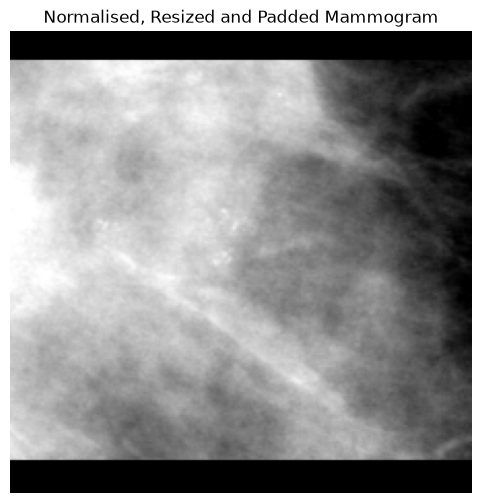

In [156]:
#create a square figure for displaying the processed mammogram
plt.figure(
    figsize=(6, 6)
)

#display the normalised, resized and padded image in grayscale using a fixed intensity range for consistent visualisation
plt.imshow(
    sample_resized_image,
    cmap="gray",
    vmin=0.0,
    vmax=1.0
)

#add a descriptive title summarising the preprocessing applied
plt.title(
    "Normalised, Resized and Padded Mammogram"
)

#hide axis labels and ticks because they do not provide useful information
plt.axis("off")

#render the processed mammogram
plt.show()

__Validation Result__

The sampled image was converted from 589 x 677 to 224 x 224 without stretching its original aspect ratio. The black horizontal padding visible above and below the image is expected and results from fitting a wider image into a square input. The output remains finite, uses *float32*, and is constrained to *[0,1]*.

### 6.11 Three-Channel Conversion

In [157]:
#convert a two dimensional grayscale image into identical channels
def convert_to_three_channels(
    image
):
    """
    Repeat a two-dimensional grayscale image across three identical channels.

    Parameters
    ----------
    image : numpy.ndarray
        Two-dimensional float32 image.

    Returns
    --------
    numpy.ndarray
        Three-channel float32 image.
    """

    #convert the input into a consistent float32 NumPy array
    image = np.asarray(
        image,
        dtype=np.float32
    )

    #ensure that the input is a two dimensional grayscale image
    if image.ndim != 2:
        raise ValueError(
            "Expected a two-dimensional input image, "
            f"but received shape {image.shape}."
        )

    #add a channel dimension and repeat the grayscale values across the required number of identical output channels
    three_channel_image = np.repeat(
        image[..., np.newaxis],
        repeats=OUTPUT_CHANNELS,
        axis=-1
    )

    #return the three channel image using the flaot32 data type
    return three_channel_image.astype(
    np.float32
    )

In [158]:
#conver thte representation resized grayscale image into the required three-channel format
sample_three_channel_image = (
    convert_to_three_channels(
        sample_resized_image
    )
)

#report the dimensions of the converted image
print(
    "Three-channel shape:",
    sample_three_channel_image.shape
)

#report the data type of the converted image
print(
    "Three-channel dtype:",
    sample_three_channel_image.dtype
)

#report the minimum and maximum pixel values
print(
    "Three-channel range:",
    (
        sample_three_channel_image.min(),
        sample_three_channel_image.max()
    )
)

Three-channel shape: (224, 224, 3)
Three-channel dtype: float32
Three-channel range: (np.float32(0.0), np.float32(1.0))


In [159]:
#define the expected height, width and channel dimensions
expected_three_channel_shape = (
    TARGET_IMAGE_SIZE[0],
    TARGET_IMAGE_SIZE[1],
    OUTPUT_CHANNELS
)

#confirm that the converted image has the expected dimensions
assert (
    sample_three_channel_image.shape
    == expected_three_channel_shape
)

#confirm that the converted image uses the float32 data type
assert (
    sample_three_channel_image.dtype
    == np.float32
)

#confim that the first and second channels contain identical values
assert np.allclose(
    sample_three_channel_image[..., 0],
    sample_three_channel_image[..., 1],
)

#confim that the first and third channels contain identical values
assert np.allclose(
    sample_three_channel_image[..., 1],
    sample_three_channel_image[..., 2],
)

#confirm that the converted image contains no NaN or infinite values
assert np.isfinite(
    sample_three_channel_image
).all()

#report that all three-channel conversion checks passed
print(
    "Three-channel conversion validation passed."
)

Three-channel conversion validation passed.


__Validation Result__

The greyscale image was converted successfully into a 224 x 224 x 3 pseudo-RGB image. All three channels contain identical values, ensuring compatiblity with ImageNet-pretrained architectures without introducing artificial colour information. 

### 6.12 Reusable DICOM Preprocessing Function

The validated preprocessing operations are combined into a single reusable function to ensre that every cropped-lesion image is processed consistently. This function provides a common preprocessing entry point for model training, validation, testing, calibration, uncertainty estimation and Grad-CAM analysis.

It performs the following operations: 

* DICOM pixel-array decoding;
* *MONOCHROME1* intensity inversion when required;
* percentile-based intensity normalisation;
* aspect-ratio-preserving resizing and symmetric padding;
* conversion to either one or three output channels;
* final valiation of the output data type and intensity range.

The function returns a *float32* image with fixed spatial dimensions and pixel values constrained to [0, 1]. Using the same deterministic procedure across all experimental partitions prevents preprocessing differences from influencing model evaluation.



In [160]:
def load_and_preprocess_dicom(
    dicom_path,
    target_size=TARGET_IMAGE_SIZE,
    lower_percentile=LOWER_PERCENTILE,
    upper_percentile=UPPER_PERCENTILE,
    output_channels=OUTPUT_CHANNELS
):
    """
    Load and preprocess one cropped-lesion DICOM image.

    Processing sequence
    -------------------
    1. Read the DICOM file
    2. Decode the pixel array
    3. Correct MONOCHROME1 orientation when required
    4. Apply percentile-based intensity normalisation
    5. Resize while preserving aspect ratio and add padding
    6. Return either one or three image channels

    Parameters
    ----------
    dicom_path: str or pathlib.Path
        Path to the cropped-lesion DICOM file.

    target_size : tuple
        Output image height and width.

    lower_percentile : float
        Lower intensity-clipping percentile.

    upper_percentile : float
        Upper intensity-clipping percentile.

    output_channels : int 
        Number of output channels. Supported values are 1 and 3.

    Returns
    -------
    numpy.ndarray
        Preprocessed float32 image with values in [0, 1].
    """

    dicom_path = Path(
        dicom_path
    )

    if not dicom_path.is_file():
        raise FileNotFoundError(
            f"DICOM file not found: {dicom_path}"
        )
    dicom = pydicom.dcmread(
        dicom_path
    )

    pixel_array = dicom.pixel_array

    if pixel_array.ndim != 2:
        raise ValueError(
            "Expected a two-dimensional DICOM pixel array, "
            f"but received shape {pixel_array.shape}."
        )

    photometric_interpretation = str(
        getattr(
            dicom,
            "PhotometricInterpretation",
            ""
        )
    ).upper()
    
    if photometric_interpretation == "MONOCHROME1":
        pixel_array = (
            pixel_array.max()
            - pixel_array
        )

    normalised_image = (
        normalise_mammogram_intensity(
            pixel_array,
            lower_percentile=lower_percentile,
            upper_percentile=upper_percentile
        )
    )

    resized_image = resize_mammogram(
        normalised_image,
        target_size=target_size
    )

    if output_channels == 1:
        output_image = (
            resized_image[..., np.newaxis]
        )
        
    elif output_channels == 3:

        output_image = (
            convert_to_three_channels(
                resized_image
            )
        )
    else:
        raise ValueError(
            "output_channels must be either 1 or 3."
        )

    output_image = np.asarray(
        output_image,
        dtype=np.float32
    )

    output_image = np.clip(
        output_image,
        0.0,
        1.0
    )

    return output_image

### 6.13 ROI-Mask Preprocessing and Series Verification

Radiologist-provided ROI masks are processed separately from the mammographic images. These masks are not used as classifier inputs, training targets or sources of supervision during model development. They are retained exclusively as reference annotations for post-hoc assessment of Grad-CAM localisation.

An additional verification stage is required because the extracted CBIS-DDSM case directories may contain both cropped-lesion images and ROI-mask images, while their local filenames do not consistently identify their contents. Selecting a file solely from its filename can therefore incorrectly associate a cropped mammogram with an ROI-mask metadata record. To prevent this, every candidate DICOM file within the corresponding case directory is inspected using its *SeriesDescription*. Only files explicitly identified as ROI-mask series are retained in the independently verified path columns.

This verification is performed without replacing the original ROI-resolution results. Retaining both sets of columns preserves provenance and allows the initial resolution process to be audited, while ensuring that only confirmed ROI-mask DICOM files are used in subsequent preprocessing.

### 6.13.1 Independent ROI-Series Verification

In [161]:
#independently verify ROI-mask DICOM paths
def resolve_verified_roi_mask_path(metadata_path):
    """
    Independently locate and verify the ROI-mask DICOM file belonging to one CBIS-DDSM abnormality record.

    This function does not replace or modify the original ROI-path resolution results. It creates a separate, 
    verified path by inspecting the DICOM SeriesDescription.

    Parameters
    ---------
    metadata_path : str
        Original ROI-mask supplied by the metadata.

    Returns
    ________
    tuple
        Verified ROI-mask path, verification status and verification method.
    """

    #standardise the original metadata path
    normalised_path = normalise_relative_path(
        metadata_path
    )

    #handles records without an ROI-mask metadata path
    if pd.isna(normalised_path):
        return (
            pd.NA,
            "missing_metadata_path",
            pd.NA
        )

    #convert the normalised path into a Path object 
    metadata_relative_path = Path(
        normalised_path
    )

    path_parts = metadata_relative_path.parts

    #the first path component should identify the case folder.
    if len(path_parts) < 2:
        return (
            pd.NA,
            "missing",
            "insufficient_path_components"
        )

    #construct the corresponding local case directory
    case_directory = (
        IMAGE_ROOT
        / path_parts[0]
    )

    #confirm that the case directory exists locally
    if not case_directory.is_dir():
        return (
            pd.NA,
            "missing",
            "case_directory_not_found"
        )

    #find every DICOM file contained within the case directory
    case_dicom_files = sorted(
        path
        for path in case_directory.rglob("*.dcm")
        if path.is_file()
    )

    verified_roi_matches = []

    #inspect each DICOM header without decoding its pixel data 
    for dicom_path in case_dicom_files:

        try:
            dicom_header = pydicom.dcmread(
                dicom_path,
                stop_before_pixels=True,
                force=True
            )

            #standardise the SeriesDescription for comparison 
            series_description = str(
                getattr(
                    dicom_header,
                    "SeriesDescription",
                    ""
                )
            ).strip().casefold()

            #retain only files explicitly identified as belonging to an ROI-mask series
            if (
                "roi" in series_description
                and "mask" in series_description
            ):
                verified_roi_matches.append(
                    dicom_path
                )

        except Exception:
            #ignore file whose headers cannot be decoded
            #they will not be accepted as verified ROI masks
            continue

    #accept the path only when exactly one ROI mask is found
    if len(verified_roi_matches) == 1:
        return (
            str(
                verified_roi_matches[0].resolve()
            ),
            "verified",
            "series_description_roi_mask"
        )

    #avoid arbitrary selection when several files satisfy the ROI-mask criteria
    if len(verified_roi_matches) > 1:
        return (
            pd.NA,
            "ambiguous",
            "multiple_verified_roi_masks"
        )
        
    return (
        pd.NA,
        "missing",
        "verified_roi_mask_not_found"
    )

The verification function searches within the case directory associated with each metadata record. It reads only the DICOM headers at this stage because pixel-array decoding is unnecessary for identifying the image type and would increase processing time.

A candidate file is accepted only when its normalised *SeriesDescription* contains both "ROI" and "mask". A unique match is classified as verified. Cases containing no matching file are classified as missing, while cases containing multiple matching files are classified as ambiguous rather than being resolved arbitrarily.

This conservative procedure reduces the risk of suing a cropped mammographic image as an annotation mask. It also prevents traceability because the verified paths are stored separately from the original ROI-resolution results.

### 6.13.2 Application of ROI-Series Verification


In [162]:
#apply the independent ROI series verifier
verified_roi_results = (
    combined_metadata[
        "roi_mask_file_path"
    ]
    .progress_apply(
        resolve_verified_roi_mask_path
    )
)

#convert the returned tuples into a structured dataframe
verified_roi_results = pd.DataFrame(
    verified_roi_results.tolist(),
    index=combined_metadata.index,
    columns=[
        "verified_roi_mask_path",
        "verified_roi_status",
        "verified_roi_method"
    ]
)

#remove only prev versions of the verifiction columns. The original ROI resolution columns remain unchanged
combined_metadata = combined_metadata.drop(
    columns = [
        "verified_roi_mask_path",
        "verified_roi_status",
        "verified_roi_method"
    ],
    errors="ignore"
)

#add the independently verified results to the metadata
combined_metadata = pd.concat(
    [
        combined_metadata,
        verified_roi_results
    ],
    axis=1
)

#summarise the verification outcomes
verified_roi_summary = (
    combined_metadata[
        "verified_roi_status"
    ]
    .value_counts(
        dropna=False
    )
    .rename_axis(
        "Verified ROI status"
    )
    .rename(
        "Record count"
    )
    .to_frame()
)

#calculate the percentage represented by each outcome
verified_roi_summary["Percentage"] = (
    verified_roi_summary[
        "Record count"
    ]
    .div(len(combined_metadata))
    .mul(100)
    .round(2)
)

display (
    verified_roi_summary
)

  0%|          | 0/3568 [00:00<?, ?it/s]

,Record count,Percentage
Verified ROI status,,
verified,3248,91.03
missing,320,8.97


Of the 3,568 metadata records, 3,248 were linked to a uniquely verified ROI-mask DICOM file, producing a verification rate of 91.03%. The remaining 320 records, representing 8.97% of the dataset, did not contain a uniquely identifiable ROI-mask series.

These unresolved records remain in the classification dataset because the masks are not required for model training or prediction. However, they are excluded from any analysis that depends on a radiologist annotation, including quantitative Grad-CAM localisation assessment. This separation prevents missing masks from unnecessarily reducing the classification dataset while ensuring that explanation metrics are calculated only when a verified reference annotation is available.

### 6.13.3 Verification of DICOM Series Descriptions

In [163]:
#confirm that every retinaed path is an ROI-mask series
#select records with independently verified ROI-mask paths
verified_roi_rows = combined_metadata[
    combined_metadata[
        "verified_roi_status"
        ].eq("verified")
].copy()

print(
    "Verified ROI-mask records:",
    len(verified_roi_rows)
)

#confirm that at least one verified mask is available
assert not verified_roi_rows.empty, (
    "No ROI-mask DICOM files were verified."
)

#read and normalise the SeriesDescription of every independently verified DICOM file
verified_series_descriptions = (
    verified_roi_rows[
        "verified_roi_mask_path"
    ]
    .apply(
        lambda path: str(
            getattr(
                pydicom.dcmread(
                    path, 
                    stop_before_pixels=True,
                    force=True
                ),
                "SeriesDescription",
                ""
            )
        )
        .strip()
        .casefold()
    )
)

#a retained file must contain both "roi" and "mask" in its SeriesDescription
valid_series = (
    verified_series_descriptions.str.contains(
        "roi",
        na=False
    )
)

assert valid_series.all(), (
    "At least one verified path does not correspond "
    "to an ROI-mask DICOM series."
)

print(
    "All retained paths were confirmed as ROI-mask DICOM files."
)

Verified ROI-mask records: 3248
All retained paths were confirmed as ROI-mask DICOM files.


The second validation confirms that all 3,248 retained paths correspond to DICOM series explicitly identified as ROI-mask images. This check is important because directory names and extracted filenames alone are insufficient to distinguish between the cropped lesion and its annotation.

The result confirms the semantic identity fo the retained DICOM files: they are ROI masks rather than continuous-intensity mammographic images. However, series verification establishes the file type only. It does not independently prove exact pixel-level registration between the mask and the cropped lesion image.

### 6.13.4 Binary ROI-Mask Preprocessing
Each verified ROI-mask DICOM file is decoded into a two-dimensional pixel array. Pixel above the minimum observed intensity are converted to foreground, producing a binary representation in which *1* indicates the annotated region and *0* indicates background.

The binary mask is resized using the same target dimensions and aspect-ratio-preserving padding strategy applied to the mammographic images. Nearest-neighbour interpolation is used because a mask contains categorical labels rather than continuous image intensities. This prevents interpolation from creating artificial intermediate values along the annotation boundary.

The mask is not intensity-normalised because its pixel values do not represent mammographic intensity. A final threshold is applied after resizing to ensure that the output remains strictly binary.

In [164]:
#load and preprocess a verified ROI-mask DICOM file
def load_and_preprocess_roi_mask(
    dicom_path,
    target_size=TARGET_IMAGE_SIZE
):
    """
    Load a verified CBIS-DDSM ROI mask and transform it to the model-input coordinate system.

    Parameters
    ----------
    dicom_path : str or pathlib.Path
        Path to verified ROI-mask DICOM file

    target_size : tuple
        Required output height and width.

    Returns
    --------
    numpy.ndarray
        Binary uint8 mask with the requested dimensions
    """

    #convert the supplied path to a Path object
    dicom_path = Path(dicom_path)

    #confirm that the file exists
    if not dicom_path.is_file():
        raise FileNotFoundError(
            f"ROI-mask DICOM file not found: {dicom_path}"
        )

    #read and decode the DICOM mask
    dicom = pydicom.dcmread(dicom_path)
    mask_array = np.asarray(dicom.pixel_array)

    #the mask must be a two dimensional array
    if mask_array.ndim != 2:
        raise ValueError(
            "Expected a two-dimensional ROI mask, "
            f"but received shape {mask_array.shape}."
        )

    #convert all pixels above the minimum background intensity to binary background
    binary_mask = (
        mask_array > mask_array.min()
    ).astype(np.float32)

    #confirm that an annotated foreground region exists
    if binary_mask.sum() == 0:
        raise ValueError(
            f"The ROI mask contains no foreground pixels: "
            f"{dicom_path}"
        )

    #add a channel dimension for TensorFlow resizing
    mask_tensor = tf.convert_to_tensor(
        binary_mask[..., np.newaxis],
        dtype=tf.float32
    )

    #resize while preserving the original aspect ration and add padding to reach the target dimensions
    #nearest neighbout interpolation is used to preserve the categorical mask labels
    resized_mask = tf.image.resize_with_pad(
        mask_tensor,
        target_height=target_size[0],
        target_width=target_size[1],
        method="nearest"
    )

    #remove the temporary channel dimension
    resized_mask = tf.squeeze(
        resized_mask,
        axis=-1
    )
    
    #aaply a final threshold so that the resized output contains only zero and one
    resized_mask = (
        resized_mask >= 0.5
    ).numpy().astype(np.uint8)

    return resized_mask


### 6.13.5 Transformation Validation


In [165]:
#validate the image and ROI-image transformations
#select up to five reproducible verified image-mask pairs.
roi_validation_rows = verified_roi_rows.sample(
    n=min(
        5,
        len(verified_roi_rows)
    ),
    random_state=SEED
)

#validate every selected image-mask pair
for _, row in roi_validation_rows.iterrows():

    #preprocess the cropped lesion mammogram
    image = load_and_preprocess_dicom(
        row["resolved_dicom_path"]
    )

    #preprocess the independently verified ROI mask
    roi_mask = load_and_preprocess_roi_mask(
    row["verified_roi_mask_path"]
    )

    #confirm that both outputs have the same final spatial dimensions
    assert image.shape[:2] == roi_mask.shape

    #confirm that the resized mask remains binary
    assert set (
        np.unique(roi_mask)
    ).issubset({0, 1})

    #confirm that the annotation was not lost during resizing
    assert roi_mask.sum() > 0

print(
    "Verified image and ROI-mask transformations validated."
)

Verified image and ROI-mask transformations validated.


The sampled ROI masks were successfully decoded, binarised and transformed to the required (224\times 224) output dimensions. Each processed mask contained only background and foreground labels, and every mask retained at least one foreground pixel after resizing.

The dimensional assertion confirms that the processed mammogram and ROI mask can be represented within the same model-input array size. The binary-value assertion confirm that nearest-neightbour resizing did not introduce invalid label values. The foreground assertion ensures that a small annotation was not removed during spatial downsampling.

Together,these checks establish the technical validity of the preprocessing procedure for the sampled verified masks. They do not, by themselved, demonstrate exact spatial registration between the original DICOM files.

### 6.13.6 Visual Image-Mask Sanity Check


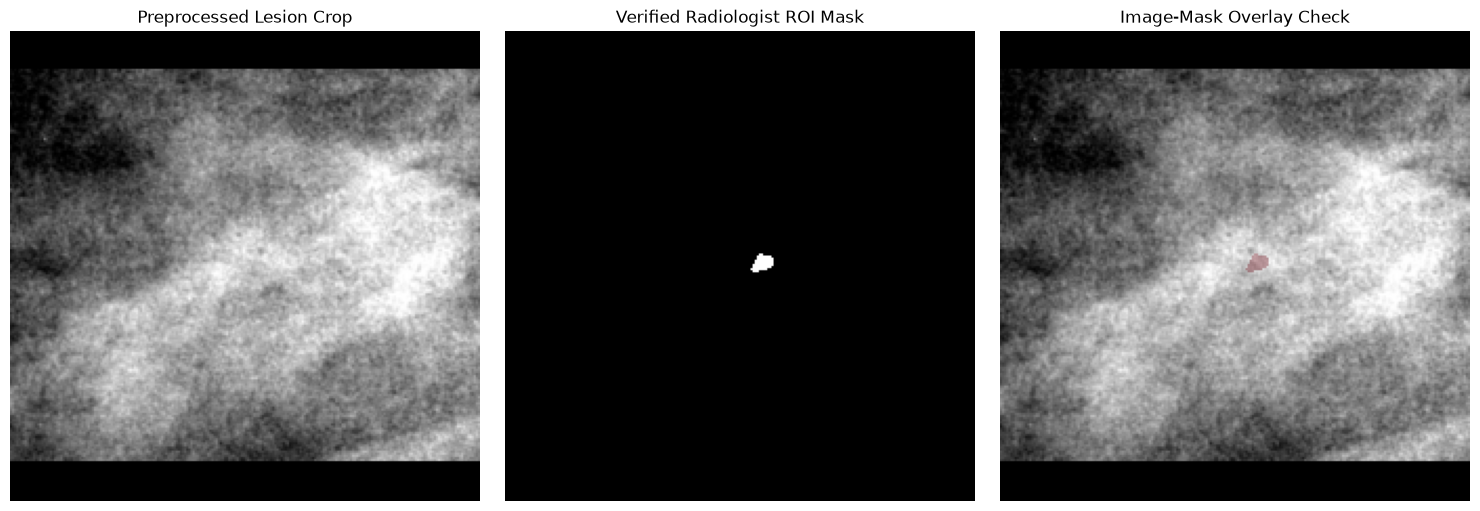

In [166]:
#visual sanity check of one verified image-mask pair

#select the first pair from the validated sample
sample_roi_row = roi_validation_rows.iloc[0]

#preprocess the corresponding cropped-lesion mammogram 
sample_roi_image = load_and_preprocess_dicom(
    sample_roi_row["resolved_dicom_path"]
)

#preprocess the corresponding cropped-lesion mammogram 
sample_roi_mask = load_and_preprocess_roi_mask(
    sample_roi_row["verified_roi_mask_path"]
)

#hide zero valued background pixels so that only the annotated foreground is coloured in the overlay 
overlay_mask = np.ma.masked_where(
    sample_roi_mask == 0,
    sample_roi_mask
)

#construct a three-panel visual comparison
figure, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5)
)

#panel 1: model ready cropped lesion image
axes[0].imshow(
    sample_roi_image
)
axes[0].set_title(
    "Preprocessed Lesion Crop"
)
axes[0].axis("off")

#panel 2: verified and preprocessed binary ROI mask
axes[1].imshow(
    sample_roi_mask,
    cmap="gray",
    vmin=0,
    vmax=1
)
axes[1].set_title(
    "Verified Radiologist ROI Mask"
)
axes[1].axis("off")

#panel 3: ROI foreground displayed over the lesion crop
axes[2].imshow(
    sample_roi_image
)
axes[2].imshow(
    overlay_mask,
    cmap="Reds",
    alpha=0.35,
    vmin=0,
    vmax=1
)
axes[2].set_title(
    "Image-Mask Overlay Check"
)
axes[2].axis("off")

plt.tight_layout()
plt.show()

__Visual Interpretation__

The three-panel figure provides a visual sanity check of the verified image and mask processing stages. 

The left panel presents the preprocessed cropped-lesion mammogram used as the classifier input. Mammographic tissue remains visible after intensity normalisation and resizing. The horizontal black regions represent padding introduced by the aspect-ratio-preserving transformation. This padding allows the rectangular crop to be represented as a (224 /times 224) image without geometrically stretching the breast tissue or lesion. 

The centre panel shows the verified radiologist ROI mask after binarisation and resizing. The compact white region represents the annotated abnormality, while the back are represents unnanotated background. Its clearly binary appearance supports that the selected DICOM file is an annotation mask rather than a continuous-intensity mammographic image. The foreground also remains visible after resizing, indicating that the annotation was not lost during downsampling. 

The right panel displays the mask foreground in red over the preprocessed mammogram. The zero-valued background is masked before visualisation, so only the annotated region is coloured. This makes the location and extent of the radiologist annotation easier to interpret relative to the surrounding mammograhohic tissue. In this example, the annotation falls within the visible breast tissue and occupies a localised region rather than covering the complete crop. 

This visualisation is important because numerical checks alone would not reveal whether the wrong DICOM type had been selected or whether the complete image had been incorrectly intepreted as foreground. The compact binary region and localised red overlay provide evidence that the verification and preprocessing stages are behaving plausibly.

### 6.13.7 Interpretation Limitation

The overlay is treated as a qualitative technical sanity check rather than definitive evidence of pixel-level registration. Matching final dimensions confirms that the processed  image and mask are computationally compatible, but it does not prove that their original DICOM arrays used the same coordinate system. Two images with different original dimensions can both by independently resized to (224 \times 224) while retaining an uncertain spatial relationship.

Consequently, the verified masks can be used confidently as rediologist-provided annotation references, but quantitative Grad-CAM overlap metrics should only be interpreted where the original image-mask correspondence has also been established. Records without a uniquely verified mask must be excluded from mask-dependent metric but may remain in the classification dataset because ROI annotations do not contribute to model training. 

Overall, the verification stage prevents continuous-intensity cropped images from being mistaken for binary masks, the preprocessing stage preserves categorical annotation values, and the visual audit confirms that the resulting foreground representation is technically plausible. These safeguards improve the reliability and transparency of the subsequent explainability analysis.

### 7. TensorFlow Dataset Construction

Following completion of the deterministic image-preprocessing pipeline, the patient-independent metadata partitions are prepared for conversion into TensorFlow datasets. 

The training, validation and testing are constructed separately using the partitions established previously. Images are loaded lazily from their resolved DICOM paths, processed using the same reusable function and returned with their corresponding binary labels.

Only the training dataset will subsequently receive data augmentation. Validation and testing remain deterministic so that model selection, calibration and final evaluation are performed on consistent inputs.

### 7.1 Dataset Configuration

The batch size, random seed and TensorFlow data-loading parameters are defined centrally. Centralising these values improves reproducibility and ensures that the same configuration is used throughout model development. 

Images are loaded dynamically from disk rather than preprocessing and retaining the complete collection in memmory. This reduces memory requirements and ensures that all experiments use the same preprocessing implementation.

In [167]:
#TensorFlow dataset config
#number of image label pairs processed in each batch
BATCH_SIZE = 32

#fixed seed used for reproducible dataset operations.
RANDOM_SEED = 42

#allow tensorflow to determine an efficient level of parallelism for data loading and preprocessing
AUTOTUNE = tf.data.AUTOTUNE

#report the principal dataset configuration values
print(
    "Batch size:",
    BATCH_SIZE
)

print(
    "Random seed:",
    RANDOM_SEED
)

print(
    "Target image shape:",
    (
        TARGET_IMAGE_SIZE[0],
        TARGET_IMAGE_SIZE[1],
        OUTPUT_CHANNELS
    )
)       

Batch size: 32
Random seed: 42
Target image shape: (224, 224, 3)


__Interpretation__

A batch size of 32 provides a practical balance between computational efficiency and memory use. The dixed random seed supports reproducible shiffling and dataset construction.

Each processed image will have dimensions 224 x 224 x 3. The first two values represent the standardised spatial dimensions, while the third represents the 3 identical grayscale-derived channels required by the ImageNet-pretrained architectures. *AUTOTUNE* allows TensorFlow to optimise parallel data processing according to the available hardware.

### 7.2 Partition Metadata Validation

Before constructing the TensorFlow datasets, the final metadata partitions are recreated from *combined_metadata.* Their record counts, requried coluns, resolved DICOM paths and binary target values are then validated. 

These checks prevent incomplete metadata or unresolved image paths from causing failures during model training or evaluation.

In [169]:
#recreate the final lesion level metadata partitions
#select all records assigned to the training partition
train_df = (
    combined_metadata.loc[
        combined_metadata[
            "final_partition"
        ] == "training"
    ]
    .copy()
    .reset_index(drop=True)
)

#select all records assigned to the validation partition
val_df = (
    combined_metadata.loc[
        combined_metadata[
            "final_partition"
        ] == "validation"
    ]
    .copy()
    .reset_index(drop=True)
)

#select all records assigned to the testing partition
test_df = (
    combined_metadata.loc[
        combined_metadata[
            "final_partition"
        ] == "testing"
    ]
    .copy()
    .reset_index(drop=True)
)

#report the number of lesion image records in each partition
print (
    "Training records:",
    len(train_df)
)

print (
    "Validation records:",
    len(val_df)
)

print (
    "Testing records:",
    len(test_df)
)

#confirm that the resolved DICOM-path column is available in every partition
print(
    "\nresolved_dicom_path present:"
)

print(
    "Training",
    "resolved_dicom_path"
    in train_df.columns
)

print(
    "Validation",
    "resolved_dicom_path"
    in val_df.columns
)

print(
    "Testing",
    "resolved_dicom_path"
    in test_df.columns
)

Training records: 2537
Validation records: 504
Testing records: 527

resolved_dicom_path present:
Training True
Validation True
Testing True


__Initial partition assessment__

The recreated partitions contain 2,537 training records, 504 validation records and 527 testing records. Together, these account for all 3,568 lesion-image records.

The *resolved_dicom_path* column is present in every partition, confirming that the image-location information required by the TensorFlow loading pipeline has been retained.

In [170]:
#validate partition completeness and DICOM path availability
#confirm that every metadata records belong exactly to one of the three final partitions
assert(
    len(train_df)
    + len(val_df)
    + len(test_df)
    == len(combined_metadata)
)

#confirm that every training record has a resolved DICOM path
assert train_df[
    "resolved_dicom_path"
].notna().all()

#confirm that every validation record has a resolved DICOM path
assert val_df[
    "resolved_dicom_path"
].notna().all()

#confirm that every testing record has a resolved DICOM path
assert test_df[
    "resolved_dicom_path"
].notna().all()

print(
    "Partition dataframes were recreated successfully."
)

Partition dataframes were recreated successfully.


__Completeness assessment__

The assertions confirm that all records from the combined metadata are represented across the 3 partitions and that no selected record has a missing resolved DICOM path. The partition DataFramess are therefore complete and ready for the remaining dataset-level validation.

In [173]:
#validate the metadata required for dataset construction
#columns required for image loading, target assignment, auditing and subgroup analysis.
required_dataset_columns = [
    "record_id",
    "patient_id",
    "resolved_dicom_path",
    "target",
    "abnormality_group",
    "pathology"
]

#associate each partition name with this dataframe
partition_dataframes = {
    "training": train_df,
    "validation": val_df,
    "testing": test_df
}

#validate every partition independently 
for partition_name, partition_df in partition_dataframes.items():

    #identify required columns that are absent
    missing_columns = [
        column
        for column in required_dataset_columns
        if column not in partition_df.columns
    ]

    #stop execution if essential metadata are missing
    if missing_columns:
        raise KeyError(
            f"{partition_name} metadata is missing columns: "
            f"{missing_columns}"
        )

    #identify non-null target values outside the expected binary encoding of zero and one
    invalid_targets = set(
        partition_df[
            "target"
        ]
        .dropna()
        .unique()
    ) - {0, 1}

    #stop execution if an invalid target value is detected
    if invalid_targets:
        raise ValueError(
            f"{partition_name} contains invalid target values: "
            f"{invalid_targets}"
        )

    #count records without a resolved DICOM path
    unresolved_records = (
        partition_df[
            "resolved_dicom_path"
        ]
        .isna()
        .sum()
    )

    #stop execution if any image path remains unresolved
    if unresolved_records > 0:
        raise ValueError(
            f"{partition_name} contains: "
            f"{unresolved_records} unresolved paths."
        )

    #report the successfully validated record count
    print(
        f"{partition_name.title()} records: ",
        len(partition_df)
    )

Training records:  2537
Validation records:  504
Testing records:  527


__Final Interpretation__

All three metadata partitions passed the required validation checks. Each partition contains the columns needed for image loading, binary classification and subsequent subgroup analysis. No invalid non-null target values or unresolved DICOM paths were detected. 

The record counts remain consistent with the patient-independent split created previously:
* Training: 2,537 records
* Validation: 504 records
* Testing: 527 records
* Total: 3,568 records

These results confirm that the metadata inputs are complete and structurally suitable for TensorFlow dataset construction. The patient-independent assignments remains unchanged; this section only recreates and validates the lesion-level partition DataFrames for data loading.

### 7.3 TensorFlow-Compatible DICOM Loading

The validated preprocessing function uses 'pydicom' and Numpy, which operate outside TensorFlow's graph execution. *tf.numpy_function* is therefore used as a bridge, allowing each DICOM file to be decoded and preprocessed dynamically as the dataset is iterated.

TensorFlow cannot automatically infer the shape returned by a Python function. The expected image and target shapes are consequently restored explicitly after loading.

In [174]:
#numpy based DICOM preprocessing wrapper
def preprocess_dicom_for_tensorflow(
    dicom_path
): 
    """
    Apply the validation DICOM preprocessing pipeline within a TensorFlow-compatible Numpy wrapper.

    Parameters
    ----------
    dicom_path
        Scalar Numpy value containing an encoded filesystem path

    Returns
    --------
    numpy.ndarray
        Preprocessed float32 image with shape 
        (height, width, channels)
    """

    #extract the scalar path value from the Numpy input
    path_value = np.asarray(
        dicom_path
    ).item()
    
    #tensorflow string tensors are commonly supplied as bytes
    #decode them into a standard python path string
    if isinstance(
        path_value,
        bytes
    ):
        decoded_path = path_value.decode(
            "utf-8"
        )
    else:
        decoded_path = str(
            path_value
        )

    #apply the previously validated DICOM preprocessing pipeline to the decoded filesystem path
    image = load_and_preprocess_dicom(
        decoded_path
    )

    #guarantee the expected numerical representation
    return np.asarray(
        image,
        dtype=np.float32
    )

In [181]:
#tensor image label loading function
def tensorflow_load_example(
    dicom_path,
    target
):

    """
    Load one DICOM image and return a model-ready 
    image-label pair
    """

    #execute the python/numpy DICOM preprocessing function within the TensorFlow input pipeline
    image = tf.numpy_function(
        func=preprocess_dicom_for_tensorflow,
        inp=[dicom_path],
        Tout=tf.float32
    )

    #restore the static image shape because tf.numpy_function cannot infer output dimensions automatically
    image = tf.ensure_shape(
        image,
        (
            TARGET_IMAGE_SIZE[0],
            TARGET_IMAGE_SIZE[1],
            OUTPUT_CHANNELS
        )
    )

    #convert the binary target to the numerical type expected by the model and loss function
    target = tf.cast(
        target,
        tf.float32
    )

    #confirm that each target is a scalar rather than a vector
    target = tf.ensure_shape(
        target,
        ()
    )

    return image, target
    

The first function converts the encoded TensorFlow path into a standard Python string before calling the established preprocessing pipeline. The second function integrates this operation into TensorFlow and explicitly restores the expected image shape of 224 x 224 x 3.

The returned target is represented as a scalar *float32* value, which is suitable for binary classification.

### 7.4 TensorFlow Loader Validation

Before constructing the complete datasets, the TensorFlow-compatible loader is tested using one training record. This confirms that the NumPy-based DICOM decoder integrates correctly with TensorFlow and preserves the expected image representation and target encoding.

In [182]:
#test the tensorflow compatible loader on one record
#convert one resolved training image path into a tensorflow string tensor
sample_tensorflow_path = tf.constant(
    train_df.loc[
        0,
        "resolved_dicom_path"
    ]
)

#convert the correspondding binary target into float32
sample_tensorflow_target = tf.constant(
    train_df.loc[
        0,
        "target"
    ],
    dtype=tf.float32
) 

#laod and preprocess the sample through the tensorflow compatible wrapper
sample_tensorflow_image, sample_tensorflow_label = (
    tensorflow_load_example(
        sample_tensorflow_path,
        sample_tensorflow_target
    )
)

#report the resulting tensor properties
print(
    "TensorFlow image shape:",
    sample_tensorflow_image.shape
)

print(
    "TensorFlow image dtype:",
    sample_tensorflow_image.dtype
)

print(
    "TensorFlow image range:",
    (
        float(
            tf.reduce_min(
                sample_tensorflow_image
            )
        ),
        float(
            tf.reduce_max(
                sample_tensorflow_image
            )
        )
    )
)

print(
    "TensorFlow target:",
    float(
        sample_tensorflow_label.numpy()
    )
)
   

TensorFlow image shape: (224, 224, 3)
TensorFlow image dtype: <dtype: 'float32'>
TensorFlow image range: (0.0, 1.0)
TensorFlow target: 1.0


In [183]:
#validate the loaded image and target 
#define the expected model input dimensions
expected_tensorflow_shape = (
    TARGET_IMAGE_SIZE[0],
    TARGET_IMAGE_SIZE[1],
    OUTPUT_CHANNELS
)

#confirm the expected image shape
assert (
    sample_tensorflow_image.shape
    == expected_tensorflow_shape
)

#confirm the image and target data types
assert (
    sample_tensorflow_image.dtype
    == tf.float32
)

assert (
    sample_tensorflow_label.dtype
    == tf.float32
)

#confirm that the image contains no NaN or infinite values
assert bool(
    tf.reduce_all(
        tf.math.is_finite(
            sample_tensorflow_image
        )
    ).numpy()
)

#confirm that all image values remain within [0, 1]
assert (
    float(
        tf.reduce_min(
            sample_tensorflow_image
        ).numpy()
    )
    >= 0.0
)

assert (
    float(
        tf.reduce_max(
            sample_tensorflow_image
        ).numpy()
    )
    <= 1.0
)

#confirm that the sample target uses binary encoding
assert float(
    sample_tensorflow_label.numpy()
) in {
    0.0,
    1.0
}

print(
    "TensorFlow-compatible DICOM loader validation passed."
)
        


TensorFlow-compatible DICOM loader validation passed.


The laoder produced a *float32* image with the required shape of 224 x 224 x 3, finite pixel values within [0, 1], and a valid binary target. These results confirm that the original DICOM preprocessing pipeline has been integrated into TensorFlow without changing its output representation.

### 7.5 Reusable TensorFlow Dataset Factory
A reusable factory function constructs each experimental dataset consistently. It validates the supplied metadata, creates path-target pairs, optionally shuffles the records, applies the DICOM loader, forms mini-batches and prefetches future batches.

Shuffling can therefore be enabled for training while determining ordering is retained for validation and testing.

In [186]:
#reusable tensorflow dataset factory
def create_tensorflow_dataset(
    metadata,
    batch_size=BATCH_SIZE,
    shuffle=False,
    random_seed=RANDOM_SEED
):
    """
    Construct a batched TensorFlow dataset from partition metadata.

    Parameters
    ----------
    metadata : pandas.DataFrame
        Metadata containing resolved DICOM paths and binary targets.

    batch_size : int
        Number of records per mini-batch

    shuffle : bool
        Whether to shuffle records before loading
        
    random_seed : int
        Seed used for reproducible training-data shuffling

    Returns
    -------
    tf.data.Dataset
        Batched and prefetched image-label dataset
    """

    #define the metadata columns required by the pipeline
    required_columns = {
        "resolved_dicom_path",
        "target"
    }

    #identify any required columns that are absent
    missing_columns = (
        required_columns
        - set(metadata.columns)
    )

    if missing_columns:
        raise KeyError(
            "Dataset metadata is missing required columns: "
            f"{sorted(missing_columns)}"
        )
        
    #prevent construction from an empty partition
    if len(metadata) == 0:
        raise ValueError(
            "Cannot construct a TensorFlow dataset from "
            "an empty metadata dataframe."
        )

    #every record must have a resolved local image path
    if metadata[
        "resolved_dicom_path"
    ].isna().any():
        raise ValueErro(
            "Dataset metadata contains unresolved DICOM paths."
        )

    #confirms that all available targets use binary encoding
    invalid_targets = (
        set(
            metadata[
                "target"
            ]
            .dropna()
            .unique()
        )
        - {0, 1}
    )

    if invalid_targets:
        raise ValueError(
            "Dataset metadata contains invalid targets: "
            f"{invalid_targets}"
        )

    #convert image paths into a NumPy string array
    dicom_paths = (
        metadata[
            "resolved_dicom_path"
        ]
        .astype(str)
        .to_numpy()
    )

    #convert image paths into a NumPy string array
    dicom_paths = (
        metadata[
            "resolved_dicom_path"
        ]
        .astype(str)
        .to_numpy()
    )

    #convert binary targets into float32 values
    targets = (
        metadata[
            "target"
        ]
        .astype(np.float32)
        .to_numpy()
    )

    #construct a tensorflow dataset of path-target pairs
    dataset = (
        tf.data.Dataset
        .from_tensor_slices(
            (
                dicom_paths,
                targets
            )
        )
    )

    #shuffle only when requested. A full partition buffer permits all records to participate in the shuffle
    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=len(metadata),
            seed=random_seed,
            reshuffle_each_iteration=True
        )

    #load and preprocess images in parallel
    dataset = dataset.map(
        tensorflow_load_example,
        num_parallel_calls=AUTOTUNE
    )

    #group examples into mini-batches. The final smaller batch is retained when the record count is not divisible by the batch size
    dataset = dataset.batch(
        batch_size,
        drop_remainder=False
    )

    #prepare future batches while the current batch is used, improving input-pipeline throughput
    dataset = dataset.prefetch(
        AUTOTUNE
    )

    return dataset

The factory centralises dataset construction so that all partitions use the same loading and preprocessing logic. A complete-partition shuffle buffer is used when shuffling is enabled, while *reshuffle_each_iteration=True* changes the training order between epochs.

Parallel mapping and prefetching improve throughput by overlapping data preparation with model execution. Retaining the final incomplete batch ensures that no lesion record is discarded.

### 7.6 Training, Validation and Testing Datasets

The three patient-independent metadata partitions are converted into separate TensorFlow datasets. Training records are reshuffled during each epoch to reduce ordering effects. Validation and testing remain unshuffled, preserving deterministic evaluation and alignment with their corresponding metadata DataFrames. No augmentation is applied at this stage,

In [187]:
#construct the three experimental tensorflow datasets
#construct the shuffled training dataset
train_dataset = create_tensorflow_dataset(
    metadata=train_df,
    batch_size=BATCH_SIZE,
    shuffle=True
)

#construct the deterministic validation dataset
val_dataset = create_tensorflow_dataset(
    metadata=val_df,
    batch_size=BATCH_SIZE,
    shuffle=True
)

#construct the deterministic testing dataset
test_dataset = create_tensorflow_dataset(
    metadata=test_df,
    batch_size=BATCH_SIZE,
    shuffle=True
)

print(
    "TensorFlow datasets constructed successfully."
)

TensorFlow datasets constructed successfully.


__Interpretation__

All three metadata partitions were successfuly converted into batched and prefetched TensorFlow datasets. The training dataset will present records in a different reproducible order across epochs, while validation and testing preserve their metadata order.

This configuration supports unbiased evaluation and later record-level association of validation and test predictions with patient identifiers, abnormality groups and pathology metadata. Data augmentation remains separate and can therefore be restricted to training examples only.

### 7.7 Dataset Cardinality Validation
The expected number of mini-batches is calculated from the number of lesion records and the configured batch size. Because *drop_remainder=False*, the final incomplete batch is retained, and the expected count is therefore rounded upward.

The calculated values compared with TensorFlow's reported dataset cardinality to verify that each partition contains the expected number of batches.

In [189]:
#validate tensorflow dataset cardinality
import math

#calculate the expected number of bacthes for each partition. 
#math.ceil accounts for the final incomplete batch because
#drop_remainder=False was used during batching
expected_batch_counts = {
    "training": math.ceil(
        len(train_df)
        / BATCH_SIZE
    ),
    "validation": math.ceil(
        len(val_df)
        / BATCH_SIZE
    ),
    "testing": math.ceil(
        len(test_df)
        / BATCH_SIZE
    )
}

#associate each partition name with its tensorflow dataset
tensorflow_datasets = {
    "training": train_dataset,
    "validation": val_dataset,
    "testing": test_dataset
}

#compare tensorflows observed cardinality with the mathematically expected number of batches
for dataset_name, dataset in tensorflow_datasets.items():

    #obtain the number of batches reported by tensorflow
    observed_batches = int(
        tf.data.experimental.cardinality(
            dataset
        ).numpy()
    )

    #retrieve the corresponding expected batch count
    expected_batches = (
        expected_batch_counts[
            dataset_name
        ]
    )

    print(
        f"{dataset_name.title()} batches:",
        observed_batches
    )

    #confirm that the observed and expected counts agree
    assert(
        observed_batches
        == expected_batches
    ), (
        f"{dataset_name} dataset contains "
        f"{observed_batches} batches, but "
        f"{expected_batches} were expected."
    )

print(
    "Dataset cardinality validation passed."
        
)   

Training batches: 80
Validation batches: 16
Testing batches: 17
Dataset cardinality validation passed.


__Interpretation__

The observed cardinalities matched the expected values for all three partitions. The 2,537 training records produced 80 batches, the 504 validation records produced 16 batches and the 527 testing records produced 17 batches. 

These results are consistent with a batch size of 32 and retention of the final incomplete batch. The successful comparison confirms that the dataset factory produced the expected number of batches for every partition.

### 7.8 Batch-Level Dataset Validation
One mini-batch from each partition is inspected to verify its dimensions, data types, numerical range and target encoding. This checks the final ouput of the complete path-to-tensor pipeline rather than testing the preprocessing functions in isolation. 

In [190]:
#inspect and validate one batch from a tensorflow dataset
def inspect_dataset_batch(
    dataset,
    dataset_name
):
    """
    Inspect and validate one mini-batch from a TensorFlow dataset.
    """

    #retrieve the first available mini-batch
    images, targets = next(
        iter(dataset)
    )

    #calculate the minimum and maximum image values
    image_minimum = float(
        tf.reduce_min(
            images
        ).numpy()
    )
    
    image_maximum = float(
        tf.reduce_max(
            images
        ).numpy()
    )

    #identify the target values present in the batch
    unique_targets = np.unique(
        targets.numpy()
    )

    #report the batch structure and numerical properties
    print(
        f"{dataset_name} image batch shape:",
        images.shape
    )

    print(
        f"{dataset_name} target batch shape:",
        targets.shape
    )

    print(
        f"{dataset_name} image dtype:",
        images.dtype
    )

    print(
        f"{dataset_name} target dtype:",
        targets.dtype
    )

    print(
        f"{dataset_name} image range:",
        (
            image_minimum,
            image_maximum
        )
    )

    print(
        f"{dataset_name} unique targets:",
        unique_targets
    )

    #confirm that every image has the expected model input shape
    assert (
        images.shape[1:]
        == (
            TARGET_IMAGE_SIZE[0],
            TARGET_IMAGE_SIZE[1],
            OUTPUT_CHANNELS

        )
    )

    #confirm that the targets form a one-dimensional vector
    assert (
        targets.shape.rank
        == 1
    )

    #confirm the expected numerical data tyoes
    assert images.dtype == tf.float32
    assert targets.dtype == tf.float32

    #confirms that the image batch contains no NaN or infinite values
    assert bool(
        tf.reduce_all(
            tf.math.is_finite(
                images
            )
        ).numpy()
    )

    #confirm that normalised image values remain in [0, 1].
    assert image_minimum >= 0.0
    assert image_maximum <= 1.0

    #confirm that all observed targets use binary encoding
    assert set(
        unique_targets.tolist()
    ).issubset(
        {
            0.0,
            1.0
        }
    )

    print(
        f"{dataset_name} batch validation passed.\n"
    )


In [191]:
#validate one batch from each experimental partition
inspect_dataset_batch(
    train_dataset,
    "Training"
)

inspect_dataset_batch(
    val_dataset,
    "Validation"
)

inspect_dataset_batch(
    test_dataset,
    "Testing"
)

Training image batch shape: (32, 224, 224, 3)
Training target batch shape: (32,)
Training image dtype: <dtype: 'float32'>
Training target dtype: <dtype: 'float32'>
Training image range: (0.0, 1.0)
Training unique targets: [0. 1.]
Training batch validation passed.

Validation image batch shape: (32, 224, 224, 3)
Validation target batch shape: (32,)
Validation image dtype: <dtype: 'float32'>
Validation target dtype: <dtype: 'float32'>
Validation image range: (0.0, 1.0)
Validation unique targets: [0. 1.]
Validation batch validation passed.

Testing image batch shape: (32, 224, 224, 3)
Testing target batch shape: (32,)
Testing image dtype: <dtype: 'float32'>
Testing target dtype: <dtype: 'float32'>
Testing image range: (0.0, 1.0)
Testing unique targets: [0. 1.]
Testing batch validation passed.



__Interpretation__

Each inspected batch contained 32 images with dimensions 224 x 224 x 3  and a corresponding one-dimensional vector of 32 labels. Both images and targets were represented as *float32*, and all image values were finite and constrained to [0, 1].

Both benign and malignant targets appeared in each inspected batch. This confirms the correct binary encoding of the sampled outputs, although the presence of both classes in one batch is not required for every batch. Overall, the results demonstrate consistent model-ready outputs across training, validation and testing.

### 7.9 TensorFlow Pipeline Visual Verification

Images are visualised directly from the TensorFlow training dataset to inspect the complete path-to-tensor workflow after DICOM decoding, normalisation, resizing, channel conversion, shuffling and batching.

The displayed target corresponds to the binary classification label used for model development, where *0* denotes benign pathology and *1* denotes malignant pathology.

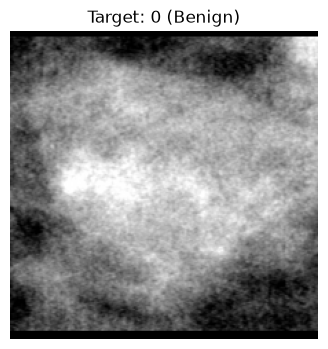

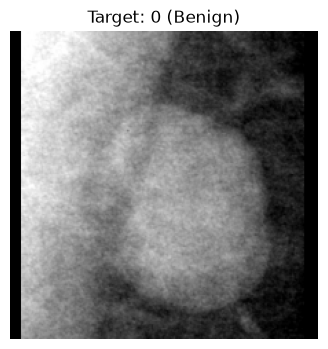

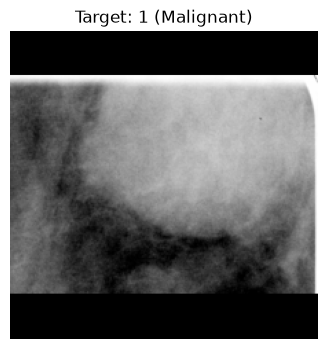

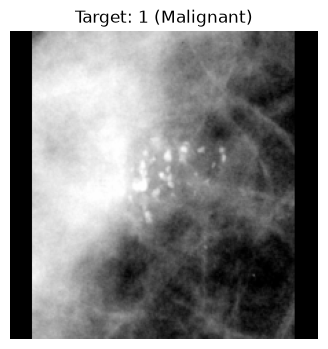

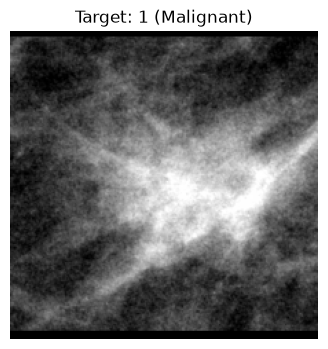

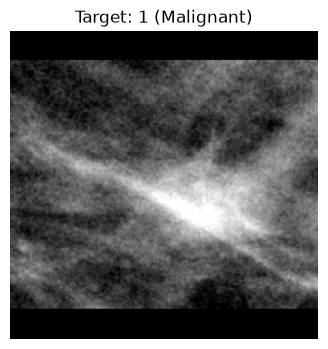

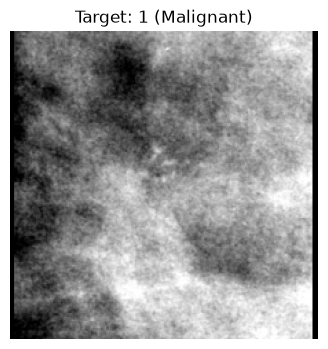

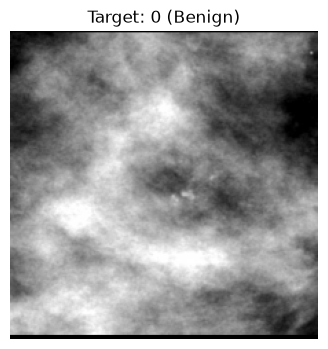

In [192]:
#visually inspect images from tensorflow pipeline
#retrieve one mini atch from the training set 
training_images, training_targets = next(
    iter(train_dataset)
)

#display a maximum of eight images, while allowing for a smaller final batch if necessary
number_to_display = min(
    8,
    int(
        training_images.shape[0]
    )
)

#display each selected image with its binary target
for image_index in range(
    number_to_display
):

    #convert the tensorflow image tensor to numpy for matplotlib visualisation
    image = (
        training_images[
            image_index
        ]
        .numpy()
    )

    #extract the corresponding binary target
    target_value = int(
        training_targets[
            image_index
        ]
        .numpy()
    )

    #convert the numerical target into a readable label
    target_name = (
        "Malignant"
        if target_value == 1
        else "Benign"
    )

    #display the model ready image
    plt.figure(
        figsize=(4, 4)
    )

    plt.imshow(
        image
    )

    plt.title(
        f"Target: {target_value} ({target_name})"
    )

    plt.axis(
        "off"
    )

    plt.show()

__Visual Interpretation__

The displayed tensors retain recognisable mammographic tissue, lesion-related density patterns and calcification clusters after passing through the complete TensorFlow pipeline. Both tightly focused abnormality crops and images containing more surrounding tissue remain visible, reflecting the natural heterogeneity identified during the earlier image-quality assessment.

The black borders visible in several examples are expected consequences of aspect-ratio-preserving resizing. They indicate that padding was applied instead of stretching rectangular crops into a square, thereby reducing geometric distortion. Differences in padding orientation reflect variation in the original image dimensions.

The sample contains both benign and malignant labels, confirming that the displayed images remain correctly paired with their binary targets after shuffling and batching. However, visual inspection cannot confirm the clinical correctness of those pathology labels or determine whether a lesion is benign or malignant from appearance alone.

Overall, the visual audit shows that dynamic DICOM loading and preprocessing preserve meaningful mammographic structure without producing blank, corrupted or mask-like inputs. Together with the cardinality and batch-level validations, this confirms that the deterministic TensorFlow datasets are technically suitable for subsequent model development.

### 8. Training-Only Data Augmentation

Data augmentation increases variation within the training data by presenting slightly transformed versions of the original images during different training iterations. This can reduce overfitting and encourage the model to learn lesion-related patterns rather than memorising exact pixel positions.

Because mammography is spatially sensitive, only conservative geometric transformations are used. Small rotations,translations and zoom changes simulate plausible variation in lesion positioning and crop construction without intentionally altering lesion morphology.

Augmentation is applied only during model training. Validation and testing images remain unchanged to ensure deterministic model selection and unbiased final evaluation.

### 8.1 Augmentation Configuration

The augmentation pipeline applies mild geometric transformations suitable for cropped mammographic lesions. Horizontal and vertical flipping are excluded because these transformations could hear orientation-dependent anatomical context or produce anatomically implausible appearances.

In [199]:
#training only data augmentation configuration
data_augmentation = tf.keras.Sequential(
    [
        #apply a small random rotation of approximately +/-7.2 degrees.Empty regions introduced by rotation 
        ##are filled with zero to match the existing padding
        tf.keras.layers.RandomRotation(
            factor=0.02,
            fill_mode="constant",
            fill_value=0.0,
            seed=RANDOM_SEED
        ),

            #shift the image vertically and horizontally by no more than 3% of its dimensions
            tf.keras.layers.RandomTranslation(
            height_factor=0.03,
            width_factor=0.03,
            fill_mode="constant",
            fill_value=0.0,
            seed=RANDOM_SEED
        ),

            #apply mild independent zoom variation of up to 5%
            #along the vertical and horizontal dimensions
            tf.keras.layers.RandomZoom(
            height_factor=(-0.05, 0.05),
            width_factor=(-0.05, 0.05),
            fill_mode="constant",
            fill_value=0.0,
            seed=RANDOM_SEED
        )
    ],

    #assign a descriptive name for model inspection
    name = "training_data_augmentation"
)

data_augmentation.build(
    (
        None,
        TARGET_IMAGE_SIZE[0],
        TARGET_IMAGE_SIZE[1],
        OUTPUT_CHANNELS
    )
)

#display the augmentation layer configuration
data_augmentation.summary()

Model: "training_data_augmentation"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_rotation_3               │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation_3            │ (None, 224, 224, 3)    │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_3 (RandomZoom)      │ (None, 224, 224, 3)    │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

The augmentation layers contain no trainable parameters because they perform stochastic geometric transformations rather than learned operations. After construction, each layer preserves the expected input dimensions of 224 x 224 x 3.

The transformation limits are intentionally conservative: rotation is restricted to approximately ±7.2°, translation to 3% of the image dimensions and zoom variation to 5%. Zero filling is used for newly exposed regions, maintaining consistency with the black padding introduced during aspect-ratio-preserving preprocessing.

### 8.2 Augmentation Validation


The pipeline is applied to one training mini-batch with *training=True*, which activates the stochastic transformations. The output shape, data type, numerical range and finite-value status are then validated. 

In [202]:
#apply augmetation to one training mini-batch
#retrive one preprocessed mini batch from the training set
augmentation_images, augmentation_targets = next(
    iter(train_dataset)
)

#apply stochastic augmentation in training mode
augmented_images = data_augmentation(
    augmentation_images,
    training=True
)

#report the original and augmented tensor properties
print(
    "Original batch shape:",
    augmentation_images.shape
)

print(
    "Augmented batch shape:",
    augmented_images.shape
)

print(
    "Augmented dtype:",
    augmented_images.dtype
)

print(
    "Augmented range:",
    (
        float(
            tf.reduce_min(
                augmented_images
            ).numpy()
        ),
        float(
            tf.reduce_max(
                augmented_images
            ).numpy()
        )
    )
)


Original batch shape: (32, 224, 224, 3)
Augmented batch shape: (32, 224, 224, 3)
Augmented dtype: <dtype: 'float32'>
Augmented range: (0.0, 1.0)


In [204]:
#validate the augmented output
#confirm the augmentation preserves the complete batch dimensions
assert (
    augmented_images.shape
    == augmentation_images.shape
)

#confirm that the ouput remains float32
assert augmented_images.dtype == tf.float32

#confirm that the augmentation introduces to NaN or infinite values
assert bool(
    tf.reduce_all(
        tf.math.is_finite(
            augmented_images
        )
    ).numpy()
)

#confirm that pixel values remain within the normalised interval [0, 1]
assert float(
    tf.reduce_min(
        augmented_images
    ).numpy()
) >= 0.0

assert float(
    tf.reduce_max(
        augmented_images
    ).numpy()
) <= 1.0

print(
    "Training augmentation validation passed."
)

Training augmentation validation passed.


__Interpretation__

The augmented batch retained the original dimensions of 32 x 224 x 224 x 3, confirming that the transformations are compatible with the model input. The images remained *float32*, contained only finite values and preserved the normalised range of [0,1].

The augmentation pipeline can therefore be incorporated into model traning without altering the expected tensor structure or numerical representation. 

### 8.3 Visual comparison of Original and Augmented Images

Original and augmented versions of six training images are compared visually. This confirms that the selected transformations introduce meaningful variation while preserving recognisable mammographic tissue and lesion features. 

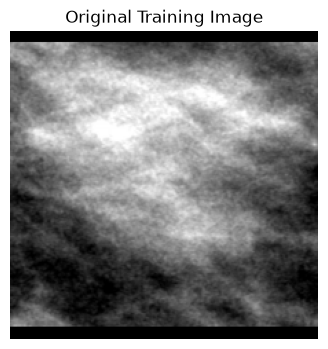

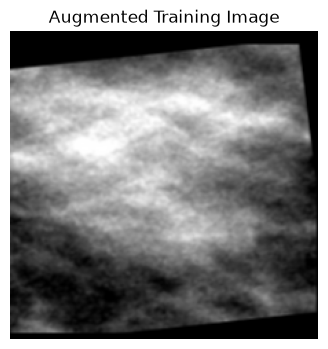

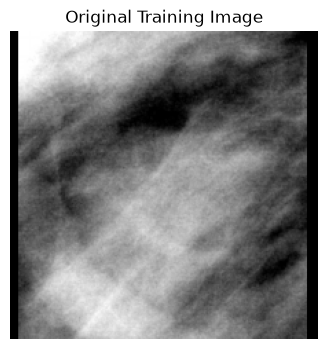

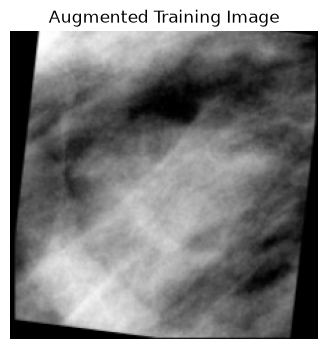

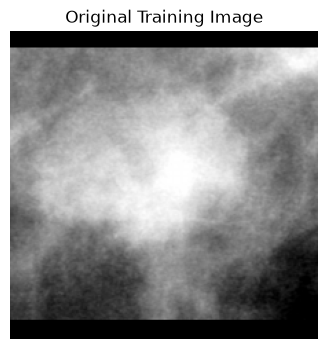

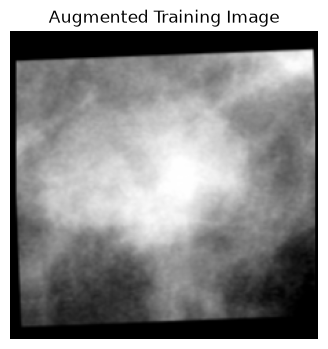

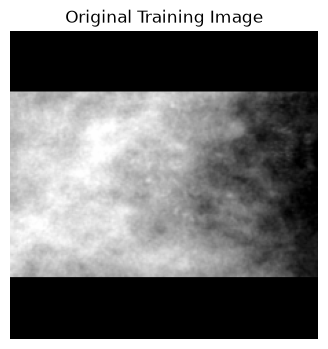

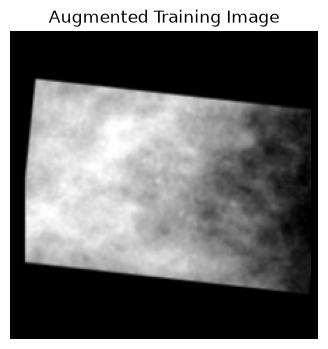

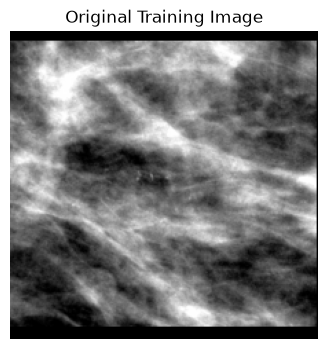

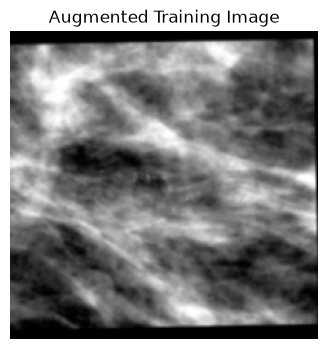

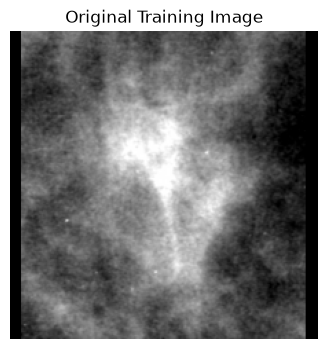

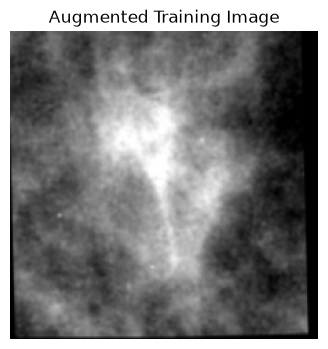

In [207]:
#compare original and augmented training images
#number of original-augmented pairs to display
number_to_display = 6

for image_index in range(
    number_to_display
):

    #display the original preprocessed image
    plt.figure(
        figsize=(4, 4)
    )

    plt.imshow(
        augmentation_images[
            image_index
        ].numpy()
    )

    plt.title(
        "Original Training Image"
    )

    plt.axis("off")
    plt.show()

    #display the corresponding randomly augmented image
    plt.figure(
        figsize=(4, 4)
    )

    plt.imshow(
        augmented_images[
            image_index
        ].numpy()
    )

    plt.title(
        "Augmented Training Image"
    )

    plt.axis("off")
    plt.show()

__Visual Interpretation__

The augmented images show small changes in rotation, position and scale relative to their original conterparts. The transformed crops remain visually recognisable, and the principle tissue-density patterns, mass-like regions and calcification clusters remains visible.

Several augmented examples contain slightly angled black borders. These are expected consequences of rotation and translation with constant zero filling rather than evidence of missing or corrupted image data. The existing aspect ratio and overall image dimensions are preserved. 

The transformations are sufficiently noticeable to prevent the model from relying on the exact position or orientation of an abnormality, but they remain conservative enough to avoid severe deformation. In particular: 

* dense mass-like regions remain present after augmentation;
* small bright calcification features remain visible;
* surrounding mammographic texture is preserved;
* no images appear vertically inverted or anatomically implausible;
* no extreme cropping or geometric stretching is evident.

This is important because the model should learn features associated with lesion appeareance rather than memorising where an abnormality commonly occurs within a crop. The random transformations expose the model to slightly different spatial presentations of the same training example, improving robustness to natural variation in lesion positioning and crop construction.

The visual comparison is a technical plausibility check rather than a radiological assesstment. It confirms that the augmentation settings do not visibly destroy the abnormalities, but it does not establish whether every transformed image remains clinically equivalent.

Overall, the numerical and visual check support the use of this conservative augmentation pipeline during training. Validation and testing remain unaugmented so that performance is measured consistently on the original deterministic image representation.

### 9.Class Distribution and Class Weighting
Before the model development, the class distribution of the training partition is examined. The binary target distinguished benign lesions `(0)` from malignant lesions `(1)`.

Unequel class frequencies can influence optimisation by causing the model to favour the more frequently represented class. This is particularly relevant in breast-cancer classification because failing to identify a malignant lesion has different clinical implications from incorrectly classifying a benign lesion.

Class weights are therefore calculated using the only training partition. They adjust each class's contribution to the training loss without duplicating records or modifying the validation and testing distributions.


### 9.1 Binary Target Validation
Before calculating class frequencies, the training targets are checked to confirm that both expected classes are present and that no target values are missing.

In [208]:
#validate the binary targets in the training partition
#extract the unique non-missing target values
training_target_values = sorted(
    train_df[
        "target"
    ]
    .dropna()
    .unique()
    .tolist()
)

print(
    "Training target values:",
    training_target_values
)

#confirm that both expected binary classes are present
assert training_target_values == [
    0,
    1
], (
    "The training partition does not contain the expected "
    "binary target values 0 and 1."
)

#confirm that every training record has a target
assert train_df[
    "target"
].notna().all(), (
    "The training partition contains missing target values."
)

print(
    "Binary target validation passed."
)

Training target values: [0, 1]
Binary target validation passed.


__Interpretation__

The training partition contains both expected target values and no missing labels. The binary outcome is therefore valid for subsequent frequency analysis and binary-classification model training.

### 9.2 Training Class Distribution
Class frequencies are calculated exclusively from the training partition because only training data may influence the model-fitting procedure. Validation data remain reserved for model selection, while testing data remain isolated for final evaluation.

In [210]:
#calculate the training set class distribution
#count the number of training records in each target class
training_class_distribution = (
    train_df[
        "target"
    ]
    .value_counts()
    .sort_index()
    .rename_axis(
        "Target"
    )
    .rename(
        "Record count"
    )
    .to_frame()
)

#add descriptive pathology labels
training_class_distribution[
    "Class label"
] = (
    training_class_distribution
    .index
    .map(
        {
            0: "Benign",
            1: "Malignant"
        }
    )
)

#calculate each class as a percentage of the training set
training_class_distribution[
    "Percentage"
] = (
    training_class_distribution[
        "Record count"
    ]
    .div(
        len(train_df)
    )
    .mul(100)
    .round(2)
)

#arrange the columns for clear presentation
training_class_distribution = (
    training_class_distribution[
        [
            "Class label",
            "Record count",
            "Percentage"
        ]
    ]
)

display(
    training_class_distribution
)
    

,Class label,Record count,Percentage
Target,,,
0,Benign,1506,59.36
1,Malignant,1031,40.64


In [211]:
#confirm that the class counts represent every training record
assert (
    training_class_distribution[
        "Record count"
    ].sum()
    == len(train_df)
), (
    "Training class count do not equal the total "
    "number of training records."
)

print(
    "Training records represented:",
    training_class_distribution[
        "Record count"
    ].sum()
)

Training records represented: 2537


__Interpretation__

All 2,537 training records are represented in the class-frequency table. Benign lesions form the majority with 1,506 records (59.36%), compared with 1,031 malignant records (40.64%).

The difference indicates a moderate class imabalance rather than an extreme one. Nevertheless, an unweighted loss would give benign records greater aggregate influence during optimisation. Calculating class weights from these training frequencies can compensate for this difference while retaining all available observations.


### 9.3 Class-Distribution Visualisation

The training-set frequencies are visualised to show the direction and extent of the imbalance before model fitting.

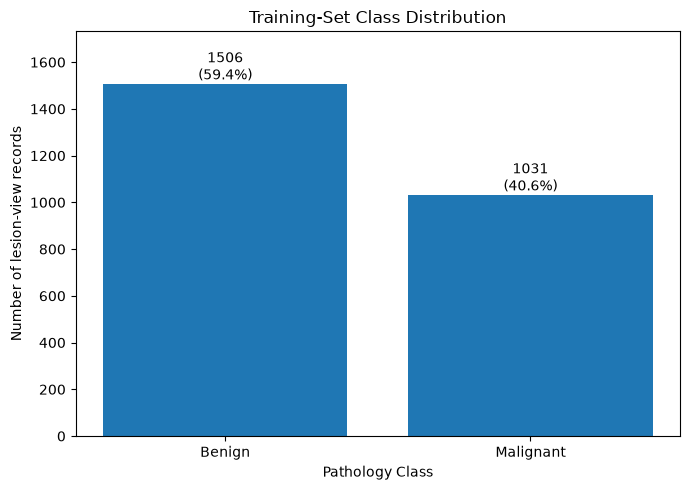

In [213]:
#visualise the training-set class distribution
#convert the index into a standard column for plotting
class_plot_data = (
    training_class_distribution
    .reset_index()
)

plt.figure(
    figsize=(7, 5)
)

#plot the number of records in each pathology class
bars = plt.bar(
    class_plot_data[
        "Class label"
    ],
    class_plot_data[
        "Record count"
    ]
)

plt.title(
    "Training-Set Class Distribution"
)

plt.xlabel(
    "Pathology Class"
)

plt.ylabel(
    "Number of lesion-view records"
)

#add vertical space for the annotations above each bar.
plt.ylim(
    0,
    class_plot_data[
        "Record count"
    ].max() * 1.15
)

#display the record count and percentage above each bar 
for bar, record_count, percentage in zip(
    bars, 
    class_plot_data[
        "Record count"
    ],
    class_plot_data[
        "Percentage"
    ]
):

    plt.text(
        bar.get_x()
        + bar.get_width() / 2,
        bar.get_height(),
        f"{record_count}\n({percentage:.1f}%)",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


__Visual Intepretation__

The bar chart clearly shoes that benign elsion-view records outnumber malignant records, although both classes remain substantially represented. The difference of 475 records confirms the moderate imbalance identified numerically. 

This visualisation supports the use of class weighting during model training: the weighting can reduce majority-class influence without altering the observed data distribution. Validation and testing records should remain unweighted and unchanged so that evaluation reflects the original partition distribution.

### 9.4 Class Distribution by Abnormality Group

Because the dataset combines mass and calcification records, the target distribution is also examined separately within each abnormality group. This determines whether the overall class distribution conceals important differences between lesion categories.

In [215]:
#examine target counts within each abnormality group
#create a contigency table of abnormality groups and targets
training_abnormality_target_counts = pd.crosstab(
    train_df[
        "abnormality_group"
    ],
    train_df[
        "target"
    ]
)

#replace numerical targets with descriptive class labels
training_abnormality_target_counts = (
    training_abnormality_target_counts
    .rename(
        columns={
            0: "Benign",
            1: "Malignant"
        }
    )
)

#calculate the total number of records in each group
training_abnormality_target_counts[
    "Total"
] = (
    training_abnormality_target_counts
    .sum(axis=1)
)

display(
    training_abnormality_target_counts
)

target,Benign,Malignant,Total
abnormality_group,,,
calcification,875,478,1353
mass,631,553,1184


In [216]:
#calcilate within group target percentages
#normalise each row so that percentages are calculated independently within each abnormality group
training_abnormality_target_percentages = (
    pd.crosstab(
        train_df[
            "abnormality_group"
        ],
        train_df[
            "target"
        ],
        normalize="index"
    )
    .mul(100)
    .round(2)
    .rename(
        columns={
            0: "Benign percentage",
            1: "Malignant percentage"
        }
    )
)

display(
    training_abnormality_target_percentages
)

target,Benign percentage,Malignant percentage
abnormality_group,,
calcification,64.67,35.33
mass,53.29,46.71


In [217]:
#confirm that every training record is represented
assert (
    training_abnormality_target_counts[
        "Total"
    ].sum()
    == len(train_df)
)

print(
    "Abnormality-group distribution validation passed."
)

Abnormality-group distribution validation passed.


__Interpretation__
The distribution differs between abnormality groups. Calcification records show a clearer benign majority, with 64.67% benign and 35.33% malignant cases. Mass records are more evenly distributed, with 53.29% benign and 46.71% malignant cases.

Therefore, the overall 59.36%~40.64% class distribution does not fully describe the composition of each lesion category. This subgroup difference should be considered during later performance analysis because a model's sensititity and specificity may very between mass and calcification cases. However, the class weights remain based on the complete training target distribution because the primary task predicts pathology across both abnormality groups.



### 9.5 Balanced Class-Weight Calculation

Balanced class weights are calculated from the class frequencies in the training partition. For class c, the weight is defined as: 

$$
w_c = \frac{N}{K \times N_c}
$$

where N is the toal number of training records, K is the number of target classes, and $N_c$ is the number of training records belonging to class c.

This method assigns greater weight to the less frequent class and lower weight to the majority class. Only training labels are used, preventing information from the validation or testing partitions from influencing model optimisation. 


In [221]:
#calculate balanced training class weights
#obtain the number of records belonging to each class
training_class_counts = (
    train_df[
        "target"
    ]
    .value_counts()
    .sort_index()
)

#record the total number of training examples
number_of_training_records = len(
    train_df
)

#determine the number of target classes
number_of_classes = len(
    training_class_counts
)

#apply the balanced class weight formular:
#total records / (number of classes x class count).
class_weights = {
    int(class_index): (
        number_of_training_records
        / (
            number_of_classes
            * int(class_count)
        )
    )
    for class_index, class_count
    in training_class_counts.items()
}

print(
    "Calculated class weights:"
)

#display each weight with its corresponding class name
for class_index, class_weight in class_weights.items():

    class_name = (
        "Benign"
        if class_index == 0
        else "Malignant"
    )

    print(
        f"Class {class_index} "
        f"({class_name}): "
        f"{class_weight:.4f}"
    )


Calculated class weights:
Class 0 (Benign): 0.8423
Class 1 (Malignant): 1.2304


__Interpretation__

The benign class receives a weight of `0.8423`, whereas the less frequent malignant class receives a larger weight of `1.2304`. During training, errors involving malignant examples will therefore contribute more strongly to the loss than errors involving individual benign examples.

These weights do not modify the images, duplicate records, or change the observed class distribution. They only adjust the contribution of each training example to the optimisation objective.

### 9.6 Class-Weight Validation

The calculated weights are validated to confirm that both target classes are represented, all weights are finite and positive, and the toal weighted contribution is equal across classes. 

In [223]:
#validate the calculated class weights
#confirm that weights exists for both binary classes
assert set(
    class_weights.keys()
) == {
    0, 
    1
}, ( 
    "Class weights were not calculated for both "
    "binary target classes."
)

#confirm that no weight is infinite or undefined
assert all(
    np.isfinite(
        class_weight
    )
    for class_weight
    in class_weights.values()
), (
    "At least one class weight is not finite."
)

#confirm that every weight is positive
assert all(
    class_weight > 0 
    for class_weight
    in class_weights.values()
), (
    "All class weights must be positive."
)

#calculate the aggregate weighted contribution of each class
weighted_class_contributions = {
    class_index: (
        training_class_counts[
            class_index
        ]
        * class_weights[
            class_index
        ]
    )
    for class_index
    in class_weights
}

print(
    "Weighted class contributions:"
)

for class_index, contribution in (
    weighted_class_contributions.items()
):

    print(
        f"Class {class_index}: "
        f"{contribution:.2f}"
    )

#confirm that both classes have approximately equal aggregate influence under the calculated weights
assert np.isclose(
    weighted_class_contributions[0],
    weighted_class_contributions[1]
), (
    "Balanced class weighting did not produce "
    "approximately equal class contributions."
)

print(
    "Class-weight validation passed."
)

Weighted class contributions:
Class 0: 1268.50
Class 1: 1268.50
Class-weight validation passed.


__Interpretation__

Both classes produce an aggregate weighted contribution of `1268.50`. This confirms that the calculated weights compensate correctly for the frequency difference: the greater number of benign examples is offset by a smaller per-example weight, while the smaller malignant class receiver a larger per-example weight.

This balance applies to the training loss only. It does not imply that the original dataset contains equal numbers of benign and malignant records.

### 9.7 Final Model-Development Dataset Summary

The final partition sizes and class distributions are summarised before model construction. Class weights are associated only with the training partition and will be supplied during model fitting.

In [224]:
#summarise target distributions across all partitions
def summarise_partition_targets(
    metadata,
    partition_name
):
    """
    Summarise the binary target distribution of one metadata partition.

    Parameters
    -----------
    metadata : pandas.DataFrame
        Partition metadata containing the target column.

    partition_name : str
        Descriptive name of the partition
        
    Returns
    ----------
    dict
        Partition size, class counts and percentages.
    """

    #count the records belonging to each target class
    target_counts = (
        metadata[
            "target"
        ]
        .value_counts()
    )

    #retrieve each count safely. returning zero if absent
    benign_count = int(
        target_counts.get(
            0,
            0
        )
    )

    malignant_count = int(
        target_counts.get(
            1,
            0
        )
    )

    #return a complete partition summary
    return {
        "Partition": partition_name, 
        "Total records": len(metadata),
        "Benign records": benign_count,
        "Malignant records": malignant_count,
        "Benign percentage": round(
            benign_count
            / len(metadata)
            * 100,
            2
        ),
        "Malignant percentage": round(
            malignant_count
            / len(metadata)
            * 100,
            2
        )
    }

#generate summaries for the three experimental partitions
model_dataset_summary = pd.DataFrame(
    [
        summarise_partition_targets(
            train_df,
            "Training"
        ),
        summarise_partition_targets(
            val_df,
            "Validation"
        ),
        summarise_partition_targets(
            test_df,
            "Testing"
        )
    ]
)

display(
    model_dataset_summary
)    

,Partition,Total records,Benign records,Malignant records,Benign percentage,Malignant percentage
0,Training,2537,1506,1031,59.36,40.64
1,Validation,504,300,204,59.52,40.48
2,Testing,527,305,222,57.87,42.13


In [225]:
#validate the final partition summary
#confirm that the partition totals reproduce the complete dataset
assert(
    model_dataset_summary[
        "Total records"
    ].sum()
    == len(
        combined_metadata
    )
), (
    "The model-development partition total do not "
    "match the complete metadata table."
)

#confirm the training-partition total
assert model_dataset_summary.loc[
    model_dataset_summary[
        "Partition"
    ] == "Training",
    "Total records"
].iloc[0] == len(
    train_df
)

#confirm the validation-partition total
assert model_dataset_summary.loc[
    model_dataset_summary[
        "Partition"
    ] == "Validation",
    "Total records"
].iloc[0] == len(
    val_df
)

#confirm the testing-partition total
assert model_dataset_summary.loc[
    model_dataset_summary[
        "Partition"
    ] == "Testing",
    "Total records"
].iloc[0] == len(
    test_df
)

print(
    "Final model-development dataset summary validated."
)


Final model-development dataset summary validated.


__Final Interpretation__

The three partitions have closely comparable class distributions. Benign records account for 59.36% of training data, 59.52% of validation data and 57.87% of testing data. This consistency indicates that the partitioning procedure preserved the overall pathology distribution while maintaining patient-level separation.

The training imbalance is moderate, with benign records forming the majority. Balanced class weighting gives the less frequent malignant class greater influence during optimisation, producing equal aggregate weighted contributions across the two classes.

Class weights will be applied only during model fitting. Validation and testing datasets remain unweighted and unchanged, ensuring that model selection and final evaluation reflect their observed class distributions. Subgroup performance should later be reported separately for mass and calcification records because their benign-malignant proportions differ.

### 10. Baseline Convolutional Neural Network
A custom convolutional neural network is developed to provide a transparent baseline for mammographic lesion classification. 

The baseline is intentionally less complex than the transfer-learning architectures introduced later. Its purpose is to measure how effectively a conventional CNN can learn discriminative features directly from the preprocessed CBIS-DDSM images without using pretrained feature representations.

The network accepts images with dimensions 224 x 224 x 3 and produces a single signmoid probability representing the estimated probability of malignancy. Training-only augmentation is incorporated into the model architecture, allowing it to operate during optimisation while remaining inactive during validation, testing and inference.


### 10.1 Random-Seed Configuration
Random seeds are configured before model construction to improve the reproducibility of weight initialisation, data augmentation and other stochastic operations.

In [226]:
#configure random seeds for model development
import os 
import random

MODEL_RANDOM_SEED = 42

#configure the python hash seed.
#full hash level reproducibility requires this environment
#variable to be set before the python interpreter starts
os.environ["PYTHONHASHSEED"] = str(
    MODEL_RANDOM_SEED
)

#seed pythons built in random number generator
random.seed(
    MODEL_RANDOM_SEED
)

#seed numpy operations
np.random.seed(
    MODEL_RANDOM_SEED
)

#seed tensorflow and keras operations
tf.keras.utils.set_random_seed(
    MODEL_RANDOM_SEED
)

print(
    "Model-development random seed:",
    MODEL_RANDOM_SEED
)

Model-development random seed: 42


__Interpretation__ 

A common seed of *42* is applied across Python, NumPy and TensorFlow to reduce variaton between repeated experiments. This improves reproducibility, although exact numerical replication may still depend on the hardware, TensorFlow version and availability of deterministic GPU operations.

### 10.2 Baseline Convolutional Neural Network
The baseline network contains four convolutional feature-extraction blocks. Each block uses two 3 x 3 convolutional layers with batch normalisation and ReLu activation. The first three blocs are followed by max pooling and progressively stronger dropout, while the fourth block feeds directly into global average pooling.

The number of filters increases from 32 to 256 as spatial dimensions decrease. This allows early layers to detect local intensity and texture patterns, while deeper layers construct higher-level lesion representations.

Global average pooling replaces a large flattened feature vector, substantially reducing the number of dense-layer parameters. A 128-unit regularised dense layer performs the final feature combination, and a one-unit sigmoid layer generates the malignancy probability.

In [229]:
#define the custom baseline CNN
def build_baseline_cnn(
    input_shape=(
        TARGET_IMAGE_SIZE[0],
        TARGET_IMAGE_SIZE[1],
        OUTPUT_CHANNELS
    )
):

    """
    Construct the custom baseline convolutional neural network

    Parameters
    ----------
    input_shape : tuple
        Model input height, width and number of channels.
        
    Returns
    ----------
    tf.keras.Model
        Uncompiled binary-classification model.
    """

    #define the model input
    inputs = tf.keras.Input(
        shape=input_shape,
        name="mammogram_input"
    )

    #apply stochastic augmentation during training only
    x = data_augmentation(
        inputs
    )

    #convolutional block 1: 224 x 224 --> 112 x 112
    # =============================================
    x = tf.keras.layers.Conv2D(
        filters=32,
        kernel_size=3,
        padding="same",
        use_bias=False,
        kernel_initializer="he_normal"
    )(x)

    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation("relu")(x)

    x = tf.keras.layers.Conv2D(
        filters=32,
        kernel_size=3,
        padding="same",
        use_bias=False,
        kernel_initializer="he_normal"
    )(x)

    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation("relu")(x)

    x = tf.keras.layers.MaxPooling2D(
        pool_size=2
    )(x)

    x = tf.keras.layers.Dropout(
        rate=0.15
    )(x)

    #convolutional block 2: 112 x 112 --> 56 x 56
    # =============================================
    x = tf.keras.layers.Conv2D(
        filters=64,
        kernel_size=3,
        padding="same",
        use_bias=False,
        kernel_initializer="he_normal"
    )(x)

    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation("relu")(x)

    x = tf.keras.layers.Conv2D(
        filters=64,
        kernel_size=3,
        padding="same",
        use_bias=False,
        kernel_initializer="he_normal"
    )(x)

    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation("relu")(x)

    x = tf.keras.layers.MaxPooling2D(
        pool_size=2
    )(x)

    x = tf.keras.layers.Dropout(
        rate=0.20
    )(x)

      #convolutional block 3: 56 x 56 --> 28 x 28
    # =============================================
    x = tf.keras.layers.Conv2D(
        filters=128,
        kernel_size=3,
        padding="same",
        use_bias=False,
        kernel_initializer="he_normal"
    )(x)

    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation("relu")(x)

    x = tf.keras.layers.Conv2D(
        filters=128,
        kernel_size=3,
        padding="same",
        use_bias=False,
        kernel_initializer="he_normal"
    )(x)

    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation("relu")(x)

    x = tf.keras.layers.MaxPooling2D(
        pool_size=2
    )(x)

    x = tf.keras.layers.Dropout(
        rate=0.25
    )(x)

      #convolutional block 4: deeper feature extraction
    # =============================================
    x = tf.keras.layers.Conv2D(
        filters=256,
        kernel_size=3,
        padding="same",
        use_bias=False,
        kernel_initializer="he_normal"
    )(x)

    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation("relu")(x)

    x = tf.keras.layers.Conv2D(
        filters=256,
        kernel_size=3,
        padding="same",
        use_bias=False,
        kernel_initializer="he_normal"
    )(x)

    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation("relu")(x)

    #convert each feature map into one summary value, avoiding a large flattened representation
    x = tf.keras.layers.GlobalAveragePooling2D(
        name="global_average_pooling"
    )(x)

    #combine the extracted features while applying L2 regularisation toreduce overfitting
    x = tf.keras.layers.Dense(
        units=128,
        activation="relu",
        kernel_regularizer=tf.keras.regularizers.l2(
            1e-4
        ),
        name="classification_dense"
    )(x)

    #apply stronger regularisation before classification
    x = tf.keras.layers.Dropout(
        rate=0.40,
        name="classification_dropout"
    )(x)

    #return one malignancy probability for each image
    outputs = tf.keras.layers.Dense(
        units=1,
        activation="sigmoid",
        name="malignancy_probability"
    )(x)

    model = tf.keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="baseline_cnn"
    )

    return model

### 10.3 Model Construction and Structural Validation
The baseline CNN is instantiated and inspected before compilation. Structural validation confirms that the model accepts the expected image dimensions and returns one probability per input image.

In [230]:
#construct and inspect the baseline CNN
#clear previously registered Keras models and layer names
tf.keras.backend.clear_session()

#construct a new baseline model instance
baseline_model = build_baseline_cnn()

#display the layer sequence, output shapes and parameters
baseline_model.summary()

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mammogram_input (InputLayer)    │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ training_data_augmentation      │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,45

 Total params: 1,208,161 (4.61 MB)

 Trainable params: 1,206,241 (4.60 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [231]:
#validate the model input, output and parameter count
expected_model_input_shape = (
    None, 
    TARGET_IMAGE_SIZE[0],
    TARGET_IMAGE_SIZE[1],
    OUTPUT_CHANNELS
)

#confirm the expected input dimensions
assert(
    baseline_model.input_shape
    == expected_model_input_shape
)

#confirm that one probability is returned per image
assert (
    baseline_model.output_shape
    == (
        None,
        1
    )
)

#confirm that the model contains parameters to optimise
assert baseline_model.count_params() > 0

print(
    "Baseline CNN structural validation passed."
)

print(
    "Total model parameters:",
    f"{baseline_model.count_params():,}"
)

Baseline CNN structural validation passed.
Total model parameters: 1,208,161


__Intepretation___

The model accepts batches 224 x 224 x 3 images and returns an output with shape (None, 1), as required for binary classification. The spatial dimensions decrease from 224 x 224 to 28 x 28 through three max-pooling operations, while the feature depth increases from 32 to 256 channels.

The model contains 1,208,161 parameters, of which 1,206,241 are trainable. The 1,920 non-trainable parameters correspond to the moving mean and variance maintained by the batch-normalisation layers. The relatively compact parameter count is supported by global average pooling, which avoids introducing a large flattened dense layer.

### 10.4 Forward-Pass Validation

Before optimisation, one training mini-bacth is passed through the untrained model. This confirms compatibility between the TensorFlow input pipeline and the network architecture.

The output must contain one finite sigmoid probability for each input image, with all values constrained to the interval [0, 1].

In [233]:
#test an untrained forward pass
#retrieve one preprocessed mini-batch
forward_pass_images, forward_pass_targets, = next(
    iter(train_dataset)
)

#generate predictions in inference mode 
#this disables augmentation and dropout and uses the inference behaviour of batch-normalisation layers
forward_pass_predictions = baseline_model(
    forward_pass_images,
    training=False
)

print(
    "Input batch shape:",
    forward_pass_images.shape
)

print(
    "Prediction shape:",
    forward_pass_predictions.shape,
)

print(
    "Prediction range:",
    (
        float(
            tf.reduce_min(
                forward_pass_predictions
            ).numpy()
        ),
        float(
            tf.reduce_max(
                forward_pass_predictions
            ).numpy()
        )
    )
)

Input batch shape: (32, 224, 224, 3)
Prediction shape: (32, 1)
Prediction range: (0.5470309853553772, 0.638530433177948)


In [234]:
#validate the forward-pass outputs
#confirm that each image produces one prediction
assert (
    forward_pass_predictions.shape
    == (
        forward_pass_images.shape[0],
        1
    )
)

#confirm that every prediction is numerically valid
assert bool(
    tf.reduce_all(
        tf.math.is_finite(
            forward_pass_predictions
        )
    ).numpy()
)

#confirm that the sigmoid outputs are within [0, 1]
assert (
    float(
        tf.reduce_min(
            forward_pass_predictions
        ).numpy()
    )
    >= 0.0
)

assert (
    float(
        tf.reduce_max(
            forward_pass_predictions
        ).numpy()
    )
    <= 1.0
)

print(
    "Baseline CNN forward-pass validation passed."
)

Baseline CNN forward-pass validation passed.


__Interpretation__

The input contains 32 images with the expected dimensions, and the model produces 32 corresponding scalar probabilies. All predictions are finite and lie within the valid sigmoid range.

The values between approximately `0.54` and `0.64` do not represent meaningful classification performance because the network has not yet been trained. Their purpose is only to confirm that the complete image-to-prediction pathway operates correctly. Model performance should be interpreted only after compilation, optimisation and evaluation on unseen data.

### 10.5 Training Objective and Evaluation Metrics
Binary cross-entropy is used as the optimisation objective because the task involves binary classification and the model produces a single sigmoid probability.

The Adam optimiser is configured with an initial learning rate of 1 x $10^{-3}$. Multiple complementary metrics are monitored because ccuracy alone may conceal clinically important differences between false-positive and false-negative predictions.

Binary accuracy, precision and recall are calculated at a threshold of `0.5`. Recall represents the proportion of malignant records correctly identified, while precision measures the proportion of predicted malignant records that are genuinely malignant. ROC-AUC evaluates discrimination across all classification thresholds, and precision-recall AUC emphasises performance on the positive malignant class.

In [236]:
#configure the training objective and evaluation metrics
#define the initial Adam learning rate
INITIAL_LEARNING_RATE = 1e-3

#configure complementary binary-classification metrics
baseline_metrics = [
    
    #proportion of correct classifications at a threshold of 0.5
    tf.keras.metrics.BinaryAccuracy(
        name="binary_accuracy",
        threshold=0.5
    ),
    
    #proportion of predicted malignant records that are malignant 
    tf.keras.metrics.Precision(
        name="precision",
        thresholds=0.5
    ),

    #proportion of malignant records correctly identified 
    tf.keras.metrics.Recall(
        name="recall",
        thresholds=0.5
    ),

    #threshold-independent area under the ROC curve
    tf.keras.metrics.AUC(
        name="roc_auc",
        curve="ROC"
    ),

    #area under the precision-recall curve
    tf.keras.metrics.AUC(
        name="pr_auc",
        curve="PR"
    )
]

#compile the model using Adam and binary cross-emptropy
baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=INITIAL_LEARNING_RATE
    ),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=baseline_metrics
)

print(
    "Baseline CNN compiled successfully."
)

print(
    "Initial learning rate:",
    INITIAL_LEARNING_RATE
)

Baseline CNN compiled successfully.
Initial learning rate: 0.001


__Intepretation__

The model has been configured for pr
obabilistic binary classification. Binary cross-entropy guides parameter optimisation, while the selected metrics capture threshold-dependent classification performance and threshold-independent discrimination. These training emtrics support model monitoring but do not replace the later comprehensive evaluation on the held-out testing partition.

### 10.6 Training Control and Model Checkpointing

Four callbacks are configured to control training, preserve the best-performing model and stop optimisation if numerical instability occurs.

Early stopping and model checkpointing monitor validation ROC-AUC because the primary selection criterion is threshold-independent descrimination. Learning-rate reduction instead monitors validation loss, allowing smaller optimisation steps when probabilistic performance stops improving. `TerminateOnNaN` provides an additional safety mechanism by stopping training if the loss becomes undefined.

In [237]:
#configure the model checkpoint directory
from pathlib import Path

#create the output directorry if it does not already exist
MODEL_DIRECTORY = Path(
    "models"
)

MODEL_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True
)

#define the path used to save the best complete model
BASELINE_MODEL_PATH = (
    MODEL_DIRECTORY
    / "baseline_cnn_best.keras"
)

print(
    "Baseline checkpoint path:",
    BASELINE_MODEL_PATH.resolve()
)


Baseline checkpoint path: /Users/marcela/FinalProject/models/baseline_cnn_best.keras


In [238]:
#configure training control callbacks
baseline_callbacks = [
    
    #stop when validation ROC-AUC has not improved for seven epochs and restore the best in memory weights
    tf.keras.callbacks.EarlyStopping(
        monitor="val_roc_auc",
        mode="max",
        patience=7,
        min_delta=1e-4,
        restore_best_weights=True,
        verbose=1
    ),

    #halve the learning rate when validation loss stops improving for three consecutive epochs
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=3,
        min_delta=1e-4,
        min_lr=1e-6,
        verbose=1
    ),

    #save the complete model associated with the highest validation ROC-AUC
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(
            BASELINE_MODEL_PATH
        ),
        monitor="val_roc_auc",
        mode="max",
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    ),

    #stop immediately if the loss becomes NaN
    tf.keras.callbacks.TerminateOnNaN()
]

print(
    "Baseline callbacks configured:",
    len(baseline_callbacks)
)

Baseline callbacks configured: 4


__Interpretation__

The callback configuration separates optimisation control fro model selection. Validation loss controls learning-rate adjustment, while validation ROC-AUC determines early stopping and checkpoint preservation. Consequently, the retained model corresponds to the strongest validation discrimination rather than necessarily the lowest validation loss or highest threshold-specific accuracy.

### 10.7 Baseline Model Training
The baseline CNN is trained using the augmented training dataset and evaluated after every epoch using the unchanged validation dataset.

Balanced class weights are supplied only during optimisation. They increase the loss contribution of the less frequent malignant class without changing the validation data or the calculation of validation metrics.

A maximum of 40 epochs is permitted, although early stopping may terminate training sooner if validation ROC-AUC no longer improves.

In [240]:
#train the baseline CNN
BASELINE_MAX_EPOCHS = 40

baseline_history = baseline_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=BASELINE_MAX_EPOCHS,
    class_weight=class_weights,
    callbacks=baseline_callbacks,
    verbose=1
)

Epoch 1/40
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - binary_accuracy: 0.5631 - loss: 0.7173 - pr_auc: 0.4644 - precision: 0.4612 - recall: 0.5142 - roc_auc: 0.5794
Epoch 1: val_roc_auc improved from None to 0.59922, saving model to models/baseline_cnn_best.keras

Epoch 1: finished saving model to models/baseline_cnn_best.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - binary_accuracy: 0.5778 - loss: 0.7044 - pr_auc: 0.4823 - precision: 0.4831 - recall: 0.5538 - roc_auc: 0.5986 - val_binary_accuracy: 0.4464 - val_loss: 1.7458 - val_pr_auc: 0.4673 - val_precision: 0.4220 - val_recall: 0.9951 - val_roc_auc: 0.5992 - learning_rate: 0.0010
Epoch 2/40
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - binary_accuracy: 0.5894 - loss: 0.6740 - pr_auc: 0.5312 - precision: 0.4893 - recall: 0.6280 - roc_auc: 0.6396
Epoch 2: val_roc_auc improved from 0.59922 to 0.60317, saving model to models/baseline_cnn_best.keras

Epoch 2: finished saving model to models/baseline_cnn_best.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 14

__Training Interpretation__

Training ended after epochs 11 rather than reaching the maximum of 40. Validation ROC-AUC reached its highest value of `0.6552` at epoch 4. Because the following seven epochs did not produce the required improvement, early stopping was triggered at epoch 11 and the model weights from epoch 4 were restored. The saved checkpoint therefore also corresponds to epoch 4.

Training ROC-AUC increased from `0.5986` at epoch 1 to `0.6816` at epoch 11, indicating that the network progressively learned discriminative patterns from the training images. However, validation ROC-AUC fluctuated and did not improve beyond epoch 4. This divergence suggests that continued optimisation improved training performance without producing a consistent improvement in validation discrimination. Early stopping therefore prevented further training after generalisation had plateaued.

The learning rate was reduced from `0.001` to `0.0005` after epoch 6 and then to `0.00025` after epoch 10 because validation loss had stopped improving consistently. Although these reductions allowed smaller optimisation updates, they did not produce a validation ROC-AUC higher than the epoch-4 result.

Validation precision and recall varied substantially at the fixed threshold of `0.5`. Some epochs classified almost every validation example as malignant, producing recall close to `1.0` but low precision and accuracy. Other epochs predicted relatively few malignant cases, producing very low recall. This instability indicates that the model's probability outputs were not yet well calibrated around the default threshold.

For this reason, validation ROC-AUC provides a more reliable checkpoint-selection criterion than the threshold-dependent metrics at the stage. The final operating threshold should be selected separately using validation data, and the restored epoch-4 model must subsequently be evaluated  on the untouched testing partition.

### 10.8 Training History Preservation
The epoch-level training history is converted into a dataframe for inspection, visualisation and reproducible comparison with the transfer-learning models developed later.


In [241]:
#convert the training history into a dataframe
baseline_history_df = pd.DataFrame(
    baseline_history.history
)

#number epochs from one rather than zero
baseline_history_df.index = (
    baseline_history_df.index + 1
)

baseline_history_df.index.name = "Epoch"

display(
    baseline_history_df
)

,binary_accuracy,loss,pr_auc,precision,recall,roc_auc,val_binary_accuracy,val_loss,val_pr_auc,val_precision,val_recall,val_roc_auc,learning_rate
Epoch,,,,,,,,,,,,,
1,0.577848,0.704377,0.482344,0.483080,0.553831,0.598617,0.446429,1.745813,0.467342,0.422037,0.995098,0.599224,0.00100
2,0.582184,0.684981,0.505211,0.488465,0.595538,0.621110,0.428571,0.987031,0.455306,0.414634,1.000000,0.603170,0.00100
3,0.590067,0.677168,0.518203,0.496624,0.642095,0.630651,0.585317,0.682727,0.460857,0.464789,0.161765,0.601560,0.00100
4,0.599527,0.671501,0.535106,0.506163,0.597478,0.643200,0.521825,0.742011,0.514283,0.457471,0.975490,0.655204,0.00100
5,0.581395,0.665439,0.535747,0.488999,0.668283,0.643481,0.595238,0.724866,0.461422,0.500000,0.009804,0.616626,0.00100
6,0.600709,0.668262,0.538828,0.507258,0.610087,0.643116,0.587302,0.817298,0.508174,0.492806,0.671569,0.637092,0.00100
7,0.595191,0.662918,0.536909,0.501458,0.667313,0.645690,0.571429,0.666058,0.508030,0.478873,0.666667,0.628039,0.00050
8,0.595585,0.654241,0.567297,0.501752,0.694471,0.665848,0.575397,0.685191,0.420885,0.307692,0.039216,0.550294,0.00050
9,0.617265,0.651626,0.563889,0.522422,0.677983,0.673594,0.595238,0.694274,0.516428,0.500000,0.725490,0.654485,0.00050


__Training-History Interpretation__

The history records 11 completed epochs before early stopping. Training loss decreased from `0.7044` to `0.6436`, while training ROC-AUC increased from `0.5986` to `0.6816`. These trends confirm that the baseline CNN progressively learned discriminative patterns from the training images.

Validation performance was less consistent. Validation ROC-AUC reached its highest value of `0.6552` at epoch 4 and did not subsequently improve. Although epoch 9 approached this result with a validation ROC-AUC of `0.6545`, it did not exceed the existing checkpoint. Early stopping therefore restored the epoch-4 weights after seven consecutive epochs without sufficient improvement.

The fixed-threshold validation metrics fluctuated substantially. Validation recall ranged from `0.0098` to `1.0000`, accompanied by corresponding changes in precision and accuracy. This suggests that small changes in the predicted probabilities moved many records across the default `0.5` threshold. In contrast, ROC-AUC evaluates discrimination across thresholds and was therefore used as the more stable model selection criterion.

Validation loss reached its lowest value of approximately `0.6661` at epoch 7. Because it did not continue improving, the learning rate was reduced from `0.001` to `0.0005`, and later to `0.00025`. This history displays each learning rate during the epoch in which it was used; therefore, reductions made at the end of an epoch appear in the following row.

The dataframe preserves all 11 completed epochs, including those occurring after the best checkpoint. However, the final in-memory mdoel contains the restored weights from epoch 4. The table describes the complete optimisation process and should not be intepreted as meaning that the epoch-11 weights were retained. Definitive performance must be obtained by evaluating the restored model on the validation and testing datasets.

In [243]:
#save the complete epoch level training history
BASELINE_HISTORY_PATH = (
    MODEL_DIRECTORY
    / "baseline_cnn_history.csv"
)

baseline_history_df.to_csv(
    BASELINE_HISTORY_PATH,
    index=True
)

print(
    "Training history saved to:",
    BASELINE_HISTORY_PATH.resolve()
)

Training history saved to: /Users/marcela/FinalProject/models/baseline_cnn_history.csv


The complete training history was saved successfully as a CSV file. Preserving these values enables later reconstruction of learning curves and consistent comparison between the baseline CNN and the transfer-learning architectures. The checkpoint and history serve different purposes: the `.keras` file preserves the selected model, while the CSV records how training and validation performance changed across epochs.

### 10.9 Best-Epoch Identification

The epoch achieving the highest validation ROC-AUC is identified from the saved training history. This corresponds to the selection criterion used by both early stopping and model checkpointing.

ROC-AUC is used because it measures discrimination across classification thresholds and is less sensitive than accuracy, precision or recall to temporary movements around the default threshold of `0.5`.

In [244]:
#identify the epoch with the highest validation ROC-AUC
#locate the index of the max validation ROC-AUC
best_epoch_index = (
    baseline_history_df[
        "val_roc_auc"
    ]
    .idxmax()
)

#retrieve all recorded metrics from the selected epoch
best_epoch_results = (
    baseline_history_df.loc[
        best_epoch_index
    ]
)

print(
    "Best validation epoch:",
        best_epoch_index
)

print(
    "Best validation ROC-AUC:",
    f"{best_epoch_results['val_roc_auc']:.4f}"
)

print(
    "Validation PR-AUC:",
    f"{best_epoch_results['val_pr_auc']:.4f}"
)

print(
    "Validation loss:",
    f"{best_epoch_results['val_loss']:.4f}"
)

print(
    "Validation accuracy:",
    f"{best_epoch_results['val_binary_accuracy']:.4f}"
)

print(
    "Validation precision ar 0.5:",
    f"{best_epoch_results['val_precision']:.4f}"
)

print(
    "Validation recall at 0.5:",
    f"{best_epoch_results['val_recall']:.4f}"
)


Best validation epoch: 4
Best validation ROC-AUC: 0.6552
Validation PR-AUC: 0.5143
Validation loss: 0.7420
Validation accuracy: 0.5218
Validation precision ar 0.5: 0.4575
Validation recall at 0.5: 0.9755


In [245]:
#validate the best epoch identification
#confirm that the selected epoch exists in the history
assert best_epoch_index in baseline_history_df.index

#confirm that its ROC-AUC equals the recorded maximum
assert np.isclose(
    best_epoch_results[
        "val_roc_auc"
    ],
    baseline_history_df[
        "val_roc_auc"
    ].max()
), (
    "The selected epoch does not contain the highest "
    "validation ROC-AUC."
)

#confirm consistency with the epoch restored by the early stopping callback in this training run
assert best_epoch_index == 4, (
    "The identified epoch does not match the epoch "
    "restored by early stopping."
)

print(
    "Best-epoch identification validated."
)

Best-epoch identification validated.


__Interpretation__

The highest validation ROC-AUC of `0.6552`occured at epoch 4, confirming the epoch selected by model checkpointing and subsequently restored by early stopping. The result indicates modest discrimination between benign and malignant lesion records and established the performance reference for comparison with the later transfer-learning models.

At the default threshold of `0.5`, the selected model achieved high validation call `(0.9755)` but lower precision`(0.4575)` and accuracy `(0.5218)`. This means that the model identified nearly all malignant validation records but also classified many benign records as malignant. The operating point therefore favoured sensitivity over specificity. 

The relatively high recall should not be interpreted independently as strong overall performance. It reflects the behaviour of one threshold, whereas the ROC-AUC summarises discrimination across all thresholds. A separate validation-based threshold-selection procedure is required later to obtain a more appropiate balance between sensitivity and false-positive predictions.

The best ROC-AUC epoch does not have the lowest validation loss or the highest value of every other metric. This is expected because checkpoint selection was explicitly based on validation ROC-AUC. The untouched testing partition must not be used to revise this epoch selection or choose the classification threshold.

### 10.10 Learning-Curve Analysis


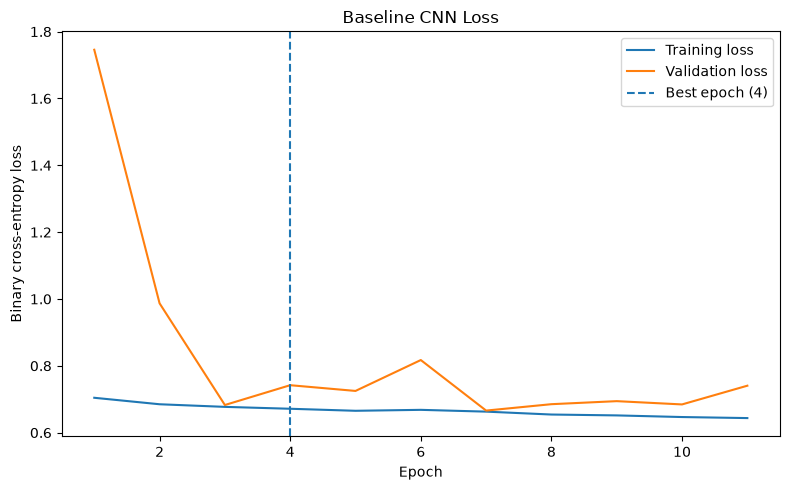

In [247]:
#plot the baseline CNN training and validation losses
plt.figure(
    figsize=(8, 5)
)

#plot the loss calculated from augmented, class weighted training batches
plt.plot(
    baseline_history_df.index,
    baseline_history_df["loss"],
    label="Training loss"
)

#plot the loss calculated from the unchanged and unweighted validation dataset
plt.plot(
    baseline_history_df.index,
    baseline_history_df["val_loss"],
    label="Validation loss"
)

#mark the epoch selected using maximum validation ROC-AUC
plt.axvline(
    x=best_epoch_index,
    linestyle="--",
    label=f"Best epoch ({best_epoch_index})"
)

plt.title(
    "Baseline CNN Loss"
)

plt.xlabel(
    "Epoch"
)

#reported loss includes binary cross entropy and the contribution of L2 regularisation
plt.ylabel(
    "Binary cross-entropy loss"
)

plt.legend()
plt.tight_layout()
plt.show()
    

__Visual Interpretation__

Training loss decreased gradually from approximately `0.704` to`0.644`, indicating continued optimisation throughout training. Validation loss dropped sharply during the first three epochs, suggesting that the initially unstable preddictions became more appropiate for the validation data. It then fluctuated rather than following the steady training trend, indicating variable generalisation between epochs.

The lowest validation loss occured at epoch 7, whereas the highest validation ROC-AUC accured at epoch 4. This difference is expected because loss evaluates the quality of the predicted probabilities, while ROC-AUC evaluates how efectively the model ranks malignant cases above benign cases across thresholds. The dashed line threfore marks the epoch selected according to the predefined model-selection criterion, not the minimum-loss epoch.

The later reduction in training loss was not accompanied by consistent validation-loss improvement, providing some evidence that further optimisation was not improving generalisation reliably. This supports the use of checkpointing and early stopping. However, the vertical distance between the curves should not th interpreted as a direct overfitting measure because training uses augmentation and class weighting while validation does not.


### ROC-AUC Curve

ROC-AUC curves are compared to examine how discrimination changes during training. Unlike accuracy, precision and recall at a fixed threshold, ROC-AUC evaluates how effectively the model ranks malignant records above benign records across all possible thresholds.

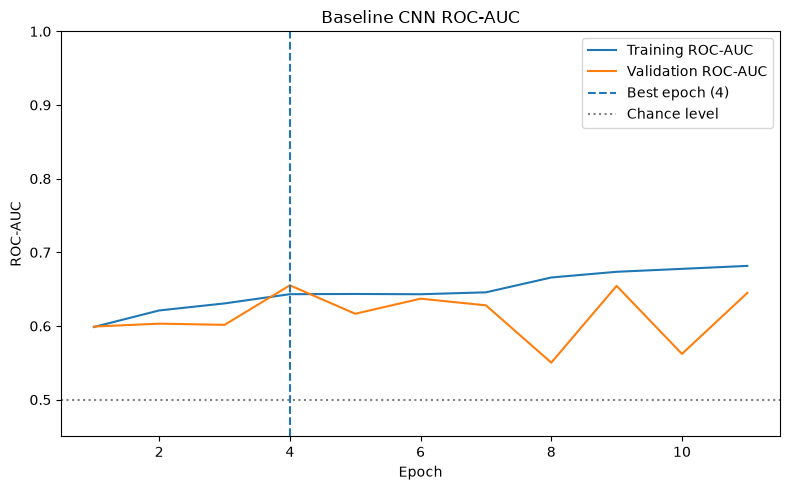

In [250]:
#plot training and validation roc-auc
#plot the training
plt.figure(
    figsize=(8, 5)
)

#plot discrimination on the augmented training data
plt.plot(
    baseline_history_df.index,
    baseline_history_df["roc_auc"],
    label="Training ROC-AUC"
)

#plot discrimination on the unchanged validation data
plt.plot(
    baseline_history_df.index,
    baseline_history_df["val_roc_auc"],
    label="Validation ROC-AUC"
)

#mark the epoch selected using maximum validation ROC-AUC
plt.axvline(
    x=best_epoch_index,
    linestyle="--",
    label=f"Best epoch ({best_epoch_index})"
)

#show the discrimination expected from random ranking
plt.axhline(
    y=0.5,
    color="gray",
    linestyle=":",
    label="Chance level"
)

plt.title(
    "Baseline CNN ROC-AUC"
)

plt.xlabel(
    "Epoch"
)

#reported loss includes binary cross entropy and the contribution of L2 regularisation
plt.ylabel(
    "ROC-AUC"
)

plt.ylim(
    0.45,
    1.0
)

plt.legend()
plt.tight_layout()
plt.show()
    

__Visual Interpretation__

Training ROC-AUC increased gradually from approximately `0.599` to `0.682`, indicating that the network became preggressively better at discriminating between benign and malignant training records.

Validation ROC-AUC improved to its maximum of 0.655 at epoch 4 but fluctuated thereafter, including marked declines at epoch 8 and 10. Epoch 9 approached the best result but did not exceed it. This pattern indicates that additional training improved discrimination on the training data without producing consistent validation gains. 

The dashed vertical line confirms that epoch 4 was approximately selected and restored. Its validation ROC-AUC above the `0.5` chance level demonstrates the the baseline learned useful discriminatory information, although the modest value and subsequent instability leave scope for improvement through transfer learning. These validation results guide model selection; final generalisation must still be assessed using the untouched testing partition.

### Precision-Recall AUC Curve

PR-AUC evaluates the balance between precision and recall across classification thresholds, with malignant lesions treated as the positive class. It is particularly useful when class frequencies are unequal because its reference level depends on the prevalence of the positive class.

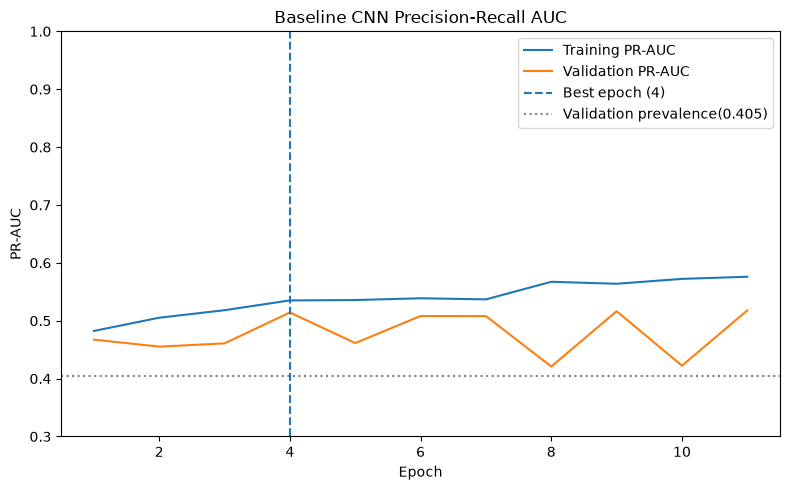

In [257]:
#plot training and validation precision-recall AUC
##calculate the malignant class prevalence in the validation partition. 
#This represents the approximate PR-AUC expected from a random classifier
validation_positive_prevalence = (
    val_df["target"].mean()
)

plt.figure(
    figsize=(8, 5)
)

#plot training performance for the malignant class
plt.plot(
    baseline_history_df.index,
    baseline_history_df["pr_auc"],
    label="Training PR-AUC"
)

#plot performance on the unchanged validation data
plt.plot(
    baseline_history_df.index,
    baseline_history_df["val_pr_auc"],
    label="Validation PR-AUC"
)

#mark the epoch selected using validation ROC-AUC
plt.axvline(
    x=best_epoch_index,
    linestyle="--",
    label=f"Best epoch ({best_epoch_index})"
)

#show the positive class prevalence as the reference level
plt.axhline(
    y=validation_positive_prevalence,
    color="gray",
    linestyle=":",
    label=(
        "Validation prevalence"
        f"({validation_positive_prevalence:.3f})"
    )
)

#show the positive class prevalence as the reference level
plt.title(
    "Baseline CNN Precision-Recall AUC"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "PR-AUC"
)

plt.ylim(
    0.3,
    1.0
)

plt.legend()
plt.tight_layout()
plt.show()

__Visual Interpretation__

Training PR-AUC increased gradually from approximately `0.482` and `0.576`, indicating improved discrimination of malignant records within the training data. Validation PR-AUC was less stable, fluctuating between approximately `0.421` and `0.518`.

The dotted horizontal line represents the malignant prevalence in the validation partition, approximately `0.405`. This is the reference PR-AUC expected from a non-informative classifier. Validation PR-AUC remained above this reference throughout training, indicating that the baseline model learned useful information beyond the underlying class frequency.

At the ROC-AUC selected epoch 4, validation PR-AUC was approximately `0.514`, around `0.109` above the prevalence reference. Although later epochs produced slightly higher PR-AUC values, the differences were small and did not correspond to a higher validation ROC-AUC.

The widening and fluctuating separation between the training and validation curves shows that improvements on the training data did not translate consistently to unseen validation records. Overall, the model achieved better-than-reference malignant-class discrimination, but its moderate and variable validation PR-AUC leaves clear scope for improvement through transfer learning.

### Binary-Accuracy Curve
Binary accuracy measures the proportion of correct classifications at the fixed probability threshold of `0.5`. Because the validation partition is moderately imbalanced, accuracy is interpreted relative to a majority-class baseline rather than in isolation.

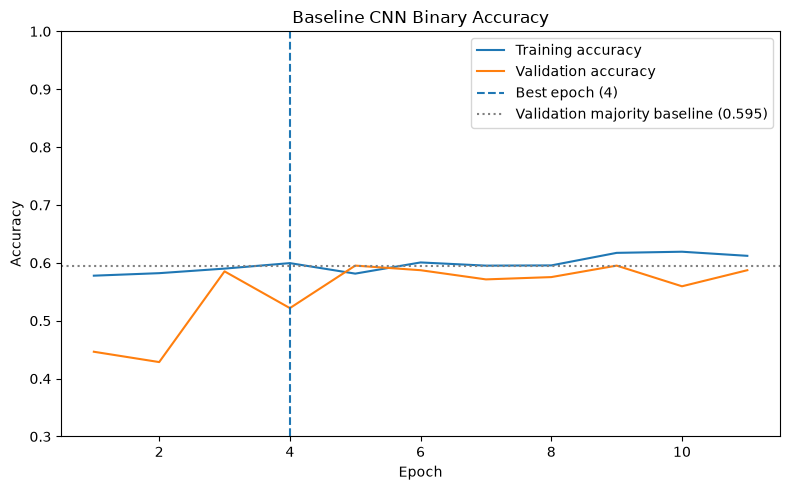

In [259]:
#plot training and validation binary accuracy
#calculate the accuracy obtained by always predicting the majority class in the validation partition

validation_majority_accuracy = (
    val_df[
        "target"
    ]
    .value_counts(
        normalize=True
    )
    .max()
)

plt.figure(
    figsize=(8, 5)
)

#plot accuracy on the augmented training data
plt.plot(
    baseline_history_df.index,
    baseline_history_df[
        "binary_accuracy"
    ],
    label="Training accuracy"
)

#plot accuracy on the unchanged validation data
plt.plot(
    baseline_history_df.index,
    baseline_history_df[
        "val_binary_accuracy"
    ],
    label="Validation accuracy"
)

#mark the epoch selected using validation ROC-AUC
plt.axvline(
    x=best_epoch_index,
    linestyle="--",
    label=f"Best epoch ({best_epoch_index})"
)


#show the validation accuracy obtained by predicting every record as the majority benign class
plt.axhline(
    y=validation_majority_accuracy,
    color="gray",
    linestyle=":",
    label=(
        "Validation majority baseline "
        f"({validation_majority_accuracy:.3f})"
    )
)

plt.title(
    "Baseline CNN Binary Accuracy"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Accuracy"
)

plt.ylim(
    0.3,
    1.0
)

plt.legend()
plt.tight_layout()
plt.show()

__Visual Interpretation__

Training accuracy increasied modestly from approximately `0.578` to `0.612`, while validation accuracy fluctuated and remained close to the `0.595`majority-class baseline after the initial epochs.

At the selected epoch 4, validation accuracy was `0.522`, below the majority baseline. This reflects the model's high malignant-class recall at the `0.5` threshold, which was achieved at the cost of many false-positive predictions. Therefore, accuracy alone does not adequately represent model's discrimination.

The later validation accuracy values approaching the majority baseline do not neccessarily indicate improved performance, since a classifier predicting every record as benign would achieve similar accuracy. This supports using ROC-AUC as the primary checkpoint criterion and selecting the final classification threshold separately.

### 10.11 Best Baseline Model Restoration

The checkpoint associated with the highest validation ROC-AUC is loaded from disk. Explicit restoration ensures that subsequent analyses use the saved best model rather than depending only on the model state retained in memory.

In [260]:
#restore the best saved baseline cnn
#confirm that the model checkpoint exists before loading it
assert BASELINE_MODEL_PATH.is_file(), (
    "The saved baseline checkpoint could not be found."
)

#load the complete model selected using validation ROC-AUC
best_baseline_model = (
    tf.keras.models.load_model(
        BASELINE_MODEL_PATH
    )
)

print(
    "Best baseline model loaded from:",
    BASELINE_MODEL_PATH.resolve()
)

Best baseline model loaded from: /Users/marcela/FinalProject/models/baseline_cnn_best.keras


In [261]:
#validate the restored model with a forward pass
#apply the restored model to the previously loaded batch
#inference mode disables augmentation and dropout
loaded_model_predictions = (
    best_baseline_model(
        forward_pass_images,
        training=False
    )
)

#confirm that one prediction is produced for every image
assert (
    loaded_model_predictions.shape
    == (
        forward_pass_images.shape[0],
        1
    )
)

#confirm that all restored model predictions are finite
assert bool(
    tf.reduce_all(
        tf.math.is_finite(
             loaded_model_predictions
        )
    ).numpy()
)

print(
    "Saved baseline model validation passed."
)

Saved baseline model validation passed.


### 10.12 Validation-Set Probability Generation

The restored baseline model is applied to the complete validation dataset to obtain one malignancy probability per lesion-view record.

Because the validation dataset was created without shuffling, prediction order remains aligned with *val_df*. These probabilities can therefore be matched reliably with the corresponding targets and metadata.

In [263]:
#generate probabilities for the validation partition
#predict one malignancy probability for each validation image
#reshape the output fromm(number_of_records, 1) into a one dimensional array
baseline_val_probabilities = (
    best_baseline_model.predict(
        val_dataset,
        verbose=1
    )
    .reshape(-1)
)

#extract the corresponding binary targets in the same order
baseline_val_targets = (
    val_df[
        "target"
    ]
    .astype(int)
    .to_numpy()
)

print(
    "Validation targets:",
    baseline_val_targets.shape
)

print(
    "Validation probabilities:",
    baseline_val_probabilities.shape
)

print(
    "Probability range:",
    (
        baseline_val_probabilities.min(),
        baseline_val_probabilities.max()
    )
)

16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 440ms/step
Validation targets: (504,)
Validation probabilities: (504,)
Probability range: (np.float32(0.040189467), np.float32(0.9054245))


In [264]:
#validate the generated probability array
#confirm that one probability was generated per record
assert (
    len(baseline_val_probabilities)
    == len(val_df)
)

#confirm that one target is available per record
assert (
    len(baseline_val_targets)
    == len(val_df)
)

#confirm that every probability is numerically valid
assert np.isfinite(
    baseline_val_probabilities
).all()

#confirm that all sigmoid probabilities lie within [0, 1]
assert(
    baseline_val_probabilities.min()
    >= 0.0
)

assert(
    baseline_val_probabilities.max()
    <= 1.0
)

print(
    "Validation probability generation passed."
)

Validation probability generation passed.


### 10.13 Baseline Validation Performance
The restored baseline CNN is evaluated on the validation partition using threshold-independent and threshold-dependent measures.

Threshold-independent metrics evaluate discrimination across possible decision thresholds. Threshold-dependent metrics describe classification performance at the conventional probability threshold of `0.5`.

The validation partition supports model assessment and later threshold section. The independent testing partition remains untouched until final model selection is complete.

In [265]:
#convert validation probabilities into binary predictions
#define the initial conventional classification threshold
VALIDATION_THRESHOLD = 0.5

#assign malignant class 1 to probabilities at or above the threshold and benign class 0 to lower probabilities 
baseline_val_predictions = (
    baseline_val_probabilities
    >= VALIDATION_THRESHOLD
).astype(int)

print(
    "Validation probabilities:",
    baseline_val_probabilities.shape
)

print(
    "Validation predictions:",
    baseline_val_predictions.shape
)

print(
    "Validation targets:",
    baseline_val_targets.shape
)
    

Validation probabilities: (504,)
Validation predictions: (504,)
Validation targets: (504,)


In [273]:
#validate the binary prediction array 
#confirm that predictions and targets contain equal numbers of validation records
assert len (
    baseline_val_predictions
) == len(
    baseline_val_targets
)

#confirm that the thresholding operation produced only valid binary labels
assert set(
    np.unique(
        baseline_val_predictions
    )
).issubset(
    {
        0,
        1
    }
)

print(
    "Binary prediction validation passed."
)

Binary prediction validation passed.


### 10.13.1 Validation Classification Metrics

Complementary performance metrics are calculated from the validation predictions. Accuracy measures overall correctness. Precision quantifies the reliability of malignant predictions, while recall measures the proportion of malignant records detected. The F1-score balances precision and recall.

ROC-AUC and PR-AUC are calculated from the continuous probabilities rather than the thresholded labels, allowing discrimination to be assessed across possible thresholds.

In [274]:
#import validation-performance metricss
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

In [280]:
#generate aligned predictions and calculate validation metrics
validation_target_batches = []
validation_probability_batches = []

#collect predictions and their corresponding targets from the same validation dataset iteration
for validation_images, validation_targets in val_dataset:

    batch_probabilities = (
        best_baseline_model(
            validation_images,
            training=False
        )
        .numpy()
        .reshape(-1)
    )
    validation_probability_batches.append(
        batch_probabilities
    )

    validation_target_batches.append(
        validation_targets
        .numpy()
        .astype(int)
        .reshape(-1)
    )

#combine all batches while preserving target prediction alignment
baseline_val_probabilities = np.concatenate(
    validation_probability_batches
)

baseline_val_targets = np.concatenate(
    validation_target_batches
)

#convert probabilities into binary predictions using 0.5
VALIDATION_THRESHOLD = 0.5

baseline_val_predictions = (
    baseline_val_probabilities
    >= VALIDATION_THRESHOLD
).astype(int)

#confirm that all validation records are represented
assert (
    len(baseline_val_probabilities)
    == len(baseline_val_targets)
    == len(val_df)
)
    
#calculate baseline validation metric
#======================================
baseline_validation_metrics = pd.DataFrame(
    {
        "Metric": [
            
            #threshold-dependent metrics calculated from binary predictions at the threshold of 0.5
            "Accuracy",
            "Precision",
            "Recall",
            "F1-score",

            #threshold-inpedependent metrics calculated directly from continuous probabilities
            "ROC-AUC",
            "PR-AUC"
        ],

        "Value": [

            #Overall proportion of correct predictions
            accuracy_score(
                baseline_val_targets,
                baseline_val_predictions
            ),

            #proportion of predicted malignant records that are genuinely malignant
            precision_score(
                baseline_val_targets,
                baseline_val_predictions,
                zero_division=0
            ),

            #proportion of malignant records correctly detected
            recall_score(
                baseline_val_targets,
                baseline_val_predictions,
                zero_division=0
            ),

            #harmonic mean of precision and recall 
            f1_score(
                baseline_val_targets,
                baseline_val_predictions,
                zero_division=0
            ),

            #discrimination across all classification thresholds
            roc_auc_score(
                baseline_val_targets,
                baseline_val_probabilities
            ),

            #precision-recall performance across thresholds
            average_precision_score(
                baseline_val_targets,
                baseline_val_probabilities
            )
        ]
    }
)

#round the results for concise presentation
baseline_validation_metrics[
    "Value"
] = (
    baseline_validation_metrics[
        "Value"
    ]
    .round(4)
)

display(
    baseline_validation_metrics
)
    
    

,Metric,Value
0,Accuracy,0.5218
1,Precision,0.4575
2,Recall,0.9755
3,F1-score,0.6228
4,ROC-AUC,0.6548
5,PR-AUC,0.5167


__Validation Performance Interpretation__

At the default threshold of `0.5`, the baseline CNN achieved very high recall (`0.9755`), correctly identifying nearly all malignant validation records. However, precision was lower (`0.4575)`, indicating that many benign records were also classified as malignant. This sensitivity-focused operating point produced an accuracy of `0.5218`, below the validation majority-class baseline of approximately `0.595`, but an F1-score of `0.6228`due to the strong recall.

The ROC-AUC of `0.6548` indicates modest discrimination between malignant lesions across thresholds. PR-AUC reached `0.5167`, exceeding the malignant prevalence of approximately `0.405` and confirming performance above the non-informative reference level.

The small differences from the Keras values reported during training arise from differences in metric calculation: scikit-learn calculates ROC-AUC and average precision directly from all predictions, whereas Keras approximates the curves using predefined thresholds. Overall, the model learned meaningful discriminatory features but produced excessive false positives at the default threshold, supporting later threshold optimisation and comparison with transfer-learning architectures.

### 10.13.2 Confusion Matrix

The confusion matrix summarises the number of true positives, true negatives, false positives and false negatives obtained using the default probability threshold of 0.5.

This analysis highlights the types of classification errors produced by the baseline CNN.

In [281]:
#calculate the baseline validation confusion matrix
from sklearn.metrics import confusion_matrix

#compare the true validation taregts with the binary predictions produces at the threshold of 0.5
#matrix structure
#[[true negatives, false positives],
#[false negatives, true positives]]
baseline_confusion_matrix = confusion_matrix(
    baseline_val_targets,
    baseline_val_predictions
)

#display the numerical matrix
baseline_confusion_matrix

array([[ 64, 236],
       [  5, 199]])

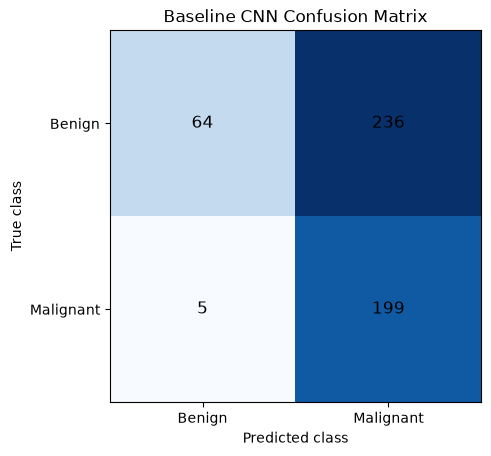

In [283]:
#visualise the baseline validation confusion matrix 
plt.figure(
    figsize=(5, 5)
)

#display the matrix as a colour coded image
plt.imshow(
    baseline_confusion_matrix,
    cmap="Blues"
)

#label the predicted classes on the horizontal axis
plt.xticks(
    [0, 1],
    [
        "Benign",
        "Malignant"
    ]
)

#label the true classes on the vertical axis 
plt.yticks(
    [0, 1],
    [
        "Benign",
        "Malignant"
    ]
)

plt.xlabel(
    "Predicted class"
)

plt.ylabel(
    "True class"
)

plt.title(
    "Baseline CNN Confusion Matrix"
)

#write the record count inside each matrix cell
for row in range(2):
    for column in range(2):

        plt.text(
            column,
            row,
            baseline_confusion_matrix[
                row,
                column
            ],
            ha="center",
            va="center",
            fontsize=12
        )
        
plt.tight_layout()

__Confusion-Matrix Interpretation__

At the default threshold of `0.5`, the model correctly identified 199 of 204 malignant records and missed only 5, producing the high recall of `0.9755`. However, it correctly classified only 64 of 300 benign records, while 236 were incorrectly labelled malignant. This corresponds to low specificity of approximately `0.213`.

The matrix confirms that the baseline operates at a highly sensitivity-focused point: it minimises false-negative malignant cases but generates many false-positive findings. This explains the strong recall alonside the lower precision (`0.4574`) and accuracy (`0.5218`). Although avoiding missed malignancies is important, the high false-positive burden would limit practical usefulness. Subsequent validation based threshold selection should therefore seek a more appropiate balance between sensitivity and specificity.

### 10.13.3 Receiver Operating Characteristic Curve

The receiver operating characteristic (ROC) curve evaluates the trade-off between sensitivity and false-positive rate across all possible classification thresholds. The diagonal reference line represents random discrimination, while curves closer to the upper-left corner indicate stronger performance.

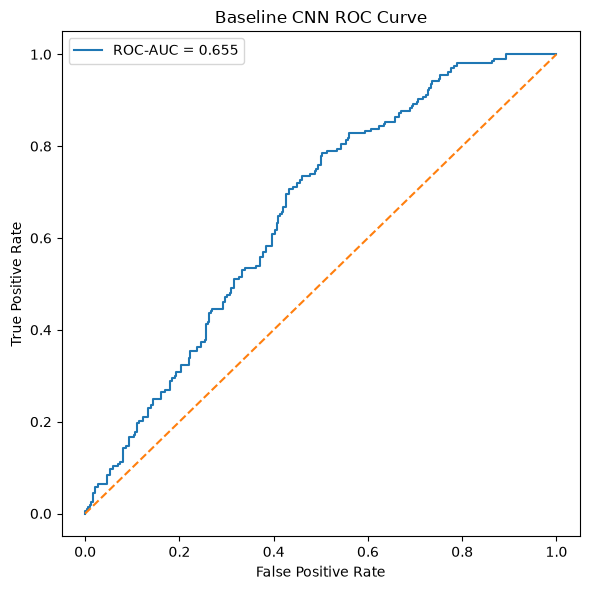

In [288]:
from sklearn.metrics import roc_curve

#calculate the ROC curve across classification thresholds
false_positive_rate, true_positive_rate, _ = roc_curve(
    baseline_val_targets,
    baseline_val_probabilities
)

baseline_roc_auc = roc_auc_score(
    baseline_val_targets,
    baseline_val_probabilities
)

#plot the ROC curve
plt.figure(figsize=(6, 6))

#plot the models sensitivity against its false positive rate
plt.plot(
    false_positive_rate,
    true_positive_rate,
    label=f"ROC-AUC = {roc_auc_score(baseline_val_targets, baseline_val_probabilities):.3f}"
)

#add the performance expected from random classification
plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "Baseline CNN ROC Curve"
)

plt.legend()

plt.tight_layout()
plt.show()

__Interpretation__

The ROC curve remains mostly above the random-classification line, producing a validation ROC-AUC of `0.655`. This indicates modest discrimination: the baseline CNN learned information that helps rank malignant lesions above benign lesions, but substantial overal remains between the two classes. Its performance therefore provides a meaningful, although limited, reference against which the transfer-learning models can be compared.

### 10.13.4 Precision-Recall Curve

The precision-recall curve evaluates the relationship between malignant-lesion recall and the reliability of posisitve predictions across classification thresholds. It is particularly informative for this study because malignant lesions form the less frequent class

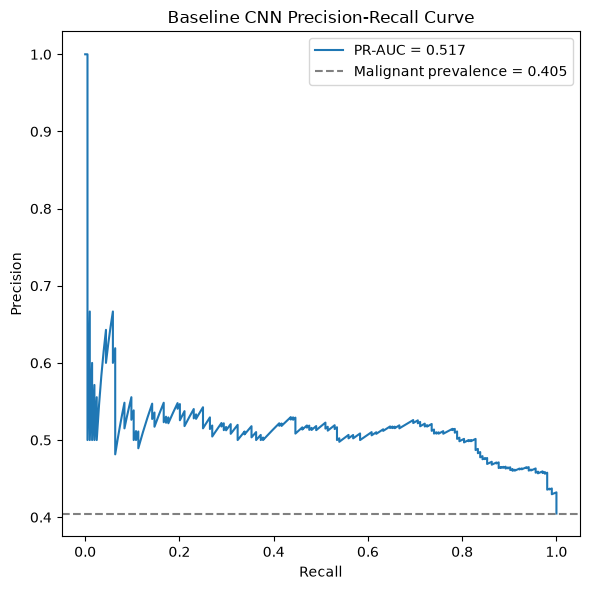

In [289]:
from sklearn.metrics import precision_recall_curve

#calculate precision and recall across decision thresholds
precision, recall, _ = precision_recall_curve(
    baseline_val_targets,
    baseline_val_probabilities
)

#calculate average precision, used here to summarise performance across the precision recall curve
baseline_average_precision = average_precision_score(
    baseline_val_targets,
    baseline_val_probabilities
)

#the malignant class prevalence provides a useful no-skill reference level for precision recall performance
validation_malignant_prevalence = (
    baseline_val_targets.mean()
)

#plot the precision recall curve
plt.figure(figsize=(6, 6))

plt.plot(
    recall,
    precision,
    label=f"PR-AUC = {average_precision_score(baseline_val_targets, baseline_val_probabilities):.3f}"
)

#add the malignant prevalence as a reference baseline
plt.axhline(
    y=validation_malignant_prevalence,
    linestyle="--",
    color="grey",
    label=(
        "Malignant prevalence = "
        f"{validation_malignant_prevalence:.3f}"
    )
)

plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "Baseline CNN Precision-Recall Curve"
)

plt.legend()

plt.tight_layout()
plt.show()

___Interpretation___

The average precision `0.517`exceeds the malignant-class prevalence of approximately `0.405`, confirming that the model indentifies malignant lesions better than a no-skill classifier. However, precision generally decreases as recall appproaches one, showing that detecting nearly all malignant lesions requires accepting more false-positive classifications. This agrees with the confusion matrix, where the default threshold achieved high sensitivity but incorrrectly classified many benign lesions as malignant.

### 11. EfficientNetB0 Transfer Learning

EfficientNetB0 is introduced as the first-transfer learning architecture. Unlike the baseline CNN, which learns all image features from the mammography dataset, EfficientNetB0 benigns with representations learned from ImageNet and adapts them to binary lesion classification.

### 11.1 EfficientNetBO Dependencies

The TensorFlow Keras implementation of EfficientNetB0 is used as the pretrained feature extractor. Additional Keras components are imported for constructing and regularising the custom classification head.

In [291]:
#import the EfficientNetB0 architecture and keras utilities
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers
from tensorflow.keras import regularizers

# display the tensorflow version used for reproducibility
print(
    "TensorFlow version:",
    tf.__version__
)

#confirm that tensorflow reports a valid version
assert tf.__version__ is not None

print(
    "EfficientNet dependencies loaded successfully."
)

TensorFlow version: 2.21.0
EfficientNet dependencies loaded successfully.


The output confims that the required dependencies were imported successfully under TensorFlow 2.21.0. Recording the version supports reproducibility because implementation details may differ between TensorFlow releases.

### 11.1 Transfer Learning Configuration

The EfficientNet input dimensions are matched to the existing TensorFlow datasets. Separate learning rates are defined for initial feature extraction and later fine-tuning. 

In [307]:
#define the EfficientNet input and optimisation settings
EFFICIENTNET_INPUT_SHAPE = (
    TARGET_IMAGE_SIZE[0],
    TARGET_IMAGE_SIZE[1],
    OUTPUT_CHANNELS
)

#Learning rate used while the pretrained backbone is frozen
TRANSFER_LEARNING_RATE = 1e-3

#smaller learning rate used when selected pretrained layers are later unfrozen for fine-tuning
FINE_TUNE_LEARNING_RATE= 1e-5

print(
    "EfficientNet input shape:",
    EFFICIENT_INPUT_SHAPE
)

print(
    "Transfer-Learning rate:",
    TRANSFER_LEARNING_RATE
)

print(
    "Fine-tuning rate:",
    FINE_TUNE_LEARNING_RATE
)

#confirm compatibility with the 224 x 224  rgb datasets
assert EFFICIENT_INPUT_SHAPE == (
    224,
    224,
    3
)

assert TRANSFER_LEARNING_RATE > 0
assert FINE_TUNE_LEARNING_RATE > 0

assert (
    FINE_TUNE_LEARNING_RATE
    < TRANSFER_LEARNING_RATE
)

print(
    "EfficientNet configuration validated."
)

EfficientNet input shape: (224, 224, 3)
Transfer-Learning rate: 0.001
Fine-tuning rate: 1e-05
EfficientNet configuration validated.


The validated input shape matches the existing 224 x 224 x 3 image tensors. The fine-tuninng learning rate is intentionally lower than the initial transfer-learning rate because smaller parameter updates reduce the risk of disrupting useful pretrained ImageNet features when backbone layers are later unfrozen

#### EfficientNet Input-Scaling Requirement
The existing TensorFlow datasets produce images in the range `[0, 1]`. However, EfficientNetB0 includes an internal preprocessing layer designed for inputs in `[0, 255]`. The transfer-learning architecture therefore includes a model-level rescaling layer that convers the augmented images to the required range before feature extraction.

This approach preserves the common dataset pipeline used by the baseline and transfer-learning models while ensuring that EfficientNetB0 receives correctly scaled inputs.

### 11.2 Pretrained Feature Extractor
EfficientNetB0 is initialised using weights learned from ImageNet. Its original multiclass classification layer is excluded because the present task requires binary classification of mammographic lesions.

During the initial transfer-learning stage, the backbone remains frozen so that only the new classification head is trained.


In [308]:
#load the pretrained EfficientNetB0 feature extractor
efficientnet_base = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=EFFICIENT_INPUT_SHAPE
)

#freeze the pretrained convolutional layers during the initial transfer learning stage
efficient_base.trainable = False

print(
    "Backbone trainable:",
    efficient_base.trainable
)

print(
    "Backbone output shape:",
    efficientnet_base.output_shape
)

#confirm that the backbone has been frozen succesfully
assert efficient_base.trainable is False

print(
    "Frozen EfficientNet feature extractor validated."
)

Backbone trainable: False
Backbone output shape: (None, 7, 7, 1280)
Frozen EfficientNet feature extractor validated.



The False trainable status confirms that the pretrained EfficientNet weights will remain unchanged during initial training. This allows the custom classification head to learn how to use the extracted features before controlled fine-tuning begins. 



### 11.3 Transfer Learning Architecture

The pretrained EfficientNetB0 backbone is combined with a lightweight binary-classification head. Training augmentation is incorporated into the model so that it is applied during optimisation but disabled during validation and inference.

Global average pooling converts the final spatial feature maps into a compact representation. Batch normalisation supports stable optimisation, while dropout L2 regularisation reduce overfitting. The final sigmoid neuron returns the estimated probability that a lesion is malignant.


In [309]:
def build_efficientnet_model():
    """
    Construct the EfficientNetB0 transfer learning model.

    The tensorflow datasets contain images in the [0,1]
    range. These images are converted to [0, 255] before entering EfficientNetB0 
    because the pretrained backbone includes its own internal input normalisation.

    Returns
    --------
    tf.keras.Model
        Uncompiled binary classifcation model.
    """

    #define the model input using the existing image dimensions
    inputs = tf.keras.Input(
        shape=EFFICIENTNET_INPUT_SHAPE,
        name="mammogram_input"
    )

    #apply stochastic transformations during training only
    x = data_augmentation(
        inputs
    )

    #converts the shared dataset range from [0, 1] to [0, 255]
    #for compatibility with EfficientNetB0 preprocessing.
    x = layers.Rescaling(
        scale=255.0,
        name="efficientnet_input_rescaling"
    )(x)

    #extract pretrained image features. Using training=false
    #keeps the backbones batch normalisation statistics fixed
    x = efficientnet_base(
        x,
        training=False
    )

    #convert the 7x7x1280 feature map into one 1280 dimensional representation per image
    x = layers.GlobalAveragePooling2D(
        name="global_average_pooling"
    )(x)

    #normalise the pooled features before classification
    x = layers.BatchNormalization(
        name="classification_batch_normalization_1"
    )(x)

    #apply regularisation to reduce overfitting
    x = layers.Dropout(
        rate=0.40,
        name="classification_dropout_1"
    )(x)

    #learn a task specific representation for malignancy classification, with L2 weight regularisation
    x = layers.Dense(
        units=256,
        activation="relu",
        kernel_regularizer=regularizers.l2(
            1e-4
        ),
        name="classification_dense"
    )(x)

    x = layers.BatchNormalization(
        name="classification_batch_normalization_2"
    )(x)

    x = layers.Dropout(
        rate=0.30,
        name="classification_dropout_2"
    )(x)

    #return one probability of malignancy per image
    outputs = layers.Dense(
        units=1,
        activation="sigmoid",
        name="malignancy_probability"
    )(x)

    model = tf.keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="efficientnetb0_transfer_learning"
    )

    return model

### 11.4 Model Construction and Structural Validation
The complete transfer-learning architecture is instantiated and inspected before compilation. Structural checks confirm that the model accepts the expected image dimensions and produced one malignancy probability per record

In [310]:
#construct and inspect the EfficientNetB0 model
tf.keras.backend.clear_session()

efficientnet_model = build_efficientnet_model()

efficientnet_model.summary()

#define the expected input and output dimensions
expected_efficientnet_input_shape = (
    None, 
    TARGET_IMAGE_SIZE[0],
    TARGET_IMAGE_SIZE[1],
    OUTPUT_CHANNELS
)

expected_efficientnet_output_shape = (
    None, 
    1
)

#confirm compatibility with the tensorflow datasets
assert (
    efficientnet_model.input_shape
    == expected_efficientnet_input_shape
)

assert (
    efficientnet_model.output_shape
    == expected_efficientnet_output_shape
)

assert efficientnet_model.count_params() > 0

print(
    "EfficientNet model structural validation passed."
)

print(
    "Total model parameters:"
    f"{efficientnet_model.count_params():,}"
)

Model: "efficientnetb0_transfer_learning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mammogram_input (InputLayer)    │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ training_data_augmentation      │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnet_input_rescaling    │ (None, 224, 224, 3)    │             0 │
│ (Rescaling)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification_batch_normaliza… │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification_dropout_1        │ (None, 1280)           │             0 │
│ (Dropout)                       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification_dense (Dense)    │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification_batch_normaliza… │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification_dropout_2        │ (None, 256)            │             0 │
│ (Dropout)                       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ malignancy_probability (Dense)  │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,383,908 (16.72 MB)

 Trainable params: 4,338,813 (16.55 MB)

 Non-trainable params: 45,095 (176.16 KB)

EfficientNet model structural validation passed.
Total model parameters:4,383,908


The architecture contains `4,383,908` parameters, but only `331,265` are initially trainable. Most parameters bleong to the frozen EfficientNetB0 backbone, while the trainable parameters primarily belong to the new classification head.

This configuration allows the model to reuse pretrained visual representations while learning a mammography-specific classiier with relatively few adjustable parameters. It therefore reduces computational requirements and the risk of overfitting compared with training the complete network from random initialisation.

The backbone produces a `7 x 7 x 1280` feature map, which global average pooling reduces to 1,280 features per image. The final ouput shape `(None, 1)`correctly represents one malignancy probability for every input image.
    

### 11.5 Efficient Input-Range Validation

In [313]:
#validate efficientnetb0 specific input rescaling
#retrieve one batch from the training dataset
sample_efficientnet_images, _ = next(
    iter(train_dataset)
)

#apply augmentation in inference mode. This should leave the images unchanged because augmentation is training only
sample_unaugmented_images = data_augmentation(
    sample_efficientnet_images,
    training=False
)

#apply only the efficientnet specific rescaling layer
sample_scaled_images = (
    efficientnet_model.get_layer(
        "efficientnet_input_rescaling"
    )(
        sample_unaugmented_images
    )
)

#record the ranges before and after rescaling
dataset_input_minimum = float(
    tf.reduce_min(
        sample_efficientnet_images
    ).numpy()
)

dataset_input_maximum = float(
    tf.reduce_max(
        sample_efficientnet_images
    ).numpy()
)

efficientnet_input_minimum = float(
    tf.reduce_min(
        sample_scaled_images
    ).numpy()
)

efficientnet_input_maximum = float(
    tf.reduce_max(
        sample_scaled_images
    ).numpy()
)

print(
    "Dataset input range:",
    (
        dataset_input_minimum,
        dataset_input_maximum
    )
)

print(
    "EfficientNet input range:",
    (
        efficientnet_input_minimum,
        efficientnet_input_maximum
    )
)

#confirm that both representations contain finite values
assert bool(
    tf.reduce_all(
        tf.math.is_finite(
            sample_scaled_images
        )
    ).numpy()
)

#validate the original and converted ranges
assert dataset_input_minimum >= 0.0
assert dataset_input_maximum <= 1.0

assert efficientnet_input_minimum >= 0.0
assert efficientnet_input_maximum <= 255.0

print(
    "EfficientNet input-range validation passed."
)

Dataset input range: (0.0, 1.0)
EfficientNet input range: (0.0, 255.0)
EfficientNet input-range validation passed.


__Intepretation__

The output should confirm that the dataset remains normalised to [0,1], while the model converts the images to [0, 255] immediately before feature extraction. This verifies that EfficientNetB0 receives the intended input scale without requiring a separate dataset or modifying the validated preprocessing pipeline.

### 11.6 Model Compilation

The transfer-learning model is compiled using binary cross-entropy and the same evaluation metrics employed for the baseline CNN. This consistency supports a fair architectural comparison. 

A new set of metric objects is created for this model so that their internal states are not shared with the baseline model.

In [315]:
def create_binary_classification_metrics():
    """
    Create independent evaluation metrics for one binary classification model.

    Returns
    -------
    list
        Newly instantiated Keras metric objects.
    """

    return [ 
        #overall correctness at the default threshold
        tf.keras.metrics.BinaryAccuracy(
            name="binary_accuracy",
            threshold=0.5
        ),

        #reliability of malignant predictions
        tf.keras.metrics.Precision(
            name="precision",
            thresholds=0.5
        ),

        #proportion of malignant records detected
        tf.keras.metrics.Recall(
            name="recall",
            thresholds=0.5
        ),

        #precision-recall performance across thresholds
        tf.keras.metrics.AUC(
            name="roc_auc",
            curve="ROC"
        ), 

        #precision-recall performance across thresholds
        tf.keras.metrics.AUC(
            name="pr_auc",
            curve="PR"
        )
    ]

#compile the initial transfer learning model
efficientnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=TRANSFER_LEARNING_RATE
    ),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=create_binary_classification_metrics()
)

print(
    "EfficientNet model compiled successfully."
)

print(
    "Initial transfer-learning rate:",
    TRANSFER_LEARNING_RATE
)

EfficientNet model compiled successfully.
Initial transfer-learning rate: 0.001


Successfull compilation confirms that the model is ready for initial transfer-learning training. Binary cross-entropy is appropiate for the sigmoid output, while ROC-AUC and PR-AUC permit threshold-independent comparison with the baseline CNN. At this stage, optimisation will update only the classification head because the EfficientNetB0 backbone remains frozen.

### 11.7 Two-Stage Transfer-Learning Strategy

EfficientNetB0 is optimised using a two-stage transfer-learning strategy.

During Stage 1, the pretrained backbone remains frozen and only the newly added classification head is trained. This allows the randomly initialised head to adapt to the mammography task without modifying the pretrained feature representations.

During Stage 2, a selected group of deeper EfficientNetB0 layers will be unfrozen and fine-tuned using a substantially lower learning rate. These layers encode higher-level visual representations that may benefit from adaptation to mammographic tissue and lesion morphology. Earlier layers remain frozen because they generally capture transferable features such as edges and textures. This controlled approach reduced computational cost and limits catastropic forgetting.

### 11.7.1 Stage 1 Trainability Validation
Before Stage 1 training, the model's parameter allocation is examined. The EfficientNetB0 backbone must contain no trainable weights, while the custom classification head must remain trainable.

In [327]:
efficientnet_base.trainable = False

def count_model_parameters(model):
    """
    Count the trainable, non-trainable and total parameters
    within a Keras model.

    Parameters
    ----------
    model : tf.keras.Model
        Model whose parameters will be counted.

    Returns
    ----------
    dict 
        Trainable, non-trainable and total parameter counts.
    """

    #count parameters updated during optimisation
    trainable_parameters = int(
    np.sum(
        [
            np.prod(variable.shape)
            for variable
            in model.trainable_weights
        ]
    )
)

    #count frozen parameters and non-trainable states, including batch-normalisation moving statistics
    non_trainable_parameters = int(
        np.sum(
            [
                np.prod(variable.shape)
                for variable
                in model.non_trainable_weights
            ]
        )
    )

    return {
        "Trainable parameters": trainable_parameters,
        "Non-trainable parameters": non_trainable_parameters,
        "Total parameters":(
            trainable_parameters
            + non_trainable_parameters
        )
    }

    #inspect the stage 1 parameter allocation
stage_1_parameter_counts = count_model_parameters(
    efficientnet_model
)

stage_1_parameter_summary = pd.DataFrame(
    [stage_1_parameter_counts],
    index=["Stage 1"]
)

display(
    stage_1_parameter_summary
)

#confirm that the pretrained backbone is frozen
assert efficientnet_base.trainable is False

assert len(
    efficientnet_base.trainable_weights
) == 0, (
    "The EfficientNetB0 backbone still contains "
    "trainable weights."
)

#confirm that the classification head contains parameters that can be optimised
assert (
    stage_1_parameter_counts[
        "Trainable parameters"
    ]
    > 0
)

#most parameters should be non trainable because the complete pretrained backbone is frozen
assert (
    stage_1_parameter_counts[
        "Non-trainable parameters"
    ]
    > stage_1_parameter_counts[
        "Trainable parameters"
    ]
)

#confirm consistency with the model summary 
assert(
    stage_1_parameter_counts[
        "Total parameters"
    ]
    == efficientnet_model.count_params()
)

print(
    "Stage 1 trainability validation passed."
)

,Trainable parameters,Non-trainable parameters,Total parameters
Stage 1,331265,4052643,4383908


Stage 1 trainability validation passed.


__Interpretation__

Only `331,265` of the model's `4,383,908` parameters are trainable during Stage 1. These parameters primarily belong to the custom classification head, while the `4,052,643` non-trainable paramters consist mainly of the frozen EfficientNetB0 backbone and batch-normalisation statistics. 

This confirms that initial optimisation will adapt the classifier to the mammography task without altering the pretrained feature extractor.

### 11.7.2 Feature-Extraction Training Configuration

During Stage 1, the classification head is trained for a maximum of 25 epochs using an initial learning rate of $1 \times {10^3}$.
Validation ROC-AUC is used for model selection because it measures discrimination across classification thresholds. A separate checkpoint is retained for Stage 1 so that its performance can later be compared with the fine-tuned model.

In [338]:
#define the stage 1 checkpoint location
EFFICIENTNET_MODEL_DIRECTORY = (
    MODEL_DIRECTORY
    / "efficientnetb0"
)

#create the model directory if it does not already exist
EFFICIENTNET_MODEL_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True
)

EFFICIENTNET_STAGE_1_PATH = (
    EFFICIENTNET_MODEL_DIRECTORY
    / "efficientnetb0_stage_1_best.keras"
)

#set the maximum number of feature extraction epochs
EFFICIENTNET_STAGE_1_MAX_EPOCHS = 25

print(
    "Stage 1 checkpoint:",
    EFFICIENTNET_STAGE_1_PATH.resolve()
)

#configure stage 1 training callback
efficientnet_stage_1_callbacks = [

    #stop training when validation discrimination no longer
    #improves and restore the best in-memory weights.
    tf.keras.callbacks.EarlyStopping(
        monitor="val_roc_auc",
        mode="max",
        patience=6,
        min_delta=1e-4,
        restore_best_weights=True,
        verbose=1
    ),

    #reduce the learning rate when validation loss plateaus
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=3,
        min_delta=1e-4,
        min_lr=1e-6,
        verbose=1
    ),

    #save the complete model achieving the highest validation ROC-AUC
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(
            EFFICIENTNET_STAGE_1_PATH
        ),
        monitor="val_roc_auc",
        mode="max",
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    ),

    #stop immediately if the loss becomes undefined
    tf.keras.callbacks.TerminateOnNaN()
]

print(
    "Stage 1 callbacks configured:",
    len(
        efficientnet_stage_1_callbacks
    )
)

Stage 1 checkpoint: /Users/marcela/FinalProject/models/efficientnetb0/efficientnetb0_stage_1_best.keras
Stage 1 callbacks configured: 4


__Interpretation__

The four callbacks control convergence, reduce the learning rate when optimisation plateaus, preserve the checkpoint with the strongest validation discrimination and protect against invalid numerical values. Although early stopping restores the best weights in memory, checkpointing also preserves the complete best-performing model independently on disk.

### 11.8 Stage 1: Frozen-Backbone Feature Extraction

During Stage 1, the model uses the frozen EfficientNeB0 backbone to extract pretrained features, while onlt the custom classification head is optimised. Balanced class weights are retained so that malignant records contribute more strongly to the training objective without altering the validation distribution.

In [340]:
#Train the classification head with the backbone frozen
efficientnet_stage_1_history = efficientnet_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EFFICIENTNET_STAGE_1_MAX_EPOCHS,
    class_weight=class_weights,
    callbacks=efficientnet_stage_1_callbacks,
    verbose=1
)

Epoch 1/25
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step - binary_accuracy: 0.5903 - loss: 0.8956 - pr_auc: 0.5533 - precision: 0.5011 - recall: 0.6425 - roc_auc: 0.6502
Epoch 1: val_roc_auc improved from None to 0.69638, saving model to models/efficientnetb0/efficientnetb0_stage_1_best.keras

Epoch 1: finished saving model to models/efficientnetb0/efficientnetb0_stage_1_best.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 41s 457ms/step - binary_accuracy: 0.5928 - loss: 0.8770 - pr_auc: 0.5497 - precision: 0.4992 - recall: 0.6372 - roc_auc: 0.6512 - val_binary_accuracy: 0.6329 - val_loss: 0.6549 - val_pr_auc: 0.5709 - val_precision: 0.5714 - val_recall: 0.3725 - val_roc_auc: 0.6964 - learning_rate: 0.0010
Epoch 2/25
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step - binary_accuracy: 0.6420 - loss: 0.6980 - pr_auc: 0.6374 - precision: 0.5452 - recall: 0.6796 - roc_auc: 0.7218
Epoch 2: val_roc_auc improved from 0.69638 to 0.69665, saving model to models/efficientnetb0/efficientnetb0_stage_1_best.keras

Epoch 2: fi

### 11.9 Stage 1 Training Analysis
The Stage 1 training history is preserved before fine-tuning. The epoch achieving the highest validation ROC-AUC is identified as the best frozen-backbone checkpoint and provides an intermediate reference for evaluating whether selective fine-tuning produces further improvement.

In [345]:
#convert the stage 1 training history into a dataframe
efficientnet_stage_1_history_df = pd.DataFrame(
    efficientnet_stage_1_history.history
)

efficientnet_stage_1_history_df.index = (
    efficientnet_stage_1_history_df.index + 1 
)

efficientnet_stage_1_history_df.index.name = "Epoch"

display(
    efficientnet_stage_1_history_df
)

,binary_accuracy,loss,pr_auc,precision,recall,roc_auc,val_binary_accuracy,val_loss,val_pr_auc,val_precision,val_recall,val_roc_auc,learning_rate
Epoch,,,,,,,,,,,,,
1,0.592826,0.877024,0.549734,0.499240,0.637245,0.651164,0.632937,0.654878,0.570917,0.571429,0.372549,0.696381,0.00100
2,0.639338,0.712643,0.615702,0.546549,0.660524,0.709477,0.630952,0.656200,0.590489,0.542453,0.563725,0.696650,0.00100
3,0.654710,0.683609,0.631993,0.561265,0.688652,0.725969,0.668651,0.645276,0.653559,0.561056,0.833333,0.747271,0.00100
4,0.671265,0.644857,0.666108,0.577376,0.712900,0.750363,0.676587,0.625146,0.645463,0.587234,0.676471,0.744028,0.00100
5,0.671659,0.637675,0.668802,0.579839,0.697381,0.752004,0.688492,0.624256,0.655864,0.595918,0.715686,0.751225,0.00100
6,0.670871,0.631322,0.681840,0.578652,0.699321,0.753699,0.597222,0.663605,0.655269,0.501458,0.843137,0.742484,0.00100
7,0.676784,0.628488,0.665704,0.585149,0.703201,0.757611,0.658730,0.626679,0.658022,0.570175,0.637255,0.735539,0.00100
8,0.684667,0.623276,0.672127,0.594905,0.702231,0.762962,0.660714,0.625569,0.656506,0.574661,0.622549,0.731626,0.00100
9,0.694521,0.612448,0.690628,0.603560,0.723569,0.769497,0.664683,0.617100,0.676737,0.572614,0.676471,0.754477,0.00050


In [346]:
#save the complete stage 1 training history
EFFICIENTNET_STAGE_1_HISTORY_PATH = (
    EFFICIENTNET_MODEL_DIRECTORY
    / "efficientnetb0_stage_1_history.csv"
)

efficientnet_stage_1_history_df.to_csv(
    EFFICIENTNET_STAGE_1_HISTORY_PATH,
    index=True
)

print(
    "Stage 1 training history saved to:",
    EFFICIENT_STAGE_1_HISTORY_PATH.resolve()
)

Stage 1 training history saved to: /Users/marcela/FinalProject/models/efficientnetb0/efficientnetb0_stage_1_history.csv


In [347]:
#identify the epoch with the highest validation ROC-AUC
efficientnet_stage_1_best_epoch = (
    efficientnet_stage_1_history_df[
        "val_roc_auc"
    ]
    .idxmax()
)

efficientnet_stage_1_best_results = (
    efficientnet_stage_1_history_df.loc[
        efficientnet_stage_1_best_epoch
    ]
)

print(
    "Best Stage 1 epoch:",
    efficientnet_stage_1_best_epoch
)

print(
    "Training ROC-AUC:"
    f"{efficientnet_stage_1_best_results['roc_auc']:.4f}"
)

print(
    "Validation ROC-AUC:"
    f"{efficientnet_stage_1_best_results['val_roc_auc']:.4f}"
)

print(
    "Validation PR-AUC:"
    f"{efficientnet_stage_1_best_results['val_pr_auc']:.4f}"
)

print(
    "Validation accuracy:"
    f"{efficientnet_stage_1_best_results['val_binary_accuracy']:.4f}"
)

print(
    "Validation precision:"
    f"{efficientnet_stage_1_best_results['val_precision']:.4f}"
)

print(
    "Validation recall:"
    f"{efficientnet_stage_1_best_results['val_recall']:.4f}"
)

Best Stage 1 epoch: 16
Training ROC-AUC:0.7939
Validation ROC-AUC:0.7634
Validation PR-AUC:0.6884
Validation accuracy:0.6746
Validation precision:0.5980
Validation recall:0.5980


In [351]:
#validate the best epoch calculation
assert efficientnet_stage_1_best_epoch >= 1, (
    "The best epoch must be a positive epoch number."
)

assert np.isfinite(
    efficientnet_stage_1_best_results[
        "val_roc_auc"
    ]
), (
    "The best validation ROC-AUC is not finite."
)

assert np.isclose(
    efficientnet_stage_1_best_results[
        "val_roc_auc"
    ],
    efficientnet_stage_1_history_df[
        "val_roc_auc"
    ].max()
), (
    "The identified epoch does not contain the maximum "
    "validation ROC-AUC"
)

print(
    "Stage 1 best-epoch identification validated."
)

#compare stage 1 with the baseline CNN
baseline_best_validation_roc_auc = float(
    best_epoch_results[
        "val_roc_auc"
    ]
)

stage_1_best_validation_roc_auc = float(
    efficientnet_stage_1_best_results[
        "val_roc_auc"
    ]
)

stage_1_roc_auc_improvement = (
    stage_1_best_validation_roc_auc
    - baseline_best_validation_roc_auc
)

print(
    "Baseline best validation ROC-AUC:",
    f"{baseline_best_validation_roc_auc:.4f}"
)

print(
    "Stage 1 best validation ROC-AUC:",
    f"{stage_1_best_validation_roc_auc:.4f}"
)

print(
    "Absolute ROC-AUC difference:",
    f"{stage_1_roc_auc_improvement:+.4f}"
)

Stage 1 best-epoch identification validated.
Baseline best validation ROC-AUC: 0.6552
Stage 1 best validation ROC-AUC: 0.7634
Absolute ROC-AUC difference: +0.1082


__Interpretation__

Stage 1 achieved its highest validation ROC-AUC of `0.7634`at epoch 16, representing an absolute improvement of approximately `0.1082` over the baseline CNN. This indicates that the frozen ImageNet features transferred effectively to mammographic lesion classification, even before backbone fine-tuning.

At the selected epoch, training ROC-AUC was `0.7939`, producing a relatively small generalisation gap of approximately `0.031`. Validation PR-AUC was `0.7939`, while precicion and recall were both `0.5980` at the default threshold of `0.5`. These threshold-dependent values describe the current operating point but should not determine model selection, since the checkpoint was selected using threshold-independent ROC-AUC.

Training stopped after epoch 22 because validation ROC-AUC failed to exceed the epoch-16 result for six consecutive epochs. The restoration of epoch-16 weights prevented the later fluctuations from determining the final Stage 1 model

### 11.9.1 Stage 1 Learning Curves

Training and validation loss are examined to assess convergence and generalisation during frozen-backbone feature extraction. The marked epoch corresponds to the highest validation ROC-AUC rather than simply the final training epoch.

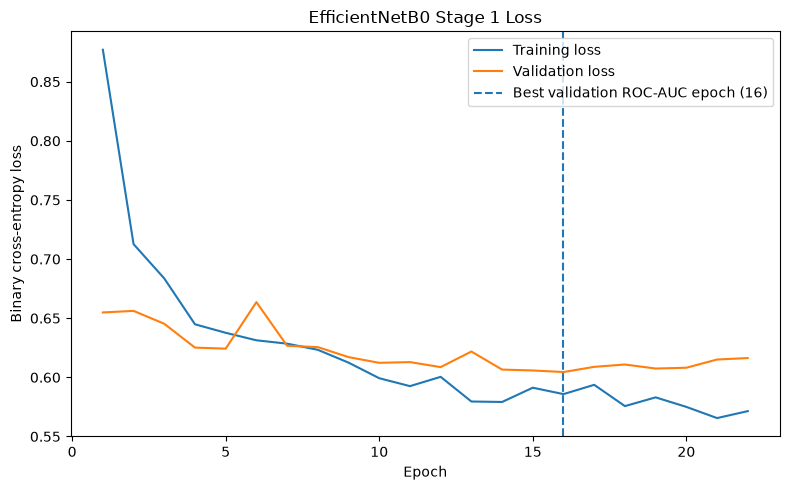

In [355]:
#plot stage 1 training and validation loss

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    efficientnet_stage_1_history_df.index,
    efficientnet_stage_1_history_df[
        "loss"
    ],
    label="Training loss"
)

plt.plot(
    efficientnet_stage_1_history_df.index,
    efficientnet_stage_1_history_df[
        "val_loss"
    ],
    label="Validation loss"
)

#mark the epoch selected using validation ROC-AUC
plt.axvline(
    x=efficientnet_stage_1_best_epoch,
    linestyle="--",
    label=(
        "Best validation ROC-AUC epoch "
        f"({efficientnet_stage_1_best_epoch})"
    )
)

plt.title(
    "EfficientNetB0 Stage 1 Loss"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Binary cross-entropy loss"
)

plt.legend()
plt.tight_layout()
plt.show()

__Learning curve intepretation__

Training loss decreased from `0.8770` to `0.5858` by the selected epoch, while validation loss decreased from `0.6549` to `0.6045`. This shows that the classification head learned progressively useful representations from the frozen EfficientNet features.

After epoch 16, training performance continued to improve while validation loss and ROC-AUC flunctuated without further improvement, This indicates the beginning of mild overfitting and supports the early-stopping decision. The selected checkpoint therefore capture the strongest validation discrimination before the generalisation gap increased.

__Stage 1 ROC-AUC Learning Curve__
Training and validation ROC-AUC are compared across apochs to assess how discrimination develops during frozen-backbone feature extraction. The vertical line identifies the checkpoint selected using the highest validation ROC-AUC.

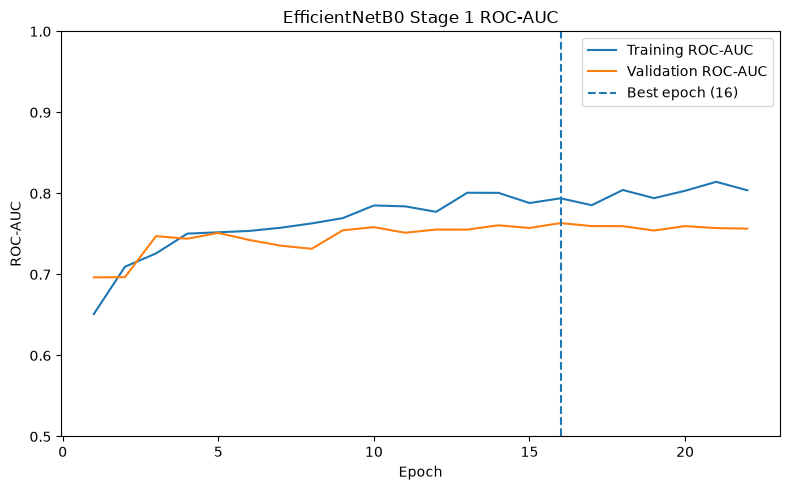

In [380]:
#plot stage 1 training and validation ROC-AUC
plt.figure(
    figsize=(8, 5)
)

#plot discrimination measured on the training partition
plt.plot(
    efficientnet_stage_1_history_df.index,
    efficientnet_stage_1_history_df["roc_auc"],
    label="Training ROC-AUC"
)

#plot discrimination measured on unseen validation data
plt.plot(
    efficientnet_stage_1_history_df.index,
    efficientnet_stage_1_history_df["val_roc_auc"],
    label="Validation ROC-AUC"
)

#mark the epoch with the highest validation ROC-AUC
plt.axvline(
    efficientnet_stage_1_best_epoch,
    linestyle="--",
    label=(
        f"Best epoch "
        f"({efficientnet_stage_1_best_epoch})"
    )
)

plt.title(
    "EfficientNetB0 Stage 1 ROC-AUC"
)

plt.xlabel("Epoch")
plt.ylabel("ROC-AUC")
plt.ylim(0.5, 1.0)
plt.legend()
plt.tight_layout()
plt.show()

__Interpretation__

Validation ROC-AUC increased from `0.6964` to its maximum of `0.7634` at epoch 16, showing that the classification head learned to use the frozen EfficientNetBO features effectively. At this epoch, training ROC-AUC was `0.7939`, giving a modest generalisation gap of approximately `0.031`.

After epoch 16, training ROC-AUC continued to increase while validation ROC-AUC remained around `0.75-0.76`. This divergence indicates emerging overfitting: the classification head continued fitting the tranining data without improving validation discrimination. The graph therefore supports selecting epoch 16 and using early stopping rather than retaining the final epoch. 

__Stage 1 Precision Recall AUC Learning Curve__

Training and validation PR-AUC are compared across epochs to evaluate how effectively the model identifies malignant lesions while controlling false-positive predictions. The marked epoch remains the checkpoint selected by validation ROC-AUC.

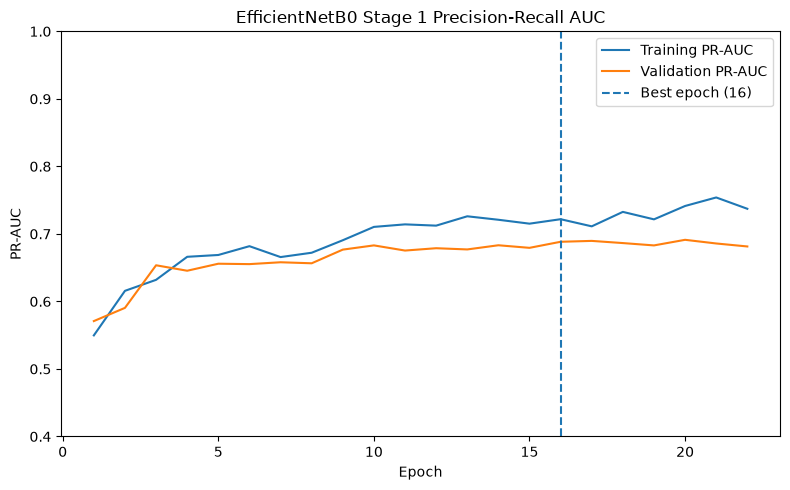

In [381]:
#plot stage 1 training and validation PR-AUC
plt.figure(
    figsize=(8, 5)
)

#plot training precision recall discrimination
plt.plot(
    efficientnet_stage_1_history_df.index,
    efficientnet_stage_1_history_df["pr_auc"],
    label="Training PR-AUC"
)

#plot precision recall discrimination on validation data
plt.plot(
    efficientnet_stage_1_history_df.index,
    efficientnet_stage_1_history_df["val_pr_auc"],
    label="Validation PR-AUC"
)

#mark the checkpoint selected using validation roc-auc
plt.axvline(
    efficientnet_stage_1_best_epoch,
    linestyle="--",
    label=(
        f"Best epoch "
        f"({efficientnet_stage_1_best_epoch})"
    )
)

plt.title(
    "EfficientNetB0 Stage 1 Precision-Recall AUC"
)

plt.xlabel("Epoch")
plt.ylabel("PR-AUC")
plt.ylim(0.4, 1.0)
plt.legend()
plt.tight_layout()
plt.show()

__Interpretation__

Validation PR-AUC increased from `0.5709` to `0.6884` at the selected epoch, demonstrating improved identification of malignant lesion across decision thresholds. At epoch 16, training PR-AUC was `0.7218`, giving a modest generalisation gap of approximately `0.033`.

Validation PR-AUC subsequently remained near `0.68-0.69`, while training PR-AUC continued to increase. This plateau supports the conclusion that further Stage 1 training offered limited generalisation benefit. Although validation PR-AUC reached a slightly higher value of `0.6913` at epoch 20, epoch 16 remains the selected checkpoint because model selection was consistently based on validation ROC-AUC.

### 11.10 Stage 2 Selective Fine Tuning

The best Stage 1 checkpoint is restored before fine-tuning begins. This ensures that Stage 2 starts from the strongest frozen-backbone model rather than the final Stage 1 epoch.

Only the deepest portion of EfficientNetB0 is made trainable. These layers encode higher-level representations that may benefit from adaptation to mammographic tissue and lesion morphology. Earlier layers remain frozen to preserve more general visual features learned during ImageNet pretraining.

Batch-normalisation layers also remain frozen because updating their moving statistics using the comparatively small mammography dataset could destabilise the pretrained representation. After modifying layer trainability, the model is recompiled using a learning rate of $1 \times{10^5}$ to limit destructive changes to the pretrained weights.

### Best Stage 1 Checkpoint Restoration

In [382]:
#restore the best complete stage 1 model
assert EFFICIENTNET_STAGE_1_PATH.is_file(), (
    "The best Stage 1 checkpoint was not found."
)

efficientnet_fine_tune_model = (
    tf.keras.models.load_model(
        EFFICIENTNET_STAGE_1_PATH
    )
)

#retrieve the nested efficientnetbo backbone
efficientnet_fine_tune_base = (
    efficientnet_fine_tune_model.get_layer(
        "efficientnetb0"
    )
)

print(
    "Best Stage 1 model restored successfully."
)

Best Stage 1 model restored successfully.


### Selective Backbone Unfreezing

In [383]:
#selectively unfreeze the deepest backbone layers
FINE_TUNE_LAYER_COUNT = 30

#confirm that the requested number does not exceed the number of layers contained in the backbone
assert(
    0 < FINE_TUNE_LAYER_COUNT
    <= len(efficientnet_fine_tune_base.layers)
), (
    "The requested fine-tuning layer count is invalid."
)

#make the backbone eligible for selective fine-tuning
efficientnet_fine_tune_base.trainable = True

#keep all layers before the final fine-tuning frozen
for layer in efficientnet_fine_tune_base.layers[
    :-FINE_TUNE_LAYER_COUNT
]:
    layer.trainable = False

#unfreeze the final layers, except batch normalisation layers, whose learned statistics should remain fixed
for layer in efficientnet_fine_tune_base.layers[
    -FINE_TUNE_LAYER_COUNT:
]:

    if isinstance(
        layer,
        tf.keras.layers.BatchNormalization
    ):
        layer.trainable=False
    else: 
        layer.trainable=True

### Stage 2 Trainability Validation

In [384]:
#identify trainable and frozen backbone layers
fine_tune_trainable_backbone_layers = [
    layer.name
    for layer
    in efficientnet_fine_tune_base.layers
    if layer.trainable
]

fine_tune_frozen_backbone_layers = [
    layer.name
    for layer
    in efficientnet_fine_tune_base.layers
    if not layer.trainable
]

print(
    "Trainable backbone layers:",
    len(
        fine_tune_trainable_backbone_layers
    )
)

print(
    "Frozen backbone layers:",
    len(
        fine_tune_frozen_backbone_layers
    )
)

print(
    "Trainable backbone layers:"
)

for layer_name in fine_tune_trainable_backbone_layers:
    print(
        "-",
        layer_name
    )

#Compare Stage 1 and Stage 2 parameter allocations
#==============================================================
stage_2_parameter_counts = count_model_parameters(
    efficientnet_fine_tune_model
)

parameter_comparison = pd.DataFrame(
    [
        stage_1_parameter_counts,
        stage_2_parameter_counts
    ],
    index=[
        "Stage 1: frozen backbone",
        "Stage 2: selective fine-tuning"
    ]
)

display(
    parameter_comparison
)

#stage 2 should contain more trainable parameters because part of the pretrained backbone has been unfrozen
assert(
    stage_2_parameter_counts[
        "Trainable parameters"
    ]
    > stage_1_parameter_counts[
        "Trainable parameters"
    ]
)

#some parameters must remain frozen during selective fine-tuning
assert(
    stage_2_parameter_counts[
        "Trainable parameters"
    ]
    < stage_2_parameter_counts[
        "Total parameters"
    ]
)

#confirm that at least one backbone layer is trainable
assert(
    len(
        fine_tune_trainable_backbone_layers
    )
    > 0 
)

#confirm that every backbone batch-normalisation layer remains frozen
assert all(
    not layer.trainable
    for layer 
    in efficientnet_fine_tune_base.layers
    if isinstance(
        layer,
        tf.keras.layers.BatchNormalization
    )
)

print(
    "Stage 2 trainability validation passed."
)

Trainable backbone layers: 23
Frozen backbone layers: 215
Trainable backbone layers:
- block6d_expand_activation
- block6d_dwconv
- block6d_activation
- block6d_se_squeeze
- block6d_se_reshape
- block6d_se_reduce
- block6d_se_expand
- block6d_se_excite
- block6d_project_conv
- block6d_drop
- block6d_add
- block7a_expand_conv
- block7a_expand_activation
- block7a_dwconv
- block7a_activation
- block7a_se_squeeze
- block7a_se_reshape
- block7a_se_reduce
- block7a_se_expand
- block7a_se_excite
- block7a_project_conv
- top_conv
- top_activation


,Trainable parameters,Non-trainable parameters,Total parameters
Stage 1: frozen backbone,331265,4052643,4383908
Stage 2: selective fine-tuning,1814625,2569283,4383908


Stage 2 trainability validation passed.


__Interpretation__

The Stage 2 summary should show more trainable parameters than Stage 1 while retaining a larger set of frozen parameters. This confirms that fine-tuning is selctive rather than applied to the entire backbone. The exact number of trainable backbone layers may be lower than 30 because batch-normalisation layers within the selected region remain frozen.

### Fine Tuning Compilation

The model must be recompiled after changing layer trainability so that TensorFlow updates the correct set of parameters. 

In [385]:
#recompile the selectively unfrozen model
efficientnet_fine_tune_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=FINE_TUNE_LEARNING_RATE
    ),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=create_binary_classification_metrics()
)

print(
    "Fine-tuning model compiled successfully."
)

print(
    "Fine-tuning learning rate:",
    FINE_TUNE_LEARNING_RATE
)

Fine-tuning model compiled successfully.
Fine-tuning learning rate: 1e-05


The substantially lower learning rate permits gradual adaptation of the selected pretrained layers while reducing the risk of catastrophic forgetting.

### 11.10.1 Fine-Tuning Configuration

The selectively unfrozen model is fine-tuned for a maximum of 20 epochs. Validation ROC-AUC remains the checkpoint-selection criterion, maintaining consistency with Stage 1 and the baseline CNN.

A separate Stage 2 checkpoint preserves the best fine-tuned model and enables direct comparison with the frozen-backbone checkpoint.

In [386]:
#Define Stage 2 checkpoint and training limit
EFFICIENTNET_STAGE_2_PATH = (
    EFFICIENT_MODEL_DIRECTORY
    / "efficientnetb0_stage2_best.keras"
)

EFFICIENTNET_STAGE_2_MAX_EPOCHS = 20

#Configure Stage 2 training callbacks
efficientnet_stage_2_callbacks = [

    #stop when validation discrimination no longer improves and restore the best weights in memory
    tf.keras.callbacks.EarlyStopping(
        monitor="val_roc_auc",
        mode="max",
        patience=6,
        min_delta=1e-4,
        restore_best_weights=True,
        verbose=1
    ),

    #reduce the learning rate if validation loss plateaus
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=3,
        min_delta=1e-4,
        min_lr=1e-7,
        verbose=1
    ),

    #preserve the complete model achieving the highest stage 2 validation ROC-AUC
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(
            EFFICIENTNET_STAGE_2_PATH
        ),
        monitor="val_roc_auc",
        mode="max",
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    ),

    #stop training if an invalid numerical loss occurs
    tf.keras.callbacks.TerminateOnNaN()
]

print(
    "Stage 2 checkpoint:",
    EFFICIENTNET_STAGE_2_PATH.resolve()
)

print(
    "Stage 2 callbacks configured:",
    len(
        efficientnet_stage_2_callbacks
    )
)

Stage 2 checkpoint: /Users/marcela/FinalProject/models/efficientnetb0/efficientnetb0_stage2_best.keras
Stage 2 callbacks configured: 4


### 11.11 Stage 2 Fine-Tuning
Fine-tuning from the best Stage 1 checkpoint. The training and validation partitions, augmentation strategy and class weights remain unchanged, ensuring a consistent comparison between the two training stages. 


In [387]:
#Fine tune the selected EfficientNetBO backbone layers
efficientnet_stage_2_history = (
    efficientnet_fine_tune_model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=EFFICIENTNET_STAGE_2_MAX_EPOCHS,
        class_weight=class_weights,
        callbacks=efficientnet_stage_2_callbacks,
        verbose=1
    )
)

Epoch 1/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step - binary_accuracy: 0.7245 - loss: 0.5643 - pr_auc: 0.7600 - precision: 0.6523 - recall: 0.7310 - roc_auc: 0.8166
Epoch 1: val_roc_auc improved from None to 0.76399, saving model to models/efficientnetb0/efficientnetb0_stage2_best.keras

Epoch 1: finished saving model to models/efficientnetb0/efficientnetb0_stage2_best.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 42s 466ms/step - binary_accuracy: 0.7134 - loss: 0.5714 - pr_auc: 0.7413 - precision: 0.6277 - recall: 0.7245 - roc_auc: 0.8060 - val_binary_accuracy: 0.6627 - val_loss: 0.6067 - val_pr_auc: 0.6872 - val_precision: 0.5794 - val_recall: 0.6078 - val_roc_auc: 0.7640 - learning_rate: 1.0000e-05
Epoch 2/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - binary_accuracy: 0.7085 - loss: 0.5855 - pr_auc: 0.7082 - precision: 0.6195 - recall: 0.7333 - roc_auc: 0.7932
Epoch 2: val_roc_auc improved from 0.76399 to 0.76542, saving model to models/efficientnetb0/efficientnetb0_stage2_best.keras

Epoch 2: f

### 11.12 Fine-Tuning History Analysis



In [391]:
#convert the stage 2 fine tuning history into a DataFrame for inspection
efficientnet_stage_2_history_df = pd.DataFrame(
    efficientnet_stage_2_history.history
)

#convert the zero-based DataFrame index into human-readable epoch numbers
efficientnet_stage_2_history_df.index = (
    efficientnet_stage_2_history_df.index + 1
)

#label the index to clearly indentify the epoch number
efficientnet_stage_2_history_df.index.name = "Epoch"

#display the complete stage 2 training and validation history
display(
    efficientnet_stage_2_history_df
)

,binary_accuracy,loss,pr_auc,precision,recall,roc_auc,val_binary_accuracy,val_loss,val_pr_auc,val_precision,val_recall,val_roc_auc,learning_rate
Epoch,,,,,,,,,,,,,
1,0.713441,0.571368,0.741320,0.627731,0.724539,0.805956,0.662698,0.606698,0.687209,0.579439,0.607843,0.763987,0.000010
2,0.714624,0.573815,0.729274,0.625923,0.740058,0.803454,0.666667,0.602579,0.688534,0.587379,0.593137,0.765417,0.000010
3,0.723689,0.565614,0.741542,0.636139,0.747818,0.810788,0.686508,0.602855,0.686615,0.611650,0.617647,0.766038,0.000010
4,0.718171,0.572185,0.741391,0.633672,0.726479,0.803525,0.676587,0.602541,0.687828,0.596244,0.622549,0.767476,0.000010
5,0.735909,0.562548,0.744396,0.647830,0.767216,0.813454,0.680556,0.600813,0.690180,0.606965,0.598039,0.768415,0.000010
6,0.728419,0.569215,0.734164,0.639935,0.758487,0.808057,0.686508,0.601805,0.689798,0.617347,0.593137,0.768080,0.000010
7,0.720930,0.565639,0.749836,0.630981,0.754607,0.810329,0.666667,0.606367,0.689215,0.582569,0.622549,0.768088,0.000010
8,0.735909,0.555220,0.756240,0.647588,0.768186,0.821012,0.668651,0.604195,0.688832,0.590244,0.593137,0.767819,0.000010
9,0.731967,0.557571,0.753909,0.647603,0.746848,0.820109,0.668651,0.603599,0.688632,0.591133,0.588235,0.768333,0.000005


In [392]:
#define the file path used to preserve the stahge 2 fine tuning history
EFFICIENTNET_STAGE_2_HISTORY_PATH = (
    EFFICIENTNET_MODEL_DIRECTORY
    / "efficientnetb0_stage_2_history.csv"
)

#save the complete stage 2 training and validation history as csv file
efficientnet_stage_2_history_df.to_csv(
    EFFICIENTNET_STAGE_2_HISTORY_PATH,
    index=True
)

#confim the location of the saved stage 2 training history
print(
    "Stage 2 training history saved to:",
    EFFICIENTNET_STAGE_2_HISTORY_PATH.resolve()
)

Stage 2 training history saved to: /Users/marcela/FinalProject/models/efficientnetb0/efficientnetb0_stage_2_history.csv


In [393]:
#identify the stage 2 epoch achieving the highest validation ROC-AUC
efficientnet_stage_2_best_epoch = (
    efficientnet_stage_2_history_df[
        "val_roc_auc"
    ]
    .idxmax()
)

#retrieve all training and validation metrics recorded at the best epoch
efficientnet_stage_2_best_results = (
    efficientnet_stage_2_history_df.loc[
        efficientnet_stage_2_best_epoch
    ]
)

#report the epoch selected according to validation ROC-AUC
print(
    "Best Stage 2 epoch:",
    efficientnet_stage_2_best_epoch
)

#report the training ROC-AUC achieved at the selected epoch
print(
    "Training ROC-AUC:",
    f"{efficientnet_stage_2_best_results['roc_auc']:.4f}"
)

#report the validation ROC-AUC used for best epoch selection
print(
    "Validation ROC-AUC:",
    f"{efficientnet_stage_2_best_results['val_roc_auc']:.4f}"
)

#report the validation precision-recall area under the curve
print(
    "Validation PR-AUC:",
    f"{efficientnet_stage_2_best_results['val_pr_auc']:.4f}"
)

#report the validation binary classification accuracy
print(
    "Validation accuracy:",
    f"{efficientnet_stage_2_best_results['val_binary_accuracy']:.4f}"
)

#report the validation precision at the classification threshold
print(
    "Validation precision:",
    f"{efficientnet_stage_2_best_results['val_precision']:.4f}"
)

#report the validation recall at the classification threshold
print(
    "Validation recall:",
    f"{efficientnet_stage_2_best_results['val_recall']:.4f}"
)

Best Stage 2 epoch: 5
Training ROC-AUC: 0.8135
Validation ROC-AUC: 0.7684
Validation PR-AUC: 0.6902
Validation accuracy: 0.6806
Validation precision: 0.6070
Validation recall: 0.5980


__Interpretation__

Stage 2 reached its highest validation ROC-AUC of 0.7684 at epoch 5, compared with 0.7634 for the best frozen backbone model. This increase of approximately 0.0051 suggests that selective fine-tuning provided a small improvement in discrimination. At the selected epoch, validation PR-AUC was 0.6902; at the default 0.5 threshold, precision was 0.6070 and recall was 0.5980.

Validation ROC-AUC did not improve over the following six epochs, so early stopping ended training at epoch 11 and restored the epoch 5 weights. The selected checkpoint will be used for subsequent validation analysis and comparison with Stage 1.

### 11.12.2 Fine-Tuning Learning Curves

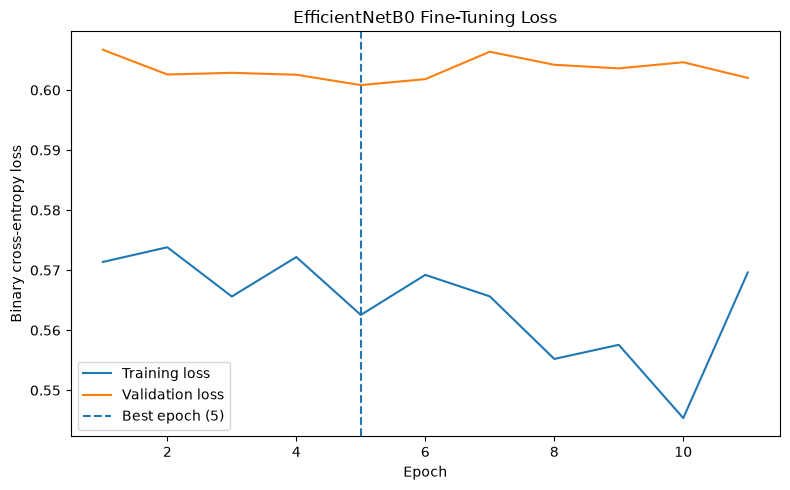

In [399]:
#create a figure for visualising the stage 2 training and validation loss
plt.figure(
    figsize=(8, 5)
)

#plot the training loss across fine-tuning epochs
plt.plot(
    efficientnet_stage_2_history_df.index,
    efficientnet_stage_2_history_df["loss"],
    label="Training loss"
)

#plot the validation loss across fine-tuning epochs
plt.plot(
    efficientnet_stage_2_history_df.index,
    efficientnet_stage_2_history_df["val_loss"],
    label="Validation loss"
)

#mark the epoch achieving the highest validation ROC-AUC
plt.axvline(
    efficientnet_stage_2_best_epoch,
    linestyle="--",
    label=(
        f"Best epoch "
        f"({efficientnet_stage_2_best_epoch})"
    )
)

#label the tuning loss plot
plt.title(
    "EfficientNetB0 Fine-Tuning Loss"
)

#label the plot axes
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy loss")

#display the legend and optimise the figure layout
plt.legend()
plt.tight_layout()
plt.show()

__Interpretation__

__Loss curve__: Lower binary cross-entropy indicates better agreement between predicted probabilities and true labels. Validation loss reached its lowest value of 0.6008 at epoch 5, then fluctuated while training loss generally decreased. The widening separation suggests that further optimisation improved fit to the training images without a corresponding validation benefit.

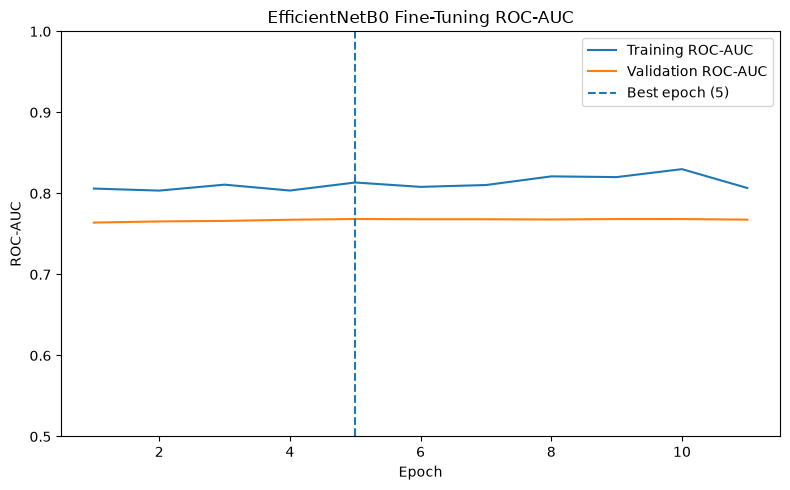

In [401]:
#create a figure for visualising the stage 2 training and validation ROC-AUC
plt.figure(
    figsize=(8, 5)
)

#plot the training ROC-AUC across fine-tuning epochs
plt.plot(
    efficientnet_stage_2_history_df.index,
    efficientnet_stage_2_history_df["roc_auc"],
    label="Training ROC-AUC"
)

#plot the validation ROC-AUC across fine tuning epochs
plt.plot(
    efficientnet_stage_2_history_df.index,
    efficientnet_stage_2_history_df["val_roc_auc"],
    label="Validation ROC-AUC"
)

#mark the epoch achieving the highest validation ROC-AUC
plt.axvline(
    efficientnet_stage_2_best_epoch,
    linestyle="--",
    label=(
        f"Best epoch "
        f"({efficientnet_stage_2_best_epoch})"
    )
)

#label the stage 2 roc-auc plot
plt.title(
    "EfficientNetB0 Fine-Tuning ROC-AUC"
)

#label the plot axes
plt.xlabel("Epoch")
plt.ylabel("ROC-AUC")

#displaye the lend and optimise the fig layout
plt.ylim(0.5, 1.0)
plt.legend()
plt.tight_layout()
plt.show()

__Interpretation__

__ROC-AUC curve__:Higher ROC-AUC indicates better ranking of malignant lesions above benign lesions across decicion thresholds. Validation ROC-AUC rose slightly to 0.7684 at epoch 5 and the plateaued, although training ROC-AUC continued to increase. This suports selecting epoch 5 and shows that additional fine-tuning brought little improvement in discrimination on unseen validation images.


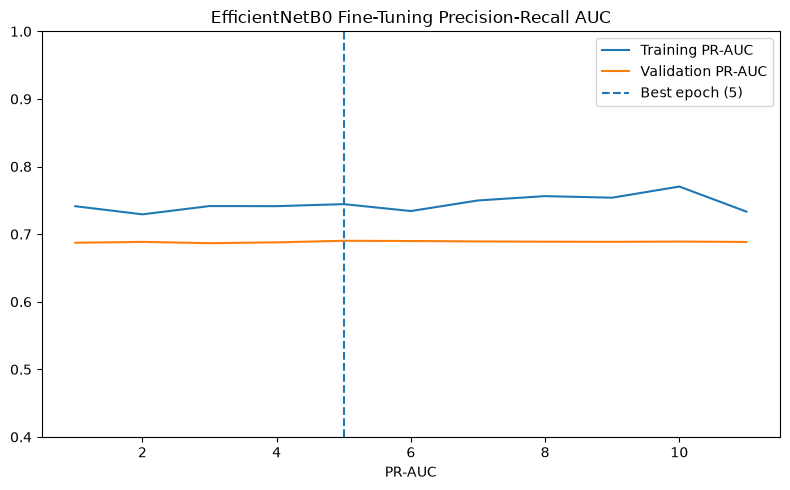

In [402]:
#create a figure for visualising stage 2 training and validation PR-AUC
plt.figure(
    figsize=(8, 5)
)

#pplot the training for visualising stage 2 training and validation PR-AUC
plt.plot(
    efficientnet_stage_2_history_df.index,
    efficientnet_stage_2_history_df["pr_auc"],
    label="Training PR-AUC"
)

#plot the training PR-AUC across fine tuning epochs
plt.plot(
    efficientnet_stage_2_history_df.index,
    efficientnet_stage_2_history_df["val_pr_auc"],
    label="Validation PR-AUC"
)

#mark the epoch achieving the highest validation ROC-AUC
plt.axvline(
    efficientnet_stage_2_best_epoch,
    linestyle="--",
    label=(
        f"Best epoch "
        f"({efficientnet_stage_2_best_epoch})"
    )
)

#label the figure
plt.title(
    "EfficientNetB0 Fine-Tuning Precision-Recall AUC"
)

#label the axes
plt.xlabel("Epoch")
plt.xlabel("PR-AUC")

#set the y-axis range to emphasize relevant PR-AUC performance
plt.ylim(0.4, 1.0)

#display the legend and optimise the figure layout
plt.legend()
plt.tight_layout()
plt.show()

__Interpretation__

__PR-AUC curve__: Higher PR-AUC indicates a better precision-recall trade-off when identifying malignant lesions. Validation PR-AUC remained close to 0.69 throughout fine-tuning, while training PR-AUC increased. Thus, the small ROC-AUC gain did not translate into a substantial improvement in malignant-lesion detection across thresholds.

### 11.13 Best Fine Tuned Model Restoration

The checkpoint with the highest Stage 2 validation ROC-AUC is loaded from disk. This ensures that subsequent analyses use the selected model state, regardless of the weights currently held in memory.

In [405]:
#confirm that the selected stage 2 checkpoint exits
assert EFFICIENTNET_STAGE_2_PATH.is_file(), (
    "The best Stage 2 checkpoint could not be found."
)

#restore the saved model = 
best_efficientnet_model = tf.keras.models.load_model(
    EFFICIENTNET_STAGE_2_PATH
)

print(
    "Best fine-tuned EfficientNet model loaded from:",
    EFFICIENTNET_STAGE_2_PATH.resolve()
)

#check that the restored model returns one finite probability between zero and one for each sample image
efficientnet_forward_predictions = best_efficientnet_model(
    forward_pass_images,
    training=False
)

assert efficientnet_forward_predictions.shape == (
    forward_pass_images.shape[0],
        1
)

assert bool(
    tf.reduce_all(
        tf.math.is_finite(efficientnet_forward_predictions)
    ).numpy()
)

assert bool(
    tf.reduce_all(
        (efficientnet_forward_predictions >= 0.0)
        & (efficientnet_forward_predictions <= 1.0)
    ).numpy()
)

print("Best fine-tuned model validation passed.")

Best fine-tuned EfficientNet model loaded from: /Users/marcela/FinalProject/models/efficientnetb0/efficientnetb0_stage2_best.keras
Best fine-tuned model validation passed.


__Interpretation:__ The restored checkpoint corresponds to Stage 2 epoch 5, which achieved the highest validation ROC-AUC of 0.7684.

### 11.14 Fine-Tuned EfficientNet Validation Probabilities

The restored model generates one malignancy probability per validation record. Dataset label order is checked against *val_df* before these probabilities are paired with their targets.

In [420]:
#initialise containers for aligned validation targets and probabilities
efficientnet_val_targets = []
efficientnet_val_probabilities = []

#generate targets and predictions together to preserve their alignment
for images, labels in val_dataset:

    #generate probabilities for the current validation batch
    batch_probabilities = (
        best_efficientnet_model(
            images,
            training=False
        )
        .numpy()
        .reshape(-1)
    )

    #store the targets for the current validation batch
    efficientnet_val_targets.extend(
        labels.numpy().astype(int).reshape(-1)
    )

    #store the probabilities for the same validation batch
    efficientnet_val_probabilities.extend(
        batch_probabilities
    )
            
#obtain targets in the row order used by val_df
efficientnet_val_targets = np.asarray(
    efficientnet_val_targets
)

efficientnet_val_probabilities = np.asarray(
    efficientnet_val_probabilities
)

#validate the number and numerical range of predictions
assert np.isfinite(
    efficientnet_val_probabilities
).all()

assert (
    (efficientnet_val_probabilities >= 0.0)
    & (efficientnet_val_probabilities <= 1.0)
).all()

#print validation target and probability dimensions
print("Validation targets:", efficientnet_val_targets.shape)
print(
    "Validation probabilities:",
    efficientnet_val_probabilities.shape
)

print(
    "Probability range:",
    (
        efficientnet_val_probabilities.min(),
        efficientnet_val_probabilities.max(),
    )
)

print("EfficientNet validation probability generation passed.")
              

Validation targets: (504,)
Validation probabilities: (504,)
Probability range: (np.float32(0.0005062484), np.float32(0.9844906))
EfficientNet validation probability generation passed.


Passing these checks establishes that every validation record has a valid probability paired with its correct label. The probability range alone does not establish whether the probabilities are well calibrated; that requires a separate analysis.

### 11.15 Fine-Tuned EfficientNet Validation Performance
The restored model is evaluated using the same default threshold and metric definitions used for the baseline CNN. Accuracy, precision, recall and F1-score use binary predictions at 0.5; ROC-AUC and average precision use the continuous probabilities.

In [424]:
#convert probabilities to classes at the threshold default
EFFICIENTNET_VALIDATION_THRESHOLD = 0.5

efficientnet_val_predictions = (
    efficientnet_val_probabilities
    >= EFFICIENTNET_VALIDATION_THRESHOLD
).astype(int)

#calculate classification and ranking metrics
efficientnet_validation_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC",
        "PR-AUC"
    ],
    "Value": [
        accuracy_score(
            efficientnet_val_targets,
            efficientnet_val_predictions
        ),

        precision_score(
            efficientnet_val_targets,
            efficientnet_val_predictions,
            zero_division=0
        ),

        recall_score(
            efficientnet_val_targets,
            efficientnet_val_predictions,
            zero_division=0
        ),

        f1_score(
            efficientnet_val_targets,
            efficientnet_val_predictions,
            zero_division=0
        ),
        
        roc_auc_score(
            efficientnet_val_targets,
            efficientnet_val_probabilities
        ),

        average_precision_score(
            efficientnet_val_targets,
            efficientnet_val_probabilities
        )
    ]
})

#round only for display
efficientnet_validation_metrics["Value"] = (
    efficientnet_validation_metrics["Value"].round(4)
)

display(efficientnet_validation_metrics)

,Metric,Value
0,Accuracy,0.6806
1,Precision,0.6070
2,Recall,0.5980
3,F1-score,0.6025
4,ROC-AUC,0.7689
5,PR-AUC,0.6908


The fine-tuned EfficientNetB0 achieved a validation ROC-AUC of 0.7689, indicating that it generally ranked malignant lesions above benign lesions. Its PR-AUC of 0.6908 provides a complementary measure of malignant lesion detection across thresholds. At the default 0.5 threshold, accuracy was 0.6806, while precision (0.6070) and recall (0.5908) were similar, producing an F1-score of 0.6025. The recall means that approximately 40% of malignant records were missing at this threshold, so the model's decision threshold requires further validation before its classification results can be judged for clinical use.
                                                                                                                                                                                                                                                                                                                           

### 11.16 Validation Performance Comparison

The best validation epochs of the baseline CNN, frozen-backbone EfficientNetB0 and fine-tuned EfficientNetB0 are compared using metrics recorded consistently during training. This shows show much of the observed improvement occured during pretrained feature extraction and how much followed selective fine-tuning.

In [428]:
#Use keras history metrics for all three selected epochs
model_validation_comparison = pd.DataFrame({
    "Model":[
        "Baseline CNN",
        "EfficientNetB0 Stage 1",
        "EfficientNetB0 Stage 2"
    ],
    "ROC-AUC":[
        best_epoch_results["val_roc_auc"],
        efficientnet_stage_1_best_results["val_roc_auc"],
        efficientnet_stage_2_best_results["val_roc_auc"],
    ],
    "PR-AUC":[
        best_epoch_results["val_pr_auc"],
        efficientnet_stage_1_best_results["val_pr_auc"],
        efficientnet_stage_2_best_results["val_pr_auc"],
    ],
    "Accuracy at 0.5":[
        best_epoch_results["val_binary_accuracy"],
        efficientnet_stage_1_best_results["val_binary_accuracy"],
        efficientnet_stage_2_best_results["val_binary_accuracy"]
    ],
    "Precision at 0.5":[
        best_epoch_results["val_precision"],
        efficientnet_stage_1_best_results["val_precision"],
        efficientnet_stage_2_best_results["val_precision"]
    ],
    "Recall at 0.5":[
        best_epoch_results["val_recall"],
        efficientnet_stage_1_best_results["val_recall"],
        efficientnet_stage_2_best_results["val_recall"]
    ]
})

#present the comparison to 4 dec places
numeric_columns = model_validation_comparison.columns.drop("Model")
model_validation_comparison[numeric_columns] = (
    model_validation_comparison[numeric_columns].round(4)
)

display(model_validation_comparison)

,Model,ROC-AUC,PR-AUC,Accuracy at 0.5,Precision at 0.5,Recall at 0.5
0,Baseline CNN,0.6552,0.5143,0.5218,0.4575,0.9755
1,EfficientNetB0 Stage 1,0.7634,0.6884,0.6746,0.5980,0.5980
2,EfficientNetB0 Stage 2,0.7684,0.6902,0.6806,0.6070,0.5980


EfficientNetB0 improved validation discrimination over the baseline CNN: ROC-AUC rose from 0.6552 to 0.7634 with the frozen backbone, then to 0.7684 after the fine-tuning. PR-AUC followed the same pattern, with most of the gain occuring in Stage 1 and only a small additional gain in Stage 2.

At the 0.5 threshold, the baseline detected nearly all malignant records (recall 0.9755) but had low precision (0.4575), reflecting many false positives. Stage 2 increased precision to 0.6070 while recall fell to 0.5980. Thus. EfficientNetB0 ranked lesions more effectively overall, but its threshold must be considered separately when balancing missed malignancies against false alarms.

### 11.17 Additional EfficientNetV2B0 Comparison

EfficientNetV2B0 is included as an exploratory architectural comparison. It uses the same patient-independent partitions, image pipeline, class weights and validation-based checkpoint criterion. Its smaller classification head and shorter training limits keep the added experiment practical, but mean that differences in performance cannot be attributed solely to the backbone. This comparison uses validation data; the held-out test partition remains untouched.

In [430]:
from tensorflow.keras.applications import EfficientNetV2B0

#use the shared image dimensions and a shorter training budget
EFFICIENTNETV2_INPUT_SHAPE = (
    TARGET_IMAGE_SIZE[0],
    TARGET_IMAGE_SIZE[1],
    OUTPUT_CHANNELS
)

EFFICIENTNETV2_STAGE_1_LEARNING_RATE = 1e-3
EFFICIENTNETV2_FINE_TUNE_LEARNING_RATE = 1e-5
EFFICIENTNETV2_STAGE_1_MAX_EPOCHS = 12
EFFICIENTNETV2_STAGE_2_MAX_EPOCHS = 8
EFFICIENTNETV2_FINE_TUNE_LAYER_COUNT = 20

assert EFFICIENTNETV2_INPUT_SHAPE == (224, 224, 3)

print("EfficientNetV2B0 input shape:", EFFICIENTNETV2_INPUT_SHAPE)
print("Stage 1 maximum epochs:", EFFICIENTNETV2_STAGE_1_MAX_EPOCHS)
print("Stage 2 maximum epochs:", EFFICIENTNETV2_STAGE_2_MAX_EPOCHS)    

EfficientNetV2B0 input shape: (224, 224, 3)
Stage 1 maximum epochs: 12
Stage 2 maximum epochs: 8


### 11.17.1 EfficientNetV2B0 Architecture

The ImageNet classification layer is removed and replaced with a compact binary classification head. The exising data supplies images in `[0, 1]`; a model-level rescaling layer converts them to `[0, 255]` before they reach EfficientNetV2B0 with its built-in preprocessing enabled.

In [436]:
#load ImageNet features without the original classification head
efficientnetv2_base = EfficientNetV2B0(
    include_top=False,
    weights="imagenet",
    input_shape=EFFICIENTNETV2_INPUT_SHAPE,
    include_preprocessing=True
)

#keep the backbone frozen during Stage 1
efficientnetv2_base.trainable = False

def build_efficientnetv2_model():
    """Construct an EfficientNetV2B0 binary classifier."""

    inputs = tf.keras.Input(
        shape=EFFICIENTNETV2_INPUT_SHAPE,
        name="mammogram_input"
    )

    #augmentation acts during training through the model
    x = data_augmentation(inputs)

    #convert shared dataset images from [0, 1] to [0, 255].
    x = tf.keras.layers.Rescaling(
        255.0,
        name="efficientnetv2_input_rescaling"
    )(x)

    #inference mode preserves backbone batch-normalisation behaviour
    x = efficientnetv2_base(x, training=False)

    #reduce feature maps to a compact image representation
    x = tf.keras.layers.GlobalAveragePooling2D(
        name="global_average_pooling"
    )(x)

    x = tf.keras.layers.BatchNormalization(
        name="classification_batch_normalization"
    )(x)

    #regularise the new classification head
    x = tf.keras.layers.Dropout(
        0.35,
        name="classification_dropout"
    )(x)
    x = tf.keras.layers.Dense(
            128,
            activation="relu",
            kernel_regularizer=tf.keras.regularizers.l2(1e-4),
            name="classification_dense"
    )(x)
    x = tf.keras.layers.Dropout(
        0.25,
        name="classification_dropout_2"
    )(x)

    #return one estimated malignancy probability per image
    outputs = tf.keras.layers.Dense(
        1,
        activation="sigmoid",
        name="malignancy_probability"
    )(x)

    return tf.keras.Model(
        inputs,
        outputs,
        name="efficientnetv2b0_transfer_learning"
    )

efficientnetv2_model = build_efficientnetv2_model()
efficientnetv2_model.summary()

#verify dimensions and finite forward pass
assert efficientnetv2_model.input_shape == (None, 224, 224, 3)
assert efficientnetv2_model.output_shape == (None, 1)
assert efficientnetv2_base.trainable is False

efficientnetv2_sample_images, _ = next(iter(train_dataset))
efficientnetv2_sample_predictions = efficientnetv2_model(
    efficientnetv2_sample_images,
    training=False
)

assert efficientnetv2_sample_predictions.shape == (
    efficientnetv2_sample_images.shape[0],
    1
)

assert bool(
    tf.reduce_all(
        tf.math.is_finite(efficientnetv2_sample_predictions)
    ).numpy()
)

print("EfficientNetV2B0 structure and forward pass validated.")

Model: "efficientnetv2b0_transfer_learning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mammogram_input (InputLayer)    │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ training_data_augmentation      │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2_input_rescaling  │ (None, 224, 224, 3)    │             0 │
│ (Rescaling)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification_batch_normaliza… │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification_dropout          │ (None, 1280)           │             0 │
│ (Dropout)                       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification_dense (Dense)    │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification_dropout_2        │ (None, 128)            │             0 │
│ (Dropout)                       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ malignancy_probability (Dense)  │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,088,529 (23.23 MB)

 Trainable params: 166,657 (651.00 KB)

 Non-trainable params: 5,921,872 (22.59 MB)

EfficientNetV2B0 structure and forward pass validated.


These checks establish that the model accepts the shared image format and returns finite binary probabilities. They do not assess classification performance.

### 11.17.1 Frozen-Backbone Feature Extraction
Stage 1 trains the new classification head while the EfficientNetV2B0 backbone remains frozen. Validation ROC-AUC selects its best checkpoint, which becomes the starting point for Stage 2.

In [441]:
#keep v2 checkpoints separate from the preceding models
EFFICIENTNETV2_MODEL_DIRECTORY = (
    MODEL_DIRECTORY / "efficientnetv2b0"
)

EFFICIENTNETV2_MODEL_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True
)

EFFICIENTNETV2_STAGE_1_PATH = (
    EFFICIENTNETV2_MODEL_DIRECTORY
    / "efficientnetv2b0_stage_1_best.keras"
)

#compile with the shared loss and fresh metric objects
efficientnetv2_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=EFFICIENTNETV2_STAGE_1_LEARNING_RATE
    ),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=create_binary_classification_metrics()
)

#stop when validation discrimination plateaus, reduce the rate when validation loss plateaus, and save the best checkpoint
efficientnetv2_stage_1_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_roc_auc",
        mode="max",
        patience=4,
        min_delta=1e-4,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=2,
        min_delta=1e-4,
        min_lr=1e-6,
        verbose=1
    ),
     tf.keras.callbacks.ModelCheckpoint(
        filepath=str(EFFICIENTNETV2_STAGE_1_PATH),
        monitor="val_roc_auc",
        mode="max",
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    ),
    tf.keras.callbacks.TerminateOnNaN()
]

#train only the newly added head
efficientnetv2_stage_1_history = efficientnetv2_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EFFICIENTNETV2_STAGE_1_MAX_EPOCHS,
    class_weight=class_weights,
    callbacks=efficientnetv2_stage_1_callbacks,
    verbose=1
)

Epoch 1/12
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step - binary_accuracy: 0.5441 - loss: 0.9069 - pr_auc: 0.4923 - precision: 0.4398 - recall: 0.5338 - roc_auc: 0.5866
Epoch 1: val_roc_auc improved from None to 0.69150, saving model to models/efficientnetv2b0/efficientnetv2b0_stage_1_best.keras

Epoch 1: finished saving model to models/efficientnetv2b0/efficientnetv2b0_stage_1_best.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 37s 399ms/step - binary_accuracy: 0.5944 - loss: 0.8319 - pr_auc: 0.5448 - precision: 0.5008 - recall: 0.6004 - roc_auc: 0.6481 - val_binary_accuracy: 0.6052 - val_loss: 0.6607 - val_pr_auc: 0.5942 - val_precision: 0.5084 - val_recall: 0.7402 - val_roc_auc: 0.6915 - learning_rate: 0.0010
Epoch 2/12
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step - binary_accuracy: 0.6427 - loss: 0.7501 - pr_auc: 0.6176 - precision: 0.5545 - recall: 0.6456 - roc_auc: 0.7048
Epoch 2: val_roc_auc did not improve from 0.69150
80/80 ━━━━━━━━━━━━━━━━━━━━ 29s 367ms/step - binary_accuracy: 0.6393 - loss: 0.749

In [444]:
#train only the newly added head
efficientnetv2_stage_1_history_df = pd.DataFrame(
    efficientnetv2_stage_1_history.history
)

efficientnetv2_stage_1_history_df.index += 1
efficientnetv2_stage_1_history_df.index.name = "Epoch"

#select the epoch with the highest validation ROC-AUC
efficientnetv2_stage_1_best_epoch = (
    efficientnetv2_stage_1_history_df["val_roc_auc"].idxmax()
)

efficientnetv2_stage_1_best_results = (
    efficientnetv2_stage_1_history_df.loc[
        efficientnetv2_stage_1_best_epoch
    ]
)

display(efficientnetv2_stage_1_history_df)

print(
    "Best EfficientNetV2B0 Stage 1 epoch:",
    efficientnetv2_stage_1_best_epoch 
)

print(
    "Best Validation ROC-AUC:",
    F"{efficientnetv2_stage_1_best_results['val_roc_auc']:.4f}"
)

print(
    "Best Validation PR-AUC at that epoch:",
    F"{efficientnetv2_stage_1_best_results['val_pr_auc']:.4f}"
)

,binary_accuracy,loss,pr_auc,precision,recall,roc_auc,val_binary_accuracy,val_loss,val_pr_auc,val_precision,val_recall,val_roc_auc,learning_rate
Epoch,,,,,,,,,,,,,
1,0.594403,0.831928,0.544832,0.500809,0.600388,0.648076,0.605159,0.660743,0.594173,0.508417,0.740196,0.691503,0.0010
2,0.639338,0.749635,0.602197,0.547463,0.648885,0.699016,0.626984,0.640470,0.588665,0.621212,0.200980,0.675319,0.0010
3,0.640914,0.696400,0.618795,0.548387,0.659554,0.712005,0.662698,0.618355,0.606118,0.595506,0.519608,0.711601,0.0010
4,0.665353,0.659318,0.649158,0.575960,0.669253,0.735673,0.656746,0.631740,0.580419,0.613139,0.411765,0.679894,0.0010
5,0.666141,0.628787,0.664747,0.575908,0.677013,0.748950,0.628968,0.647159,0.576837,0.534979,0.637255,0.687435,0.0010
6,0.679149,0.614090,0.680011,0.586869,0.710960,0.760359,0.646825,0.632231,0.604233,0.552000,0.676471,0.709289,0.0005
7,0.689791,0.586020,0.701332,0.595611,0.737148,0.777306,0.662698,0.615522,0.638123,0.566406,0.710784,0.731789,0.0005
8,0.690185,0.591509,0.697074,0.604970,0.684772,0.772852,0.666667,0.611872,0.630985,0.581818,0.627451,0.727794,0.0005
9,0.688214,0.590221,0.695226,0.597879,0.710960,0.768145,0.644841,0.645873,0.639392,0.541806,0.794118,0.733374,0.0005


Best EfficientNetV2B0 Stage 1 epoch: 10
Best Validation ROC-AUC: 0.7423
Best Validation PR-AUC at that epoch: 0.6507


__Interpretation__

EfficientNetV2B0 Stage 1 reached its highest validation ROC-AUC of 0.7423 at epoch 10, and the corresponding checkpoint was restored after the 12-epoch training limit. At the epoch, validation PR-AUC was 0.6507; at the 0.5 threshold, precision was 0.5833 and recall was 0.6863.

Training ROC-AUC was higher (0.7887) than validation ROC-AUC, indicating a moderate generalisation gap. Stage 1 V2B0 also performed below the frozen EfficientNetB0 model on validation ROC-AUC (0.7634), although it had higher recall at the default threshold. Fine-tuning results are needed before drawing a conclusion about the V2B0 comparison.

### 11.17.3 Selective Fine-Tuning
Stage 2 starts from the saved Stage 1 checkpoint. Only a limited number of final backbone layers become trainable, while batch-normalisation layers remain frozen. The model is recompiled at a lower learning rate after changing trainability.

In [445]:
#always benign stage 2 form the saves beest stage 1 model
assert EFFICIENTNETV2_STAGE_1_PATH.is_file(), (
    "EfficientNetV2B2 Stage 1 checkpoint was not found."
)

efficientnetv2_fine_tune_model = tf.keras.models.load_model(
    EFFICIENTNETV2_STAGE_1_PATH
)

#identify the nested pretrained backbone
efficientnetv2_backbone_candidates = [
    layer
    for layer in efficientnetv2_fine_tune_model.layers
    if isinstance(layer, tf.keras.Model)
    and "efficientnetv2" in layer.name.lower()
]

assert len(efficientnetv2_backbone_candidates) == 1, (
    "The EfficientNetV2B0 backbone could not be "
    "identified uniquely."
)

efficientnetv2_fine_tune_base = (
    efficientnetv2_backbone_candidates[0]
)

#enable selective trainability within the backbone
efficientnetv2_fine_tune_base.trainable = True

for layer in efficientnetv2_fine_tune_base.layers[
    :-EFFICIENTNETV2_FINE_TUNE_LAYER_COUNT
]:
    layer.trainable = False

for layer in efficientnetv2_fine_tune_base.layers[
    -EFFICIENTNETV2_FINE_TUNE_LAYER_COUNT:
]:
    layer.trainable = not isinstance(
        layer,
        tf.keras.layers.BatchNormalization
    )

#confirm that some backbone layers are trainable while all backbone batch normalisation layers remain frozen
assert any (
    layer.trainable
    for layer in efficientnetv2_fine_tune_base.layers
)

assert all(
    not layer.trainable
    for layer in efficientnetv2_fine_tune_base.layers
    if isinstance(layer, tf.keras.layers.BatchNormalization)
)

print(
    "Trainable EfficientNetV2B0 backbone layers:",
    sum(
        layer.trainable
        for layer in efficientnetv2_fine_tune_base.layers
    )
)

EFFICIENTNETV2_STAGE_2_PATH = (
    EFFICIENTNETV2_MODEL_DIRECTORY
    / "efficientnetv2b0_stage_2_best.keras"
)

#recompile after changing trainable layers
efficientnetv2_fine_tune_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=EFFICIENTNETV2_FINE_TUNE_LEARNING_RATE
    ),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=create_binary_classification_metrics()
)

#save the best fine tuned checkpoint independently of stage 1
efficientnetv2_stage_2_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_roc_auc",
        mode="max",
        patience=3,
        min_delta=1e-4,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=2,
        min_delta=1e-4,
        min_lr=1e-7,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(EFFICIENTNETV2_STAGE_2_PATH),
        monitor="val_roc_auc",
        mode="max",
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    ),

    tf.keras.callbacks.TerminateOnNaN()
]

#fine tune once from the restored stage 1 checkpoint
efficientnetv2_stage_2_history = (
    efficientnetv2_fine_tune_model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=EFFICIENTNETV2_STAGE_2_MAX_EPOCHS,
        class_weight=class_weights,
        callbacks=efficientnetv2_stage_2_callbacks,
        verbose=1
    )
)

Trainable EfficientNetV2B0 backbone layers: 16
Epoch 1/8
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step - binary_accuracy: 0.7128 - loss: 0.5570 - pr_auc: 0.7254 - precision: 0.6313 - recall: 0.7024 - roc_auc: 0.8019
Epoch 1: val_roc_auc improved from None to 0.74154, saving model to models/efficientnetv2b0/efficientnetv2b0_stage_2_best.keras

Epoch 1: finished saving model to models/efficientnetv2b0/efficientnetv2b0_stage_2_best.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 37s 395ms/step - binary_accuracy: 0.7186 - loss: 0.5544 - pr_auc: 0.7349 - precision: 0.6368 - recall: 0.7158 - roc_auc: 0.8054 - val_binary_accuracy: 0.6726 - val_loss: 0.6102 - val_pr_auc: 0.6510 - val_precision: 0.5823 - val_recall: 0.6765 - val_roc_auc: 0.7415 - learning_rate: 1.0000e-05
Epoch 2/8
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step - binary_accuracy: 0.7193 - loss: 0.5555 - pr_auc: 0.7238 - precision: 0.6406 - recall: 0.7245 - roc_auc: 0.8017
Epoch 2: val_roc_auc improved from 0.74154 to 0.74362, saving model to models/effi

In [446]:
#preserve the history with human-readable epoch numbers
efficientnetv2_stage_1_history_df = pd.DataFrame(
    efficientnetv2_stage_1_history.history
)

efficientnetv2_stage_1_history_df.index += 1
efficientnetv2_stage_1_history_df.index.name = "Epoch"

#select the epoch with the highest validation ROC-AUC
efficientnetv2_stage_1_best_epoch = (
    efficientnetv2_stage_1_history_df["val_roc_auc"].idxmax()
)

efficientnetv2_stage_1_best_results = (
    efficientnetv2_stage_1_history_df.loc[
        efficientnetv2_stage_1_best_epoch
    ]
)

display(efficientnetv2_stage_1_history_df)

print(
    "Best EfficientNetV2B0 Stage 1 epoch:",
    efficientnetv2_stage_1_best_epoch
)

print(
    "Best validation ROC-AUC:",
    f"{efficientnetv2_stage_1_best_results['val_roc_auc']:.4f}"
)

print(
    "Validation PR-AUC at that epoch:",
    f"{efficientnetv2_stage_1_best_results['val_pr_auc']:.4f}"
)

,binary_accuracy,loss,pr_auc,precision,recall,roc_auc,val_binary_accuracy,val_loss,val_pr_auc,val_precision,val_recall,val_roc_auc,learning_rate
Epoch,,,,,,,,,,,,,
1,0.594403,0.831928,0.544832,0.500809,0.600388,0.648076,0.605159,0.660743,0.594173,0.508417,0.740196,0.691503,0.0010
2,0.639338,0.749635,0.602197,0.547463,0.648885,0.699016,0.626984,0.640470,0.588665,0.621212,0.200980,0.675319,0.0010
3,0.640914,0.696400,0.618795,0.548387,0.659554,0.712005,0.662698,0.618355,0.606118,0.595506,0.519608,0.711601,0.0010
4,0.665353,0.659318,0.649158,0.575960,0.669253,0.735673,0.656746,0.631740,0.580419,0.613139,0.411765,0.679894,0.0010
5,0.666141,0.628787,0.664747,0.575908,0.677013,0.748950,0.628968,0.647159,0.576837,0.534979,0.637255,0.687435,0.0010
6,0.679149,0.614090,0.680011,0.586869,0.710960,0.760359,0.646825,0.632231,0.604233,0.552000,0.676471,0.709289,0.0005
7,0.689791,0.586020,0.701332,0.595611,0.737148,0.777306,0.662698,0.615522,0.638123,0.566406,0.710784,0.731789,0.0005
8,0.690185,0.591509,0.697074,0.604970,0.684772,0.772852,0.666667,0.611872,0.630985,0.581818,0.627451,0.727794,0.0005
9,0.688214,0.590221,0.695226,0.597879,0.710960,0.768145,0.644841,0.645873,0.639392,0.541806,0.794118,0.733374,0.0005


Best EfficientNetV2B0 Stage 1 epoch: 10
Best validation ROC-AUC: 0.7423
Validation PR-AUC at that epoch: 0.6507


__Interpretation__

Selective fine-tuning increased EfficientNetV2B0's best validation ROC-AUC from 0.7423 in Stage 1 to 0.7451 at Stage 2 epoch 5, a small gain of approximately 0.0029. At the selected epoch, validation PR-AUC was 0.6555; precision was 0.5840 and recall was 0.6814 at the 0.5 threshold. Validation ROC-AUC remained close to this level through epoch 8, suggesting that further fine-tuning within the alloted training period brought little additional benefit. The fine-tuned V2B0 remained below the selected EfficientNeB0 checkpoint on validation ROC-AUC (0.7684).

### 11.17.4 Best EfficientNetV2B0 Checkpoint and Validation Results

The stronger EfficientNetV2B0 stage is identified using its best validation ROC-AUC. Its saved checkpoint is then restored and evaluated on the validation partition using the same procedure as the selected EfficientNetB0 model.

In [450]:
#identify the best stage 2 epoch. The DataFrame starts at zero, so add one when reporting its human readable epoch number
efficientnetv2_stage_2_history_df = pd.DataFrame(
    efficientnetv2_stage_2_history.history
)

efficientnetv2_stage_2_history_df.index += 1
efficientnetv2_stage_2_history_df.index.name = "Epoch"

efficientnetv2_stage_2_best_epoch = (
    efficientnetv2_stage_2_history_df["val_roc_auc"].idxmax()
)

efficientnetv2_stage_2_best_results = (
    efficientnetv2_stage_2_history_df.loc[
        efficientnetv2_stage_2_best_epoch
    ]
)

print(
    "Best EfficientNetV2B0 Stage 2 epoch:",
    efficientnetv2_stage_2_best_epoch
)

print( 
    "Stage 2 validation ROC-AUC:",
    f"{efficientnetv2_stage_2_best_results['val_roc_auc']:.4f}"
)

#select the stronger V2B0 stage by validation ROC-AUC
if (
    efficientnetv2_stage_2_best_results["val_roc_auc"]
    > efficientnetv2_stage_1_best_results["val_roc_auc"]
): 
    best_efficientnetv2_path = EFFICIENTNETV2_STAGE_2_PATH
    best_efficientnetv2_stage = "Stage 2: fine-tuned"
else:
    best_efficientnetv2_path = EFFICIENTNETV2_STAGE_1_PATH
    best_efficientnetv2_stage = "Stage 1: frozen-backbone"

assert best_efficientnetv2_path.is_file(), (
    "The selected EfficientNetV2B0 checkpoint was not found."
)

#load the selected checkpoint for validation analysis
best_efficientnetv2_model = tf.keras.models.load_model(
    best_efficientnetv2_path,
    compile=False
)

print("Selected EfficientNetV2B0 stage:", best_efficientnetv2_stage)
print("Selected checkpoint:", best_efficientnetv2_path.resolve())

Best EfficientNetV2B0 Stage 2 epoch: 5
Stage 2 validation ROC-AUC: 0.7451
Selected EfficientNetV2B0 stage: Stage 2: fine-tuned
Selected checkpoint: /Users/marcela/FinalProject/models/efficientnetv2b0/efficientnetv2b0_stage_2_best.keras


In [457]:
#use the stablished validation labels and confirm dataset order
efficientnetv2_val_targets = []
efficientnetv2_val_probabilities = []

#generate targets and prediction together to preserve their alignment
for images, labels in val_dataset:

    #generate probabilities for the current validation batch
    batch_probabilities = (
        best_efficientnetv2_model(
            images,
            training=False
        )
        .numpy()
        .reshape(-1)
    )

    #store the targets corresponding to the current validation batch
    efficientnetv2_val_targets.extend(
        labels.numpy().astype(int).reshape(-1)
    )
    
    #store the targets corresponding to the current validation batch
    efficientnetv2_val_probabilities.extend(
        batch_probabilities
    )

#convert the collected targets and probabilities to numpy arrays
efficientnetv2_val_targets = np.asarray(
    efficientnetv2_val_targets
)

efficientnetv2_val_probabilities = np.asarray(
    efficientnetv2_val_probabilities
)

#validate the number and numerical range of predictions
assert len(efficientnetv2_val_targets) == len(val_df)
assert len(efficientnetv2_val_probabilities) == len(val_df)

assert np.isfinite(efficientnetv2_val_probabilities).all()
assert(
    (efficientnetv2_val_probabilities >= 0.0)
    & (efficientnetv2_val_probabilities <= 1.0)
).all()

#apply the same default threshold used for EfficientNetB0
EFFICIENTNETV2_VALIDATION_THRESHOLD = 0.5

efficientnetv2_val_predictions = (
    efficientnetv2_val_probabilities
    >= EFFICIENTNETV2_VALIDATION_THRESHOLD
).astype(int)

#calculate threshold dependent metrics from classes and ranking metrics from continuous probabilities
efficientnetv2_validation_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC",
        "Average precision"
    ],
    "Value": [
        accuracy_score(
            efficientnetv2_val_targets,
            efficientnetv2_val_predictions
        ),
        precision_score(
            efficientnetv2_val_targets,
            efficientnetv2_val_predictions,
            zero_division=0
        ),
        recall_score(
            efficientnetv2_val_targets,
            efficientnetv2_val_predictions,
            zero_division=0
        ),
        f1_score(
            efficientnetv2_val_targets,
            efficientnetv2_val_predictions,
            zero_division=0
        ),
        roc_auc_score(
            efficientnetv2_val_targets,
            efficientnetv2_val_probabilities,
        ),
        average_precision_score(
            efficientnetv2_val_targets,
            efficientnetv2_val_probabilities
        )
    ]
})

display(efficientnetv2_validation_metrics.round(4))

,Metric,Value
0,Accuracy,0.6746
1,Precision,0.5840
2,Recall,0.6814
3,F1-score,0.6290
4,ROC-AUC,0.7450
5,Average precision,0.6567


The selected EfficientNetV2B0 Stage 2 checkpoint achieved a validation ROC-AUC of 0.7450 and average precision of 0.6567, indicating useful but moderate discrimination. At the threshold, it identified 68.1% of malignant records, with precision of 58.4% and an F1-score of 0.6290. Its recall exceeded that of the fine-tuned EfficientNetB0 (59.8%), but its precision and threshold-independent scores were lower. This illustrates how the two omdels produce different error trade-offs at the same threshold.

### 11.17.5 Exploratory Architecture Comparison

The restored fine-tuned EfficientNetB0 and selected EfficientNetV2B0 checkpoints are comapred on the same validation records. Both sets of metrics are recalculated from their probabilities using identical scikit-learn functions. EfficientNetB0 remains the previously designated primary model; this additional validation comparison does not use the held-out test partition.

In [462]:
#generate predictions from both models in one validation pass
controlled_val_targets = []
controlled_b0_probabilities = []
controlled_v2_probabilities = []

for images, labels in val_dataset:

    #store the targets for this validation batch
    controlled_val_targets.extend(
        labels.numpy().astype(int).reshape(-1)
    )

    #generate EfficientNetB0 probabilities for the same batch
    b0_batch_probabilities = (
        best_efficientnet_model(
            images,
            training=False
        )
        .numpy()
        .reshape(-1)
    )

    controlled_b0_probabilities.extend(
        b0_batch_probabilities
    )

    #generate EfficientNetV2B0 probabilities for the same batch
    v2_batch_probabilities = (
        best_efficientnetv2_model(
            images,
            training=False
        )
        .numpy()
        .reshape(-1)
    )

    controlled_v2_probabilities.extend(
        v2_batch_probabilities
    )

#convert collected values to Numpy arrays
controlled_val_targets = np.asarray(
    controlled_val_targets
)

controlled_b0_probabilities = np.asarray(
    controlled_b0_probabilities
)

controlled_v2_probabilities = np.asarray(
    controlled_v2_probabilities 
)

#confirm that both models were evaluated on every validation record
assert len(controlled_val_targets) == len(val_df)
assert len(controlled_b0_probabilities ) == len(val_df)
assert len(controlled_v2_probabilities) == len(val_df)

#confirm that all probabilities are finite
assert np.isfinite(
    controlled_b0_probabilities
).all()

assert np.isfinite(
    controlled_v2_probabilities
).all()

#use one function so both checkpoints receive identical calculations
def validation_metric_row(name, targets, probabilities):
    """Summarise one model on the validation partition."""

    predictions = (probabilities >= 0.5).astype(int)

    return {
        "Model": name,
        "ROC-AUC": roc_auc_score(
            targets,
            probabilities
        ),
        "Average precision": average_precision_score(
            targets,
            probabilities
        ),
        "Accuracy at 0.5": accuracy_score(
            targets,
            predictions
        ),
        "Precision at 0.5": precision_score(
            targets,
            predictions,
            zero_division=0
        ),
        "Recall at 0.5": recall_score(
            targets,
            predictions,
            zero_division=0
        ),
        "F1-score at 0.5": f1_score(
            targets,
            predictions,
            zero_division=0
        )
    }

#compare both models using the exacty the same ordered validation labels 
controlled_validation_comparison = pd.DataFrame([
    validation_metric_row(
        "EfficientNetB0 Stage 2",
        controlled_val_targets,
        controlled_b0_probabilities
    ),

    validation_metric_row(
        f"EfficientNetV2B0 {best_efficientnetv2_stage}",
        controlled_val_targets,
        controlled_v2_probabilities
    )
])

display(
    controlled_validation_comparison.round(4)
)

#report the observed validation ROC-AUC difference
roc_auc_difference = (
    controlled_validation_comparison.loc[1, "ROC-AUC"]
    -  controlled_validation_comparison.loc[0, "ROC-AUC"]
)

print(
    "V2B0 minus B0 validation ROC-AUC:",
    f"{roc_auc_difference:+.4f}"
)       

,Model,ROC-AUC,Average precision,Accuracy at 0.5,Precision at 0.5,Recall at 0.5,F1-score at 0.5
0,EfficientNetB0 Stage 2,0.7689,0.6908,0.6806,0.607,0.5980,0.6025
1,EfficientNetV2B0 Stage 2: fine-tuned,0.7450,0.6567,0.6746,0.584,0.6814,0.6290


V2B0 minus B0 validation ROC-AUC: -0.0239


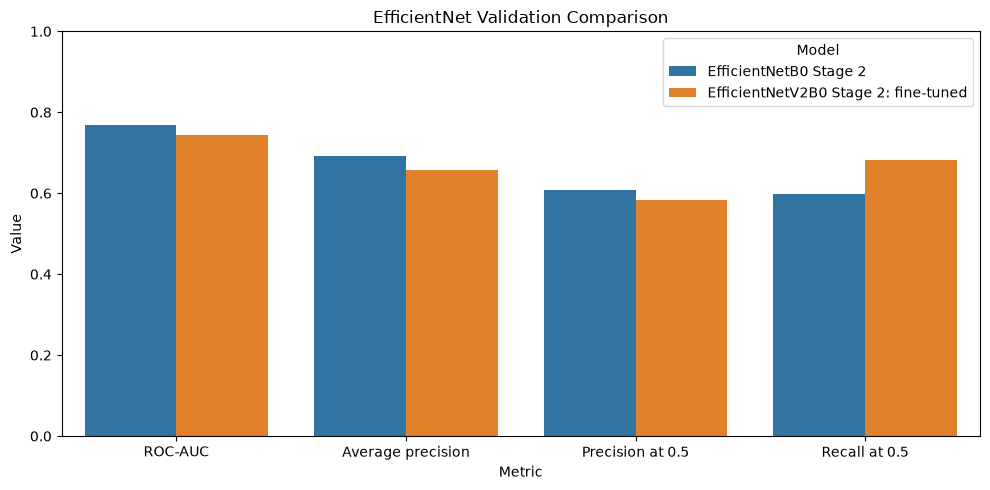

In [465]:
#plot the ranking metrics and the two sides of the precision recall trade off for the restored models
plot_metrics = [
    "ROC-AUC",
    "Average precision",
    "Precision at 0.5",
    "Recall at 0.5"
]

controlled_comparison_long = (
    controlled_validation_comparison
    .melt(
        id_vars="Model",
        value_vars=plot_metrics,
        var_name="Metric",
        value_name="Value"
    )
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=controlled_comparison_long,
    x="Metric",
    y="Value",
    hue="Model"
)

plt.ylim(0, 1)
plt.title("EfficientNet Validation Comparison")
plt.xlabel("Metric")
plt.ylabel("Value")
plt.legend(title="Model")
plt.tight_layout()
plt.show()

__Conclusions__

Validation comparison chart shows that fine-tuned EfficientNetB0 achieved higher ROC-AUC (0.7689 versus 0.7450), average precision (0.6908 versus 0.6567) and precision at 0.5 (60.7% versus 58.4%). EfficientNetV2B0 had higher recall at 0.5 (68.1% versus 59.8%), detecting more malignant records at the cost of more false positives; its F1-score was also higher (0.6290 versus 0.6025). These different operating-point trade-offs support retaining EfficientNetB0 as the primary model on the chosen validation discrimination measure, while reporting V2B0 as an exploratory comparison.

### 12 Probability Calibration and Realiability Analysis.
### 12.1 Purpose

Discrimination measures how well the model ranks malignant lesions above benign lesions; calibration asks whether its predicted probabilities agree with observed malignancy frequencies. Both matter when probabilities may inform decisions. The selected EfficientNetB0 model is threfore examined before and after calibration. Calibration is developed using the validation partition, while the held-out test partition remains reserved for final evaluation.

### 12.2 Calibration Model

The fine-tuned EfficientNetB0 checkpoint selected during model development is used for calibration. Its existing validation predictions provide the uncalibrated probabilities for the analyses below.




In [466]:
#reference the restored, selected EfficientNetB0 checkpoint
calibration_model = best_efficientnet_model

print("Calibration model:", calibration_model.name)

Calibration model: efficientnetb0_transfer_learning


### 12.3 Predicted Probability Assessment

Summary statistics describe the spread of the model's uncalibrated malignancy probabilities. They provide a numerical check before examining reliability, but cannot establish whether the probabilities match the observed risk.

In [471]:
###summarise the validation probability distribution 
probability_summary = pd.Series(
    efficientnet_val_probabilities,
    name = "Predicted malignancy probability"
).describe()

display(probability_summary)


#reject missing, infinite, or out of range probabilities
assert np.isfinite(efficientnet_val_probabilities).all()
assert (
    (efficientnet_val_probabilities >= 0.0)
    & (efficientnet_val_probabilities <= 1.0)
).all()

print("Validation probability checks passed.")

count    504.000000
mean       0.431555
std        0.249179
min        0.000506
25%        0.265379
50%        0.427058
75%        0.595261
max        0.984491
Name: Predicted malignancy probability, dtype: float64

Validation probability checks passed.


__Conclusions__:
All 504 validation records received valid probabilities between 0 and 1. The mean (0.432) and median (0.427) are similar, while the middle half of predictions spans approximately 0.265 to 0.595. This shows that the model produced a range of scores, including predictions on both sides of the 0.5 classification threshold. These statistics describe the scores but do not establish whether they reflect true malignancy risk.

### 12.4 Probability Distribution

The histogram shows how frequently the model assigns probabilities across the zero-to-one range. The line at 0.5 marks the default classification threshold used earlier. Concentration near zero or one would indicate more extreme predictions, but would not by itself demonstrate overconfidence; that requires comparison with observed outcomes.

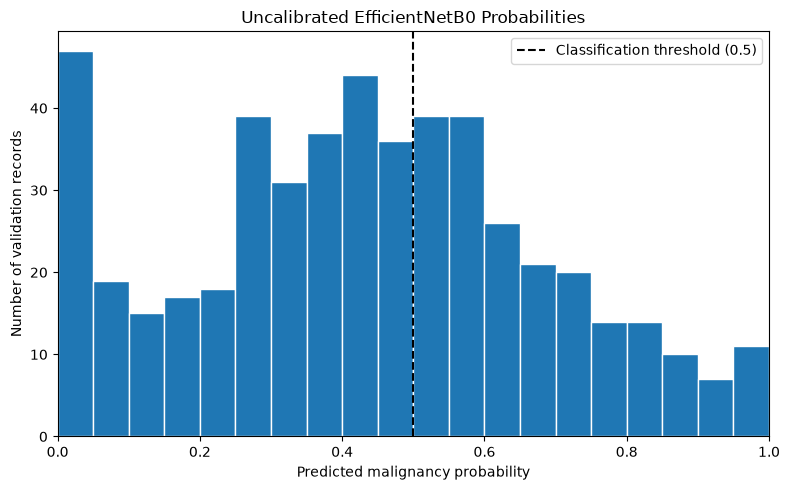

In [472]:
plt.figure(figsize=(8, 5))

#use fixed width bins across the full probability range
plt.hist(
    efficientnet_val_probabilities,
    bins=np.linspace(0.0, 1.0, 21),
    edgecolor="white"
)

#mark the threshold used for the earlier classification metrics
plt.axvline(
    0.5,
    color="black",
    linestyle="--",
    label="Classification threshold (0.5)"
)

plt.xlim(0.0, 1.0)
plt.xlabel("Predicted malignancy probability")
plt.ylabel("Number of validation records")
plt.title("Uncalibrated EfficientNetB0 Probabilities")
plt.legend()
plt.tight_layout()
plt.show()

__Conclusions__: The histogram confirms that predictions are spread across the probability range, with a noticeable group near zero and many records receiving intermediate scores. The dashed line marks the 0.5 threshold: records to it right are classified as malignat, while those close to it may change class if the threshold changes. The histogram shows how confident the model's predictions appear, but determining whether that confidence is justified requires comparing the scores with observed malignancy frequencies.

### 12.5 Confidence Binning
The validation probabilities are divided into ten equal-width intervals between zero and one. These bins allow predicted malignancy probabilities to be compared with the observed proportion of malignant records at similar predicted risk levels.


In [473]:
#define ten equal width probability intervals
NUMBER_OF_CALIBRATION_BINS = 10

probability_bins = np.linspace(
    0.0,
    1.0,
    NUMBER_OF_CALIBRATION_BINS + 1
)

print("Calibration bin boundaries:", probability_bins)

Calibration bin boundaries: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]


The output confirms ten equal-width probability bins, each spanning 0.1 from 0 to 1. For example, the first covers probabilities near 0-0.1 and the last covers 0.9-1.0. These boundaries define the groups used to compare predicted probabilities with observed malignancy frequencies; they do not yet show whether the model is calibrated.

### 12.6 Reliability Statistics

For each bin, the mean predicted probability is compared with the observed malignancy frequency. Their absolute difference measures the calibration error within that bin. Counts are retained because a discrepancy based on only a few records is less stable than one based on many records.

In [476]:
##assign each probability to a bin numbered 0 to 9
#clipping includes probabilities exactly equal to 0 or 1.
bin_indices = np.searchsorted(
    probability_bins,
    efficientnet_val_probabilities,
    side="right"
) - 1

bin_indices = np.clip(
    bin_indices,
    0,
    NUMBER_OF_CALIBRATION_BINS - 1
)

calibration_rows = []

for bin_index in range(NUMBER_OF_CALIBRATION_BINS):
    #select validation records assigned to this interval
    mask = bin_indices == bin_index
    count = int(mask.sum())

    #keep empty intervals visible, without calculating a mean
    if count == 0:
        mean_probability = np.nan
        observed_frequency = np.nan
        calibration_error = np.nan
    else:
        #average prediction and actual malignant fraction among records in this interval
        mean_probability = float(
            efficientnet_val_probabilities[mask].mean()
        )
        observed_frequency = float(
            efficientnet_val_targets[mask].mean()
        )
        calibration_error = abs(
            mean_probability - observed_frequency
        )

    calibration_rows.append({
        "Bin": bin_index + 1,
        "Lower": probability_bins[bin_index],
        "Upper": probability_bins[bin_index + 1],
        "Count": count,
        "Mean probability": mean_probability,
        "Observed frequency": observed_frequency,
        "Absolute error": calibration_error
    })

calibration_statistics = pd.DataFrame(calibration_rows)

#confirm that every validation prediction was assigned once
assert calibration_statistics["Count"].sum() == len(
    efficientnet_val_probabilities
)

display(calibration_statistics.round(4))
print("Calibration statistics validated.")
        

,Bin,Lower,Upper,Count,Mean probability,Observed frequency,Absolute error
0,1,0.0,0.1,66,0.0296,0.0758,0.0461
1,2,0.1,0.2,32,0.1548,0.1562,0.0014
2,3,0.2,0.3,57,0.2613,0.1754,0.0858
3,4,0.3,0.4,68,0.3519,0.3088,0.0430
4,5,0.4,0.5,80,0.4483,0.5125,0.0642
5,6,0.5,0.6,78,0.5492,0.3974,0.1518
6,7,0.6,0.7,47,0.6440,0.6383,0.0057
7,8,0.7,0.8,34,0.7442,0.7353,0.0089
8,9,0.8,0.9,24,0.8494,0.8750,0.0256
9,10,0.9,1.0,18,0.9512,0.8333,0.1178


Calibration statistics validated.


__Conclusions__: Calibration varies across the 504 validation records. Predicted and observed malignancy frequencies are close in the 0.1-0.2, 0.6-0.7 and 0.7-0.8 bins. The largest discrepancy occurs in the 0-5-0.6 bin: the mean prediction is 0.549, but only 0.397 of its 78 records are malignant, indicating overestimated risk. In contrast, the 0.4-0.5 bin underestimates risk (0.448 predicted versus 0.513 observed). Errors occur in both directions, supporting further calibration analysis; the high-probability bins should be interpreted cautiously because they contain fewer records.

### 12.7 Expected Calibration Error
Expected Calibration Error (ECE) combines the absolute errors across bins, weighting each by its share of validation records. Lower values indicate closer agreement between predicted and observed malignancy frequencies at this bin resolution. An ECE of zero would mean agreement between the bin averages, rather than proving perfect calibration for every individual prediction.

In [478]:
#weight each bins absolute error by its share of records
number_of_validation_samples = len(efficientnet_val_targets)

bin_weights = (
    calibration_statistics["Count"]
    / number_of_validation_samples
)

#empty bins have zero weight; replace their undefined errors with zero so they contribute nothing to ECE
ece = float(
    (
        bin_weights 
        * calibration_statistics["Absolute error"].fillna(0.0)
    ).sum()
)

assert np.isfinite(ece)
assert 0.0 <= ece <= 1.0
assert calibration_statistics["Count"].sum() == (
    number_of_validation_samples
)

print(f"Expected Calibration Error (ECE): {ece:.4f}")

Expected Calibration Error (ECE): 0.0619


The uncalibrated model's ECE of 0.0619 means that, across the ten probability bins, the average absolute difference between predicted malignancy probability and observed malignancy frequency is approximately 6.2 percentage points, weighted by the number of records in each bin. This indicates some mismatch between predicted and observed risk. Because ECE depends on the chosen bins and averages within them, it does not show where the largest errors occur; the bin table and MCE provide that detail.

### 12.8 Maximum Calibration Error

Maximum Calibration Error (MCE) reports the largest absolute difference between predicted probability and observed malignancy frequency among the occupied bins. It identifies the worst local discrepancy, although its value can be sensitive to bins containing few records.

In [480]:
#find the largest observed bin level calibration error
mce = float (
    calibration_statistics["Absolute error"].max()
)

assert np.isfinite(mce)
assert 0.0 <= mce <= 1.0

print(f"Maximum Calibration Error (MCE): {mce:.4f}")

Maximum Calibration Error (MCE): 0.1518


The MCE of 0.1518 comes from the 0.5-0.6 bin, where the model predicted an average malignancy probability of 54.9%, but 39.7% of the 78 records were malignant. This local overestimation is larger than the overall ECE of 0.0619 and occurs close to the 0.5 classification threshold, where probability reliability may affect how borderline cases are interpreted. MCE describes the worst discrepancy among these ten bins, rather than the error of every prediction. 

### 12.9 Brier Score
The Brier score is the average squared difference between each predicted malignancy probability and its true outcome. Lower scores indicate better overall probability predictions. It reflects both calibration and the model's ability to seperate outcomes, so it should be read alongside the reliability analysis rather than treated as a calibration measure alone.


In [481]:
from sklearn.metrics import brier_score_loss

#compare each predicted probability with its true binary label
brier = float(
    brier_score_loss(
        efficientnet_val_targets,
        efficientnet_val_probabilities,
        pos_label=1
    )
)

assert np.isfinite(brier)
assert 0.0 <= brier <= 1.0

print(f"Brier Score: {brier:.4f}")
        

Brier Score: 0.1909


The Brier score of 0.1909 is the mean squared difference between the model's predicted malignancy probabilities and the true outcomes; lower is better. Unlike ECE (0.0619) and MCE (0.1518), which measure agreeement within probability bins, it evaluates every validation prediction and also reflects how well the model separates outcomes. The other three values calculated above are of different scales and should not be compared directly. Together, they provide a baseline for assessing whether calibration improves probability reliability without relying on a single summary measure.

### 12.10 Reliability Diagram Before Temperature Scaling

The reliability diagram compares mean predicted malignancy probability with observed malignancy frequency in each occupied bin. Points above the diagonal indicate underestimated risk; points below it indicate overestimated risk.

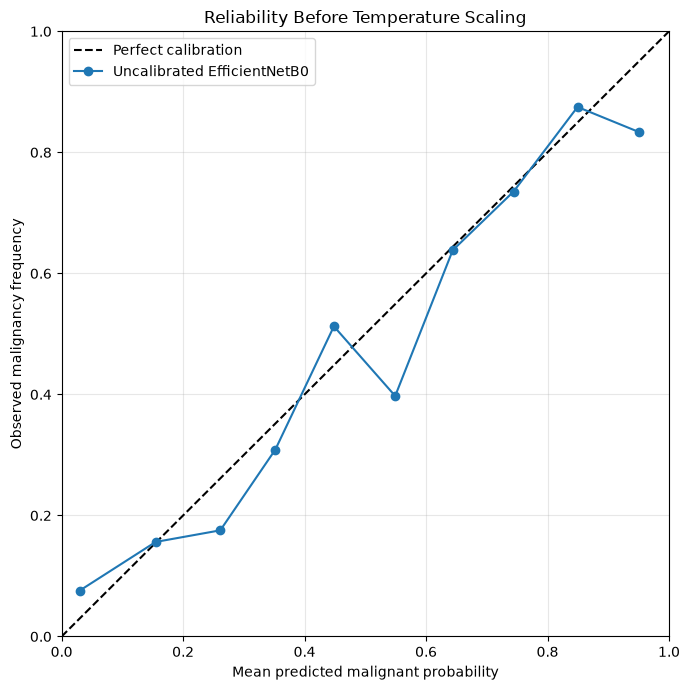

In [484]:
#plot only occupied bins: empty bins have no observed frequncies
uncalibrated_plot_data = calibration_statistics[
    calibration_statistics["Count"] > 0
]

plt.figure(figsize=(7, 7))

#diagonal reference: predicted and observed frequencies agree
plt.plot(
    [0, 1],
    [0, 1],
    "--",
    color="black",
    label="Perfect calibration"
)

#plot the model's bin level predicted and observed frequencies
plt.plot(
    uncalibrated_plot_data["Mean probability"],
    uncalibrated_plot_data["Observed frequency"],
    marker="o",
    label="Uncalibrated EfficientNetB0"
)

plt.xlabel("Mean predicted malignant probability")
plt.ylabel("Observed malignancy frequency")
plt.title("Reliability Before Temperature Scaling")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

__Interpretation__

The uncalibrated reliability curve is close to the ideal diagonal in several ranges, particularly around predicted probabilities of 0.15, 0.64 and 0.74. It also shows erros in both directories: the model underestimates malignancy frequency in the 0.4--0.5 bin, then overestimates it most strongly in the 0.5-0.6 bin (0.549 predicted versus 0.397 observed). The latter produces the MCE of 0.1518 and matters because it lies close to the classification threshold. 

The weighted average discrepancy is smaller (ECE 0.0619), showing why an overall score should by read alonside the curve: it can mask a larger local error. The point near 0.95 also falls below the diagonal, but that bin contains only 18 records. These results support assessing whether temperature scaling improves probability reliability, especially around the decision threshold, while recognising that bin estimates vary in precision with their sample counts. 

### 12.11 Temperature Scaling
Temperature scaling adjusts the selected model's probabilities through one positive parameter $T$, without changing its trained weights. We estimate $T$ by minisiming binary negative log-likelihook on the validation records. Because $T$ is fitted on those same records, before and after validation metrics are development set results; the held-out test set is needed for an independent assessment.

### 12.11.1 Logit Reconstruction
The model outputs uncalibrated sigmoid probabilities. Their logits are reconstructed using the inverse sigmoid before applying temperature scaling.

In [487]:
#avoid taking the log of exactly zero or one
EPSILON = 1e-7

probabilities_clipped = np.clip(
    efficientnet_val_probabilities,
    EPSILON,
    1.0 - EPSILON
)

#inverse sigmoid: logit(p) = log(p/(1-p))
validation_logits = np.log(
    probabilities_clipped
    / (1.0 - probabilities_clipped)
)

assert len(validation_logits) == len(efficientnet_val_targets)
assert np.isfinite(validation_logits).all()

print("Logits shape:", validation_logits.shape)
print(
    "Logit range:",
    (validation_logits.min(), validation_logits.max())
)

Logits shape: (504,)
Logit range: (np.float32(-7.587977), np.float32(4.1506763))


### 12.11.2 Temperature Optimisation
A single temperature is fitted by minimising binary negative log likelihood on the validation partition. The model weights remain fixed. Optimising *log_temperature* ensures that $T= \exp(\text{log\_temperature})$ stays positive: $T > 1$ moves probabilities toward 0.5, while $T < 1$ makes them more extreme.



In [492]:
#T starts at exp(0) =1 , reproducing the original probability
log_temperature = tf.Variable(
    0.0, dtype=tf.float32, trainable=True, name="log_temperature"
)

temperature_optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)

validation_logits_tensor = tf.constant(validation_logits, dtype=tf.float32)
validation_targets_tensor = tf.constant(
    efficientnet_val_targets, dtype=tf.float32
)

TEMPERATURE_STEPS = 500
temperature_history = []

for step in range(TEMPERATURE_STEPS): 
    with tf.GradientTape() as tape:
        #scale the fixed model logits using a positive temperature
        temperature = tf.exp(log_temperature)
        scaled_logits = validation_logits_tensor / temperature

        #measure how well the resulting probabilities match the labels
        nll = tf.reduce_mean(
            tf.nn.sigmoid_cross_entropy_with_logits(
                labels=validation_targets_tensor,
                logits=scaled_logits
            )
        )

        #udpate the temperature only: EfficientNetBO is not retrained
        gradient = tape.gradient(nll, log_temperature)
        temperature_optimizer.apply_gradients(
            [(gradient, log_temperature)]
        )
        temperature_history.append(float(nll.numpy()))
        
    optimal_temperature = float(tf.exp(log_temperature).numpy())

    #calculate nll again after the final parameter update
    final_nll = float(
        tf.reduce_mean(
            tf.nn.sigmoid_cross_entropy_with_logits(
                labels=validation_targets_tensor,
                logits=validation_logits_tensor / optimal_temperature
            )
        ).numpy()
    )

print(f"Optimal temperature: {optimal_temperature:.4f}")
print(f"Final validation NLL: {final_nll:.4f}")

assert np.isfinite(optimal_temperature) and optimal_temperature > 0
assert np.isfinite(final_nll)

Optimal temperature: 1.1556
Final validation NLL: 0.5557


The reconstructed logits contain one finite value for each of the 504 validation records. The fitted temperature of 1.1556 is above 1, so it moves the model's probabilities slightly toward 0.5, reducing their confidence without changing their ranking. The final validation negative log-likelihood is 0.5557; the before and after calibration metrics in Section 12.16 will show whether this adjustment improved probability reliability.

### 12.12 Calibrated Probability Generation

The fitted temperature is applied to the validation logits. The resulting probabilities will be assessed against the originals using identical bins and metrics.

In [493]:
#convert temperature scaled logits back into probabilities
calibrated_probabilities = tf.math.sigmoid(
    validation_logits_tensor / optimal_temperature
).numpy()

assert calibrated_probabilities.shape == (
    efficientnet_val_probabilities.shape
)

assert np.isfinite(calibrated_probabilities).all()
assert(
    (calibrated_probabilities >= 0.0)
    & (calibrated_probabilities <= 1.0)
).all()

print(
    "Calibrated probability range:",
    (
        calibrated_probabilities.min(),
        calibrated_probabilities.max()
    )
)

Calibrated probability range: (np.float32(0.0014050175), np.float32(0.9731902))


The calibrated probabilities range from 0.0014 to 0.9732, so they remain valid values between 0 and 1. With $T= 1.1556$, the most extreme predictions move slightly toward 0.5, while the ordering of lesions by predicted risk stays the same.

### 12.13 Calibrated Assessment After Temperature Scaling

The same ten bin boundaries are used after scaling. Records can move between bins because their probabilities change, but each record remains paired with its original label.

In [510]:
def make_reliability_statistics(probabilities, targets, bin_edges):
    """Calculate bin counts and reliability statistics."""

    number_of_bins = len(bin_edges) - 1

    #include andpoint probabilities of exactly zero or one
    indices = np.searchsorted(
        bin_edges,
        probabilities,
        side="right"
    ) - 1
    indices = np.clip(indices, 0, number_of_bins - 1)

    rows = []

    for index in range(number_of_bins):
        mask = indices == index
        count = int(mask.sum())

        if count:
            mean_probability = float(probabilities[mask].mean())
            observed_frequency = float(targets[mask].mean())
            absolute_error = abs(
                mean_probability - observed_frequency
            )
        else:
            mean_probability = np.nan
            observed_frequency = np.nan
            absolute_error = np.nan

        rows.append({
            "Bin": index + 1,
            "Lower": bin_edges[index],
            "Upper": bin_edges[index + 1],
            "Count": count,
            "Mean probability": mean_probability,
            "Observed frequency": observed_frequency,
            "Absolute error": absolute_error
        })

    return pd.DataFrame(rows)

#reuse the original probability bin boundaries
calibrated_statistics = make_reliability_statistics(
    calibrated_probabilities,
    efficientnet_val_targets,
    probability_bins
)

assert calibrated_statistics["Count"].sum() == len(
    efficientnet_val_targets
)

display(calibrated_statistics.round(4))

,Bin,Lower,Upper,Count,Mean probability,Observed frequency,Absolute error
0,1,0.0,0.1,54,0.0260,0.0370,0.0111
1,2,0.1,0.2,30,0.1457,0.2000,0.0543
2,3,0.2,0.3,48,0.2561,0.1458,0.1103
3,4,0.3,0.4,81,0.3498,0.2593,0.0905
4,5,0.4,0.5,90,0.4497,0.5111,0.0614
5,6,0.5,0.6,86,0.5473,0.4302,0.1171
6,7,0.6,0.7,53,0.6472,0.6792,0.0321
7,8,0.7,0.8,27,0.7472,0.7037,0.0435
8,9,0.8,0.9,19,0.8376,0.7895,0.0481
9,10,0.9,1.0,16,0.9364,0.9375,0.0011


After temperature scaling, predicted and observed malignancy frequencies agree closely in some intervals, particularly the 0.9-1.0 bin (0.936 versus 0.938). The largest remaining mismatch occurs in the 0.5-0.6 bin, where the mean predicted probability is 0.547 but the observed frequency is 0.430. Thus, the probabilities are more reliable in some ranges than others, and scaling has not removed all local overestimation.

### 12.14 Post-Calibration Metrics

Recalculate ECE, MCE and Brier score using the scaled probabilities. A change in any one metric should be reported as observed; improvement in all three is not guaranteed. Brier score measures overall probabilities error and does not isolate calibration. 

In [511]:
#weight occupied-bin errors by their share of validation records.
calibrated_ece = float(
    (
        calibrated_statistics["Count"]
        / len(efficientnet_val_targets)
        * calibrated_statistics["Absolute error"].fillna(0.0)
    ).sum()
)

#largest error among occupied bins
calibrated_mce = float(
    calibrated_statistics["Absolute error"].max()
)

#record-level mean squared probability error
calibrated_brier = float(
    brier_score_loss(
        efficientnet_val_targets,
        calibrated_probabilities,
        pos_label=1
    )
)

#check that the probability summaries are finite and valid 
assert all(
    np.isfinite(value) and 0.0 <= value <= 1.0
    for value in (
        calibrated_ece,
        calibrated_mce,
        calibrated_brier
    )
)

#print outputs
print(f"Calibrated ECE: {calibrated_ece:.4f}")
print(f"Calibrated MCE: {calibrated_mce:.4f}")

Calibrated ECE: 0.0680
Calibrated MCE: 0.1171


After scaling, ECE is 0.0680 and MCE 0.1171. The largest error is smaller than before scaling (0.1518), but the averrage bin-weighted error is slightly higher than before (0.0619). This is why both metrics are useful: they describe aspects of probability reliability.

### 12.15 Reliability Diagram After Temperature Scaling

Plot both sets of occupied bins on the same axes. This makes movement toward or away from the ideal diagonal easier to see than two separate diagrams.

Points closer to the diagonal indicate better agreement for those bins. Because records may move between bins, compare the diagram together with the summary metrics and bin counts.

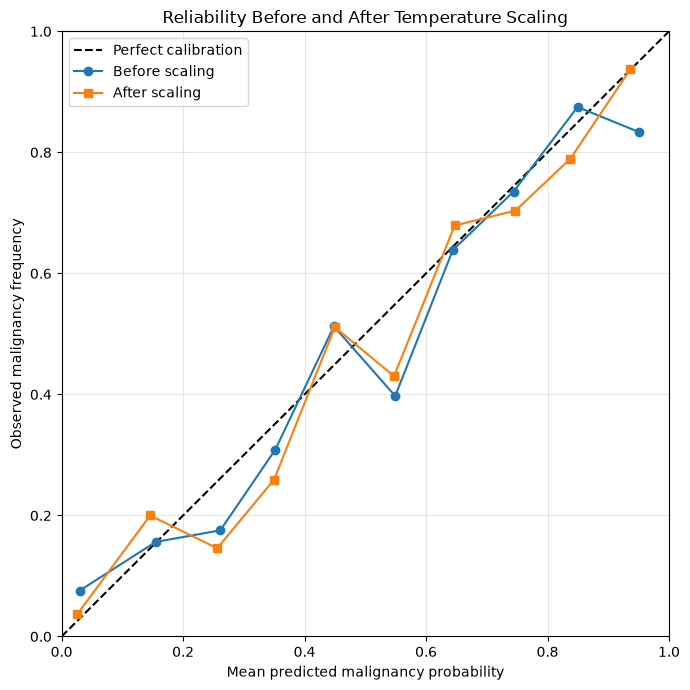

In [503]:
calibrated_plot_data = calibrated_statistics[
    calibrated_statistics["Count"] > 0
]

#define fig size
plt.figure(figsize=(7, 7))

#plot the graph
plt.plot(
    [0, 1],
    [0, 1],
    "--",
    color="black",
    label="Perfect calibration"
)

plt.plot(
    uncalibrated_plot_data["Mean probability"],
    uncalibrated_plot_data["Observed frequency"],
    marker="o",
    label="Before scaling"
)

plt.plot(
    calibrated_plot_data["Mean probability"],
    calibrated_plot_data["Observed frequency"],
    marker="s",
    label="After scaling"
)

plt.xlabel("Mean predicted malignancy probability")
plt.ylabel("Observed malignancy frequency")
plt.title("Reliability Before and After Temperature Scaling")
plt.xlim(0,1)
plt.ylim(0,1)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


__Interpretation__

The orange points show how temperature scaling changes the relationship between predicted risk and observed malignancy frequency. Some points move closer to the diagonal, especially at the highest probabilities, while others move farther away. The plot supports the metric results: scaling reduces the worst bin-level mismatch but does not improve calibration consistently across all bin.

### 12.16 Calibration Performance Comparison

The table places each before and after metric on the same row. Temperature is printed separately because it is the fitted parameter, not a performance score. ROC-AUC is included to check the expected preservation of ranking.

In [505]:
before_roc_auc = roc_auc_score(
    efficientnet_val_targets,
    efficientnet_val_probabilities
)

after_roc_auc = roc_auc_score(
    efficientnet_val_targets,
    calibrated_probabilities
)

calibration_comparison = pd.DataFrame({
    "Metric":[
        "ECE",
        "MCE",
        "Brier score",
        "ROC-AUC"
    ],
    "Before scaling": [
        ece,
        mce,
        brier,
        before_roc_auc
    ],
    "After scaling": [
        calibrated_ece,
        calibrated_mce,
        calibrated_brier,
        after_roc_auc
    ]
})

display(calibration_comparison.round(4))
print(f"Fitted temperature: {optimal_temperature:.4f}")

,Metric,Before scaling,After scaling
0,ECE,0.0619,0.0680
1,MCE,0.1518,0.1171
2,Brier score,0.1909,0.1908
3,ROC-AUC,0.7689,0.7689


Fitted temperature: 1.1556


Temperature scaling produces a mixed outcome on the validation partition. MCE falls from 0.1518	to 0.1171, and the Brier score changes only marginally from 0.1909 to 0.1908, while ECE rises from 0.0619 to 0.0680. ROC-AUC remains 0.7689, as expected because positive temperature scaling preserves prediction order. The fitted temperature softens the probabilities, but these results do not suport a broad claim that calibration improved. Because the same validation partition was used to fit the temperature, its performance on unseen data still requires independent evaluation.

### 13 Uncertainty Estimation Using Monte Carlo Dropout
### 13.1 Motivation and Scope
Calibration assess whether predicted malignancy probabilities agree with observed frequencies across groups of records. It does not show how much an individual prediction changes when the model is sampled repeatedly.

Monte Carlo (MC) Dropout provides an approximate measure of model uncertainty by keeping dropout active during re[eated inference. Each pass produces a probability for the same lesion-view record; variation across passes indicates sensitivity to the sampled network configuration. This is an approximation to Bayesian inference, rather than a complete measure of clinical uncertainty [5]. 

### 13.2 Monte Carlo Dropout Configuration
Fitly passes are used to estimate a distribution of predicted malignancy probabilities for each validation record. The validation partition is used for this analysis; the held out test partition remains untouched.



In [521]:
#number of stochastic predictions generated per validation record
MC_DROPOUT_FORWARD_PASSES = 50

assert MC_DROPOUT_FORWARD_PASSES > 1
print("Monte Carlo forward passes:", MC_DROPOUT_FORWARD_PASSES)

Monte Carlo forward passes: 50


### 13.3 Monte Carlo Prediction Function

Ordinary Keras dropout is inactive during inference. The following custom layer keeps only dropout active while the full model is called with *training=False*. This allows augmentation and batch normalisation to retain their inference behaviour. The trained model is cloned, and its weights are copied into the clone; no retraining occurs.

In [528]:
class MonteCarloDropout(tf.keras.layers.Dropout):
    """Apply dropout during inference as well as training."""

    def call(self, inputs, training=None):
        return super().call(inputs, training=True)

def replace_dropout_for_mc_inference(layer):
    """Replace ordinary Dropout while cloning the trained model."""

    if isinstance(layer, tf.keras.layers.Dropout):
        return MonteCarloDropout.from_config(layer.get_config())

    return layer.__class__.from_config(layer.get_config())

#clone the selected checkpoint, then transfer is trained weights
mc_dropout_model = tf.keras.models.clone_model(
    best_efficientnet_model,
    clone_function=replace_dropout_for_mc_inference
)
mc_dropout_model.set_weights(best_efficientnet_model.get_weights())

#confirm that the intended classification head dropout layers were replaced
original_dropout_layers = [
    layer.name
    for layer in best_efficientnet_model.layers
    if isinstance(layer, tf.keras.layers.Dropout)
]

mc_dropout_layers = [
    layer.name
    for layer in mc_dropout_model.layers
    if isinstance(layer, MonteCarloDropout)
]

assert original_dropout_layers
assert original_dropout_layers == mc_dropout_layers

print("Active MC dropout layers:", mc_dropout_layers)

#repeated inference on identical images should produce different predictions
validation_images, _ = next(iter(val_dataset))

mc_output_1 = mc_dropout_model(
    validation_images, training=False
).numpy()

mc_output_2 = mc_dropout_model(
    validation_images, training=False
).numpy()

assert not np.allclose(mc_output_1, mc_output_2), (
    "Repeated outputs are identical; check whether dropout is active."
)

print("Stochastic inference validated.")

Active MC dropout layers: ['classification_dropout_1', 'classification_dropout_2']
Stochastic inference validated.


The last assertion checks that dropout actually changes predictions. Calling the model with *training=False* also avoids treating random image augmentation as model uncertainty.
    

In [529]:
def monte_carlo_predict(model, dataset, forward_passes):
    """
    Return stochastic probabilities with shape:
    (forward_passes, validation_records).

    Check label order on every pass before combining predictions.
    """

    #materialise validation batches once
    validation_batches = [
        (images, labels)
        for images, labels in dataset
    ]

    #establish the fixed validation target order
    reference_targets = np.concatenate([
        labels.numpy().astype(int).reshape(-1)
        for _, labels in validation_batches
    ])
    
    all_predictions = []
    for pass_number in range(forward_passes):
        pass_predictions = []

        print(
            f"MC pass {pass_number + 1}/{forward_passes}",
            end="\r"
        )

        for images, _ in validation_batches:
            probabilities = model(images, training=False)

            pass_predictions.append(
                probabilities.numpy().reshape(-1)
            )

        pass_predictions = np.concatenate(pass_predictions)

        all_predictions.append(pass_predictions)

    return (
        np.stack(all_predictions).astype(np.float32),
        reference_targets
    )

### 13.4 Stochastic Forward Passes
The resulting matrix contains 50 rows, one per stochastic pass, and one column per validation record. Its shape should be (50, 504). The label checks ensure that each column refers to the same record across all passes and matches the earlier EfficientNet validation analysis.

In [530]:
mc_predictions, mc_val_targets = monte_carlo_predict(
    mc_dropout_model,
    val_dataset,
    forward_passes=MC_DROPOUT_FORWARD_PASSES
)

assert mc_predictions.shape == (
    MC_DROPOUT_FORWARD_PASSES,
    len(val_df)
)

assert len(mc_val_targets) == len(val_df)

assert np.array_equal(
    np.sort(mc_val_targets),
    np.sort(val_df["target"].astype(int).to_numpy())
)

assert np.isfinite(mc_predictions).all()
assert ((mc_predictions >= 0) & (mc_predictions <= 1)).all()

print("Prediction matrix shape:", mc_predictions.shape)
print(
    "Prediction range:",
    (float(mc_predictions.min()), float(mc_predictions.max()))
)

print("MC validation predictions successfully generated.")

Prediction matrix shape: (50, 504)
Prediction range: (4.624826033250429e-06, 0.9976218938827515)
MC validation predictions successfully generated.


The range confirms that stochastic ouputs remain valid probabilities. Different values across passes are expected; their spread for each record is what the next section measures.

### 13.5 Predictive Uncertainty Measures 

The predictive mean averages the 50 malignancy probabilities. Variance measures their spread. Predictive entropy measures uncertainty in the averaged binary prediction and its highest near 0.5. Predictive entropy averages the uncertainty within individual passes. Their difference, mutual information, estimates disagreement attributable to the sampled model configurations. It is an approximate measure of apistemic uncertainty, not a definitive separation of all sources of uncertainty.

In [532]:
UNCERTAINTY_EPSILON = 1e-7

#avoid log(0) when calculating binary entropy
mc_predictions_clipped = np.clip(
    mc_predictions,
    UNCERTAINTY_EPSILON,
    1.0 - UNCERTAINTY_EPSILON
)

#average risk and variation across the 50 passes
predictive_mean = mc_predictions_clipped.mean(axis=0)
predictive_variance = mc_predictions_clipped.var(axis=0)

def binary_entropy(probabilities):
    """Calculate binary entropy using natural logarithms."""
    return -(
        probabilities * np.log(probabilities)
        + (1.0 - probabilities) * np.log(1.0 - probabilities)
    )

#total uncertainty in the average prediction
predictive_entropy = binary_entropy(predictive_mean)

#average uncertainty within the individual stochastic predictions
expected_entropy = binary_entropy(
    mc_predictions_clipped
).mean(axis=0)

#difference isolates disagreement among sampled configurations
mutual_information = np.maximum(
    predictive_entropy - expected_entropy,
    0.0
)

uncertainty_arrays = [
    predictive_mean,
    predictive_variance,
    predictive_entropy,
    expected_entropy,
    mutual_information
]

assert all(
    values.shape == (len(val_df),)
    and np.isfinite(values).all()
    for values in uncertainty_arrays
)

assert (predictive_variance >=0).all()
assert (mutual_information >=0).all()
assert np.all(
    predictive_entropy + 1e-6 >= expected_entropy
)

print("Mean predictive variance:", predictive_variance.mean())
print("Mean predictive entropy:", predictive_entropy.mean())
print("Mean mutual information:", mutual_information.mean())

Mean predictive variance: 0.014972497
Mean predictive entropy: 0.5490374
Mean mutual information: 0.0382231


### 13.6 Uncertainty Summary

Descriptive statistic show the distribution and range of uncertainty across validation records. Results are attached by position only after consuming that MC labels match the previously evaluated validation targets.


In [534]:
#reset the index so each array value is assigned to its matching row
uncertainty_results = val_df.reset_index(drop=True).copy()

uncertainty_results["Predictive Mean"] = predictive_mean
uncertainty_results["Predictive Variance"] = predictive_variance
uncertainty_results["Predictive Entropy"] = predictive_entropy
uncertainty_results["Expected Entropy"] = expected_entropy
uncertainty_results["Mutual Information"] = mutual_information

uncertainty_columns = [
    "Predictive Mean",
    "Predictive Variance",
    "Predictive Entropy",
    "Expected Entropy",
    "Mutual Information"
]

uncertainty_summary = uncertainty_results[
    uncertainty_columns
].describe()

assert len(uncertainty_results) == len(val_df)
assert uncertainty_results[uncertainty_columns].notna().all().all()

display(uncertainty_summary)

,Predictive Mean,Predictive Variance,Predictive Entropy,Expected Entropy,Mutual Information
count,504.000000,504.000000,504.000000,504.000000,504.000000
mean,0.372174,0.014972,0.549037,0.510814,0.038223
std,0.216707,0.012101,0.167026,0.162576,0.028254
min,0.004653,0.000093,0.029629,0.023425,0.004883
25%,0.213723,0.007729,0.482598,0.446265,0.022999
50%,0.352184,0.012930,0.622417,0.577580,0.030592
75%,0.511936,0.018098,0.672378,0.629466,0.042255
max,0.955260,0.095718,0.693142,0.673594,0.229139


### 13.7 Monte Carlo Prediction Function

Ranking by predictive entrophy identifies records with the greatest total uncertainty. Ranking by mutual information identifies records whose predictions vary most across the sampled model configurations. These lists can guide case review, but *patient_id* may appear more than once because the analysis is at the lesion-view record level. 

In [536]:
#rank total uncertainty and model-sampling disagreement separately
highest_total_uncertainty_cases = uncertainty_results.sort_values(
    "Predictive Entropy",
    ascending=False
)

highest_epistemic_uncertainty_cases = uncertainty_results.sort_values(
    "Mutual Information",
    ascending=False
)

case_columns = [
    "Predictive Mean",
    "Predictive Variance",
    "Predictive Entropy",
    "Expected Entropy",
    "Mutual Information"
]

print("Highest total predictive uncertainty:")
display(
    highest_total_uncertainty_cases[
        case_columns
    ].head(15)
)

print("Highest model-sampling disagreement:")
display(
    highest_epistemic_uncertainty_cases[
        case_columns
    ].head(15)
)

assert highest_total_uncertainty_cases[
    "Predictive Entropy"
].is_monotonic_decreasing

assert highest_epistemic_uncertainty_cases[
    "Mutual Information"
].is_monotonic_decreasing


Highest total predictive uncertainty:


,Predictive Mean,Predictive Variance,Predictive Entropy,Expected Entropy,Mutual Information
418,0.501573,0.027055,0.693142,0.636390,0.056752
370,0.501774,0.012738,0.693141,0.667045,0.026095
65,0.501979,0.009624,0.693139,0.673594,0.019546
241,0.497522,0.051799,0.693135,0.577261,0.115874
166,0.496461,0.012226,0.693122,0.668140,0.024982
127,0.504904,0.015703,0.693099,0.660837,0.032262
298,0.493736,0.011706,0.693069,0.668958,0.024110
195,0.509591,0.013809,0.692963,0.664348,0.028615
41,0.509855,0.016055,0.692953,0.659655,0.033298
289,0.489513,0.011110,0.692927,0.670233,0.022694


Highest model-sampling disagreement:


,Predictive Mean,Predictive Variance,Predictive Entropy,Expected Entropy,Mutual Information
198,0.623254,0.095718,0.662449,0.433310,0.229139
193,0.351125,0.087263,0.648140,0.434219,0.213921
462,0.196268,0.065252,0.495185,0.303979,0.191207
358,0.254975,0.065928,0.567735,0.387862,0.179873
415,0.261020,0.065135,0.574121,0.395541,0.178579
177,0.704612,0.069432,0.606906,0.430303,0.176602
149,0.534772,0.076124,0.690727,0.518082,0.172645
16,0.353420,0.070624,0.649538,0.481352,0.168186
103,0.135783,0.040083,0.397235,0.251363,0.145871
411,0.471266,0.061778,0.691495,0.552520,0.138975


__Combined Interpretation__

Across the 504 validation records, mean predictive variance was 0.0150 and mean mutual information was 0.0382. Mutual information reached 0.2291 for the most uncertain record, showing that disagreement between dropout passes was greater for some records than others.
The highest predictive entropies occur when mean malignancy probabilities are close to 0.5, indicating ambiguity between the two cases. Mutual information highlights a different pattern: substantial disagreement across dropout passes can occur when when the mean is farther from 0.5 For example, the highest-disagreement record has a mean probability of 0.623 and mutual information of 0.229, compared with the validation average of 0.038. Together, the rankings distinguish uncertain classification from sensitivity to the sampled model configuration. These records warrant further investigation, although their patient identifies cannot be established from the shuffled dataset order.

### 13.8 Distribution of Predictive Variance

The histogram shows how much the 50 predictions vary for each validation record. Larger variance indicates less indicates less consistent predictions across dropout passes.

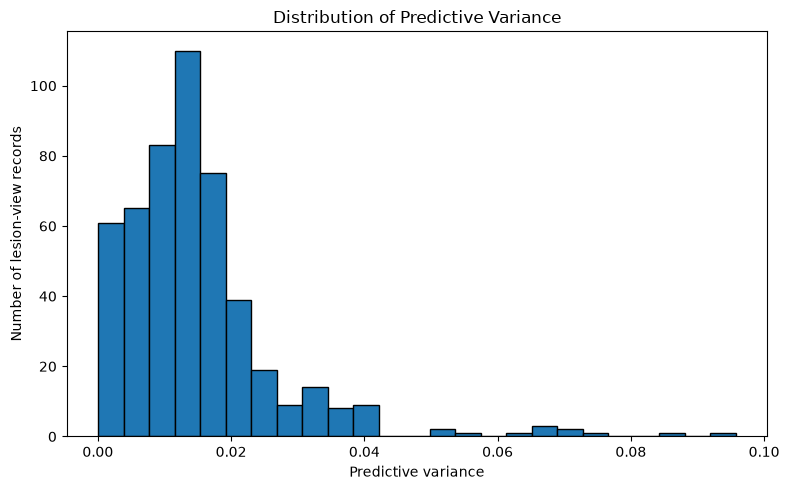

In [538]:
#each valie summarise the spread of 50 predictions for one record
plt.figure(figsize=(8, 5))
plt.hist(predictive_variance, bins=25, edgecolor="black")
plt.xlabel("Predictive variance") 
plt.ylabel("Number of lesion-view records")
plt.title("Distribution of Predictive Variance") 
plt.tight_layout()
plt.show()

__Interpretation__

Most record have predictive variance below 0.02, indicating relatively consistent probabilities across the 50 dropout passes. The long right tail extend to approximately 0.096, showing that a smaller group of records is much more sensitive to the sampled model configuration.

### 13.9 Distribution of Predictive Entropy

Predictive entropy measures ambiguity in the mean prediction. For binary classification, it approaches its maximum of $ln(2)≈ 0.693$ when the mean prbability approaches 0.5.

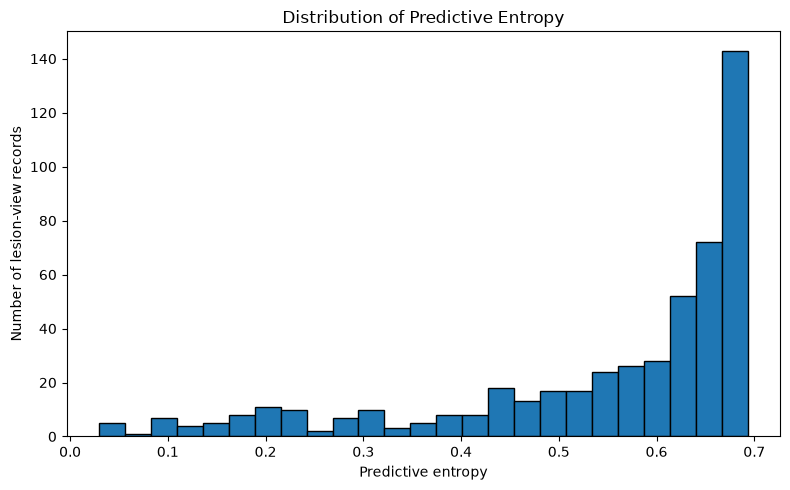

In [539]:
#entropy is highest when the mean prediction is near 0.5
plt.figure(figsize=(8, 5))
plt.hist(predictive_entropy, bins=25, edgecolor="black")
plt.xlabel("Predictive entropy") 
plt.ylabel("Number of lesion-view records")
plt.title("Distribution of Predictive Entropy") 
plt.tight_layout()
plt.show()

__Interpretation__

Predictive entrophy is concentrated near its binary maximum of 0.693. For these records, the mean malignancy probability is close to 0.5, so the model does not strongly favour either class. A smaller number of records have low entrophy and more decisive mean predictions.

### 13.10 Distribution of Model-Sampling Disagreement

Mutual information measures how much the stochastic predictions disagree beyond the uncertainty present within individual passes. Here it serves as an approximate measure of epistemic uncertainty.

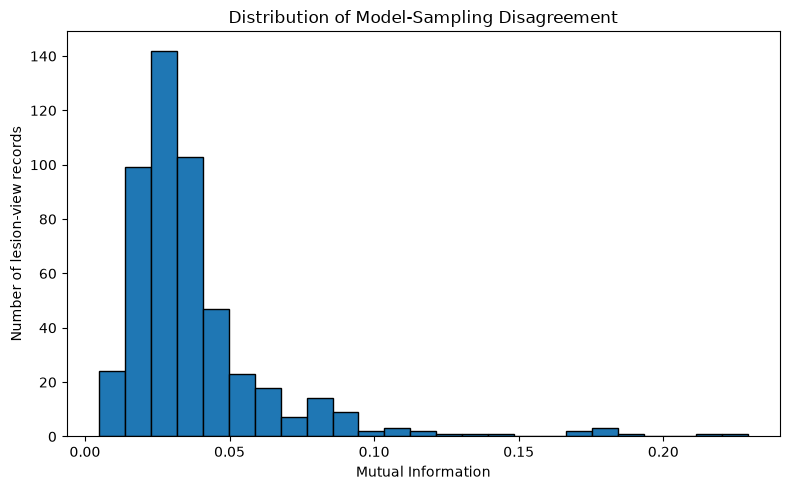

In [540]:
#higher mutual information means greater disagreement across passes
plt.figure(figsize=(8, 5))
plt.hist(mutual_information, bins=25, edgecolor="black")
plt.xlabel("Mutual Information") 
plt.ylabel("Number of lesion-view records")
plt.title("Distribution of Model-Sampling Disagreement") 
plt.tight_layout()
plt.show()

__Interpretation__

Most mutual-information values are relatively low, with a long tail reaching approximately 0.229. The sampled model configurations generally agree, but a smaller subset produces substantially different probabilities across passes. This variation provides an approximate signal of model-related uncertainty. 

### 13.11 Total Predictive Uncertainty and Model-Sampling Disagreement

Plotting entrophy against mutual information shows whether ambiguous mean predictions are also sensitive to the sampled model configuration. A high-entrophy record can have a low mutual information if the mutual information if the individual passes consistently predict probabilities near 0.5.

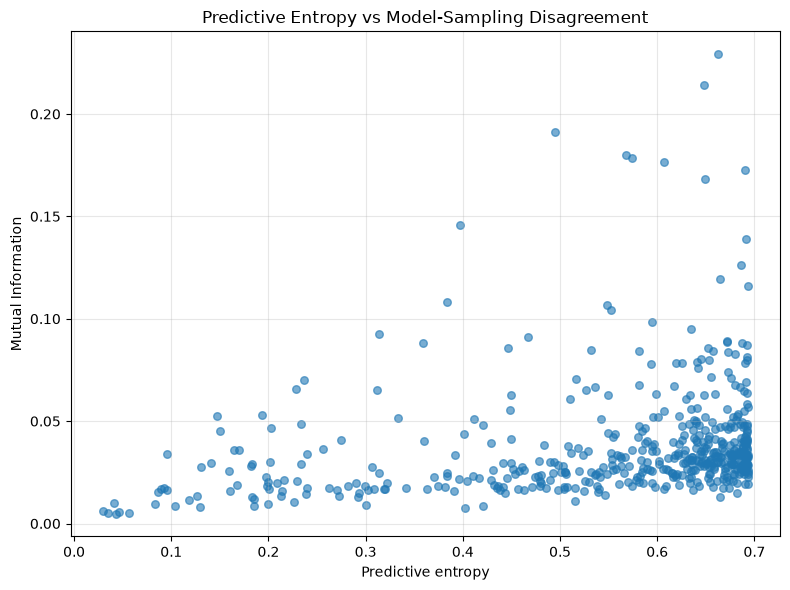

In [541]:
#each point is one validation record, using two uncertainty measures
plt.figure(figsize=(8, 6))
plt.scatter(
    predictive_entropy,
    mutual_information,
    alpha=0.6,
    s=30
)
plt.xlabel("Predictive entropy") 
plt.ylabel("Mutual Information")
plt.title("Predictive Entropy vs Model-Sampling Disagreement") 
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

__Interpretation__

Many records have high predictive entrophy but low mutual information: their mean prediction is ambiguous even though the dropout passes largely agree. Other record show much higher mutual information, including some with lower entrophy. Thus, uncertainty near the decision boundary and disagreement between sampled model configurations are related but distint; using both measures reveals cases that either measure alone could miss.

### 13.12 Identification of Low-Uncertainty Records 
Low predictive entropy identifies predictions whose mean malignancy probability is farther from 0.5. Low mutual information indicates that the dropout passes generally agree. Cases low on both measures provide examples of relatively consistent predictions within this validation analysis.

In [544]:
#select records in the lowest quartile of model sampling disagreement
low_mi_cutoff = uncertainty_results["Mutual Information"].quantile(0.25)

most_certain_cases = (
    uncertainty_results.loc[
        uncertainty_results["Mutual Information"] <= low_mi_cutoff,
        [
            "Predictive Mean",
            "Predictive Variance",
            "Predictive Entropy",
            "Mutual Information"
        ],
    ]
    #within that group, show the least ambiguous mean predictions first
    .sort_values("Predictive Entropy")
    .head(25)
)

display(most_certain_cases)

,Predictive Mean,Predictive Variance,Predictive Entropy,Mutual Information
259,0.004653,0.000183,0.029629,0.006204
201,0.005608,0.000093,0.034662,0.005033
377,0.006930,0.000513,0.041361,0.010170
295,0.007362,0.000116,0.043493,0.004883
0,0.008018,0.000127,0.046682,0.005421
445,0.010125,0.000129,0.056574,0.004980
158,0.016197,0.000403,0.082845,0.009560
496,0.017033,0.000940,0.086254,0.015437
270,0.017863,0.001030,0.089600,0.016746
46,0.018569,0.000996,0.092416,0.017306


These 25 predictions have low predictive entropy and low disagreement across dropout passes. Their mean malignancy probabilities are mostly near zero, with a few near one, so the model gives a consistent answer for these records. For example, the prediction with a mean of 0.0047 has entropy 0.0296 and mutual information 0.0062. This complements the high-uncertainty results by showing that uncertainty varies across the validation set. For this mammography study, such measures could help distinguish predictions that are stable across model samples from those that merit closer investigation. Low estimated uncertainty does not establish that a prediction is correct, and these shuffled row numbers cannot be used to identify patients.

### 13.13 Visualisation of Highly Certain and Highly Uncertain Mammograms

A small sample of validation mammograms is examined quantitatively. Monte Carlo predictions are generated directly from each selected image, preserving the correspondence between its DICOM path and uncertainty measures. The examples illustrates how model uncertainty can vary; they are not claimed to be the most uncertain cases in the full validation partition.

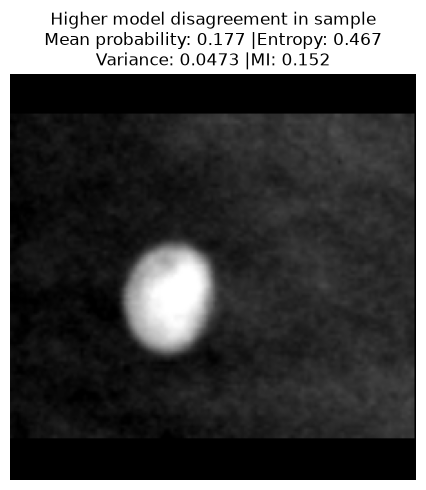

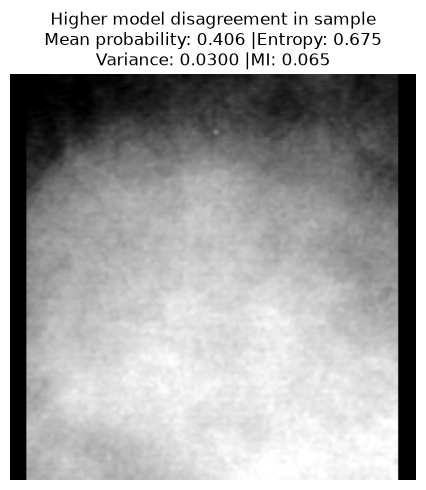

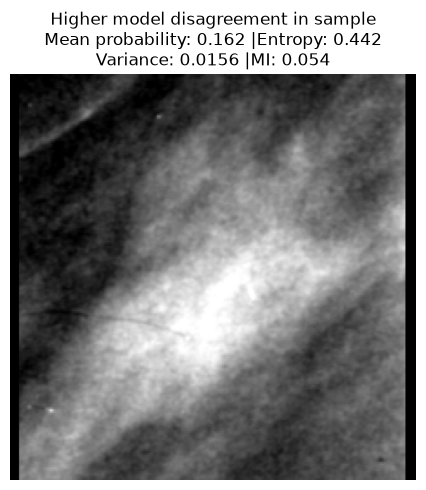

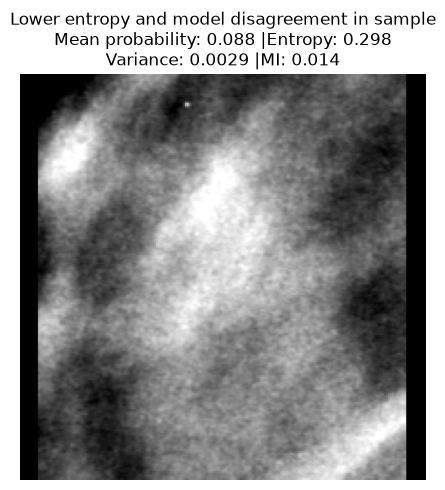

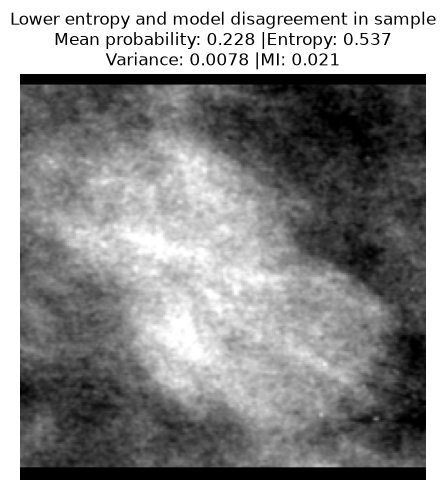

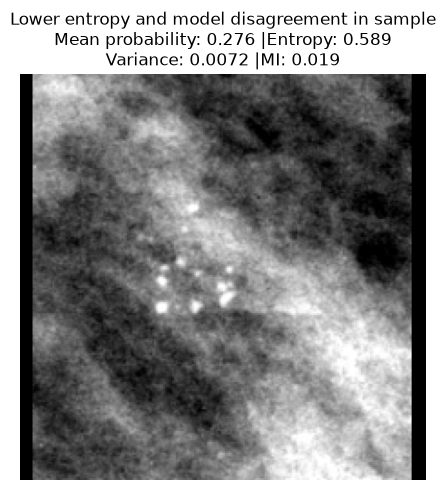

In [550]:
#Select a reproducible, manageable sample of validation records
EXAMPLE_SAMPLE_SIZE = 20
EXAMPLE_FORWARD_PASSES = MC_DROPOUT_FORWARD_PASSES
EXAMPLES_PER_GROUP = 3

example_records = (
    val_df.dropna(subset=["resolved_dicom_path"])
    .sample(n=EXAMPLE_SAMPLE_SIZE, random_state=42)
    .copy()
)

def image_uncertainty(image_path, forward_passes=50):
    """Calculate MC dropout uncertainty for one identified image."""

    #applt the same preprocessing used to construct the model dataset
    image = np.array(
        load_and_preprocess_dicom(image_path),
        dtype=np.float32,
    )
    image_batch = tf.convert_to_tensor(image[None, ...])

    #the full model stays in inference mode; the custom MC dropout layers remain active and produce a new mask on each pass
    probabilities = np.asarray([
        float(
            mc_dropout_model(
                image_batch,
                training=False,
            ).numpy()[0,0]
        )
        for _ in range(forward_passes)
    ])

    probabilities = np.clip(probabilities, 1e-7, 1 - 1e-7)
    mean_probability = float(probabilities.mean())

    #binary entropy of the mean and average entropy of the passes.
    def binary_entropy(p):
        return -(p * np.log(p) + (1 - p) * np.log(1 - p))

    predictive_entropy = float(binary_entropy(mean_probability))
    expected_entropy = float(binary_entropy(probabilities).mean())

    return {
        "Predictive Mean": mean_probability,
        "Predictive Variance": float(probabilities.var()),
        "Predictive Entropy": predictive_entropy,
        "Mutual Information": max(
            predictive_entropy - expected_entropy,
            0.0,
        ),
    }

#calculate uncertainty while retaining the source row and image path
example_scores = example_records["resolved_dicom_path"].apply(
    lambda path: pd.Series(
        image_uncertainty(path, EXAMPLE_FORWARD_PASSES)
    )
)

example_results = example_records.join(example_scores)

#choose the greates model disagreement within the 20 image sample
high_disagreement_examples = example_results.nlargest(
    EXAMPLES_PER_GROUP,
    "Mutual Information"
)

#for the low uncertainty group, require low model disagreement first, then 
#select the lowest predictive entropy within that group
low_mi_cutoff = example_results["Mutual Information"].quantile(0.25)

low_uncertainty_examples = (
    example_results.loc[
        example_results["Mutual Information"] <= low_mi_cutoff
    ]
    .nsmallest(EXAMPLES_PER_GROUP, "Predictive Entropy")
)

def show_example(row, heading):
    """Display an image beside uncertainty computed from that image."""
    image = np.asarray(
        load_and_preprocess_dicom(row["resolved_dicom_path"]),
        dtype=np.float32,
    )


    plt.figure(figsize=(5, 5))
    plt.imshow(image[..., 0], cmap="gray", vmin=0, vmax=1)
    plt.axis("off")
    plt.title(
        f"{heading}\n"
        f"Mean probability: {row['Predictive Mean']:.3f} |"
        f"Entropy: {row['Predictive Entropy']:.3f}\n"
        f"Variance: {row['Predictive Variance']:.4f} |"
        f"MI: {row['Mutual Information']:.3f}"
    )
    plt.tight_layout()
    plt.show()

for _, row in high_disagreement_examples.iterrows():
    show_example(row, "Higher model disagreement in sample")
                              
for _, row in low_uncertainty_examples.iterrows():
    show_example(row, "Lower entropy and model disagreement in sample")
                                                    

__Interpretations of Illustrative Mammograms___

The images show that mean probability and model disagreement describe different aspects of uncertainty. Among the 20 sampled mammograms, the highest-disagreement example had a mean malignancy probability 0.177, but its mutual information was 0.152 and predictive variance was 0.0473. Although its average prediction is below 0.5, the invididual dropout passes varied considerably. Another example had a mean of 0.406 and entropy of 0.675, showing greater ambiguity in this average prediction.

The lower-disagreement examples had smaller mutual information (0.014-0.021) and variance (0.0029-0.0078). Their mean probabilities ranged from 0.088 to 0.276; the first is farther from the 0.5 decision threshold, while the latter two still retain some predictive ambiguity. Together, these images illustrate why both entropy and mutual information are useful in this study: one describes uncertainty in the average malignancy prediction, and the other describes sensitivity to dropout sampling. These are illustrative cases from 20 validation images, their appearance alone does not establish the cause of uncertainty or whether a prediction is correct. 

### 14. Explainability Using Gradient-Weighted Class Activation Mapping
### 14.1 Motivation and Scope

Grad-CAM is applied to the selected EfficientNetB0 checkpoint to visualise spatial features associated with individual predictions. Examples from correct and incorrect classifications are examined for attention to lesion regions or possible image artefacts. These coarse heatmaps support qualitative model inspection; they are neither lesion segmentations nor evidence of clinical reasoning.

### 14.2 Classification Outcome Identification

In [553]:
GRAD_CAM_CLASSIFICATION_THRESHOLD = EFFICIENTNET_VALIDATION_THRESHOLD
GRAD_CAM_BATCH_SIZE = 16

#start from the validation metadata. Each prediction below is calculated directly from the DICOM path stored in the same row.
gradcam_results = val_df.reset_index(drop=True).copy()

assert gradcam_results["resolved_dicom_path"].notna().all()

ordered_probabilities = []

for start in range(0, len(gradcam_results), GRAD_CAM_BATCH_SIZE):
    batch_paths = gradcam_results["resolved_dicom_path"].iloc[
        start:start + GRAD_CAM_BATCH_SIZE
    ]

    #use the same image preprocessing as the training pipeline
    images = np.stack(
        [
            load_and_preprocess_dicom(path)
            for path in batch_paths
        ]
    ).astype(np.float32)

    #inference mode disables training only augmentation and dropout
    batch_probabilities = best_efficientnet_model(
        images,
        training=False
    ).numpy().reshape(-1)

    ordered_probabilities.extend(batch_probabilities)

gradcam_results["Predicted Probability"] = np.asarray(
    ordered_probabilities
)

gradcam_results["Predicted Class"] = (
    gradcam_results["Predicted Probability"]
    >= GRAD_CAM_CLASSIFICATION_THRESHOLD
).astype(int)

#assign outcomes using each row's own target and prediction
true_class = gradcam_results["target"].astype(int)
predicted_class = gradcam_results["Predicted Class"]


gradcam_results["Prediction Outcome"] = np.select(
    [
        (true_class == 1) & (predicted_class == 1),
        (true_class == 0) & (predicted_class == 0),
        (true_class == 0) & (predicted_class == 1),
        (true_class == 1) & (predicted_class == 0),
    ],
    [
        "True Positive",
        "True Negative",
        "False Positive",
        "False Negative",
    ],
    default="Invalid",
)

assert len(gradcam_results) == len(val_df)
assert gradcam_results["Predicted Probability"].between(0, 1).all()
assert not (gradcam_results["Prediction Outcome"] == "Invalid").any()

outcome_order = [
    "True Positive",
    "True Negative",
    "False Positive",
    "False Negative",
]

display(
    gradcam_results["Prediction Outcome"]
    .value_counts()
    .reindex(outcome_order, fill_value=0)
    .rename_axis("Prediction Outcome")
    .to_frame("Number of Mammograms")
)

print("Path-aligned Grad-CAM outcomes validated.")

,Number of Mammograms
Prediction Outcome,
True Positive,122
True Negative,221
False Positive,79
False Negative,82


Path-aligned Grad-CAM outcomes validated.


At the 0.5 threshold, EfficientNetB0 correctly identified 122 malignant and 221 benign mammograms, giving 343 correct classifications out of 504 (68.1%). It also classified 79 benign mammograms as malignant (false positives) and 82 malignant mammograms as benign (false negatives). The latter are especially important to inspect because they represent missed malignancies at this threshold.

Grouping the path-aligned images by outcome lets the Grad-CAM analysis examine both correct predictions and errors. The heatmaps can then be compared qualitatively to see whether the model emphasised the lesion or other parts of the image in each type of case.

### 14.3 Identification of the Spatial Feature Representation

Grad-CAM requires feature maps that retain that spatial arrangement of the image. The final output of the pretrained EfficientNetB0 backbone was selected because it precedes the classification head's global average pooling layer.

The backbone produces 7 x 7 spatial feature maps with 1,280 channels. Grad-CAM uses these maps to estimate which broad image regions support prediction. Because the maps are only 7 x 7, the resulting heatmap is a coarse localisation, not a precise lesion boundary.

In [555]:
#select the pretrained spatial backbone used by this trained model
gradcam_feature_layer = best_efficientnet_model.get_layer(
    "efficientnetb0"
)

GRAD_CAM_FEATURE_LAYER_NAME = gradcam_feature_layer.name

assert isinstance(gradcam_feature_layer, tf.keras.Model)
assert len(gradcam_feature_layer.output.shape) == 4

print("Grad-CAM feature source:", GRAD_CAM_FEATURE_LAYER_NAME)
print("Spatial output shape:", gradcam_feature_layer.output.shape)

Grad-CAM feature source: efficientnetb0
Spatial output shape: (None, 7, 7, 1280)


### 14.4 Construction and Validation of the Grad-CAM Model

An auxiliary model was constructed from the trained layers to return both the backbone feature maps and the final malignancy probability. The weights were not changed.

For the validation image, is feature-map shape was (1, 7, 7, 1280), where 1 is the batch size. The auxiliary model's prediction matched the original model exactly, with a maximum difference of 0.0. This confirms that the exposed feature maps belongs to a forward pass that reproduces the selected classifier's prediction.

In [558]:
##reuse the trained layers and expose the backbones spatial output alonside the classifier's final malignancy probability.
gradcam_input = tf.keras.Input(
    shape=best_efficientnet_model.input_shape[1:],
    name="gradcam_input",
)

x = gradcam_input
gradcam_feature_maps = None

for layer in best_efficientnet_model.layers:
    if isinstance(layer, tf.keras.layers.InputLayer):
        continue

    #keep training-dependent layers in inference mode, matching the prediction setting used for the validation analysis
    x = layer(x, training=False)

    if layer.name == GRAD_CAM_FEATURE_LAYER_NAME:
        gradcam_feature_maps = x

assert gradcam_feature_maps is not None

gradcam_model = tf.keras.Model(
    inputs=gradcam_input,
    outputs=[gradcam_feature_maps, x],
    name="efficientnetb0_gradcam_model",
)

#check that reconstruction preserves the original model's output
sample_image = np.asarray(
    load_and_preprocess_dicom(
        gradcam_results.iloc[0]["resolved_dicom_path"]
    ),
    dtype=np.float32,
)[None, ...]

original_probability = best_efficientnet_model(
    sample_image,
    training=False,
)

feature_maps, reconstructed_probability = gradcam_model(
    sample_image,
    training=False,
)

maximum_difference = float(
    tf.reduce_max(
        tf.abs(original_probability - reconstructed_probability)
    ).numpy()
)

assert len(feature_maps.shape) == 4
assert maximum_difference < 1e-5

print("Feature-map shape:", feature_maps.shape)
print("Maximum prediction difference:", maximum_difference)


Feature-map shape: (1, 7, 7, 1280)
Maximum prediction difference: 0.0


### 14.5 Grad-CAM Heatmap Generation

For each selected mammograms, the gradient of the explained class score is calculated with respect to the EfficientNetB0 spatial feature maps. The gradients provide a weight for each feature channel. These weights are combined with the feature maps, and positive contributions are retained to form a normalised heatmap.

The function can explain either the malignant class or the benign class. By default, it explains the class predicted by the model. Higher heatmaps values indicate spatial features that more strongly support that class; they do not measure the probability that a lesion is present at a particular pixel.

In [566]:
#define a function to generate a Grad-CAM heatmap for one preprocessed mammogram
def generate_gradcam_heatmap(
    image,
    model=gradcam_model,
    target_class=None
):
    """
    Generate a Grad-CAM heatmap for one preprocessed image.

    Parameters
    ----------
    image : numpy.ndarray or tf.Tensor
        Preprocessed image with shape (height, width, channels)
        or (1, height, width, channels).

    model : tf.keras.Model
        Model returning spatial feature maps and the final
        malignancy probability.

    target_class : int or None
        Class to explain:
        1 for malignant and 0 for benign.
        When None, the model-predicted class is explained.

    Returns
    -------
    heatmap : numpy.ndarray
        Normalised two-dimensional Grad-CAM heatmap.

    predicted_probability : float
        Model-predicted probability of malignancy.

    explained_class : int
        Class for which the explanation was generated.
    """

    #convert the supplied preprocessed image into TensorFlow tensor
    #using the floating point representation expected by the model
    image_tensor = tf.convert_to_tensor(
        image,
        dtype=tf.float32
    )

    #check whether the supplied image contains only height, width and channels
    if len(
        image_tensor.shape
    ) == 3:

        #add the batch dimension required by the neural network
        image_tensor = tf.expand_dims(
            image_tensor,
            axis=0
        )

    #confirm that the final input contains batch, height, width and channel dimensions
    if len(
        image_tensor.shape
    ) != 4:

        #stop execution when the supplied image has an invalid dimensionality
        raise ValueError(
            "The image must have three or four dimensions."
        )

    #record operations during the forward pass so gradients can be calculated with respect to the selected convolutional feature maps
    with tf.GradientTape() as gradient_tape:

        #perform inference and obtain both spatial and feature maps and the model's final malignancy prediction
        feature_maps, predictions = model(
            image_tensor,
            training=False
        )

        #extract the predicted malignancy probability from the sigmoid output
        malignant_probability = (
            predictions[:, 0]
        )

        #use the model-predicted class when no target class is supplied
        if target_class is None:

            #classify probabilities of at least 0.5 as malignant and probabilities below 0.5 as benign
            explained_class = int(
                malignant_probability[0]
                >= 0.5
            )

        #otherwise use the explicitly requested class for the explanation
        else:
            explained_class = int(
                target_class
            )

        #confirm that the requested explanation corresponds to a valid binary class
        if explained_class not in {
            0,
            1
        }:
            #prevent Grad-CAM generation for unsupported class values
            raise ValueError(
                "target_class must be either 0 or 1."
            )

        #for a malignant explanation, use the predicted malignancy probability as the score whose influential 
        #image regions are investigated
        if explained_class == 1:
            target_score = (
                malignant_probability
            )

        #for a benign explaantion, use the complementary benign probability
        else:
            target_score = (
                1.0
                - malignant_probability
            )

    #calculate the gradient of the selected class score with respect to each spatial feature map 
    #produced by the target convolutional layer
    gradients = gradient_tape.gradient(
        target_score,
        feature_maps
    )

    #check that TensorFlow successfully calculated the required gradients
    if gradients is None:

        #stop execution because Grad-CAM cannot be generated without gradients
        raise RuntimeError(
            "Gradients could not be calculated."
        )

    #averga the gradients across the spatial dimensions to obtain one importance weight or each feature map channel
    channel_weights = tf.reduce_mean(
        gradients,
        axis=(
            1,
            2
        )
    )

    #weight each feature map channel according to its contribution to the class score being explained
    weighted_feature_maps = (
        feature_maps
        * channel_weights[
            :,
            tf.newaxis,
            tf.newaxis,
            :
        ]
    )

    #combine the weighted channels into one two-dimensional activation map
    heatmap = tf.reduce_sum(
        weighted_feature_maps,
        axis=-1
    )

    #retain only positive contributions to the selected class as specified by the Grad-CAM procedure
    heatmap = tf.nn.relu(
        heatmap
    )

    #identify the minimum value for heatmap normalisation
    heatmap_minimum = tf.reduce_min(
        heatmap
    )

    #identify the maximum value for heatmap normalisation
    heatmap_maximum = tf.reduce_max(
        heatmap
    )

    #scale the heatmap values to approximately the range zero to one and add epsilon to prevent division by zero for a constant heatmap
    heatmap = (
        heatmap
        - heatmap_minimum
    ) / (
        heatmap_maximum
        - heatmap_minimum
        + tf.keras.backend.epsilon()
    )

    #remove the single-image batch dimension and convert the heatmap from a TensorFlow tensor into a NumPy array for later visualisation
    heatmap = heatmap[0].numpy()

    #extract the scalar malignancy probability and convert it into a standard python floating-point value
    predicted_probability = float(
        malignant_probability[0].numpy()
    )

    return (
        heatmap,
        predicted_probability,
        explained_class
    )

### 14.6 Validation of Heatmap Generation
Before examining cases, a validation image is used to check that Grad-CAM returns a finite, two-dimensional heatmap with values between 0 and 1. The predicted probability must also lie between 0 and 1. These checks confirm that the function produces a usable heatmap, although they do not establish that is highlighted regions are critically meaningful

In [565]:
#select the first Grad-CAM result as a representative sample for validation
gradcam_sample_row = (
    gradcam_results.iloc[0]
)

#load and preprocess the mammogram associated with the selected sample using the same preprocessing 
# pipeline applied during model development
gradcam_sample_image = (
    load_and_preprocess_dicom(
        gradcam_sample_row[
            "resolved_dicom_path"
        ]
    )
)

#generate the grad-cam explanation for the selected mammogram and return the heatmap, malignancy probability and explained class
(
    gradcam_sample_heatmap,
    gradcam_sample_probability,
    gradcam_sample_class,
) = generate_gradcam_heatmap(

    #provide the preprocessed mammogram to the Grad-CAM function
    image=gradcam_sample_image,
    
    #explain the class predicted by the classification model
    target_class=int(
        gradcam_sample_row[
            "Predicted Class"
        ]
    )
)

#display the dimensions of the preprocessed input image to confirm that it has the expected model input shape
print(
    "Image shape:",
    gradcam_sample_image.shape
)

#display the dimensions of the generated Grad-Cam heatmap to confirm that a two dimensional spatial explanation was produced
print(
    "Heatmap shape:",
    gradcam_sample_heatmap.shape
)

#display the model-predicted probability of malignancy for the selected validation mammogram
print(
    "Predicted probability:",
    gradcam_sample_probability
)

#display the binary class represented by the generated Grad-CAM explanation where zero represents benign and one represents malignant
print(
    "Explained class:",
    gradcam_sample_class
)

Image shape: (224, 224, 3)
Heatmap shape: (7, 7)
Predicted probability: 0.5376831889152527
Explained class: 1


The validation image had the expected 224 x 224 x 3 input shape and produced a 7 x 7 Grad-CAM heatmap, consistent with the backbone's spatial output. Its malignancy probability was 0.538, so the heatmap explains the predicted malignant class (1) at the 0.5 threshold. The numerical checks passed; whether the highlighted regions are relevant is assessed in the visual examples that follow.

### 14.7 Grad-CAM Visualisation

Each selected case is displayed as a preprocessed mammogram, its Grad-CAM heatmap and an overlay. The overlay shows where the model's spatial features positively supported the explained class. Since the underlying feature maps are only 7 x 7, the resized heatmap shows broad regions rather than precise lesion boundaries.

In [569]:
#define a function to display the original mammogram, Grad-CAM heatmap and combined overlay
def display_gradcam_explanation(
    row,
    target_class=None,
    overlay_strength=0.40
):
    """
    Display a mammogram, Grad-CAM heatmap and overlay.

    Parameters
    ----------
    row : pandas.Series
        Metadata and prediction information for one case.

    target_class : int or None
        Class for which the explanation is generated.
        When None, the predicted class is explained.

    overlay_strength : float
        Heatmap transparency in the superimposed image.
    """

    #confirm that the requested heatmap transparency lies within the valid range
    if not (
        0.0
        <= overlay_strength
        <= 1.0
    ):
        #stop execution when an invalid overlay strength is supplied
        raise ValueError(
            "overlay_strength must lie between 0 and 1."
        )

    #load and preprocess the DICOM mammogram associated with the selected metadata row
    image = load_and_preprocess_dicom(
        row[
            "resolved_dicom_path"
        ]
    )

    #use the model-predicted class when no explicit Grad-CAM target class is supplied
    if target_class is None:
        target_class = int(
            row[
                "Predicted Class"
            ]
        )

    #generate the Grad-CAM heatmap and retrieve the corresponding malignancy probability and class represented by the explanation
    (
        heatmap,
        predicted_probability,
        explained_class
    ) = generate_gradcam_heatmap(
        image=image,
        target_class=target_class
    )

    #check that the displayed DICOM image produces the probability stored for this same metadata row
    assert np.isclose(
        predicted_probability,
        float(row["Predicted Probability"]),
        atol=1e-5,
    ), "Displayed image and stored prediction do not match."

    #resize the lower-resolution Grad-CAM heatmap to match the spatial dimensions of the preprocessed mammogram
    resized_heatmap = tf.image.resize(
        heatmap[
            ...,
            np.newaxis
        ],
        size=image.shape[:2],
        method="bilinear"
    ).numpy()[
        ...,
        0
    ]

    #convert the preprocessed mammogram into a floating-point numpy array for consistent visualisation and overlay construction
    display_image = np.asarray(
        image,
        dtype=np.float32
    )

    #convert a single-channel mammogram into three identical channels so it can be combined with the RGB GradCam colour map
    if display_image.shape[-1] == 1:
        display_image = np.repeat(
            display_image,
            repeats=3,
            axis=-1
        )

    #restrict mammogram intensity values to the valid display range of zero to one
    display_image = np.clip(
        display_image,
        0.0,
        1.0
    )

    #map the normalised Grad-CAM activation values to the jet colour map and retain only the RGB channels
    heatmap_colours = plt.get_cmap(
        "jet"
    )(
        resized_heatmap
    )[
        ...,
        :3
    ]

    #bled the original mammogram and coloured Grad-CAM heatmap according to the requested overlay transparency
    overlay = (
        (
            1.0
            - overlay_strength
        )
        * display_image
        +
        overlay_strength
        * heatmap_colours
    )

    #restrict the blended image values to the valid display range
    overlay = np.clip(
        overlay,
        0.0,
        1.0
    )

    #convert the numerical ground truth target into a readable class label
    true_class_name = (
        "Malignant"
        if int(
            row["target"]
        ) == 1
        else "Benign"
    )

    #convert the models numerical predicted class into a readable class label
    predicted_class_name = (
        "Malignant"
        if int(
            row[
                "Predicted Class"
            ]
        ) == 1
        else "Benign"
    )

    #convert the class represented by the Grad-CAM explanation into a readable class label
    explained_class_name = (
        "Malignant"
        if explained_class == 1
        else "Benign"
    )

    #create a three panel figure for the mammogram, heatmap nad overlay
    figure, axes = plt.subplots(
        1,
        3,
        figsize=(
            15,
            5
        )
    )

    #display the preprocessed mammogram in the first panel
    axes[0].imshow(
        display_image,
        cmap="gray"
    )

    #label the first panel
    axes[0].set_title(
        "Preprocessed Mammogram"
    )

    #remove the axis markings to focus attentino on the mammogram
    axes[0].axis(
        "off"
    )

    #display the resized Grad-CAM activation map in the second panel
    axes[1].imshow(
        resized_heatmap,
        cmap="jet",
        vmin=0.0,
        vmax=1.0
    )

    #identify the class represented by the Grad-CAM heatmap
    axes[1].set_title(
        (
            "Grad-CAM Heatmap\n"
            f"Explained class: "
            f"{explained_class_name}"
        )
    )

    #remove axis marking from the heatmap
    axes[1].axis(
        "off"
    )

    #display the Grad-CAM heatmap superimposed on the mammogram to show where influential activations occur in the original image
    axes[2].imshow(
        overlay
    )

    #label the combined Grad-Cam visualisation
    axes[2].set_title(
        "Grad-CAM Overlay"
    )

    #remove axis markings from the overlay
    axes[2].axis(
        "off"
    )

    #add the prediction outcome, true class, predicted class and malignancy probability
    # as contextual information above the figure
    figure.suptitle(
        (
            f"{row['Prediction Outcome']}\n "
            f"True class: {true_class_name} | "
            f"Predicted class: {predicted_class_name} | "
            f"Malignancy probability: {predicted_probability:.3f}"
        ),
        fontsize=12
    )

    #adjust subplot spacing to reduce unnecessary overlap
    plt.tight_layout()

    #render the completed Grad-CAM explanation
    plt.show()

    #return the underlying Grad-CAM outputs so they remain available for subsequent quantitative or qualitative analysis
    return {
        "heatmap": resized_heatmap,
        "predicted_probability": (
            predicted_probability
        ),
        "explained_class": (
            explained_class
        )
    }

### 14.8 Selection of Representation Prediction Outcomes

Once path-aligned validation case is selected from each available prediction outcome. Within each group, the case with the highest confidence in its predicted class is chosen. This includes decisive correct predictions and high-confidence errors, allowing the subsequent heatmaps to be compared across different model behaviours. These four examples are selected for inspection and are not representative of every case in their groups.

In [571]:
#confidence in the class the model actually predicted. 
gradcam_results["Predicted-Class Confidence"] = np.where(
    gradcam_results["Predicted Class"] == 1,
    gradcam_results["Predicted Probability"],
    1.0 - gradcam_results["Predicted Probability"],
)

assert gradcam_results["Predicted-Class Confidence"].between(
    0.5, 1.0
).all()

GRAD_CAM_OUTCOME_ORDER = [
    "True Positive",
    "True Negative",
    "False Positive",
    "False Negative",
]

#select one highest confidence case from each available outcome group
selected_rows = []

for outcome in GRAD_CAM_OUTCOME_ORDER:
    candidates = gradcam_results.loc[
        gradcam_results["Prediction Outcome"] == outcome
    ]

    if candidates.empty:
        print(f"No {outcome.lower()} cases available.")
        continue

    selected_rows.append(
        candidates.nlargest(
            1, "Predicted-Class Confidence"
        ).iloc[0]
    )

    representative_gradcam_cases = (
        pd.DataFrame(selected_rows)
        .reset_index(drop=True)
    )

#omit patient identifiers from the displayed report table
display(
    representative_gradcam_cases[
        [
            "target",
            "Predicted Probability",
            "Predicted-Class Confidence",
            "Prediction Outcome",
        ]
    ].round(4)
)

assert representative_gradcam_cases["Prediction Outcome"].is_unique
assert representative_gradcam_cases["resolved_dicom_path"].notna().all()

print("Representative Grad-CAM cases selected.")

,target,Predicted Probability,Predicted-Class Confidence,Prediction Outcome
0,1,0.9845,0.9845,True Positive
1,0,0.0005,0.9995,True Negative
2,0,0.9543,0.9543,False Positive
3,1,0.0275,0.9725,False Negative


Representative Grad-CAM cases selected.


The selected true positive and true negative show highly confident correct predictions: malignancy probabilities of 0.9845 and 0.0005, respectively. The false positive is a benign case assigned a high malignancy probability (0.9543), while the false negative is a malignant case assigned a low probability (0.0275). These confident errors are particularly useful for Grad-CAM inspection because they show where the model found support for a decision that conflicts with the recorded label. The four cases illustrate distinct outcomes; their heatmaps cannot establish how the model behaves across all 504 validation mammograms.

### 14.9 Grad-CAM Across Prediction Outcomes

Grad-CAM heatmaps are generated for the predicted class of each selected case. Comparing the image, heatmap and overlay permits qualitative inspection of where the classifier found support for correct decisions and errors. Particular attention is paid to activation over the cropped lesion and activation over background or image edges. A highlighted area does not establish that the model identified the lesion correctly.



True Positive


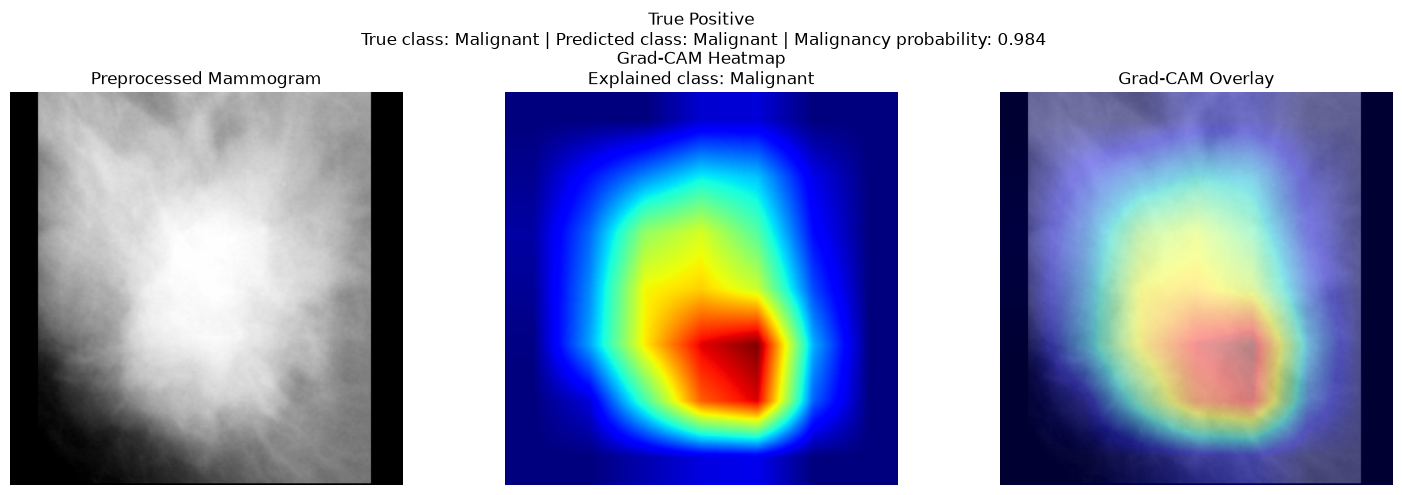


True Negative


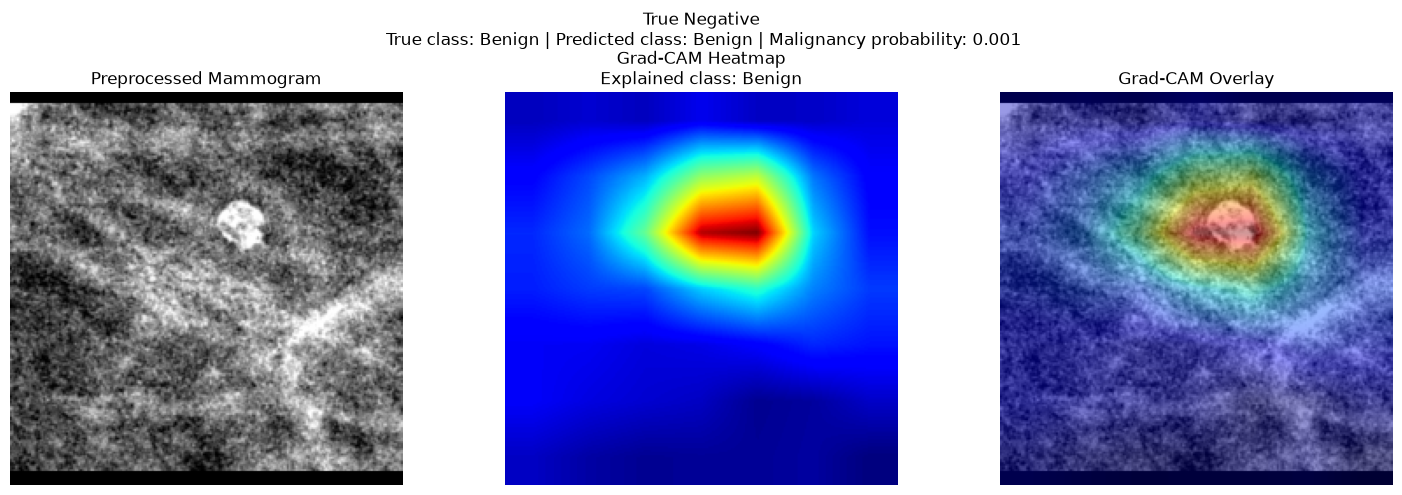


False Positive


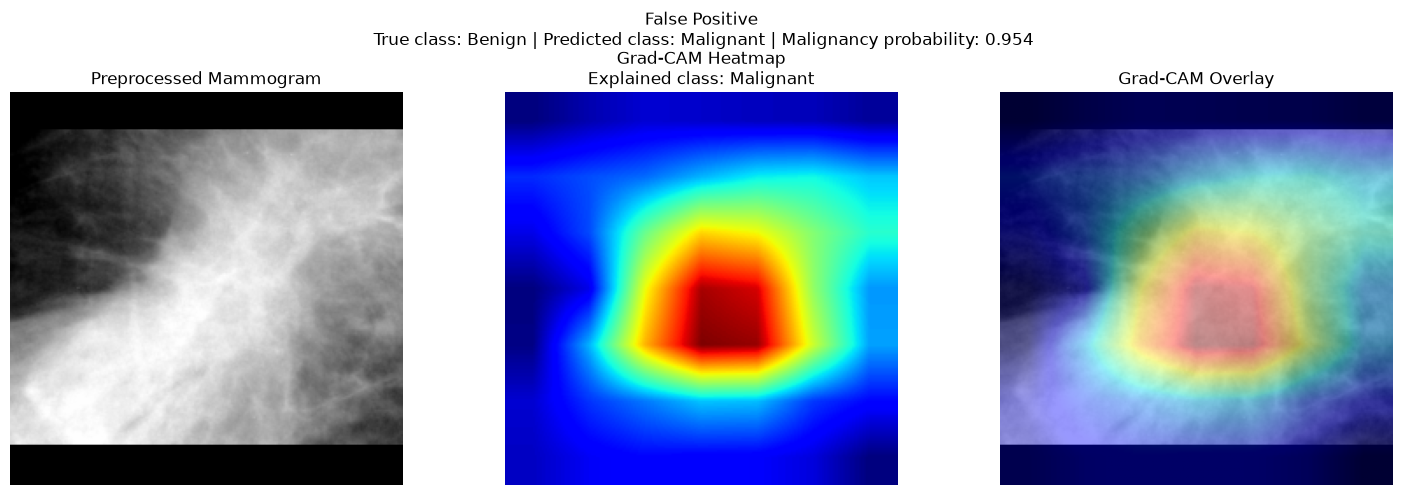


False Negative


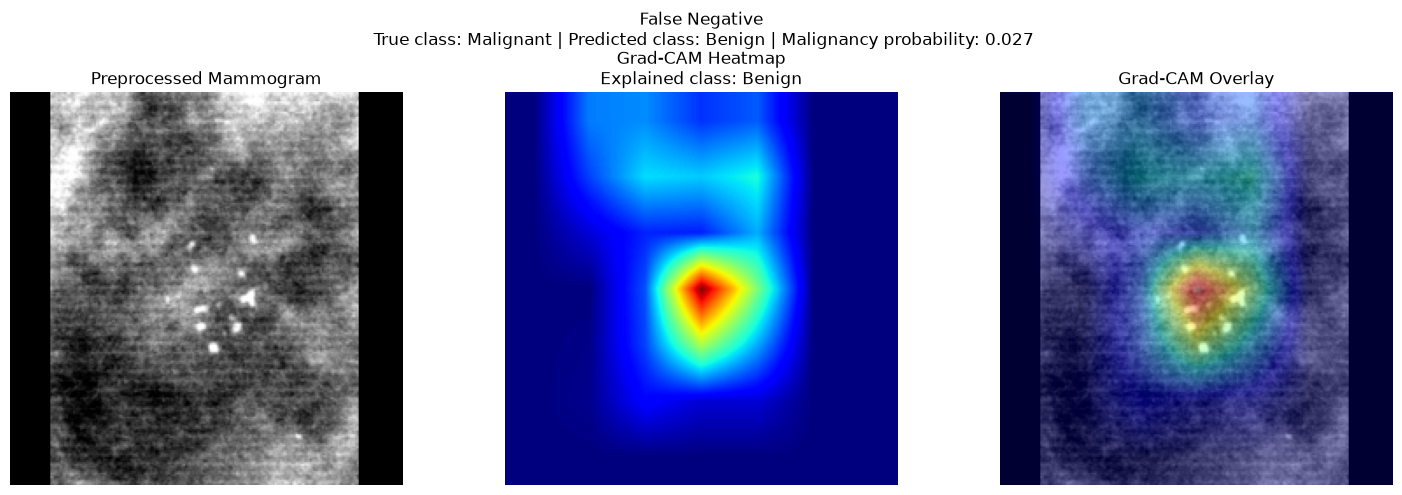

Representative Grad-CAM visualisations validated.


In [574]:
representative_gradcam_outputs = {}

for _, row in representative_gradcam_cases.iterrows():
    outcome = row["Prediction Outcome"]

    print(f"\n{outcome}")

    #the display function reloads this rows DICOM image and checks
    #that its model probability matches the stored probability
    representative_gradcam_outputs[outcome] = (
        display_gradcam_explanation(
            row=row,
            target_class=int(row["Predicted Class"]),
            overlay_strength=0.40,
        )
    )

#confirm that every selected outcome produced a valid heatmap
assert len(representative_gradcam_outputs) == len(
    representative_gradcam_cases
)

for output in representative_gradcam_outputs.values():
    heatmap = output["heatmap"]
    assert np.isfinite(heatmap).all()
    assert heatmap.min() >= 0.0
    assert heatmap.max() <= 1.0 + 1e-6

print("Representative Grad-CAM visualisations validated.")
        

__Interpretation__

The true positive (malignancy probability 0.984) shows broad activation over the prominent central image region, while the true negative (0.001) has a more concentrated activation near a bright feature. The false positive (0.954) also shows central activation despite its benign label. This indicates that a visually plausible heatmap can accompany an incorrect, highly confident prediction.

The false negative (0.027) is particularly informative: the heatmap for the predicted benign class overlaps the visible cluster of bright features, yet the model classified this malignant record as benign. Thus activation near an apparent finding does not show that the model interpreted it correctly. Together, these examples add case-level insight to the validation metrics and highlight the need to inspect confident errors. Because Grad-CAM is derived from 7 x 7 feature maps and no lesion-mask comparison is made here, the overlays cannot establish precise localisation or clinical relevance. 

### 14.10 Grad-CAM for Images with Higher Model Disagreement

To explore the relationship between uncertainty and spatial explanations, Grad-CAM is applied to the three images with the highest mutual information within the 20-image sample examined in Section 13.11. Their uncertainty scores were calculated directly from their DICOM paths, preserving image-to-score correspondence. This comparison is illustrative; it does not establish whether model disagreement causes any particular heatmap pattern.

Sample mutual information:0.1517| Sample predictive entropy: 0.4673


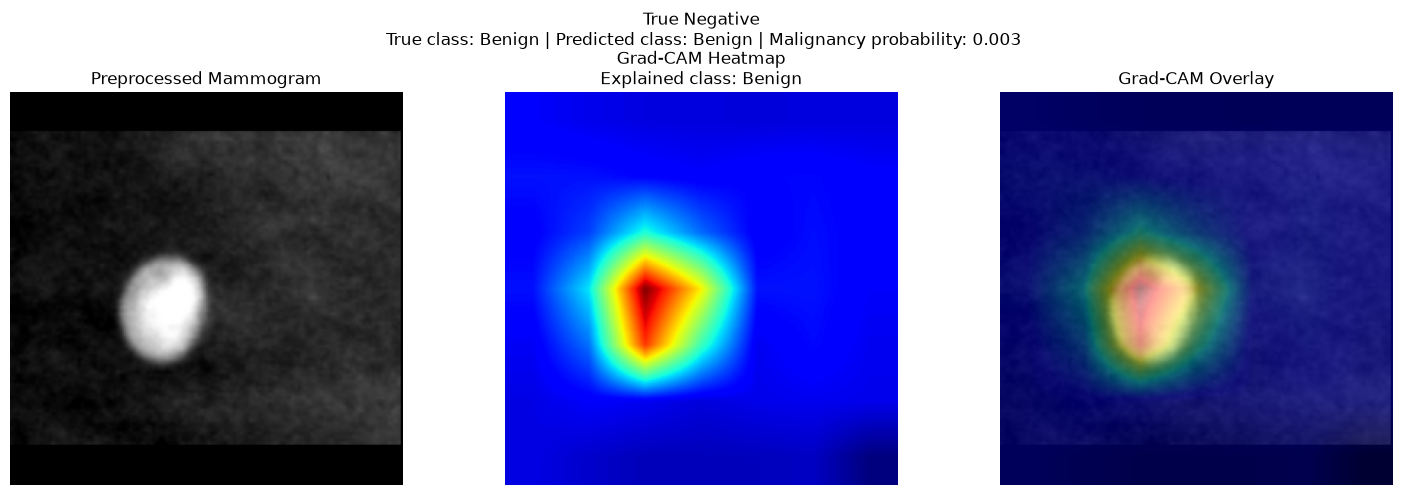

Sample mutual information:0.0651| Sample predictive entropy: 0.6752


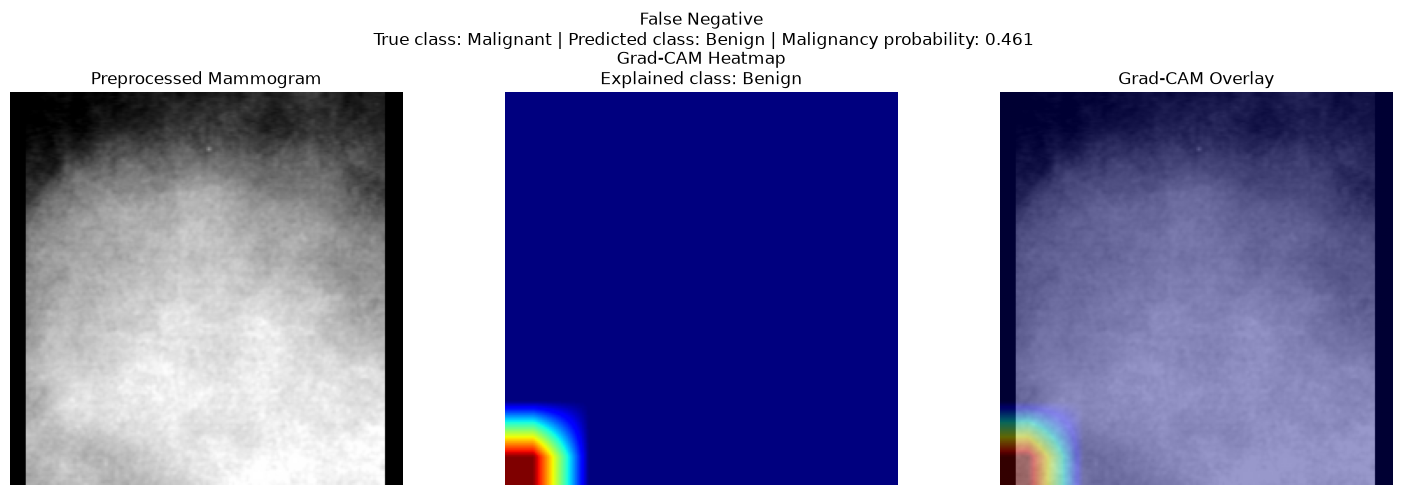

Sample mutual information:0.0542| Sample predictive entropy: 0.4423


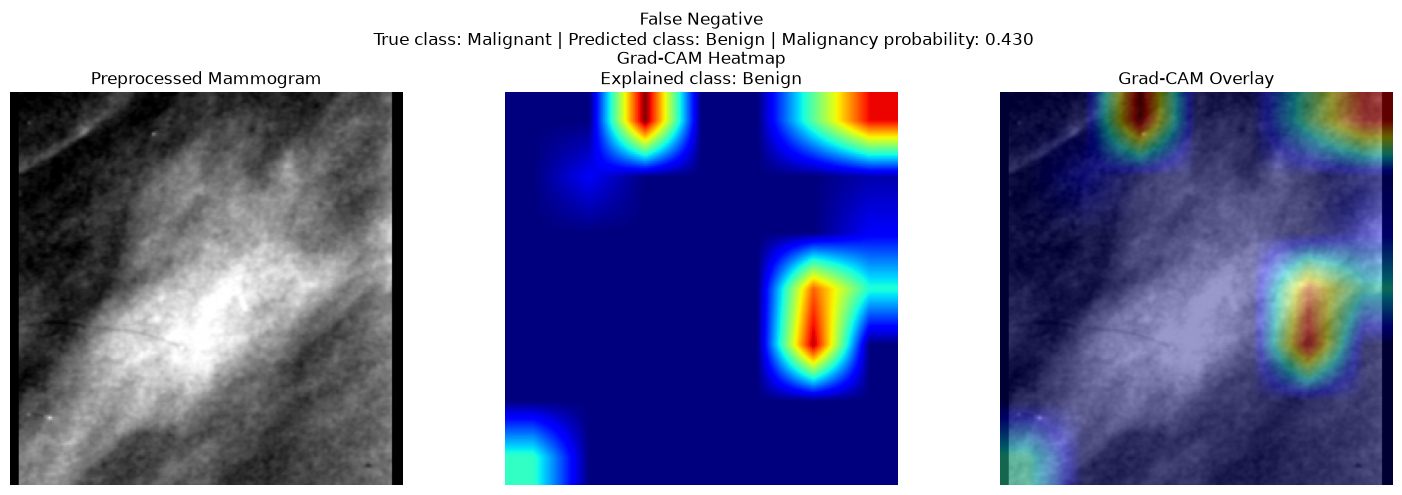

In [579]:
TOP_GRAD_CAM_UNCERTAIN_CASES = 3

#these scores and paths were paired directly in Section 13.13
top_uncertain_examples = example_results.nlargest(
   TOP_GRAD_CAM_UNCERTAIN_CASES,
    "Mutual Information",
)

for _, example_row in top_uncertain_examples.iterrows():
    image_path = example_row["resolved_dicom_path"]

    #find the path aligned deterministic prediction from section 14.2
    matching_rows = gradcam_results.loc[
        gradcam_results["resolved_dicom_path"] == image_path
    ]

    assert len(matching_rows) == 1, (
        "Expected exactly one validation record for this DICOM path."
    )

    gradcam_row = matching_rows.iloc[0]

    print(
        "Sample mutual information:"
        f"{example_row['Mutual Information']:.4f}"
        "| Sample predictive entropy:",
        f"{example_row['Predictive Entropy']:.4f}",
    )

    #explain the selected model's deterministic predicted class
    display_gradcam_explanation(
        row=gradcam_row,
        target_class=int(gradcam_row["Predicted Class"]),
        overlay_strength=0.40,
    )

__Interpretation__

The three images had the highest mutual information within the 20-image sample (0.152, 0.065 and 0.054). Their heatmaps show different patterns rather than one characteristic appearance of uncertainty. In the true-negative case, activation for the predicted benign class is concentrated around the prominent bright feature. In the two false negatives, benign-class activation falls mainly at an image corner or in several separated regions, including areas near the boundary. These patterns warrant closer inspection because both malignant records were classified as benign.

The first case also illustrates why the measures should be reported separately: its deterministic malignancy probability was 0.003, while its dropout predictions showed substantial disagreement (mutual information 0.152). A decisive single prediction can therefore coexist with sensitivity to dropout sampling. The corner and boundary activations raise the possibility that image context influenced some decisions, but these 7 x 7, post-hoc heatmaps cannot establish why the model erred or whether those regions are clinically irrelevant. This quantitative analysis complements the false-negative counts and uncertainty results; it does not establish a general pattern across all validation images.

### 14.13 Interpretation and Limitations

The validation Grad-CAM examples showed activation over prominent image regions in both correct and incorrect predictions. In two false-negative examples selected for higher model disagreement, activation for the predicted benign class also appeared near image boundaries. These observations help identify cases worth investigating, but four outcome examples and three uncertainty-selected examples cannot establish a dataset-wide localisation pattern. The heatmaps originate from 7 x 7 feature maps and provide coarse, post-hoc explanations rather than lesion boundaries. Quantitative comparison with radiologist ROI masks would require verified correspondence and spatial alignment between every image, mask and heatmap.

### 15 Final Evaluation on the Held-Out Test Set

The EfficientNetB0 model and evaluation procedure were selected using the training and validation partitions. The patient-independent test partition is now used for the final assessment. No model weights, decision thresholds or calibration parameters are fitted using test labels. 
Performance is reported using discrimination metrics, threshold-based classification metrics and a confusion matrix. Predictions and labels are collected from the same dataset iteration to preserve their correspondence. This is especially important because the earlier dataset construction permitted shuffling.

### 15.1 Evaluation Protocol

The EfficientNetB0 checkpoint and evaluation settings were fixed using the training and validation partitions. The patient-independent test partition is now evaluated without further model fitting or threshold adjustment. The 0.5 classification threshold using during validation and the temperature fitted on validation data are carried forward unchanged.

The final analysis reports discrimination, threshold-based classification performance, calibration and predictive uncertainty. Test predictions and labels are collected together to preserve their correspondence.

In [581]:
#freeze the settings established before test evaluation
#before performing the final evaluation on the held-out test partition
FINAL_CLASSIFICATION_THRESHOLD = float(
    EFFICIENTNET_VALIDATION_THRESHOLD
)

#store the validation fitted temperature scaling parameter as the fixed value used for final probability calibration
FINAL_TEMPERATURE = float(temperature.numpy())

#confirm that the selected classification threshold is a valid probability threshold
assert 0.0 < FINAL_CLASSIFICATION_THRESHOLD < 1.0

#confirm that the temperature scaling parameter is strictly positive
assert FINAL_TEMPERATURE > 0.0

#display the fixed calculation threshold used for final test evaluation
print("Final classification threshold:", FINAL_CLASSIFICATION_THRESHOLD)
print("Validation-fitted temperature:", FINAL_TEMPERATURE)

Final classification threshold: 0.5
Validation-fitted temperature: 1.155593991279602


### 15.2 Evaluation Protocol

The restored EfficientNetB0 checkpoint is applied to the held-out test images in inference mode, producing one malignancy probability per image. Each batch's predictions are collected alongside its labels, ensuring they remain correctly paired even it the dataset order changes. Binary predictions are then obtained using the fixed 0.5 threshold.

In [586]:
#collect each batchs labels and predictions in the same dataset pass
#this preserves their pairing even if test_dataset is shuffled
test_target_batches = []
test_probability_batches = []

for images, labels in test_dataset:
    batch_probabilities = best_efficientnet_model(
        images,
        training=False
    ).numpy().reshape(-1)

    test_probability_batches.append(batch_probabilities)
    test_target_batches.append(
        labels.numpy().astype(int).reshape(-1)
    )

efficientnet_test_probabilities = np.concatenate(
    test_probability_batches
)

efficientnet_test_targets = np.concatenate(
    test_target_batches
)

#apply the fixed threshold without using test labels to tune it
efficientnet_test_predictions = (
    efficientnet_test_probabilities
    >= FINAL_CLASSIFICATION_THRESHOLD
).astype(int)

#validate the arrays before calculating any performance metrics
assert len(efficientnet_test_probabilities) == len(test_df)
assert len(efficientnet_test_targets) == len(test_df)
assert len(efficientnet_test_predictions) == len(test_df)

assert np.isfinite(efficientnet_test_probabilities).all()
assert np.all(
    (efficientnet_test_probabilities >= 0.0)
    & (efficientnet_test_probabilities <= 1.0)
)

assert set(np.unique(efficientnet_test_targets)) == {0, 1}
assert set(np.unique(efficientnet_test_predictions)).issubset({0, 1})

print("Number of test observations:", len(efficientnet_test_targets))
print(
    "Probability range:",
    (
        float(efficientnet_test_probabilities.min()),
        float(efficientnet_test_probabilities.max())
    )
)

Number of test observations: 527
Probability range: (0.00022623541008215398, 0.9972594976425171)


The procedure produced probabilities of 527 test observations, ranging from 0.0002 to 0.9973. All scores fall within the expected 0-1 interval. The range shows that the model made both very low and very high probability predictions; it does not, on its own, tell us whether those predictions were correct or well calibrated. 

### 15.3 Final Discrimination and Classification Performance

The selected fine-tuned EfficientNetB0 checkpoint is evaluated using the paired test labels and probabilities. ROC-AUC and average precision assess discrimination across classification thresholds. At the fixed 0.5 threshold, the confusion matrix and classification metrics describe detected malignancies, missed malignancies and false alarms. Balanced accuracy accounts for differences in class frequency.

In [590]:
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
    roc_auc_score,
)

#rows are true classes [benign, malignant]; columns are predictions
test_confusion_matrix = confusion_matrix(
    efficientnet_test_targets,
    efficientnet_test_predictions,
    labels=[0, 1],
)

test_true_negatives, test_false_positives = (
    test_confusion_matrix[0]
)

test_false_negatives, test_true_positives = (
    test_confusion_matrix[1]
)

#calculate metrics at the fixed 0.5 threshold
test_accuracy = accuracy_score(
    efficientnet_test_targets,
    efficientnet_test_predictions,
)

test_balanced_accuracy = balanced_accuracy_score(
    efficientnet_test_targets,
    efficientnet_test_predictions,
)

test_sensitivity = recall_score(
    efficientnet_test_targets,
    efficientnet_test_predictions,
    pos_label=1,
    zero_division=0,
)

test_specificity = (
    test_true_negatives
    / (test_true_negatives + test_false_positives)
)

test_precision = precision_score(
    efficientnet_test_targets,
    efficientnet_test_predictions,
    pos_label=1,
    zero_division=0,
)

#NPV describes the proportion of predicted benign records are truly benign
predicted_benign_count = (
    test_true_negatives + test_false_negatives
)

test_negative_predictive_value = (
    test_true_negatives / predicted_benign_count
    if predicted_benign_count > 0
    else np.nan
)

test_f1_score = f1_score(
    efficientnet_test_targets,
    efficientnet_test_predictions,
    pos_label=1,
    zero_division=0,
)

test_matthews_correlation = matthews_corrcoef(
    efficientnet_test_targets,
    efficientnet_test_predictions,
)

#ranking metrics use probabilities, not binary predictions
test_roc_auc = roc_auc_score(
    efficientnet_test_targets,
    efficientnet_test_probabilities,
)

test_average_precision = average_precision_score(
    efficientnet_test_targets,
    efficientnet_test_probabilities,
)

#assemble one report ready table
final_test_metrics = pd.DataFrame({
    "Metric":[
        "Accuracy",
        "Balanced Accuracy",
        "Sensitivity",
        "Specificity",
        "Precision",
        "Negative Predictive Value",
        "F1-Score",
        "Matthews Correlation Coefficient",
        "ROC-AUC",
        "Average Precision",
    ],
    "Value": [
        test_accuracy,
        test_balanced_accuracy,
        test_sensitivity,
        test_specificity,
        test_precision,
        test_negative_predictive_value,
        test_f1_score,
        test_matthews_correlation,
        test_roc_auc,
        test_average_precision,
    ],
})

#check that the confusion matrix covers all 527 test records
assert test_confusion_matrix.shape == (2, 2)
assert test_confusion_matrix.sum() == len(
    efficientnet_test_targets
)
assert np.isfinite(final_test_metrics["Value"]).all()

display(final_test_metrics.round(4))

print("True negatives:", test_true_negatives)
print("False positives:", test_false_positives)
print("False negatives:", test_false_negatives)
print("True positives:", test_true_positives)

,Metric,Value
0,Accuracy,0.7211
1,Balanced Accuracy,0.7130
2,Sensitivity,0.6622
3,Specificity,0.7639
4,Precision,0.6712
5,Negative Predictive Value,0.7565
6,F1-Score,0.6667
7,Matthews Correlation Coefficient,0.4269
8,ROC-AUC,0.7895
9,Average Precision,0.7340


True negatives: 233
False positives: 72
False negatives: 75
True positives: 147


__Interpretation of Final Test Performance__

On the 527 held-out mammograms, EfficientNetB0 correctly classified 380 (72.1%) at the fixed 0.5 threshold. Balanced accuracy was 0.7130, indicating that performance was reasonably similar across the malignant and benign classes. The model detected 147 of 222 malignant records (sensitivity 0.6622) and correctly classified 233 of 305 benign records (specificity 0.7639).

The 75 false negatives are the principal concern for a cancer-detection task: these malignant records received a benign classification. There were also 72 false positives, representing benign records flagged as malignant. Precision of 0.6712 means that roughly two-thirds of positive predictions were malignant, while the negative predictive value of 0.7565 means that roughly three-quarters of negative predictions were benign. The F1-score (0.6667) summarises the balance between precision and sensitivity, and the positive MCC (0.4269) indicates useful, though imperfect, classification across both classes.

The threshold-independent results were stronger: ROC-AUC was 0.7895 and average precision was 0.7340, indicating that the probability scores generally ranked malignant records above benign ones. Both exceed the validation results reported earlier (ROC-AUC 0.7689, average precision 0.6908), providing encouraging evidence of generalisation to this patient-independent test partition. The remaining false negatives and false positives show that good ranking performance does not eliminate consequential errors at the chosen threshold; these results do not establish readiness for clinical use.

### 15.4 Confusion Matrix
The confusio matrix summarises the final test predictions according to their true and predicted class.

,Predicted Benign,Predicted Malignant
True Benign,233,72
True Malignant,75,147


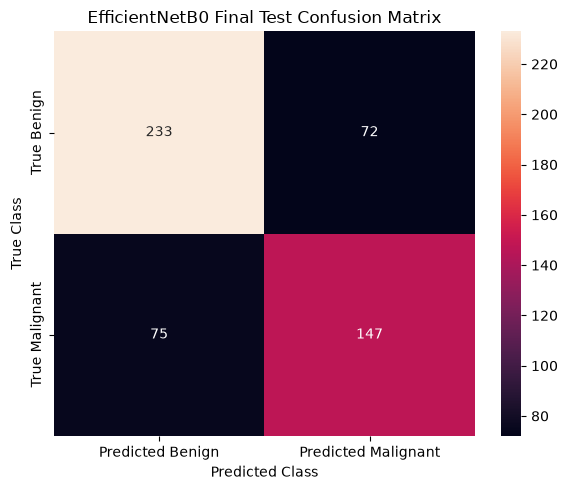

In [593]:
#create a labelled dataframe from the test confusion matrix
# to make the true and predicted classes easier to interpret
test_confusion_matrix_display = pd.DataFrame(
    test_confusion_matrix,

    #label the rows according to the true ground-truth classes
    index=[
        "True Benign",
        "True Malignant"
    ],

    #label the columns according to the model predicted classes
    columns=[
        "Predicted Benign",
        "Predicted Malignant",
    ]
)

#display the labelled confusion matrix for interpretation
display(test_confusion_matrix_display)


#create a heatmap visualisation of the final test confusion matrix
plt.figure(
    figsize=(6, 5)
)

#display the number of test records within each confusion matrix cell
sns.heatmap(
    test_confusion_matrix_display,
    annot=True,
    fmt="d",
    cbar=True
)

#label the axis 
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
#add descriptive title
plt.title("EfficientNetB0 Final Test Confusion Matrix")
#adjust the figure layout to prevent labels from being clipped
plt.tight_layout()
#display the completed confusion matrix heatmap
plt.show()

The confusion matrix shows 233 true negatives, 147 true positives, 72 false positives and 75 false negatives. Thus, at the fixed 0.5 threshold, the model detected 147 of 222 malignant records but classified 75 as benign. This makes the missed malignant cases an important limitation despite the model's overall test accuracy of 72.1%

### 15.5 ROC and Precision Recall Curves

The final test probabilities are examined across classification thresholds. The ROC curve shoes the trade-off between detecting malignant records and incorrectly flagging benign records. The precision-recall curve focuses on how reliably positive predictions identify malignancy as recall changes. ROC-AUC and average precision summarise these curves without relying on the fixed 0.5 threshold.

,Measure,Value
0,ROC-AUC,0.7895
1,Average precision,0.7340
2,Malignant prevalence,0.4213


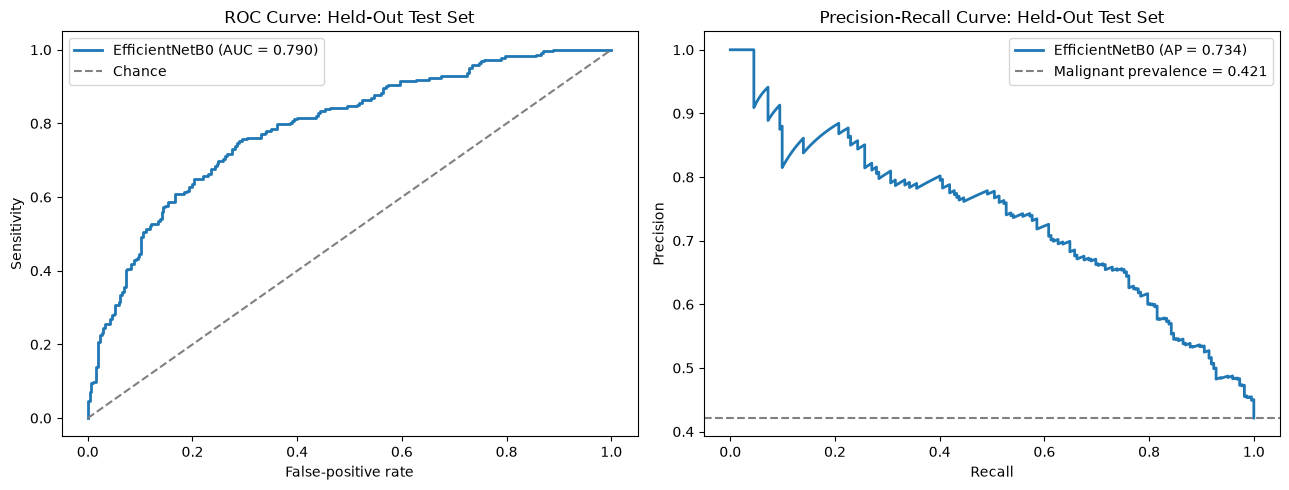

In [596]:
from sklearn.metrics import roc_curve, precision_recall_curve

#calculate both curves from the paired test labels and probabilities
fpr, tpr, _ = roc_curve(
    efficientnet_test_targets,
    efficientnet_test_probabilities
)

precision_curve, recall_curve, _ = precision_recall_curve(
    efficientnet_test_targets,
    efficientnet_test_probabilities
)

malignant_prevalence = np.mean(efficientnet_test_targets)

#summarise threshold independent test performance
curve_summary = pd.DataFrame({
    "Measure": [
        "ROC-AUC",
        "Average precision",
        "Malignant prevalence"
    ],
    "Value": [
        test_roc_auc,
        test_average_precision,
        malignant_prevalence
    ]
})

display(curve_summary.round(4))

#dispaly the ROC and precision-recall curves side by side
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(
    fpr, tpr,
    linewidth=2,
    label=f"EfficientNetB0 (AUC = {test_roc_auc:.3f})"
)
axes[0].plot(
    [0, 1],[0, 1],
    "--",
    color="gray",
    label="Chance"
)
axes[0].set(
    title="ROC Curve: Held-Out Test Set",
    xlabel="False-positive rate",
    ylabel="Sensitivity"
)
axes[0].legend()

axes[1].plot(
    recall_curve, precision_curve,
    linewidth=2,
    label=f"EfficientNetB0 (AP = {test_average_precision:.3f})"
)
axes[1].axhline(
    malignant_prevalence,
    linestyle="--",
    color="gray",
    label=f"Malignant prevalence = {malignant_prevalence:.3f}"
)
axes[1].set(
    title="Precision-Recall Curve: Held-Out Test Set",
    xlabel="Recall",
    ylabel="Precision"
)
axes[1].legend()

plt.tight_layout()
plt.show()
    
    

__Interpretation__

The table summarises performance across classification thresholds: ROC-AUC was 0.7895 and average precision was 0.7340. Malignant prevalence was 0.4213 (222 of 527 test records), providing a reference level for the precision-recall curve.

In the ROC graph, the blue curve stays above the dashed diagonal. The diagonal represents chance ranking: a model with no ability to distinguish malignant from benign records would have an ROC-AUC of approximately 0.5. The observed curve shows that EfficientNetB0 generally assigns higher malignancy probabilities to malignant records, although increasing sensitivity also increases the false-positive rate. 

In the precision-recall graph, precision generally falls as recall rises: detecting more malignant records requires accepting more false positives. The dashed horizontal line marks malignant prevanlence, the approximate precision expected if records were flagged without useful ranking. The curve remains above that line across most recall levels. Together, the graphs show useful discrimination while making clear the practical trade-off behind choosing an operating threshold; the confusion matrix reports that trade-off specially at 0.5.

### 15.6 Test Prediction Results

The aggregate test results are extended to individual records so that prediction errors and performance by abnormality type can be examined. Each probability is generated directly from the DICOM path in its metadata row, preserving the correspondence between the image, diagnosis and predicted score. The model and 0.5 threshold remain fixed.

In [603]:
#keep metadata in a fixed order for record level evaluation
test_prediction_results = test_df.reset_index(drop=True).copy()

test_probabilities_by_record = []
TEST_CASE_BATCH_SIZE = 16

#predict directly from each metadata path so scores remain attached to the correct record, regardless of test_dataset shuffling
for start in range(0, len(test_prediction_results), TEST_CASE_BATCH_SIZE):
    batch_rows = test_prediction_results.iloc[
        start:start + TEST_CASE_BATCH_SIZE
    ]

    batch_images = np.stack([
        load_and_preprocess_dicom(path)
        for path in batch_rows["resolved_dicom_path"]
    ]).astype(np.float32)

    batch_probabilities = best_efficientnet_model(
        batch_images,
        training=False
    ).numpy().reshape(-1)

    test_probabilities_by_record.extend(batch_probabilities)

#add the label, fixed threshold decision and outcome to each row
test_prediction_results["True Class"] = (
    test_prediction_results["target"].astype(int)
)

test_prediction_results["Predicted Probability"] = np.asarray(
    test_probabilities_by_record,
    dtype=np.float32
)

test_prediction_results["Predicted Class"] = (
    test_prediction_results["Predicted Probability"]
    >= FINAL_CLASSIFICATION_THRESHOLD
).astype(int)

test_prediction_results["Correct Prediction"] = (
    test_prediction_results["True Class"]
    == test_prediction_results["Predicted Class"]
)



#define the outcome labels before using the funcion below
def classify_prediction_outcome(true_class, predicted_class):
    true_class = int(true_class)
    predicted_class = int(predicted_class)

    if true_class == 1 and predicted_class == 1:
        return "True Positive"
    if true_class == 0 and predicted_class == 0:    
        return "True Negative"
    if true_class == 0 and predicted_class == 1:
        return "False Positive"
    return "False Negative"
    

test_prediction_results["Prediction Outcome"] = [
    classify_prediction_outcome(true_class, predicted_class)
    for true_class, predicted_class in zip(
        test_prediction_results["True Class"],
        test_prediction_results["Predicted Class"],
    )
]

#check that path based inference reproduces the aggregate test results
record_confusion_matrix = confusion_matrix(
        test_prediction_results["True Class"],
        test_prediction_results["Predicted Class"],
        labels=[0, 1]
)

assert len(test_prediction_results) == len(test_df)
assert test_prediction_results["Predicted Probability"].between(0, 1).all()
assert np.array_equal(record_confusion_matrix, test_confusion_matrix), (
    "Path-based predictions do not reproduce Section 15.3 "
    "Check that DICOM preprocessing matches the test_dataset pipeline."
)

display(
    test_prediction_results[
        [
            "abnormality_group",
            "True Class",
            "Predicted Probability",
            "Predicted Class",
            "Prediction Outcome"
        ]
    ].head()
)

print("Record-level test predictions validated.")

,abnormality_group,True Class,Predicted Probability,Predicted Class,Prediction Outcome
0,calcification,1,0.557613,1,True Positive
1,calcification,1,0.333069,0,False Negative
2,calcification,1,0.312518,0,False Negative
3,calcification,1,0.206718,0,False Negative
4,calcification,1,0.205520,0,False Negative


Record-level test predictions validated.


The record-level predictions reproduced the overall test confusion matrix, confirming that each displayed probability is linked to its corresponding DICOM record and label. The preview illustrates how individual malignant calcifications can fall on either side of the fixed 0.5 threshold. Performance across all mass and calcification records is examined next.

### 15.6.1 Test Performance by Abnormality Type

Performance is then summarised separately for mass and calcification records. The same checkpoint, probabilities and 0.5 threshold are used in both groups. This descriptive analysis identifies whether the overall result conceals differences between abnormality types.

In [610]:
#initialise an empty list to store the performance results for each mammographic abnormality subgroup
subgroup_rows = []

#separate the test records according to abnormality type and evaluate model performance independently within each group
for group, cases in test_prediction_results.groupby(
    "abnormality_group"
):

    #extract the ground truth binary classes for the current subgroup
    true = cases[
        "True Class"
    ].to_numpy()

    #extract the binary predictions obtained using the fixed classification threshold
    predicted = cases[
        "Predicted Class"
    ].to_numpy()

    #extract the predicted malignancy probabilities for threshold independent metrics
    probabilities = cases[
        "Predicted Probability"
    ].to_numpy()

    #calculate the confusion matrix for the current subgroup and extract true negatives, 
    #false positives, false negatives and true positives
    tn, fp, fn, tp = confusion_matrix(
        true,
        predicted,
        labels=[0, 1]
    ).ravel()

    #store the subgroup characteristics, confusion matrix counts and classification performance measures
    subgroup_rows.append({

    #record the name of the abnormality subgroup
    "Abnormality Group": group,

    #record the total number of test cases within the subgroup
    "Records": len(cases),

    #count the number of malignant ground-truth records
    "Malignant Records": int(
        (true == 1).sum()
    ),

    #store the four confusion matrix components
    "TN": int(tn),
    "FP": int(fp),
    "FN": int(fn),
    "TP": int(tp),

    ##calculate sensitivity as the proportion of malignant cases tht were correctly identified as malignant
    "Sensitivity": (
        tp / (tp + fn)
        if tp + fn
        else np.nan
    ),
        
    ##calculate specificity as the proportion of benign cases tht were correctly identified as malignant
    "Specificity": (
        tn / (tn + fp)
        if tn + fp
        else np.nan
    ),

    #calculate the ROC-AUC only when both benign and malignant ground truth classes are present within the subgroup
    "ROC-AUC": (
        roc_auc_score(
            true,
            probabilities
        )
        if len(np.unique(true)) == 2
        else np.nan
    ),

    #calculate average precision only when both ground truth classes are represented within the subgroup
    "Average Precision": (
        average_precision_score(
            true,
            probabilities
        )
        if len(np.unique(true)) == 2
        else np.nan
    )
})

#create a dataframe containing the performance results for each mammographic abnormality subgroup
subgroup_test_performance = pd.DataFrame(
    subgroup_rows
)

#confirm that the subgroup record counts collectively account for every record in the held out test partition
assert subgroup_test_performance[
    "Records"
].sum() == len(
        test_prediction_results
)

#confirm that the subgroup confusion matrix counts reproduce the overall confusion matrix results from the complete test set
assert subgroup_test_performance[
    [
        "TN",
        "FP",
        "FN",
        "TP"
    ]
].sum().tolist() == [
    test_true_negatives,
    test_false_positives,
    test_false_negatives,
    test_true_positives
]

#display the subgroup specific test performance with numerical values rounded to four decimal places
display(subgroup_test_performance.round(4))

,Abnormality Group,Records,Malignant Records,TN,FP,FN,TP,Sensitivity,Specificity,ROC-AUC,Average Precision
0,calcification,252,99,126,27,44,55,0.5556,0.8235,0.7862,0.7040
1,mass,275,123,107,45,31,92,0.7480,0.7039,0.8001,0.7668


__Interpretation__

Performance differed by abnormality type. For calcifications, the model detected 55 of 99 malignant records (sensitivity 0.5556) and missed 44, while correctly identifying 126 of 153 benign records (specificity 0.8235). For masses, it detected 92 of 123 malignant records (sensitivity 0.7480) but produced more false positives: 45 of 152 benign masses, compared with 27 benign calcifications.

Both groups showed useful ranking performance, with ROC-AUCs of 0.7862 for calcifications and 0.8001 for masses. Average precision was also higher for masses (0.7668 versus 0.7040), although the groups have different malignant proportions. These results show that the overall test sensitivity of 0.6622 conceals a greater tendency to miss malignant calcifications at the fixed 0.5 threshold. The subgroup findings are descriptive and do not establish why the model behaves differently.

### 15.7 Probability Calibration on the Held-Out Test Set
The temperature fitted on validation is applied unchanged to the held-out test probabilities. Calibration is assessed before and after scalinf using the Brier scpre, expected calibration error (ECE), maximum calibration error (MCE) and a shared reliability diagram. This analysis tests whether the validation-derived adjustment generalises to unseen records. The classifier weights and evaluation threshold remain fixed. Relibility diagrams compare mean predicted probability with observed event frequency within probability bins.

,Measure,Before scaling,After scaling
0,ECE,0.0609,0.0497
1,MCE,0.1061,0.0878
2,Brier score,0.1854,0.1865
3,ROC-AUC,0.7895,0.7895


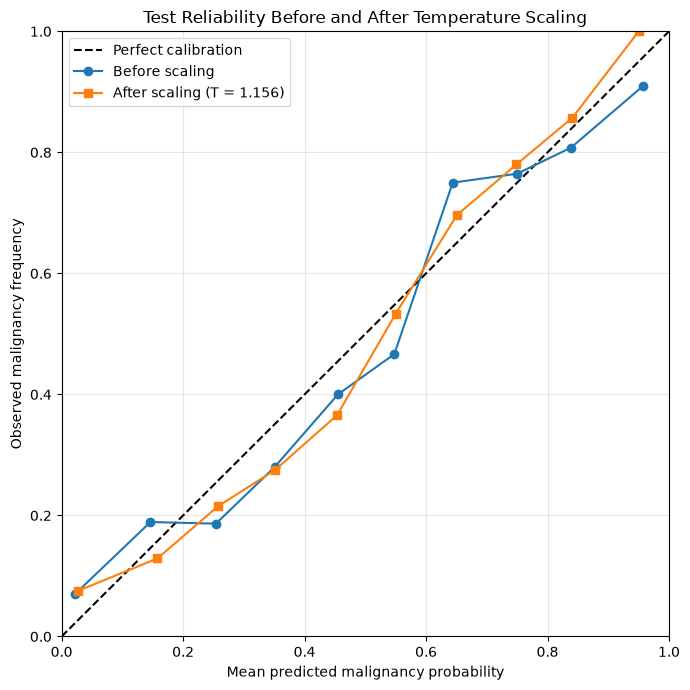

In [618]:
from sklearn.metrics import brier_score_loss, roc_auc_score

#apply the validation fitted temperature to the fitted test scores
epsilon = 1e-7
raw_test_probabilities = np.asarray(
    efficientnet_test_probabilities, dtype=np.float64
)

test_targets = np.asarray(efficientnet_test_targets, dtype=int)

clipped = np.clip(raw_test_probabilities, epsilon, 1 - epsilon)
test_logits = np.log(clipped / (1 - clipped))

scaled_logits = test_logits / FINAL_TEMPERATURE
calibrated_test_probabilities = np.where(
    scaled_logits >= 0,
    1 / (1 + np.exp(-scaled_logits)),
    np.exp(scaled_logits) / (1 + np.exp(scaled_logits))
)

#use the same ten fixed width bins for both sets of probabilities
bin_edges = np.linspace(0, 1, 11)

def test_reliability_statistics(probabilities, targets):
    """Return occupied statistics and count-weighted ECE. """
    indices = np.searchsorted(
        bin_edges, probabilities, side="right"
    ) - 1
    indices = np.clip(indices, 0, len(bin_edges) - 2)

    rows = []
    for index in range(len(bin_edges) - 1):
        mask = indices == index
        if not mask.any():
            continue

        mean_probability = float(probabilities[mask].mean())
        observed_frequency = float(targets[mask].mean())

        rows.append({
            "Count": int(mask.sum()),
            "Mean probability": mean_probability,
            "Observed frequency": observed_frequency,
            "Absolute error": abs(mean_probability - observed_frequency)
        })

    statistics = pd.DataFrame(rows)
    assert statistics["Count"].sum() == len(targets)

    ece_value = float(
            (
                statistics["Count"] / len(targets)
                * statistics["Absolute error"]
            ).sum()
        )
    return statistics, ece_value

before_bins, before_ece = test_reliability_statistics(
        raw_test_probabilities, test_targets
    )

after_bins, after_ece = test_reliability_statistics(
    calibrated_test_probabilities, test_targets
    )

    #summarise probabilistic performance without fitting on test data
test_calibration_comparison = pd.DataFrame({
        "Measure":["ECE", "MCE","Brier score", "ROC-AUC"],
        "Before scaling": [
            before_ece,
            before_bins["Absolute error"].max(),
            brier_score_loss(test_targets, raw_test_probabilities),
            roc_auc_score(test_targets, raw_test_probabilities)
        ],
        "After scaling": [
            after_ece,
            after_bins["Absolute error"].max(),
            brier_score_loss(test_targets, calibrated_test_probabilities),
            roc_auc_score(test_targets, calibrated_test_probabilities)
        ]
    })

display(test_calibration_comparison.round(4))

#compare both reliability curves against perfect calibration
plt.figure(figsize=(7, 7))
plt.plot([0, 1],[0, 1], "--", color="black",
        label="Perfect calibration")

plt.plot(
    before_bins["Mean probability"],
    before_bins["Observed frequency"],
    marker="o",
    label="Before scaling"
)
plt.plot(
    after_bins["Mean probability"],
    after_bins["Observed frequency"],
    marker="s",
    label=f"After scaling (T = {FINAL_TEMPERATURE:.3f})"
)  

plt.xlabel("Mean predicted malignancy probability")
plt.ylabel("Observed malignancy frequency")
plt.title("Test Reliability Before and After Temperature Scaling")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


__Interpretation: Test Calibration__

The dashed black diagonal represents perfect calibration: a bin with a mean predicted malignancy probability of 0.7 would contain approximately 70% malignant records. Blue circles show the original probabilities; orange squares show probabilities after applying the validation-fitted temperature of 1.156. Points above the diagonal include underestimated malignancy frequency, while points below it indicate overestimated frequency.

The cruves reveal errors in both directions. Before scaling, the bin near 0.55 lies below the diagonal, indicating overestimated risk, whereas the bin near 0.65 lies above it, indicating underestimated risk. Temperature scaling moves some points clear ot the diagonal, but does not correct every interval. The orange point near the upper-right corner is laso above the diagonal; its appearance should be treated cautiously because the plot does not show how many records are in that bin. The blue and orange points need not represent the same records, since scaling can move predictions between bins.

The table gives the more useful overall comparison. Test ECE decreased from 0.0609 to 0.0497, and the largest bin level error (MCE) decreased from 0.1061 to 0.0878. Thus, agreement between average predicted and observed malignancy frequencies improved under these ten bins. However, the Brier score increased slightly from 0.1854 to 0.1865, so the squared error of individual predictions did not improve. ROC-AUC remained 0.7895, as temperature scaling preserves the ranking of records.

Together with the ROC and precision-recall curves, this shows that the model can rank malignant records reasonably well, while the reliability diagram addresses a separate question: whether its numerical probabilities reflect observed risk. Calibration cannot resolve 75 missed malignant records in the confusion matrix; with a positive temperature and the smae 0.5 threshold, those binary decisions remain unchanged. The lower sensitivity for malignant calcifications therefore remains an important limitation despite the improvement in test ECE and MCE. The mixed validation results and slight test Brier increase support describing scaling as a modest, metric-dependent improvement in bin-level reliability, rather than claiming that the probabilities are fully calibrated.


### 16 Discussion

### 16.1 Overview of the findings

This study examined whether a pretrained convolutional network could distinguish benign from malignant cropped mammographic abnormalities more effectively than a custom CNN, and whether its predictions could be examined through calibration, uncertainty estimation and visual explanations. The strongest model was the selectively fine-tuned EfficientNetBO. On the patient-independent held-out test partitions, it achieved a ROC-AUC of 0.7895, average precision of 0.7340 and accuracy of 0.7211. The results show meaningful discriminination between the two classes, while the sensitivity of 0.6622 and 75 missed malignant records show that discrimination between the two classes, while the sensitivity of 0.6622 and 75 missed malignant records show that discrimination alone is sufficient to establish clinical readiness. 

The patient-independent split is central to interpreting these results: records belonging to one patient were kept within the same partition. This reduces the possibility that closely related images from one patient appear in both development and test data. CBIS-DDSM supplies curated mammographic abnormalities and annotations for research, but performance on its cropped lesions answers a narrower question than performance in an unselected screening population [2,8].

### 16.2 What transfer learning and fine-tuning contributed

The baseline CNN reached a best validation ROC-AUC of 0.6552, compared with 0.7634 for EfficientNetBO with its backbone frozen. Its recall at the default 0.5 threshold was high (0.9755), but its accuracy (0.5218) and precision (0.4575) were low. The baseline therefore identified most malignant validation records by assigning positive classification very frequently; its high recall did not indicate strong overall separation of benign and malignant abnormalities. The ROC-AUC and precision-recall results together make that distinction clearer than accuracy or recall alone. 

The substantial gain from the frozen EfficientNetBO backbone suggest that pretrained image features were useful even before adapting the deeper layers to mammography. This supports the choice of transfer learning for a relatively limited lesion dataset. EfficientNet was designed to balance network depth,width and image resolution, providing a practical backbone for the study's computational setting [3]. Its ImageNet pretraining does not make the network inherently knowledgeable about mammographic pathology; the observed improvement is an empirical result of this dataset and pipeline. 

Selective fine-tuning increased the best validation ROC-AUC from 0.7634 to 0.7684, a gain of 0.0050, while validation PR-AUC increased from 0.6884 to 0.6902. The learning curves indicate that training performance continued to improve after the best validation epoch, whereas validation discrimination offered little further gain. Restoring Stage 2 epoch 5 therefore retained the strongest observed validation checkpoint and limited the effect oof later training. The small difference between stages support a modest benefit from adaptation, rather than a large improvement attributable to unfreezing deeper layers. The subsequently recomputed ROC-AUC of 0.7689 and average precision of 0.6908 describe the restored checkpoint using the full set of validation probabilities; the small difference from the training-history values reflect the evaluation calculations.

The exploratory EfficientNetV2BO comparison adds an important qualification. Its fine-tuned checkpoint achieved a validation ROC-AUC of 0.7450 and average precision of 0.6567, below EfficientNetBO's 0.7689 and 0.6908 in the paired evaluation. At the 0.5 threshold, however, V2B0 had higher recall (0.6814 versus 0.5980) and F-1 score (0.6290 versus 0.6025), alongside lower precision (0.5840 versus 0.6070). Thus, the architecture with better probability ranking was not the one with the highest recall at the particular operating threshold. EfficientNetV2 was developed with improved tranining efficient in mind [4], but this post-hoc experiment used a limited training budget and does not establish that EfficientNetBO is generally superior to V2BO. 

### 16.3 Held-out discrimination and the consequences of a fixed threshold

The ROC and precision-recall curves describe complementary aspects of the final model. A test ROC-AUC of 0.7895 indicates that malignant records generally received higer scores than benign records across thresholds. Average precision was 0.7340, above the test malignant prevalence of approximately 0.4213 shown as the precision-recall reference line. That reference represents the precision expected when positive predictions reflect class prevalence rather than useful ranking. Precision-recall analysis is particularly informative when the frequency of the positive class affects the practical meaning of a positive result [10]. Neither area measure states how many cancers are missed at the selected threshold. 

The confusion matrix supplies that operating-point information. At the fixed 0.5 fixed threshold, the model correctly classified 233 benign and 147 malignant records, with 72 false positive and 75 false negative. It identified 147 of 222 malignant records and missed 75 of 222, or approximately 33.8%. Specificity (0.7639) exceeded sensitivity (0.6622), indicating that this threshold favoured correct benign classification more than malignant-case detection. Balanced accuracy (0.7130) and the Matthews correlation coefficient (0.4269) provide additional summaries that account for both cases, but neither removes the practical significance of the false negatives.

The test ROC-AUC was numerically higher than the validation ROC-AUC (0.7895 versus 0.7689). This is a descriptive difference between two finite partitions, not evidence that the model improves on previously unseen populations. No patient-level confidence interval or external test was reported. The test results should be understood as an internal,patient-independent evaluation of cropped lesion-view records, rather than a measure of screening studies have evaluated different inputs and clinical settings, so their numerical results should not be compared directly with theses lesion-level metrics [12].

### 16.4 Differences between calcifications and massess

Subgroup analysis revealed a clinically relevant pattern that the overall test metrics conceal. For calcification,sensitivity was 0.5556: the model detected 55 of 99 malignant records and missed 44. For masses, sensitivity was 0.7480: it detected 92 of 132 malignant records and missed 31. Calcification specificity was higher (0.8235 versus 0.739), while its ROC-AUC and average precision were slightly lower (0.7862 and 0.7040, versus 0.8001 and 0.7668 for masses).

These findings show that the model's fixed threshold behaved differently across abnormality types. The especially high missed-malignancy fraction among calcification (44%), compared with 25.2% for masses deserves attention even though both groups show useful ranking performance. Small or fine calcification patterns might be more vulnerable to resizing images to 224 x 224 pixels, but the present analysis cannot determine whether resolution, lesion appearance, class composition or another factor caused the difference. The subgroup comparisons are descriptive; they were not supported by patient-level uncertainty intervals or a formal test of the difference.

### 16.5 What calibration did, and did not, improve

ROC-AUC addresses the ordering of predictions; it does not establish that a reported probability accurately represents malignancy frequency. Reliability diagrams, expected calibration error (ECE), maximum calibration error (MCE) and the Brier score were therefore used to examine a separately property of the model. Temperature scaling was chosen because it changes the confidence of a trained classifier using one fitted parameter while preserving score ordering [1].

Before scaling, the validation ECE was 0.0619 and MCE was 0.1518. The largest local discrepancy occurred in the 0.5-0.6 probability bin; its mean prediction was 0.5492, whereas the observed malignant frequency was 0.3974. The realibility diagram places this bin below the perfect-calibration diagonal, indicating overstimated malignancy frequency in that interval. Other bins lay on either side of the diagonal,so the model cannot simply be described as uniformly overconfident.

The fitted temperature of 1.1556 softened probabilities towards 0.5. On validation data, MCE improved to 0.1171 and the Brier score changed only slightly from 0.1909 to 0.1908, while ECE worsened from 0.0619 to 0.0680. On the held-out test set, ECE improved from 0.0609 to 0.0497 and MCE from 0.1061 to 0.0878, but the Brier score increased from 0.1854 to 0.1865. These mixed changes are more informative than declaring calibration an unconditional success: one temperature reduced some bin-level discrepancies, while the metrics did not improve consistently. ROC-AUC remained 0.7895 on test data, as expected for a positive monotonic transformation. Because the decision threshold remained 0.5, temperature scaling also did not resolve the 75 false negatives at the threshold. Calibration,ranking and the choice of an operating threshold must therefore be evaluated separately. 

### 16.6 What the uncertainty and explanation analyses add

Fifty Monte Carlo dropout passes produced a distribution of probabilities for each validation record. Drop-out based sampling was selected as a practical approximation for exploring model uncertainty without training ensemble of separate networks [5]. Across 504 validation records, mean predictive variance was 0.0150 and mean mutual information was 0.0382, but mutual information reached 0.2291 for an individual record. Predictive entrophy was highest when the mean probability approached 0.5, indicating an ambiguous average classification. Mutual information captured a different pattern: subtantial variation between dropout passes sometimes occurred even when the average probability was farther from 0.5. 

The uncertainty histograms and scatterplot therefore distinguish an uncertain average prediction from disagreement among sampled predictions. The case tables illustrate both patterns, but the study did not measure whether high uncertainty reliably predicts error or improves the safety of referring cases for review. In this implementation,stochasticity was introduced through the model's dropout layers while augmentation and batch normalisation stayed in inference mode. The resulting quantities should be reported as exploratory model-sampling estimates, not complete measures of clinical uncertainty. 

Grad-CAM provided a further, spatial view of the predictions [7]. The auxiliary model reproduced the classifier's probability exactly in its validation check and exposed 7 x 7 final features maps. Heatmaps were examined for confidently correct and confidently correct and confidently incorrect classifications, including a false positive assigned malignancy probability 0.9543 and a false negative assigned probability 0.0275. Those examples show why confident outputs require inspection: a strong score can accompany an incorrect classification. The low spatial resolution also means that bright regions represent coarse positive contributions to the explained class, not precise lesion boundaries. Visual inspection cannot establish that an activation overlaps the annoted lesion or reflects clinically valid reasoning. Research on saliency methods further supports checking whether visual explanations actually respond to learned model parameters before placing strong interpretive weight on them [11]. 

Taken together, the analyses answer different parts of the study's aims. Transfer learning improved discrimination; the confusion matrix exposed the cost of the chosen threshold; calibration tested the meaning of reported probabilities; dropout sampling identified variation in individual predictions; and Grad-CAM offered qualitative spatial inspection. None can substitute for the others. In particular, acceptable ROC-AUC does not cancel the calcification false negatives, and a apparently plausible heatmap does not validate a probability or a clinical decision.


### 17 Limitations

Study population and task. CBIS-DDBS is a curated, retrospective dataset of mammogrphic abnormalities [2]. The classifier received cropped lesion images rather than complete screening examinations. Its test malignant prevalence was approximately 42.1%, which should not be treated as representative of an unselected screening population. The reported metrics concern lesion-view records; they do not quantify patient-level decisions or performance alongside radiologist.

Internal generalisation. Although patients did not overlap across partitions, training, validation and testing used the same source dataset. The 527 test records came from 235 patients, and no external institution, acquisition protocol or prospective cohort was evaluated. Record-level summaries can also obscure the dependence between multiple records from one patient. Confidence intervals accounting for the dependence were not calculated.

Model development and comparison. The custom baseline, EfficientNetBO and exploratory EfficientNetV2BO provide useful comparisons, but differences in architecture,classififer heads and training budget limit casual claims about which design choice produces each performance difference. Repeated decisions using validation results, including checkpoint selection and the later V2BO results was not an independent test-set comparison.

Resolution and threshold. Resizing to 224 x 224 pixels made training computationally practical but may have removed fine image detail; the lower calcification sensitivity makes this possibility important to investigate. The final 0.5 threshold was fixed before test evaluation, which protects the test set from threshold tuning, but it was not shown to meet a prespecified clinical sensitivity target. At that threshold, one third of malignant test records were missed. 

Probability and uncertainty estimates. Temperature was fitted on validation data, which had also contributed to model development. ECE and MCE depend on the selected bins and can vary with sample composition; their changes did not agree consistently with changes in Brier score. Monte Carlo dropout sampled only the stochastic behaviour available in this trained network, and no empirical error-detection or referral analysis established the usefulness of its uncertainty rankings. 

Explanations and localisation. Grad-CAM came from coarse 7 x 7 feature maps, and selected overlays were interpreted qualitatively. Verified image-to-ROI-mask alignment and a completed qualitative localisation analysis were not presented. The heatmaps therefore cannot establish lesion overlap, casual reasoning or suitability for clinical interpretation. A quantitative selective-prediction analysis was likeliwe not completed; any aim concerning safe automatic deferral remains unanswered.

### 18 Future Work

1. Test generalisation in amore realistic setting. Evaluate the locked model on an external,patient-independent cohort from different institutions and acquisition systems. Extend evaluation from cropped abnormalities to full mammograms and, ultimately, patient-level screening decisions. Report prevalence, subgroup composition and patient-clustered confidence intervals. Reporting guidance such as CLAIMS can support a clearer account of data provenance, evaluation design and intended use [8].

2. Address missed malignant calcifications. Examine the 44 calcification false negative with verified image and annotation alignment. Compare higher-resolution or multiscale inputs against the present 224 x 224 pipeline, and assess whether any gain in calcification sensitivity comes at an acceptable cost in false positives. Select an operating threshold against a prespecified sensitivity or clinical cost objective using development data, then evaluate that locked choice on a new independent cohort.

3. Make architecture comparisons more controlled. Repeat the baseline and EfficientNetV2BO experiments across several random seeds with comparable training budgets and clearly matched preprocessing. Use patient-level paired intervals for difference in ROC-AUC, average precision and sensitivity. This would distinguish a reproducible model advantage from small differences attributable to training or sample variation.

4. Strengthen probability and uncertainty evaluation. Fit calibration using a dedicated development subset or cross-validation, then evaluate it on untouched data using reliability diagrams, proper scoring rules and clinically relevant probability ranges. Test whether predictive entrophy or mutual information actually separates errors from correct predictions, particularly false negatives. If referral is an objective, report coverage versus error or sensitivity as more cases are deferred; selective-classification methods provide a framework for studying that trade-off [6].

5. Validate explanations against appropriate references. First verify that each ROI mask matches the displayed lesion image after preprocessing. Quantify whether Grad-CAM peaks and activation energy fall inside the annotations, while recognising that Grad-CAM is not a segmentation method. Add explanation sanity checks and blinded expert review to investigate whether highlighted regions corresponds to meaningful mammographic features [7,11].


### 19 Conclusion

This study developed and internally evaluated a patient-independent, lesion-level breat abnormality classifier using CBIS-DDSM. Pretrained EfficientNetBO substantially outperformed the custom CNN in validation discrimation, while selective fine-tuning produced a smaller additional gain. The selected model achieved a held-out test ROC-AUC of 0.7895 and average precision of 0.7340, supporting its ability to rank many malignant abnormalities above benign ones.

The wider analysis showed why that result is only part of the answer to the project's aims. At the fixed 0.5 threshold, 75 of 222 malignant records were missed, with sensitivity particularly low for calcifications. Temperature scaling produced mixed calibration changes; Monte Carlo dropout exposed variation in individual predictions without establishing a safe referral rule; and Grad-CAM enabled qualitative inspection without verified lesion localisation. The framework therefore demonstrates the value of examining discrimination, decisions, probability reliability, uncertainty and spatial explanations together. Its current evidence supports further research on lesion classification, while external testing, improved calcification detection and validated patient-level evaluation are needed before clinical use can be considered. 

### References <br>

[1] Guo, C., Pleiss, G., Sun, Y. and Weinberger, K. Q. (2017). *On Calibration of Modern Neural Networks.* Proceedings of the 34th International Conference on Machine Learning, 70, 1321-1330. <br>
https://proceedings.mlr.press/v70/guo17a.html

[2] Lee, R. S., Gimenez, F., Hoogi, A., Miyake, K. K., Gorovoy, M. and Rubin, D. L. (2017). *A curated mammography data set for use in computer-aided detection and diagnosis research.* Scientific Data, 4, 170177. <br>
https://pubmed.ncbi.nlm.nih.gov/29257132/

[3] Tan, M. and Le, Q.V. (2019). *EfficientNet: Rethinking Model Scaling for Convolutional Neural Network.* Proceedings of the 36th International Conference on Machine Learning, 139, 10096-10106.<

[4] Tan, M. and Le, Q.V. (2021). *EfficientNetV2: Smaller Models and Faster Training.* Proceedings of the 36th International Conference on Machine Learning, 139, 10096-10106. <br>
https://proceedings.mlr.press/v139/tan21a.html

[5]Gal, Y. and Ghahramani, Z. (2016). *Dropout as a Bayesian Approximation: Representing Model Uncertainty in Deep Learning.* Proceedings of the 33rd International Conference on Machine Learning, 48, 1050-1059. <br>
https://proceedings.mlr.press/v48/gal16.html


[6] Geifman, Y. and El-Yaniv, R. (2017). *Selective Classification for Deep Neural Networks.* Advances in Neural Information Processing Systems, 30. <br>
https://proceedings.neurips.cc/paper_files/paper/2017/file/4a8423d5e91fda00bb7e46540e2b0cf1-Paper.pdf

[7] Selvaraju, R.R., Cogswell, M., Das, A., Vedantam, R., Parikh, D. and Batra, D. (2017). *Grad-CAM: Visual Explanations from Deep Networks via Gradient-Based Localization.* Proceeding of the IEEE International Conference on Computer Vision, 618-626. <br>
https://arxiv.org/abs/1610.02391


[8] Tejani, A.S., Klontzas, M. E., Gatti, A.A., Mongan, J. T., Moy, L., Park, S. H., Kahn, C.E. Jr. and the CLAIM 2024 Update Panel (2024). *Checklist for Artificial Intelligence in Medical Imaging: 2024 Update.* Radiology: Artificial Intelligence, 6(4), e240300 <br>
https://pubmed.ncbi.nlm.nih.gov/38809149/

[9]The Cancer Imaging Archive (TCIA)(n.d.). *Curated Breast Imaging Subset of DDSM (CBIS-DDSM)* <BR> 
https://www.cancerimagingarchive.net/dataset-explorer/

[10] Saito, T., & Rehmsmeier, M. (2015). The precision-recall plot is more informative than the ROC plot when evaluating binary classifiers on imbalanced datasets. *PLOS ONE, 10(3)*, Article e0118432 <br>
https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0118432

[11] Adebayo, J., Gilmer, J. Muelly, M. Goodfellow, I., Hardt, M., & Kim, B. (2018). Sanity checks for saliency maps. *Advances in Neural Information Processing Systems, 31* <br>
https://arxiv.org/abs/1810.03292

[12]McKinney, S.M, Sieniek, M. Godbole, V., Godwin, J., Antropova, N., Ashrafian, H., Back, T., Chesus, M., Corrado, G. S., Darzi, A. Etemadi, M., Garcia-Vicente, F., Gilbert, F. J., Halling-Brown, M., Hassabis, D., Jansen, S., Karthikesalingam, A., Kelly,C. J., King, D. (2020). International evaluation of an AI system for breast cancer screening. *Nature, 577, 89-94* <br>
https://www.nature.com/articles/s41586-019-1799-6